# PDPL Compliance Evaluation — GPU Version (HuggingFace Models)
**Models:** ALLaM-7B, LLaMA-3.1-8B, Qwen-2.5-7B, Mistral-7B, Gemma-7B (local GPU)
**Approaches:** Section-by-Section (OR) · Full-Policy  
**Apps:** Run once per app, then compare all apps at the end.


## Install Dependencies

In [1]:
# Core dependencies
!pip install -q langchain langchain-community langchain-classic langchain-text-splitters
!pip install -q faiss-cpu python-docx
!pip install -q scikit-learn pandas openpyxl matplotlib seaborn
!pip install -q huggingface_hub bitsandbytes

# PyTorch with CUDA
!pip install -q torch==2.8.0+cu126 torchvision --index-url https://download.pytorch.org/whl/cu126

# Keep transformers/accelerate for your LLMs
!pip install -q -U transformers accelerate

## Imports

In [2]:
import re, os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document, Document as Docx
from typing import List, Dict
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_community.vectorstores import FAISS
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F
from langchain_community.llms import HuggingFacePipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef, cohen_kappa_score
)
print('✓ Imports done')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✓ Imports done
GPU available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.8 GB


## Configuration

In [3]:
HF_TOKEN = "hf_REDACTED_TOKEN_REMOVED_FOR_PUBLICATION"
PDPL_DOCX_PATH = "IRPDPL.docx"
GT_XLSX_PATH = "PDPL Results.xlsx"
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Rubric ──
rubric_items = [
    "A1. Right to access data",
    "A2. Right to correct or update data",
    "A3. Right to delete data",
    "A4. Right to object to processing",
    "A5. Right to restrict processing",
    "B1. Lawfulness, fairness, and transparency",
    "B2. Purpose limitation",
    "B3. Data minimization",
    "B4. Storage limitation",
    "B5. Data accuracy",
    "B6. Data security",
    "B7. Accountability",
    "C1. Data collection clause",
    "C2. Data processing clause",
    "C3. User rights clause",
    "D1. Breach notification",
    "D2. Cross-border data transfer compliance",
]
num_rubric_items = len(rubric_items)
rubric_text = "\n".join(rubric_items)
print(f"✓ Config ready | {num_rubric_items} rubric items")

✓ Config ready | 17 rubric items


## Load PDPL into FAISS

In [4]:
# ── DOCX → sections for PDPL reference text ───────────────────────────────────
# ── Parser: same regex logic as LLaMA-3 notebook Cell 11 ──
def parse_llm_response(text: str) -> Dict:
    predictions = {}
    lines = text.strip().split("\n")
    for item in rubric_items:
        code = item.split(". ")[0]
        predictions[item] = None
        for line in lines:
            if re.search(rf"\b{re.escape(code)}\b", line, re.IGNORECASE):
                m = re.search(r"\b([01])\b", line)
                if m:
                    predictions[item] = int(m.group(1))
                    break
    return predictions

def parse_docx_to_texts_metadatas(docx_path: str):
    doc = Docx(docx_path)
    texts = []
    metadatas = []
    current_section_content = ""
    current_section_title = "Introduction"
    for para in doc.paragraphs:
        text = para.text.strip()
        if not text:
            continue
        style = para.style.name
        if "Heading" in style:
            if current_section_content:
                texts.append(current_section_content.strip())
                metadatas.append({"title": current_section_title, "content": docx_path})
            current_section_title = text
            current_section_content = ""
        else:
            current_section_content += " " + text
    if current_section_content:
        texts.append(current_section_content.strip())
        metadatas.append({"title": current_section_title, "content": docx_path})
    return texts, metadatas

# ── Multilingual transformer embeddings without sentence-transformers ─────────
class MultilingualE5Embeddings:
    def __init__(self, model_name="intfloat/multilingual-e5-small", device=None, max_length=512):
        self.model_name = model_name
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = max_length

        print(f"Loading embedding model: {model_name} on {self.device}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        print("✓ Embedding model loaded")

    def _average_pool(self, last_hidden_states, attention_mask):
        last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
        return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

    def _embed(self, texts, prefix):
        if isinstance(texts, str):
            texts = [texts]

        texts = [f"{prefix}: {t}" for t in texts]

        batch_dict = self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**batch_dict)

        embeddings = self._average_pool(outputs.last_hidden_state, batch_dict["attention_mask"])
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings.cpu().numpy()

    def embed_documents(self, texts):
        return self._embed(texts, prefix="passage").tolist()

    def embed_query(self, text):
        return self._embed([text], prefix="query")[0].tolist()

    def __call__(self, text):
        return self.embed_query(text)

embedding_model = MultilingualE5Embeddings(model_name="intfloat/multilingual-e5-small")

texts, metadatas = parse_docx_to_texts_metadatas(PDPL_DOCX_PATH)
vectorstore = FAISS.from_texts(
    texts=texts,
    embedding=embedding_model,
    metadatas=metadatas
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✓ IRPDPL loaded: {len(texts)} sections indexed into FAISS")

Loading embedding model: intfloat/multilingual-e5-small on cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Embedding model loaded


`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


✓ IRPDPL loaded: 38 sections indexed into FAISS


## Helper Functions

In [5]:
# ── Parser: same regex logic as LLaMA-3 notebook Cell 11 ──
def parse_llm_response(text: str) -> Dict:
    """
    Robust parser — handles: A1: 1 | A1 - 1 | **A1**: 1 | A1=1 | A1 → 1
    Tries code-anchored extraction first; falls back to first 0/1 on the line.
    """
    predictions = {}
    lines = text.strip().split("\n")
    for item in rubric_items:
        code = item.split(". ")[0]   # e.g. "A1"
        predictions[item] = None
        for line in lines:
            # Match the rubric code (not part of a larger word/number)
            if not re.search(rf"(?<![A-Za-z0-9]){re.escape(code)}(?![A-Za-z0-9])", line, re.IGNORECASE):
                continue
            # Try: code followed (with optional non-digit chars) by a 0 or 1
            m = re.search(
                rf"(?<![A-Za-z0-9]){re.escape(code)}(?![A-Za-z0-9])[^\n]*?\b([01])\b",
                line, re.IGNORECASE
            )
            if m:
                predictions[item] = int(m.group(1))
                break
            # Fallback: first isolated 0/1 on a line that mentions the code
            m2 = re.search(r"\b([01])\b", line)
            if m2:
                predictions[item] = int(m2.group(1))
                break
    return predictions

def evaluate(predictions: Dict, model_name: str, approach: str, app_name: str, ground_truth: Dict) -> Dict:
    y_true, y_pred = [], []
    for item in rubric_items:
        if predictions.get(item) is not None:
            y_true.append(ground_truth[item])
            y_pred.append(predictions[item])
    if not y_true:
        return {}
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    return {
        "model": model_name, "approach": approach, "app": app_name,
        "coverage":  len(y_true) / num_rubric_items,
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "kappa":     cohen_kappa_score(y_true, y_pred)
                     if len(set(y_true))>1 and len(set(y_pred))>1 else 0.0,
        "mcc":       matthews_corrcoef(y_true, y_pred),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "human_score": sum(ground_truth.values()) / num_rubric_items,
        "llm_score":   sum(v for v in predictions.values() if v is not None) / num_rubric_items,
        "predictions": predictions,
        "y_true": y_true, "y_pred": y_pred,
    }

def print_result(res: Dict):
    print(f"\n{'='*62}")
    print(f"  {res['model']}  |  {res['approach']}  |  {res['app']}")
    print(f"{'='*62}")
    print(f"  Accuracy : {res['accuracy']:.4f}  |  F1    : {res['f1']:.4f}")
    print(f"  Precision: {res['precision']:.4f}  |  Recall: {res['recall']:.4f}")
    print(f"  Kappa    : {res['kappa']:.4f}  |  MCC   : {res['mcc']:.4f}")
    print(f"  TP={res['tp']} FP={res['fp']} FN={res['fn']} TN={res['tn']}")
    print(f"  Human score: {res['human_score']:.3f}  LLM score: {res['llm_score']:.3f}  Error: {abs(res['llm_score']-res['human_score']):.3f}")

def load_ground_truth(app_name: str) -> Dict:
    df_gt = pd.read_excel(GT_XLSX_PATH, sheet_name="Expert Analysis", index_col=0)
    ground_truth = {}
    for item in rubric_items:
        keyword = item.split(". ", 1)[1].lower()
        matched = False
        for length in [20, 15, 10, 7]:
            col_match = [c for c in df_gt.columns if keyword[:length].lower() in c.lower()]
            if col_match:
                ground_truth[item] = int(df_gt.loc[app_name, col_match[0]])
                matched = True
                break
        if not matched:
            words = keyword.split()[:3]
            col_match = [c for c in df_gt.columns if all(w in c.lower() for w in words)]
            ground_truth[item] = int(df_gt.loc[app_name, col_match[0]]) if col_match else 0
    return ground_truth

# ── From LLaMA-3 notebook Cell 8 ──
def parse_docx_to_sections(docx_path: str) -> List[Dict]:
    """Parse DOCX policy file into sections"""
    doc = Document(docx_path)
    sections = []
    current_section = {"title": "Introduction", "content": ""}
    for para in doc.paragraphs:
        text = para.text.strip()
        if not text:
            continue
        if "Heading" in para.style.name:
            if current_section["content"]:
                sections.append(current_section)
            current_section = {"title": text, "content": ""}
        else:
            current_section["content"] += " " + text
    if current_section["content"]:
        sections.append(current_section)
    return sections

def build_section_query(section, pdpl_text):
    return f"""You are a legal compliance assistant. Check if the policy section complies with each rubric item.
The policy text may be in Arabic — read and understand it, but output ONLY in English.
For EACH rubric item output EXACTLY: [Code]: [0 or 1]
Example: A1: 1

PDPL Excerpts:
{pdpl_text}

Policy Section:
Title: {section['title']}
Content: {section['content']}

Rubric:
{rubric_text}

Output ONLY the rubric codes with 0 or 1, one per line.
Do not write Arabic in your response."""

def build_full_policy_prompt(full_policy_text):
    return f"""You are a legal compliance assistant evaluating a privacy policy against Saudi PDPL requirements.
The policy text may be in Arabic — read and understand it, but your output must be in English only.

Policy:
{full_policy_text}

Rubric:
{rubric_text}

Task: Evaluate if the policy complies with EACH rubric item above according to Saudi PDPL requirements.

Instructions:
1. For EACH rubric item (A1, A2, etc.), output EXACTLY in this format:
   [Item Code]: [0 or 1]
2. Output '1' ONLY if the policy explicitly addresses the requirement
3. Output '0' if the requirement is missing, unclear, or insufficient
4. Do not write Arabic in your response. Output English codes and numbers only.
5. You MUST output all 17 items from A1 through D2.

Example format:
A1: 1
A2: 0

Begin evaluation:"""

print("✓ Helpers ready")

✓ Helpers ready


## Load HuggingFace Models
> Downloads ~30GB on first run. Models cache in `./models/`.

In [6]:
import gc
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline
from langchain_community.llms import HuggingFacePipeline

login(HF_TOKEN)

# ── Generic loader (all 5 models) ────────────────────────────────────────────
def load_hf_model(model_name, cache_dir):
    """Load tokenizer + model (UNCHANGED from original)"""
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_name, cache_dir=cache_dir, use_fast=False, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, device_map="auto", torch_dtype=torch.float16,
        cache_dir=cache_dir, trust_remote_code=True)
    print(f"✓ {model_name} loaded on {next(model.parameters()).device}")
    return tokenizer, model

# ── Download weights now (no GPU memory held) ─────────────────────────────────
print("\nDownloading / verifying model weights...")
for _name, _dir in [
    ("humain-ai/ALLaM-7B-Instruct-preview",   "./models/ALLaM-7B"),
    ("meta-llama/Llama-3.1-8B-Instruct",       "./models/Llama-3.1-8B"),
    ("Qwen/Qwen2.5-7B-Instruct",               "./models/Qwen-2.5-7B"),
    ("mistralai/Mistral-7B-Instruct-v0.3",     "./models/Mistral-7B"),
]:
    AutoTokenizer.from_pretrained(_name, cache_dir=_dir,
        use_fast=False if "ALLaM" in _name else True, trust_remote_code=True)
    print(f"  ✓ tokenizer cached: {_name}")
print("✓ All weights cached — models will be loaded one at a time during evaluation")

# ── Runners ───────────────────────────────────────────────────────────────────
def run_plain(tok, mdl, prompt: str, max_new_tokens=800) -> str:
    """Standard text-generation — ALLaM, LLaMA, Qwen, Mistral"""
    inputs = tok(prompt, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                           temperature=0.1, top_p=0.95, repetition_penalty=1.15,
                           do_sample=True, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# ── MODEL_CONFIGS: loader + runner per model ──────────────────────────────────
# Each entry: loader() → (tok, mdl)  |  runner(tok, mdl) → callable(prompt) → str
MODEL_CONFIGS = {
    "ALLaM-7B": {
        "loader": lambda: load_hf_model("humain-ai/ALLaM-7B-Instruct-preview", "./models/ALLaM-7B"),
        "runner": lambda tok, mdl: (lambda p: run_plain(tok, mdl, f"<s>[INST] {p} [/INST]")),
    },
    "LLaMA-3.1-8B": {
        "loader": lambda: load_hf_model("meta-llama/Llama-3.1-8B-Instruct", "./models/Llama-3.1-8B"),
        "runner": lambda tok, mdl: (lambda p: run_plain(tok, mdl, p)),
    },
    "Qwen-2.5-7B": {
       "loader": lambda: load_hf_model("Qwen/Qwen2.5-7B-Instruct", "./models/Qwen-2.5-7B"),
      "runner": lambda tok, mdl: (lambda p: run_plain(tok, mdl, p)),
    },
    "Mistral-7B": {
        "loader": lambda: load_hf_model("mistralai/Mistral-7B-Instruct-v0.3", "./models/Mistral-7B"),
        "runner": lambda tok, mdl: (lambda p: run_plain(tok, mdl, p)),
    },
}

if "all_apps_results" not in dir():
    all_apps_results = []

print("✓ MODEL_CONFIGS ready:", list(MODEL_CONFIGS.keys()))
print("  → Models load one at a time; GPU memory freed after each")



  ✓ tokenizer cached: humain-ai/ALLaM-7B-Instruct-preview
  ✓ tokenizer cached: meta-llama/Llama-3.1-8B-Instruct
  ✓ tokenizer cached: Qwen/Qwen2.5-7B-Instruct
  ✓ tokenizer cached: mistralai/Mistral-7B-Instruct-v0.3
✓ All weights cached — models will be loaded one at a time during evaluation
✓ MODEL_CONFIGS ready: ['ALLaM-7B', 'LLaMA-3.1-8B', 'Qwen-2.5-7B', 'Mistral-7B']
  → Models load one at a time; GPU memory freed after each


## Run App & Visualize


### Circlys

In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Circlys"
POLICY_DOCX_PATH = "user pp/preprocessed/Circlys.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Circlys
Sections: 11 | GT compliant: 8/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111100110 | Acc=0.412 Kappa=-0.133
-- Full-Policy --
  Full Final: 10000111011111100 | Acc=0.647 Kappa=0.301
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 3: [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 5: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 6: [0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 7: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  Sec 9: [0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1]
  Sec 10: [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.471 Kappa=0.000
-- Full-Policy --
  Full Final: 11110111111111100 | Acc=0.647 Kappa=0.320
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0]
  Sec 6: [0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 7: [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1]
  Sec 8: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
  Sec 11: [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0]
  OR Final: 11111111111111111 | Acc=0.471 Kappa=0.000
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.706 Kappa=0.430
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 2: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 5: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 11: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.529 Kappa=0.105
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.706 Kappa=0.430
  ✓ Mistral-7B unloaded | VRAM freed

✓ Circlys done — 8 results saved
       model                approach  accura

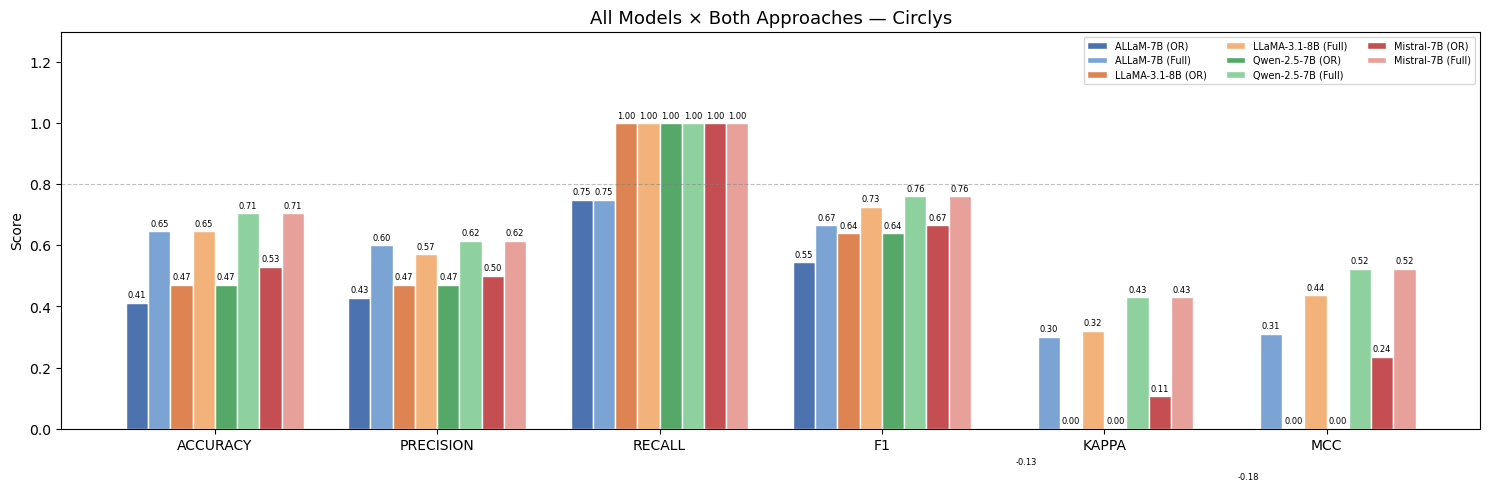

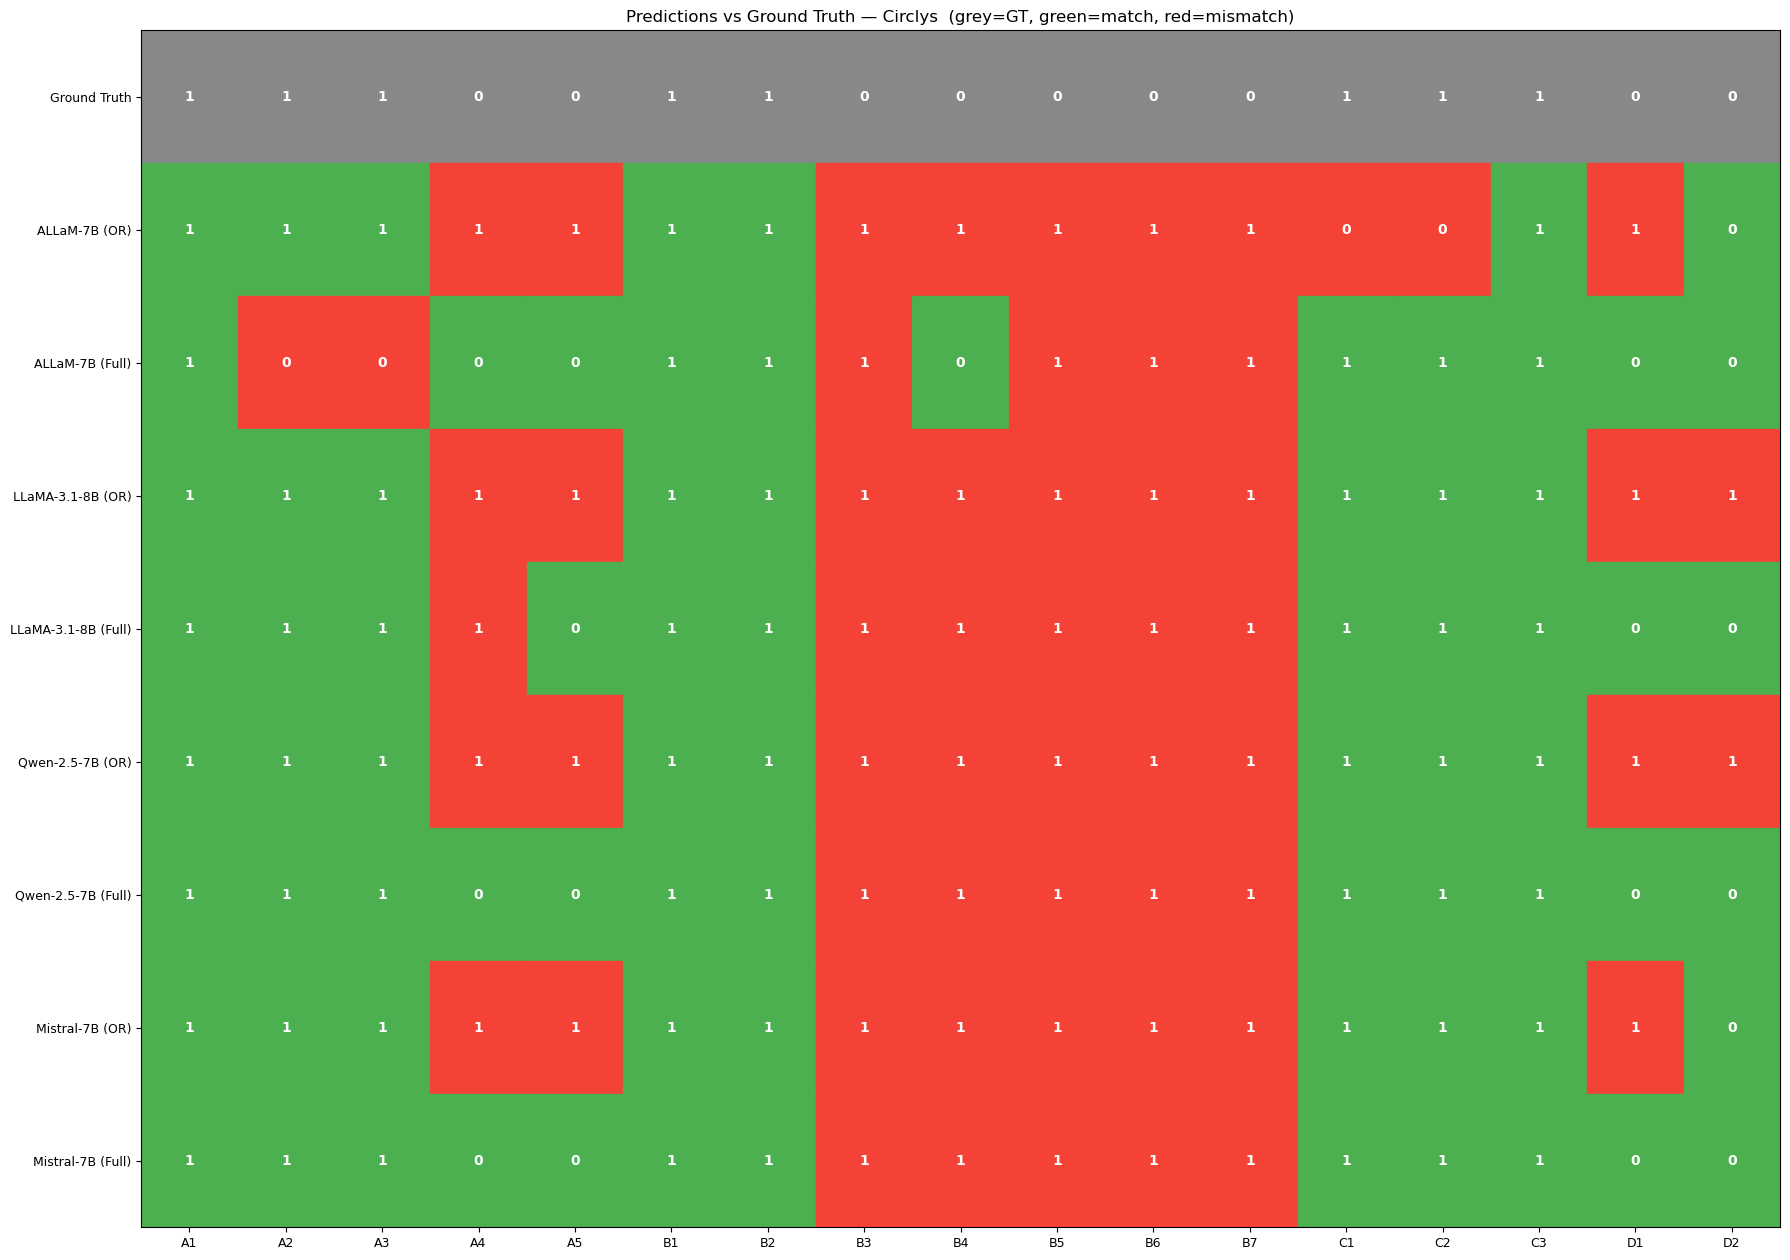

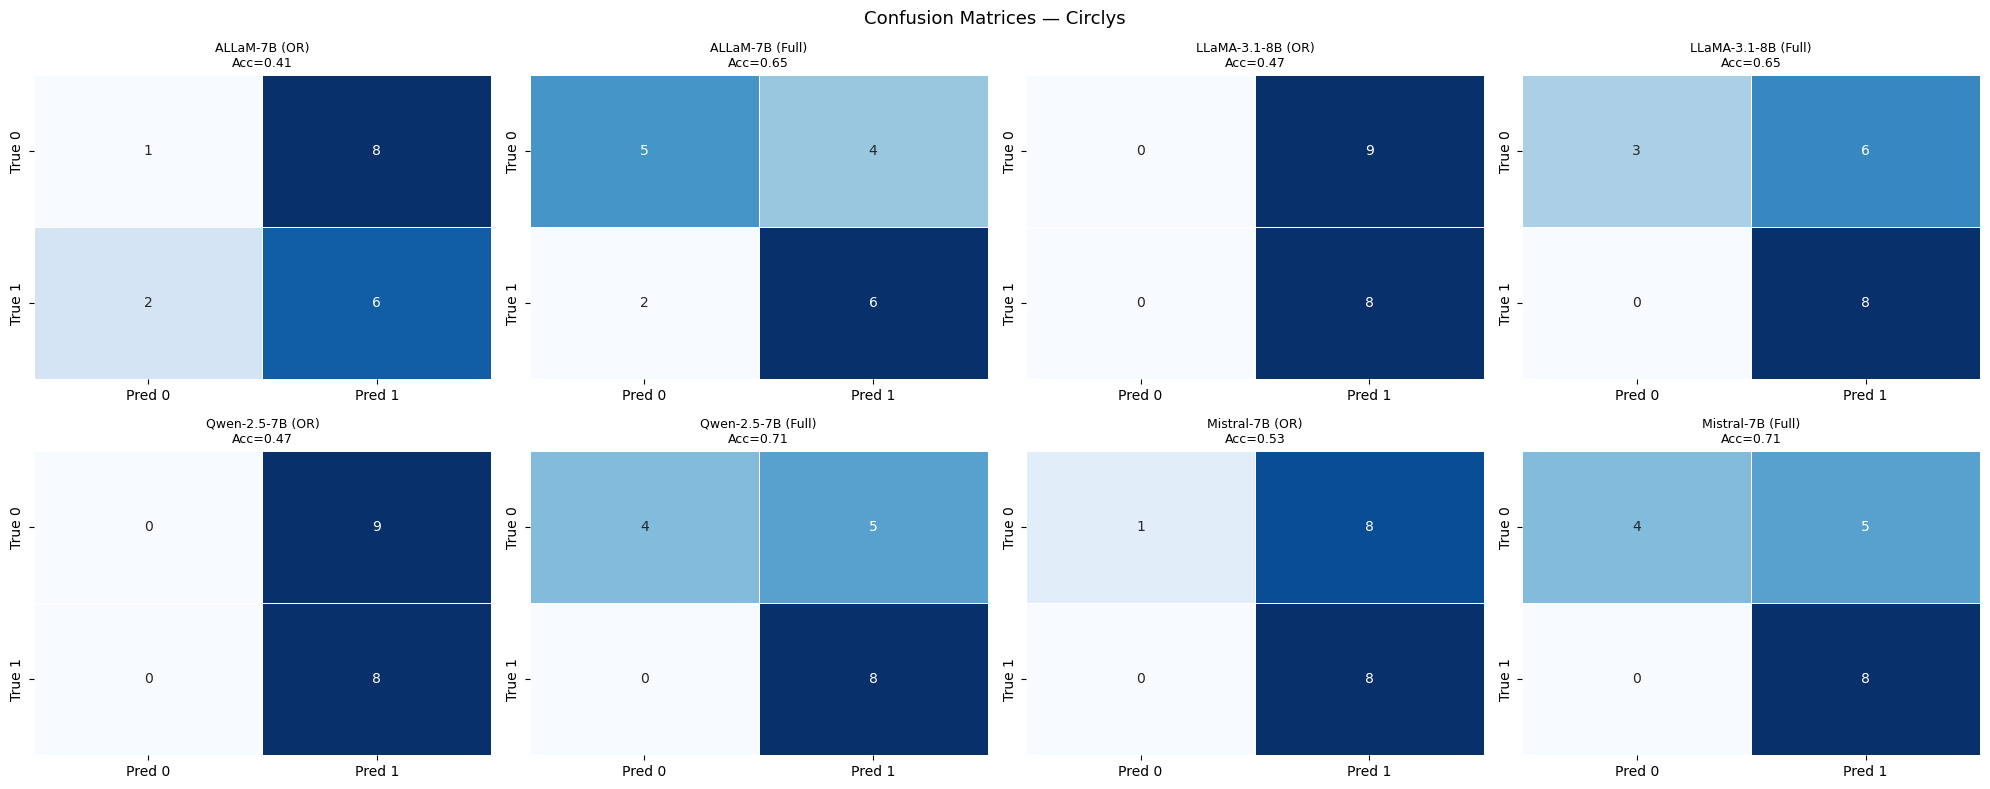

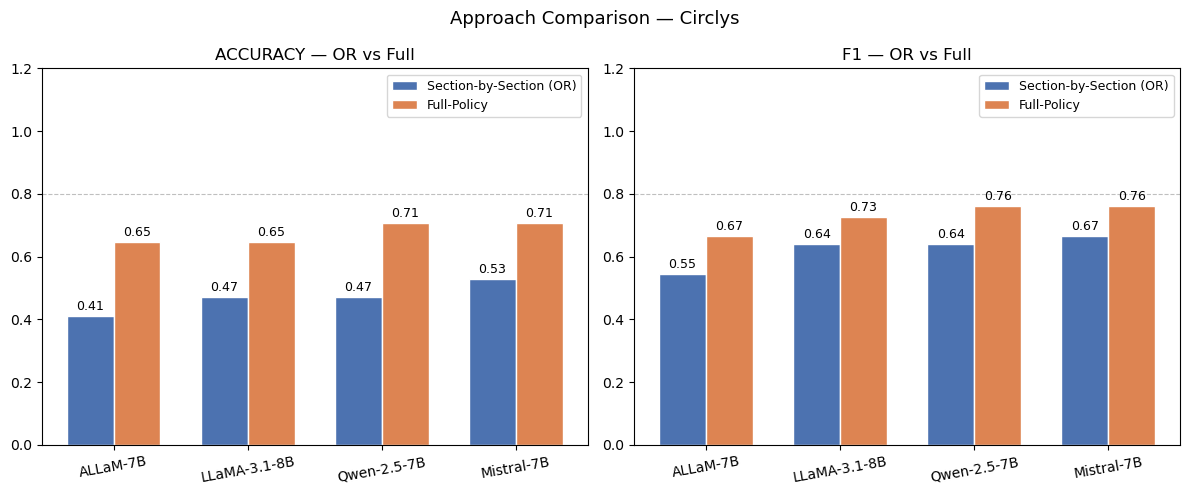

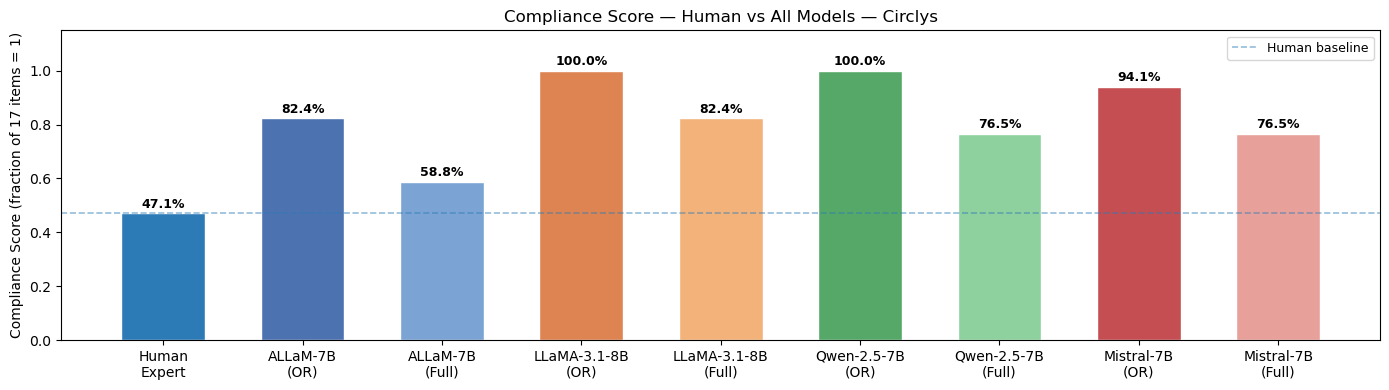

✓ All figures saved for Circlys


In [27]:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Dinar

In [34]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Dinar"
POLICY_DOCX_PATH = "user pp/preprocessed/Dinar.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Dinar
Sections: 13 | GT compliant: 10/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111100000 | Acc=0.529 Kappa=-0.015
-- Full-Policy --
  Full Final: 10100111111011100 | Acc=0.588 K

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11110111111111110 | Acc=0.588 Kappa=0.048
-- Full-Policy --
  Full Final: 11100111011111100 | Acc=0.765 Kappa

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  OR Final: 11110111111111110 | Acc=0.588 Kappa=0.048
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.706 Kappa=0.351
 

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  Sec 11: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111100 | Acc=0.588 Kappa=0.048
-- Full-Policy --
  Full Final: 11100111111110100 | Acc=0.765 Kap

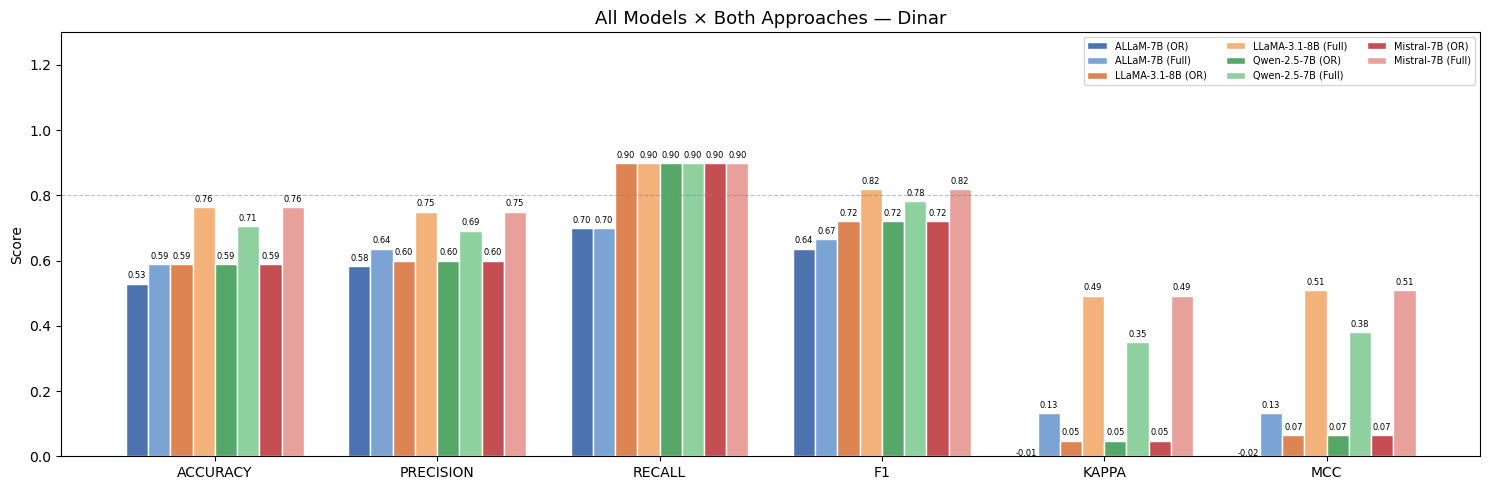

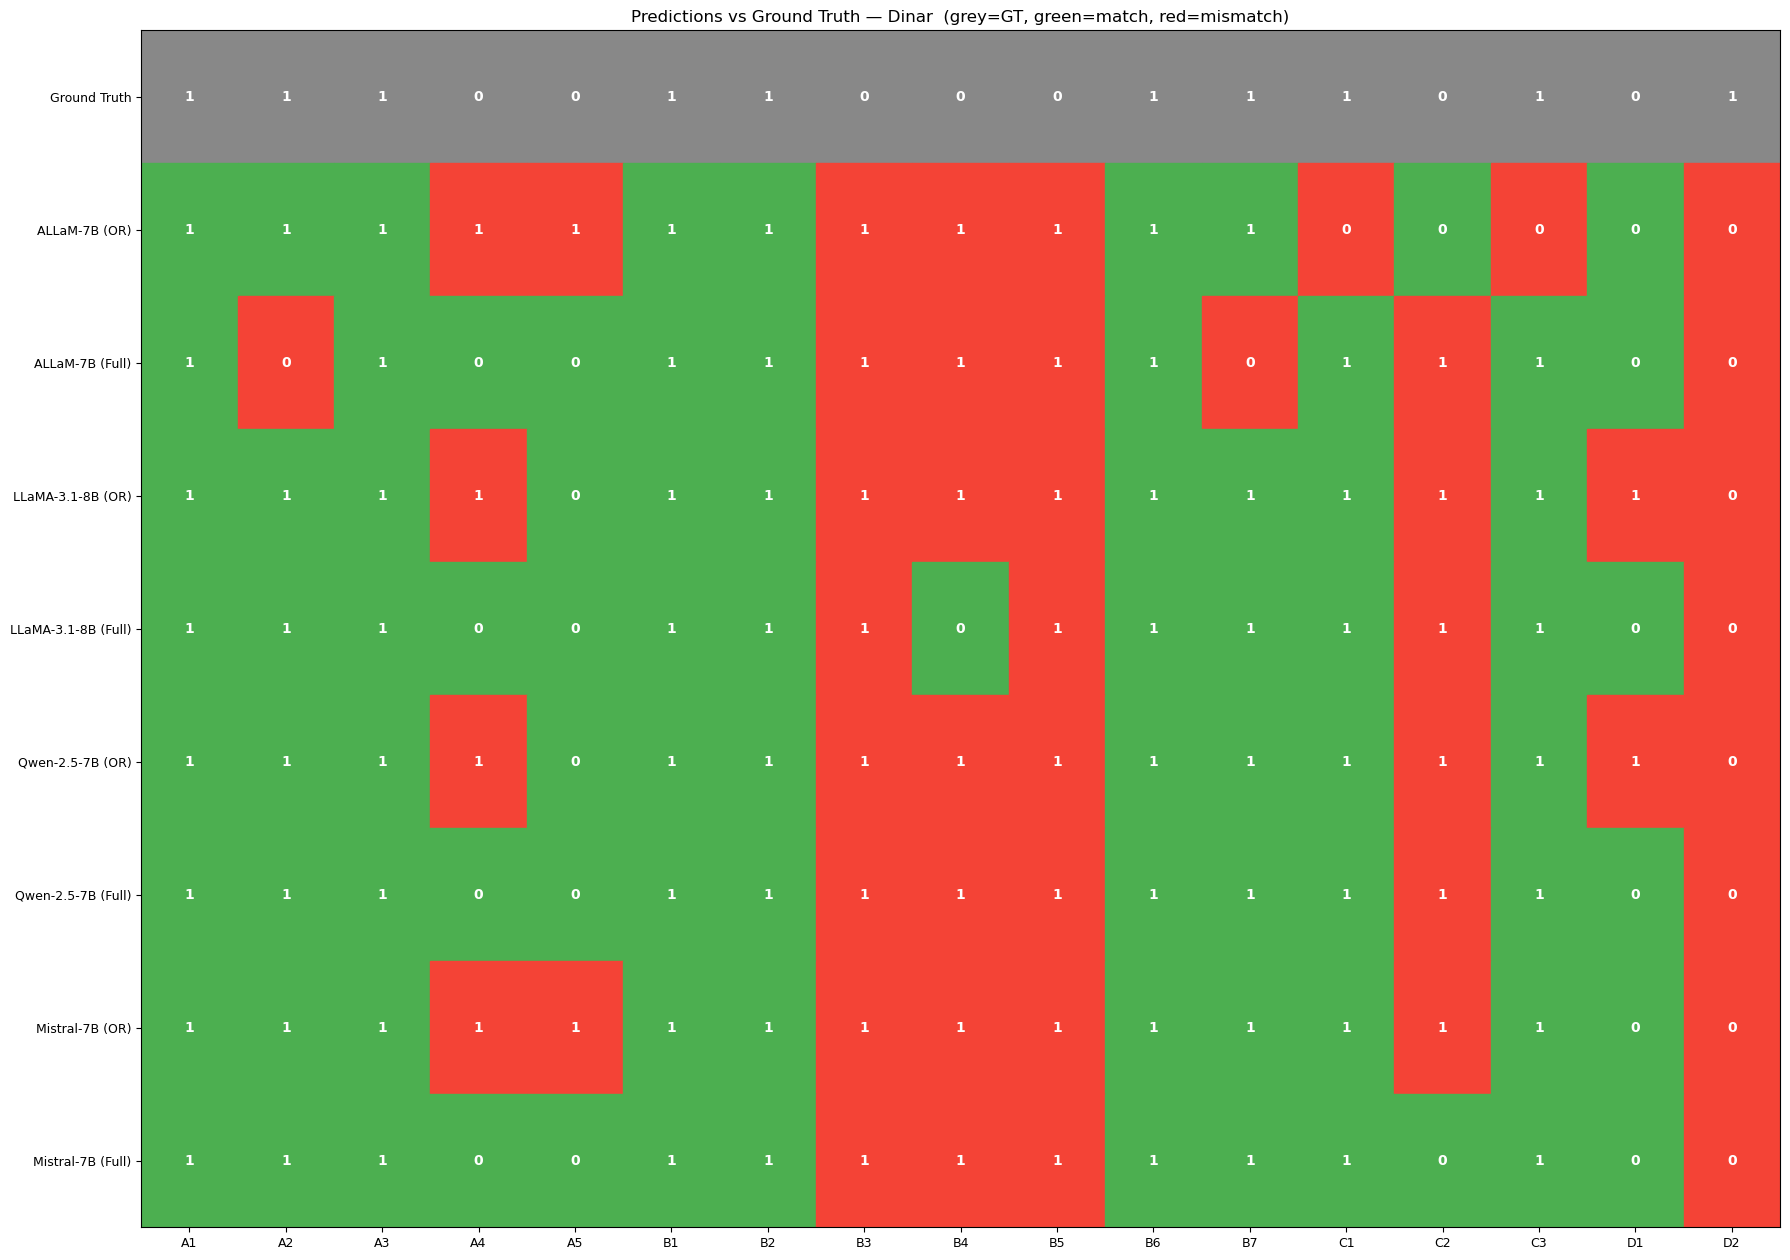

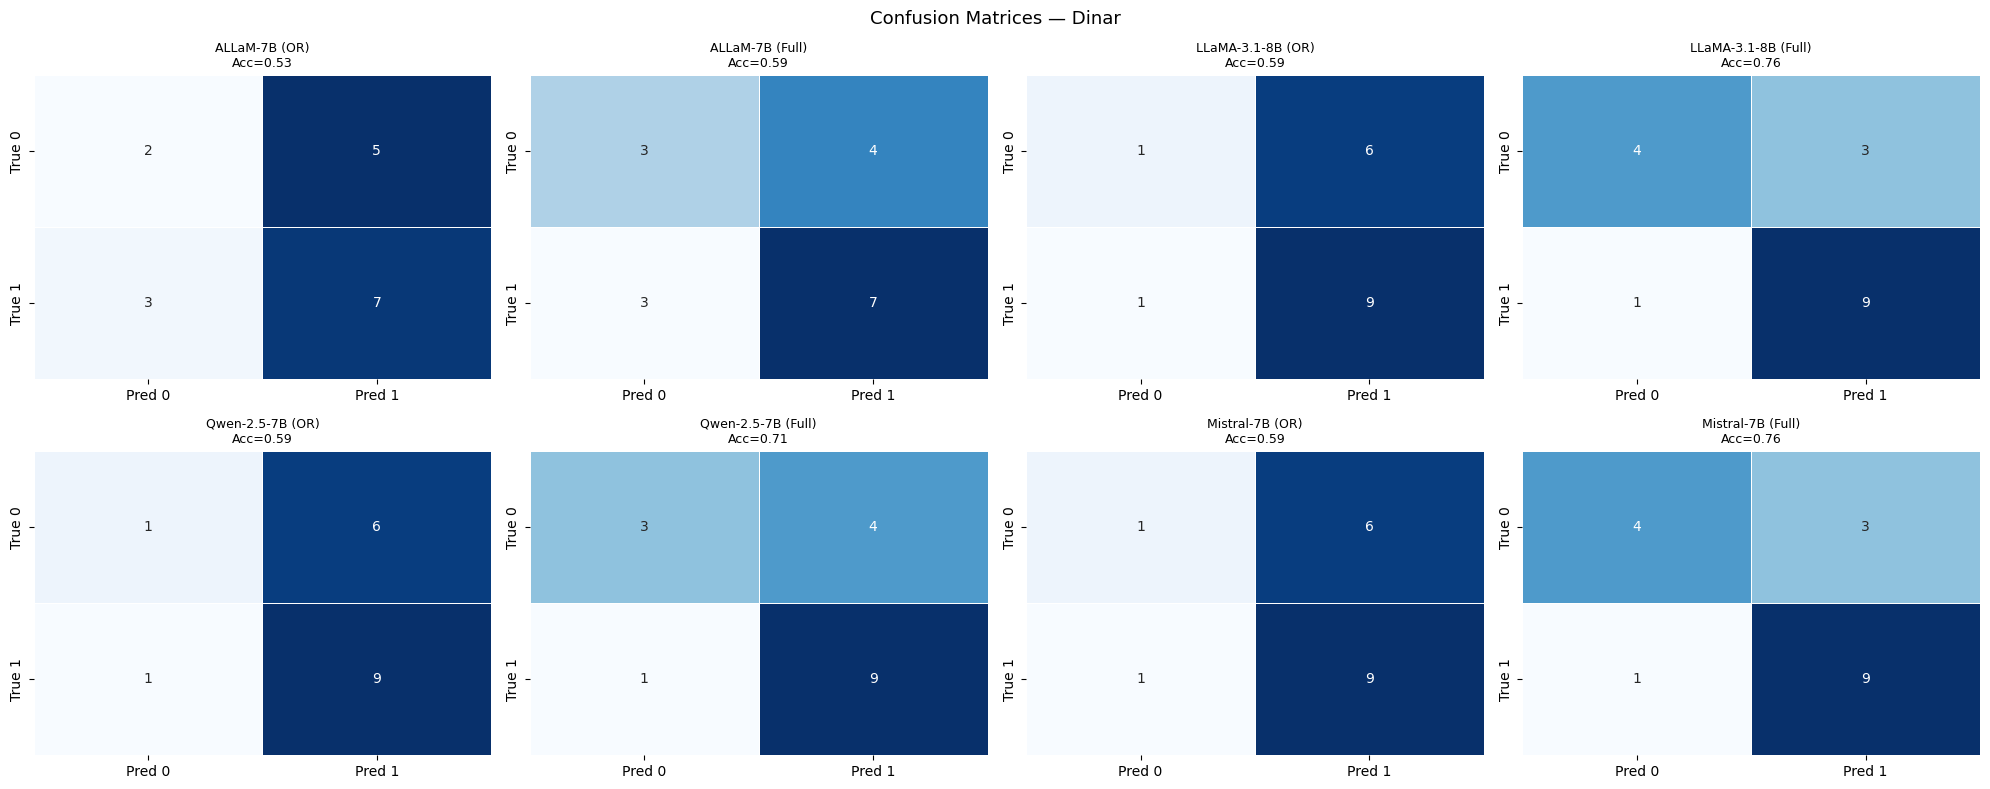

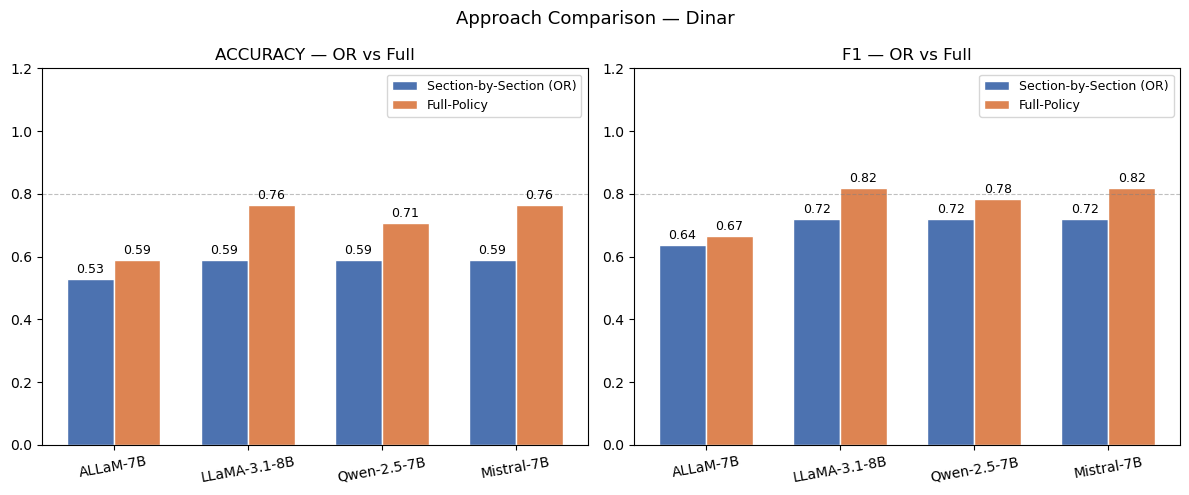

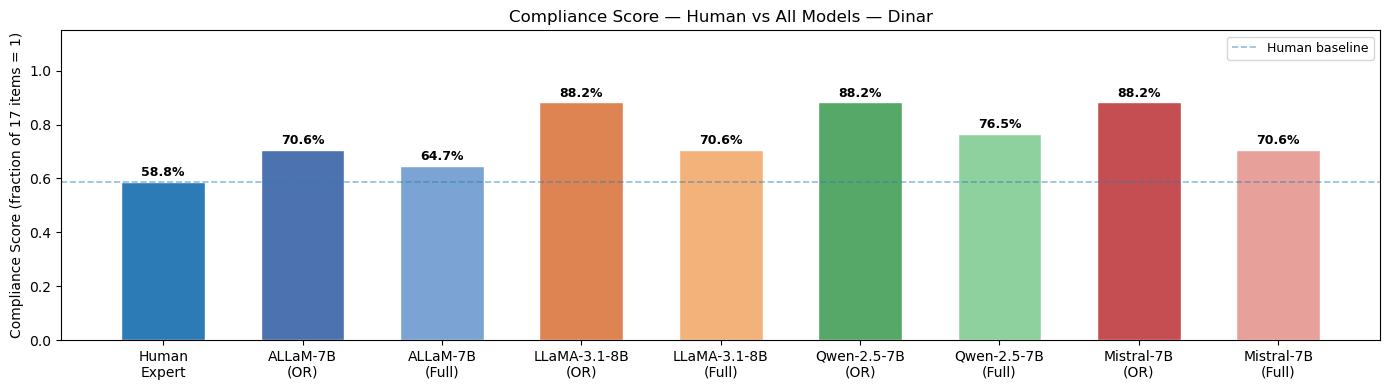

✓ All figures saved for Dinar


In [35]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Safqah

In [36]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Safqah"
POLICY_DOCX_PATH = "user pp/preprocessed/Safqah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Safqah
Sections: 6 | GT compliant: 10/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 2: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
  Sec 3: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.588 Kappa=0.000
-- Full-Policy --
  Full Final: 10100111111011110 | Acc=0.647 Kappa=0.239
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  OR Final: 10100111111111100 | Acc=0.765 Kappa=0.493
-- Full-Policy --
  Full Final: 10100111111111100 | Acc=0.765 Kappa=0.493
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  OR Final: 11101111111110000 | Acc=0.647 Kappa=0.239
-- Full-Policy --
  Full Final: 10100111011111100 | Acc=0.706 Kappa=0.380
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 3: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111011100100 | Acc=0.647 Kappa=0.239
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.824 Kappa=0.611
  ✓ Mistral-7B unloaded | VRAM freed

✓ Safqah done — 8 results saved
       model                approach  accuracy       f1    kappa
    ALLaM-7B Section-by-Section (OR)  0.588235 0.740741 0.000000
    ALLaM-7B             Full-Policy  0.647059 0.727273 0.238806
LLaMA-3.1-8B Section-by-Section (OR)  0.764706 0.818182 0.492537
LLaMA-3.1-8B             Full-Policy  0.764706 0.818182 0.492537
 Qwen-2.5-7B Section-by-Sec

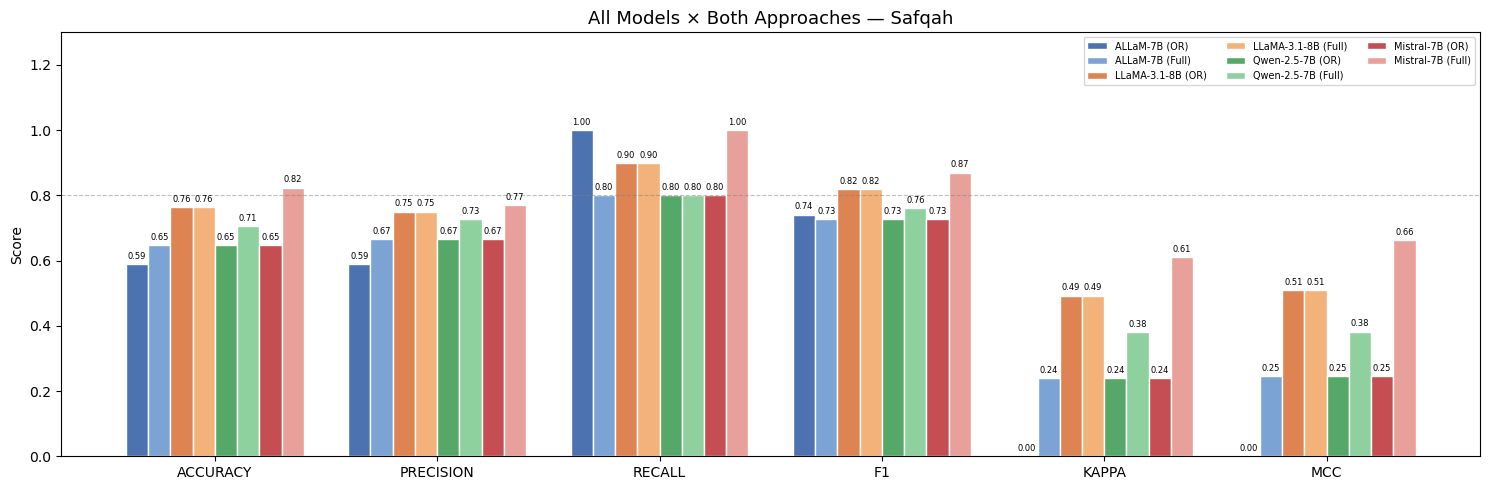

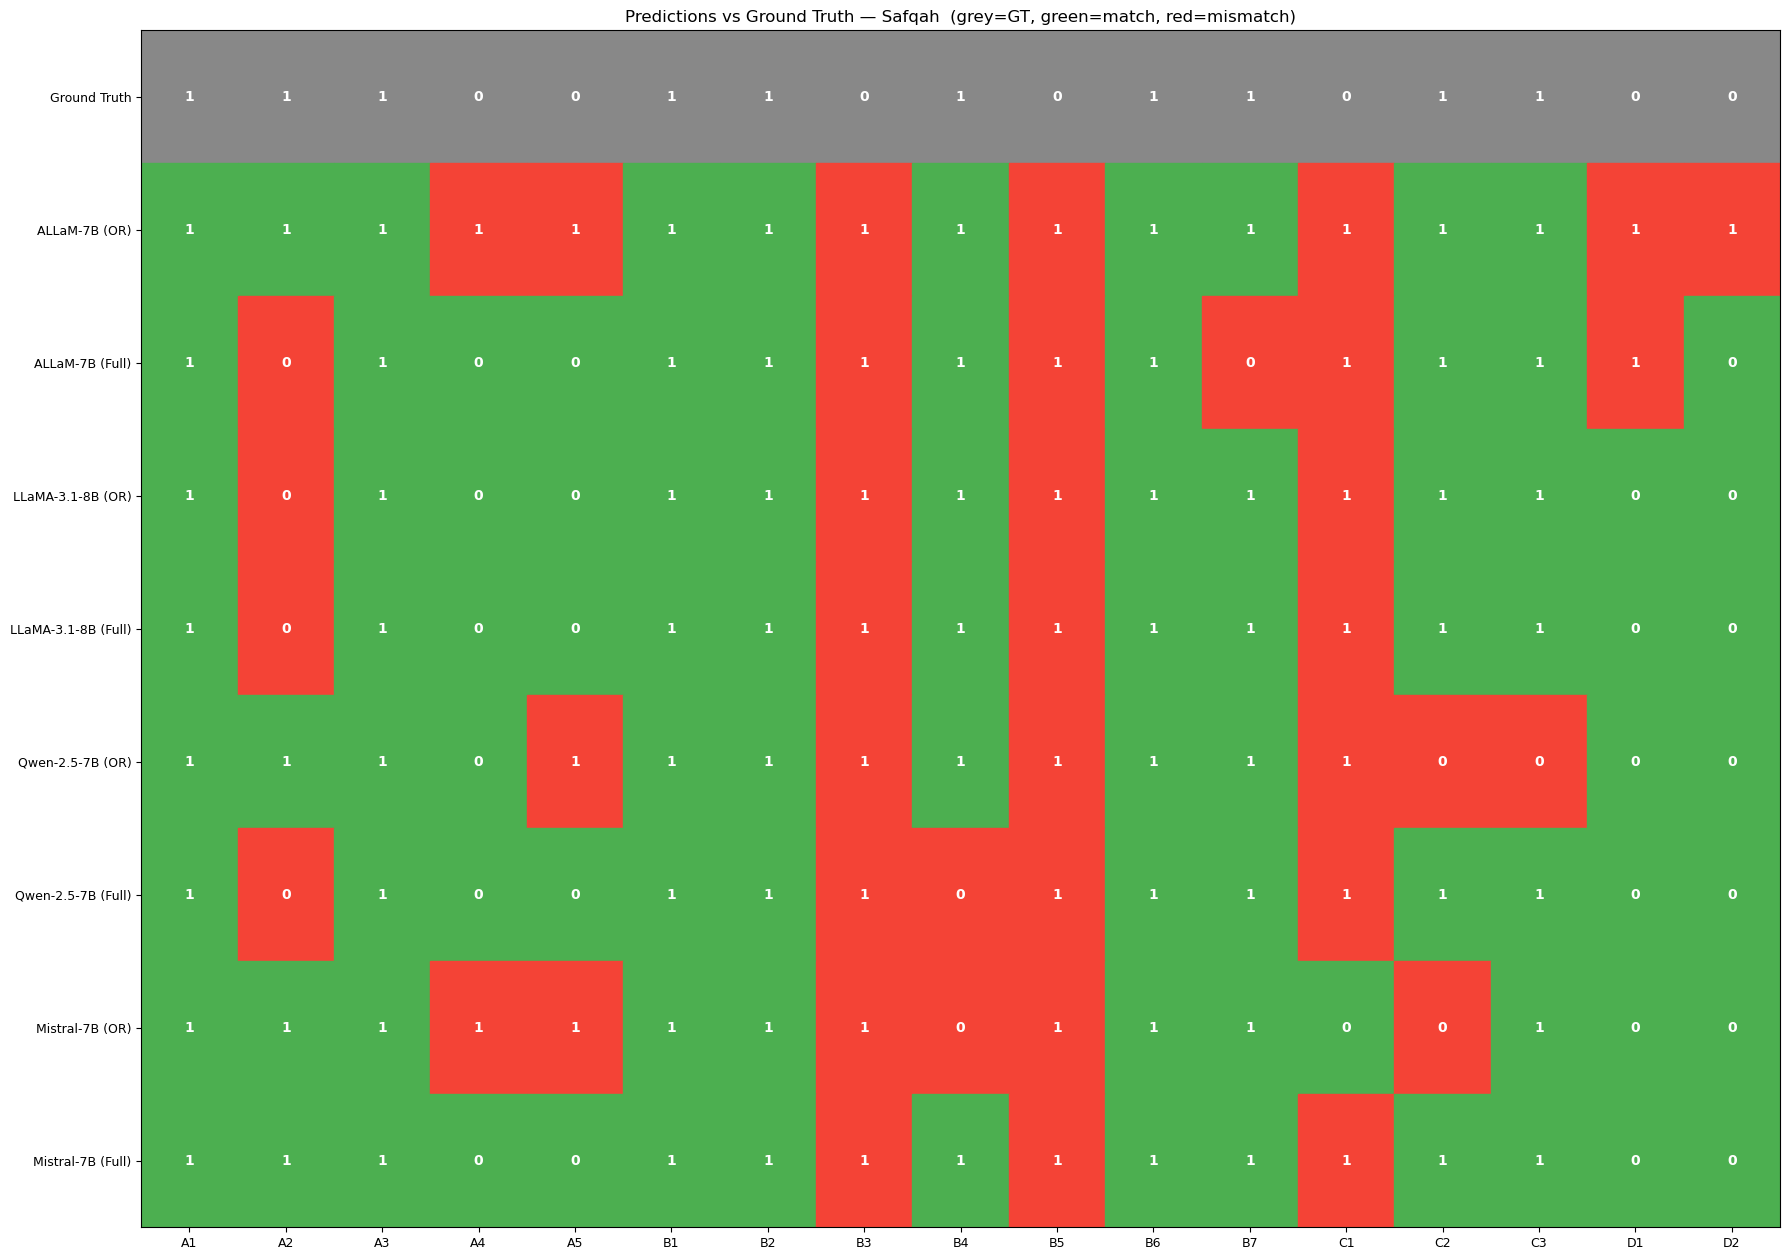

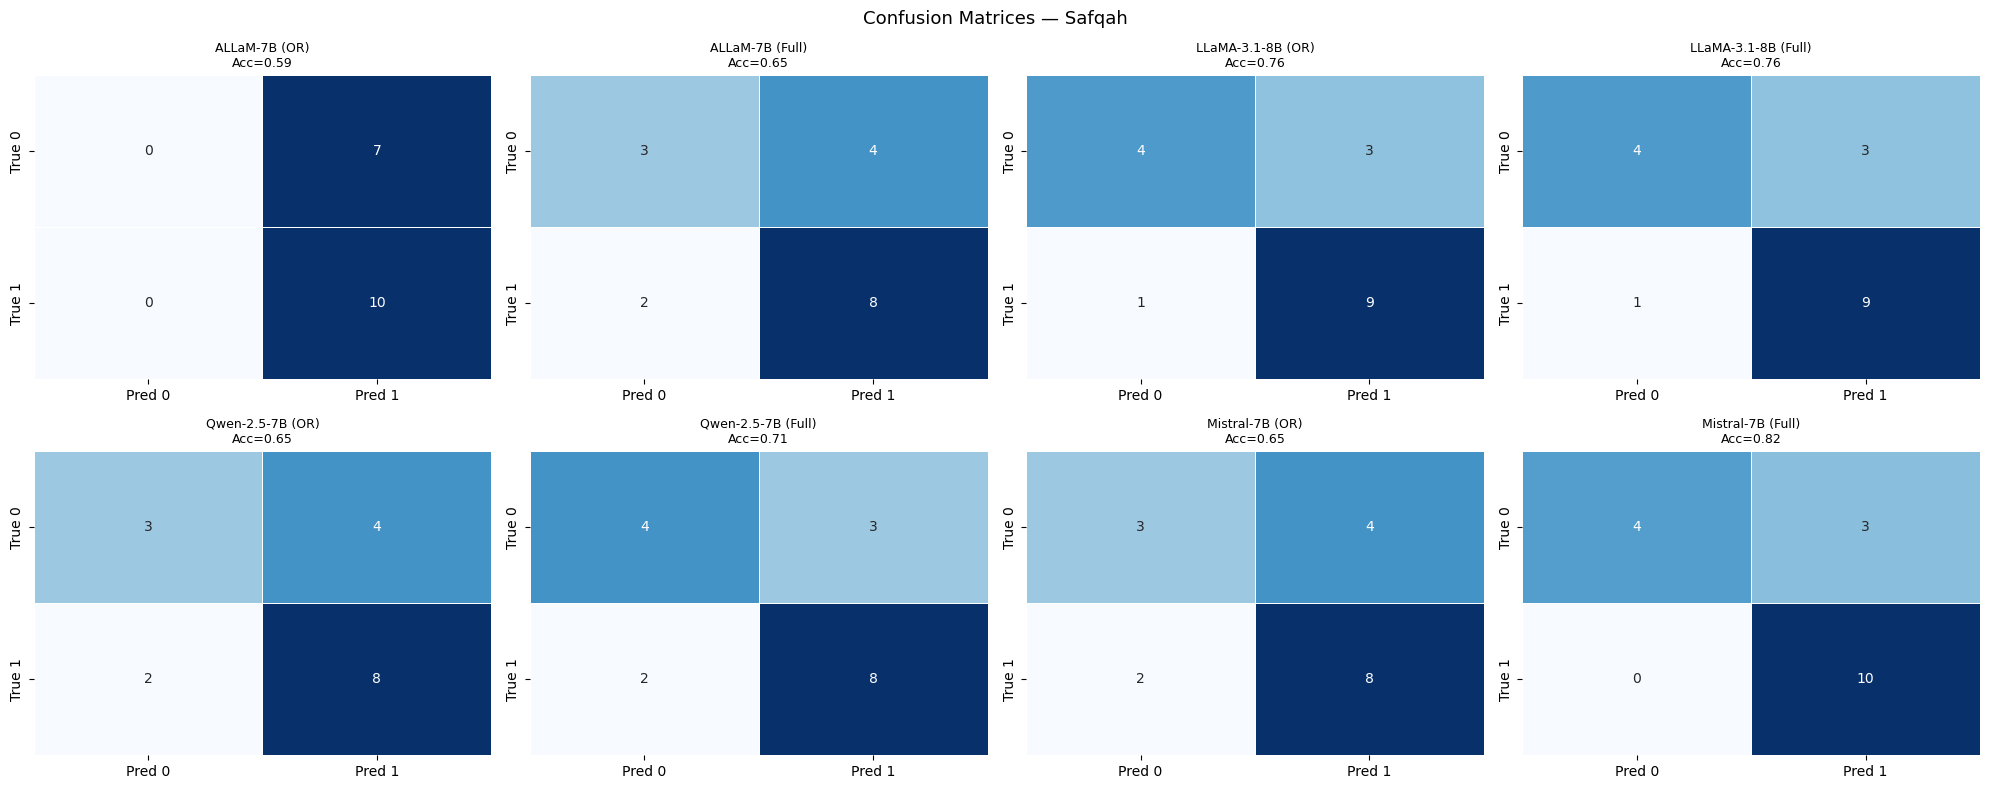

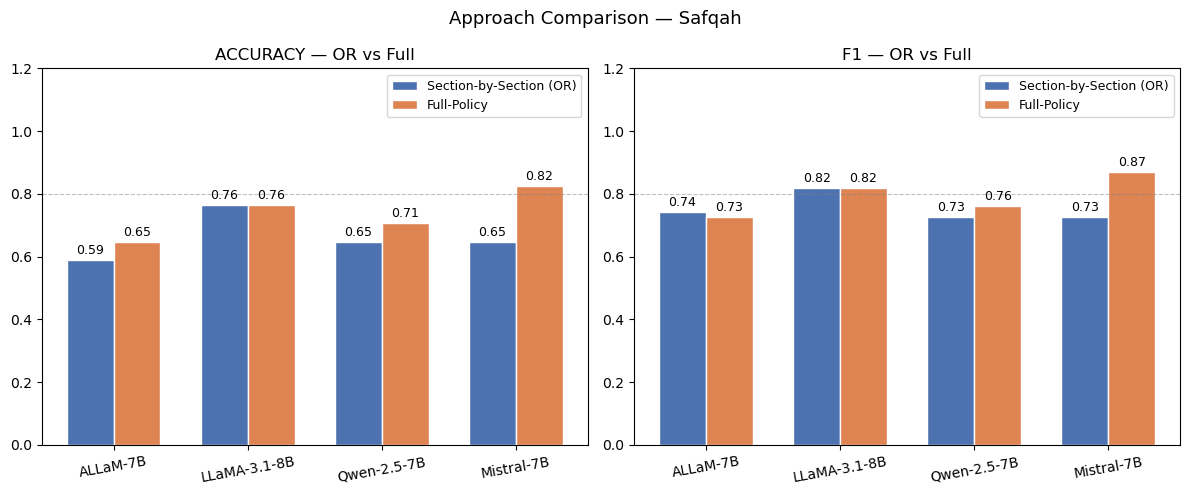

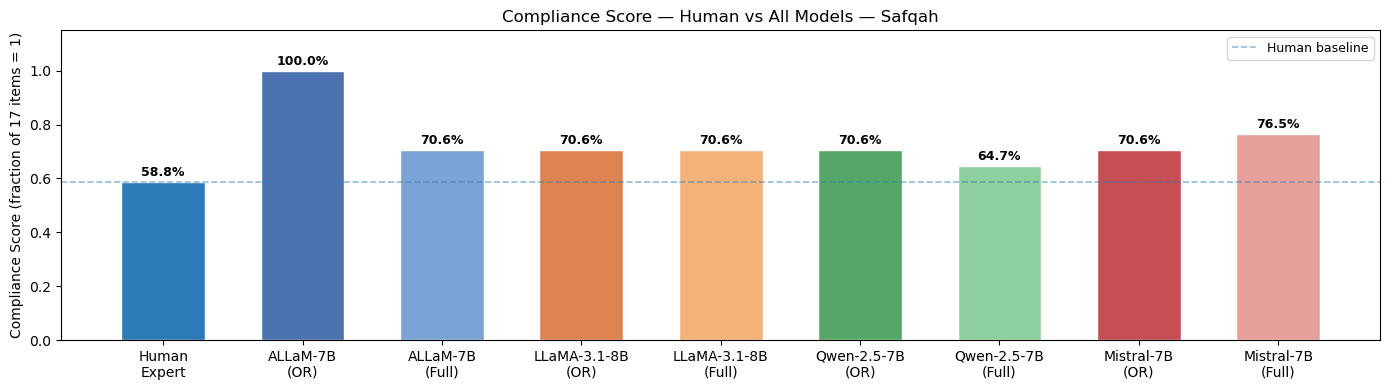

✓ All figures saved for Safqah


In [37]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Tarmeez

In [38]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Tarmeez"
POLICY_DOCX_PATH = "user pp/preprocessed/Tarmeez.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Tarmeez
Sections: 11 | GT compliant: 10/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.647 Kappa=0.164
-- Full-Policy --
  Full Final: 11000111011011100 | Acc=0.882 Kappa=0.757
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 11: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0]
  OR Final: 11000111011111110 | Acc=0.765 Kappa=0.493
-- Full-Policy --
  Full Final: 11000110111111100 | Acc=0.706 Kappa=0.380
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 11: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0]
  OR Final: 11110111111110100 | Acc=0.706 Kappa=0.351
-- Full-Policy --
  Full Final: 11000111011111100 | Acc=0.824 Kappa=0.628
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 8: [0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 11: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.647 Kappa=0.164
-- Full-Policy --
  Full Final: 11000110111111100 | Acc=0.706 Kappa=0.380
  ✓ Mistral-7B unloaded | VRAM freed

✓ Tarmeez done — 8 results saved
       model                approach  accura

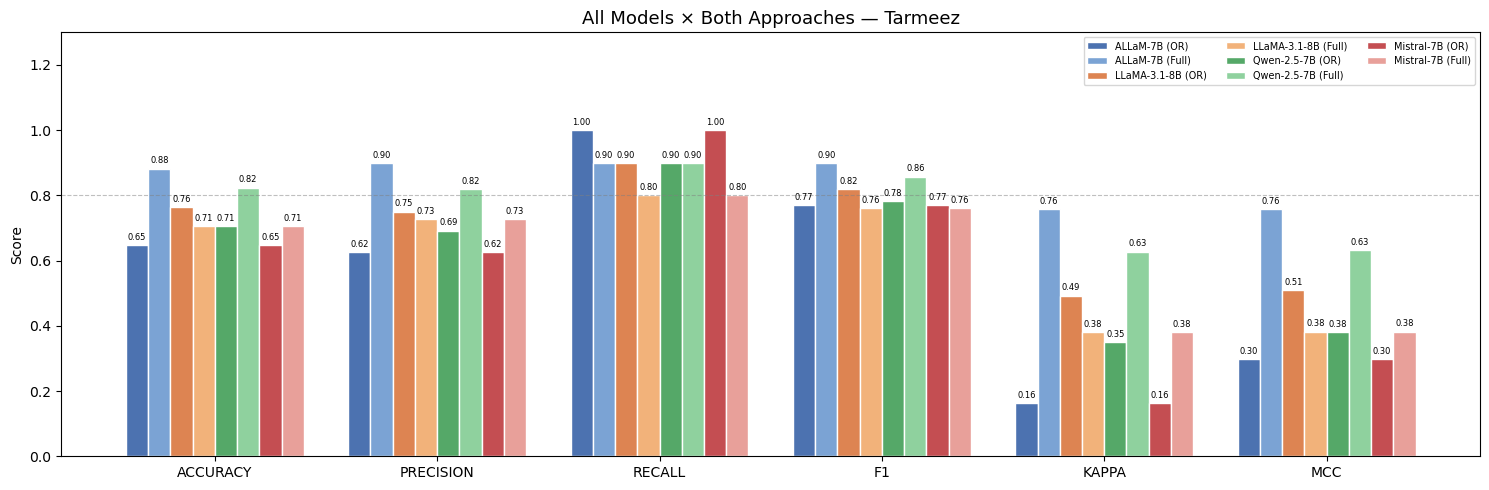

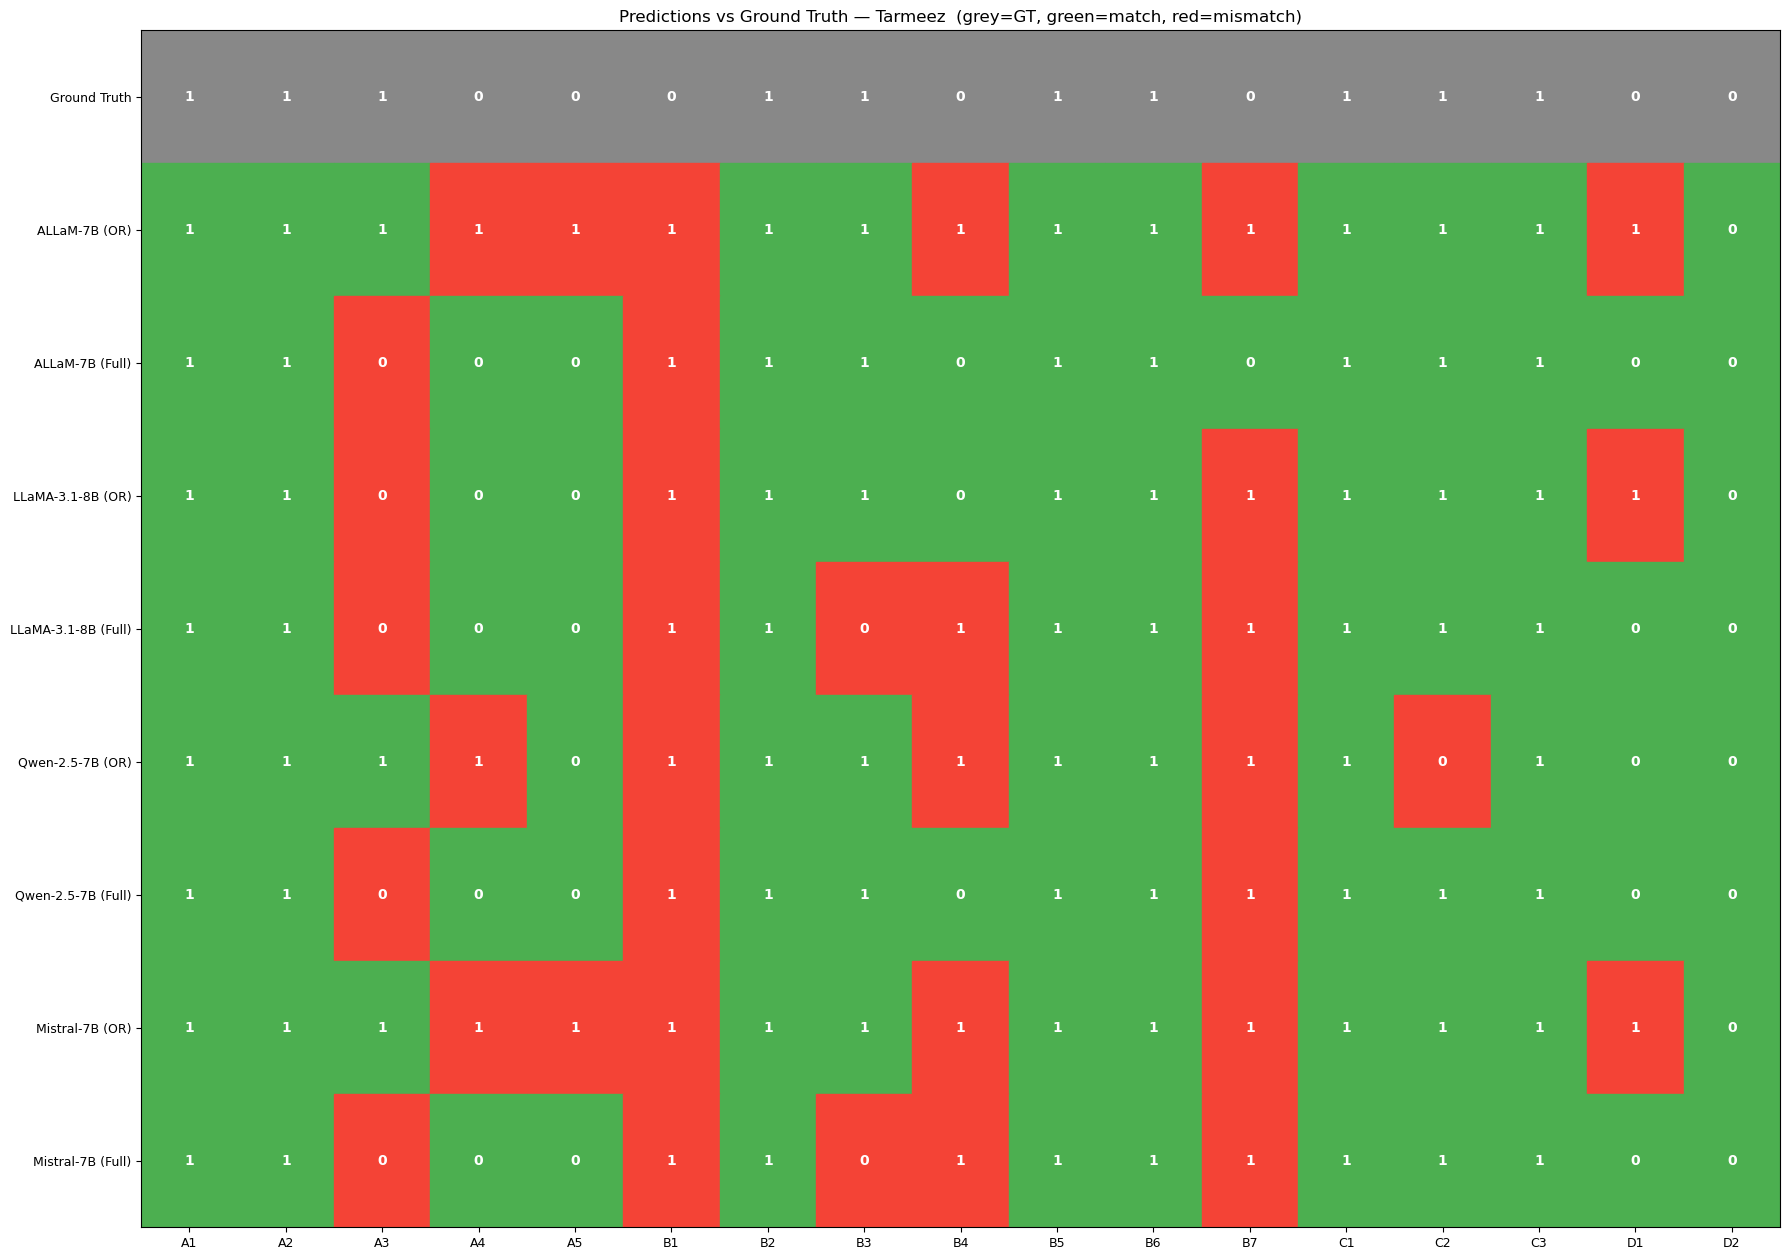

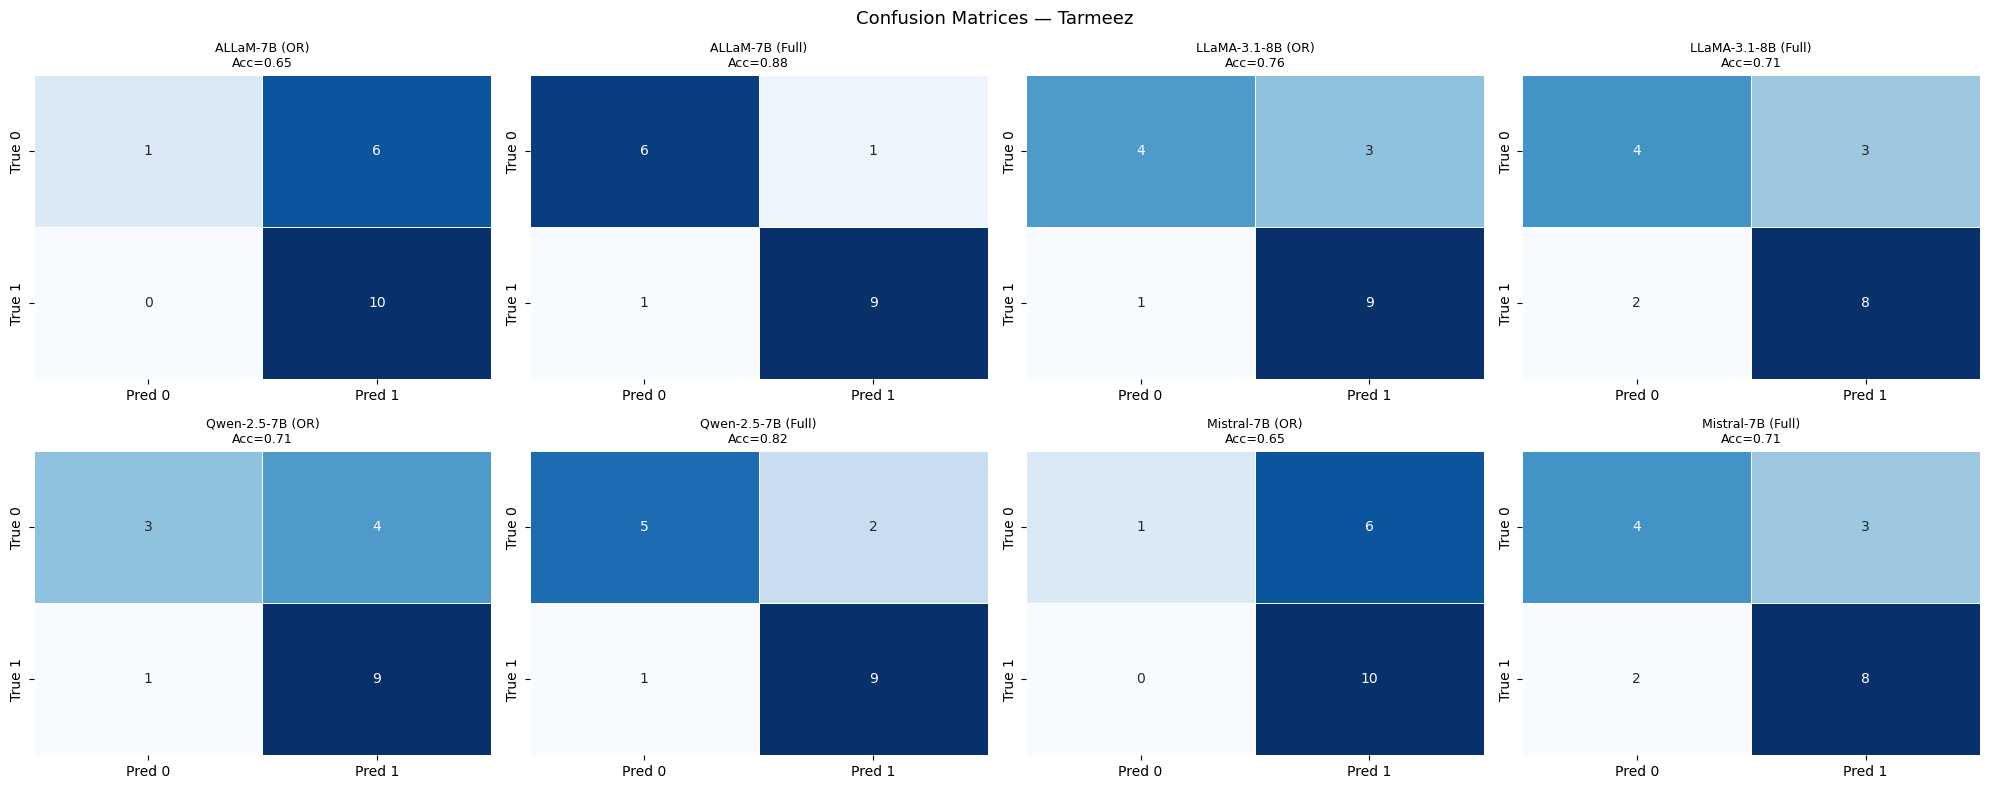

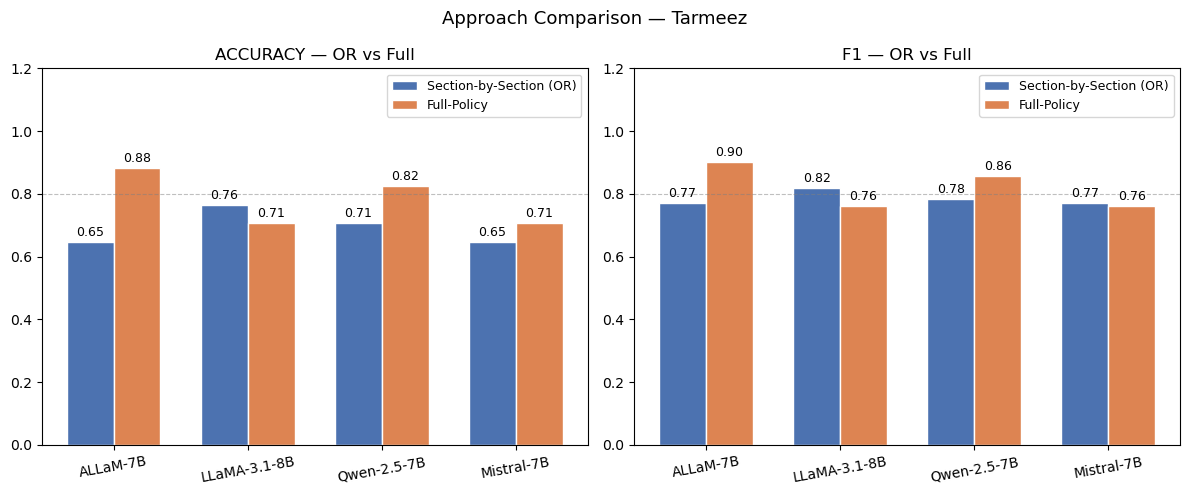

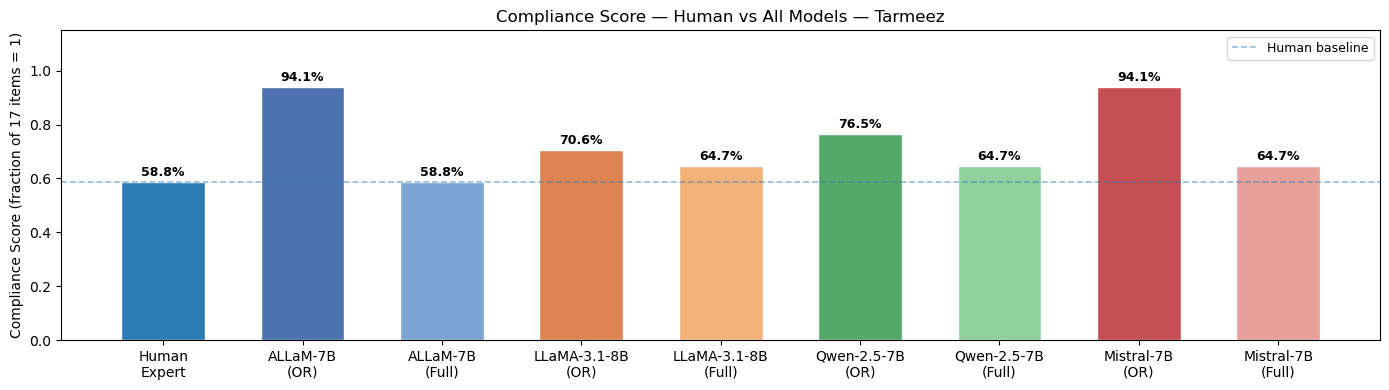

✓ All figures saved for Tarmeez


In [39]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Tamra Capital

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Tamra Capital"
POLICY_DOCX_PATH = "user pp/preprocessed/Tamra Capital.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Tamra Capital
Sections: 16 | GT compliant: 11/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (4096). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


...

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 5: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 7: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0]
  Sec 12: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 15: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 3: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1]
  Sec 14: [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  Sec

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0]
  Sec 8: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 9: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 14: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

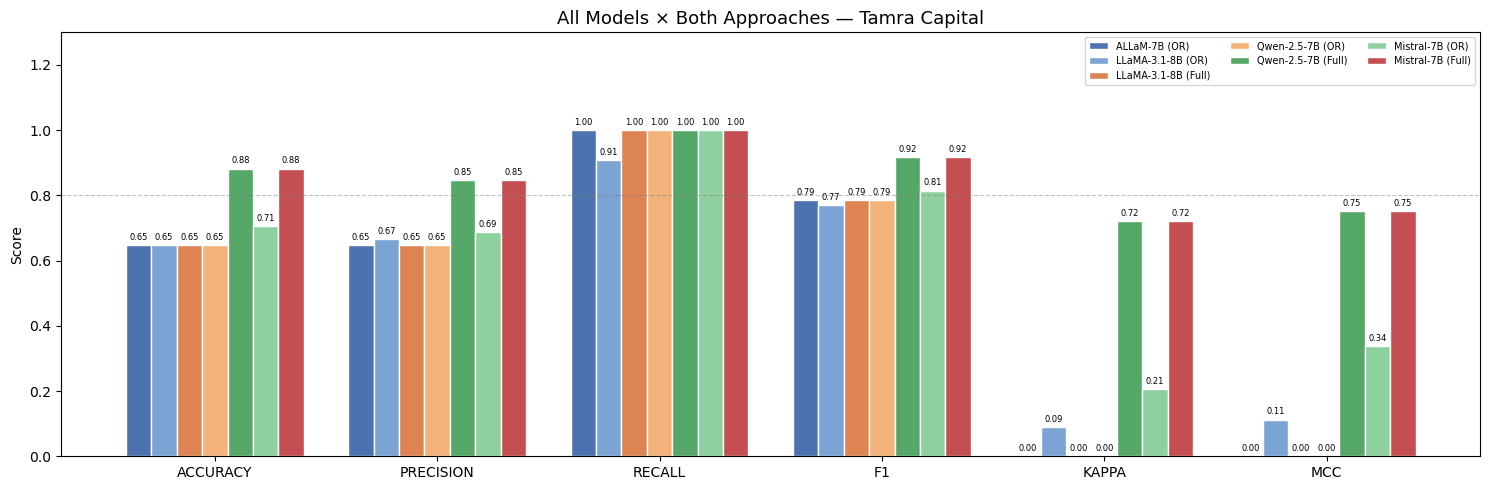

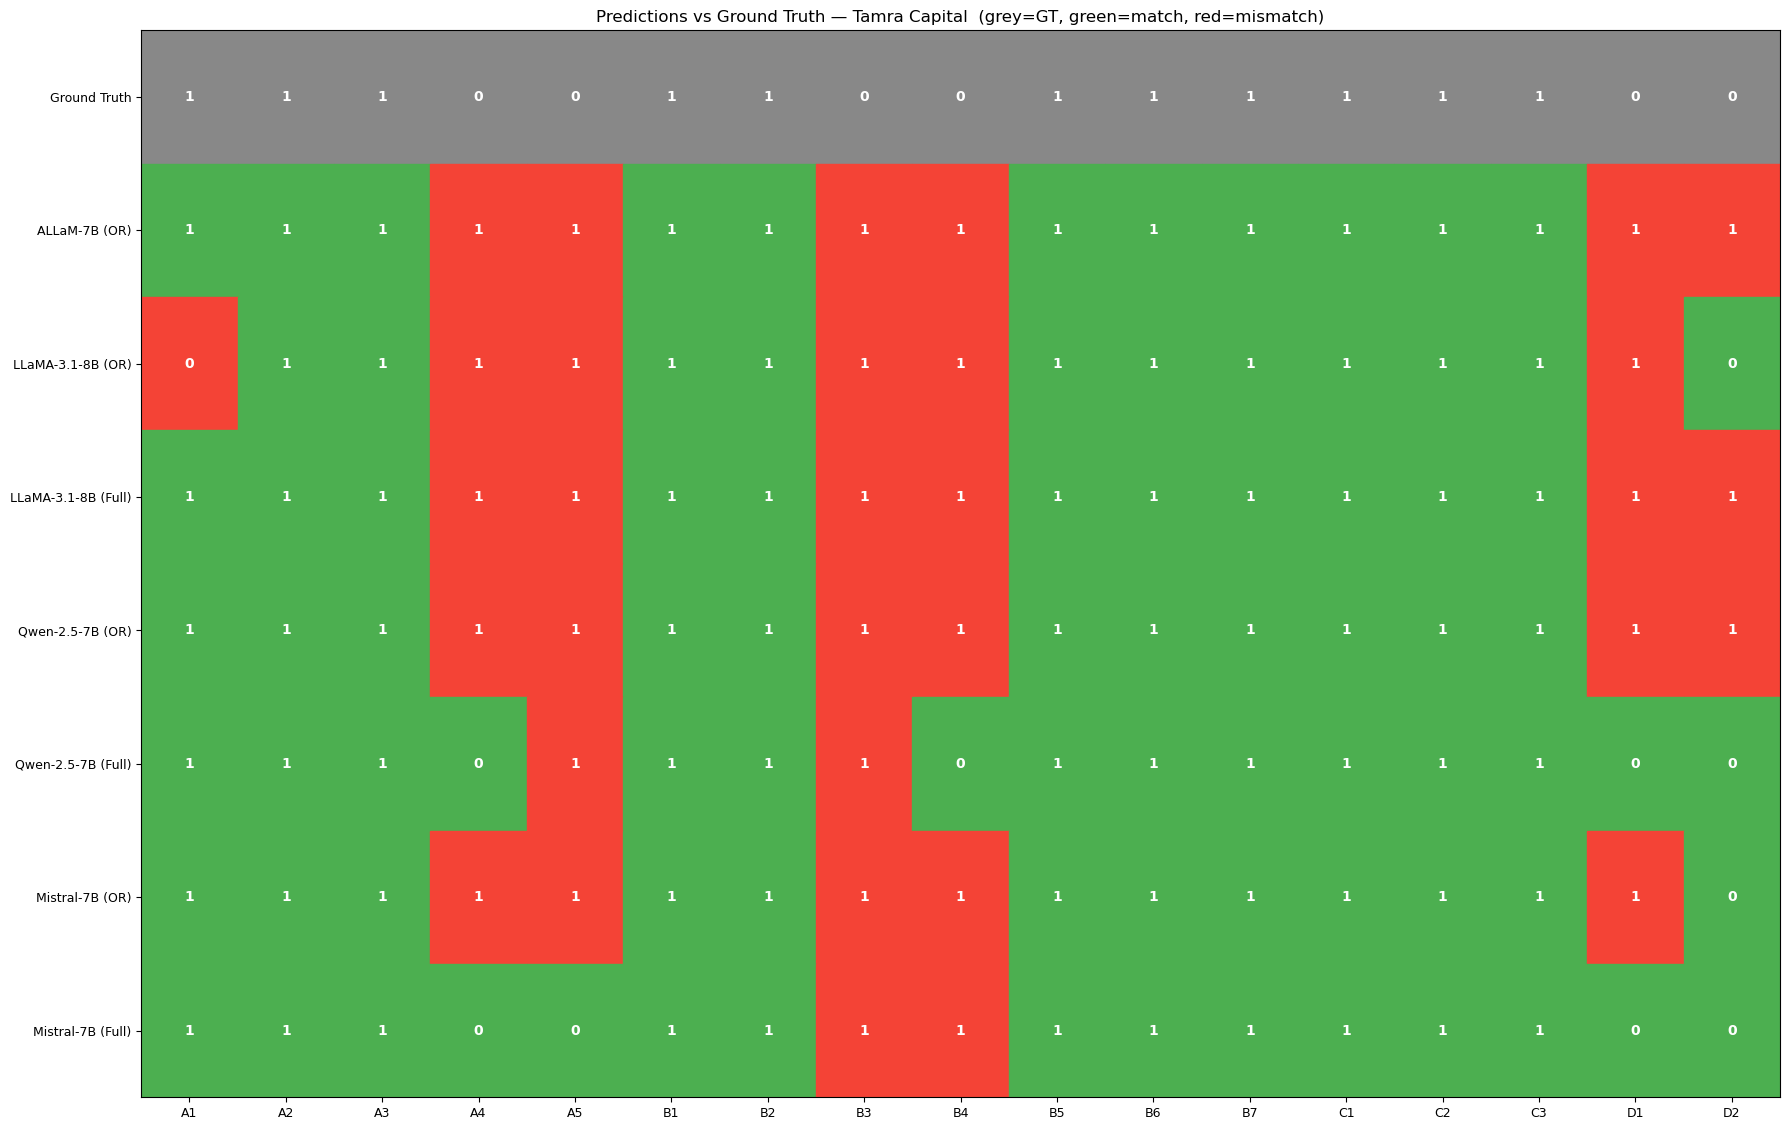

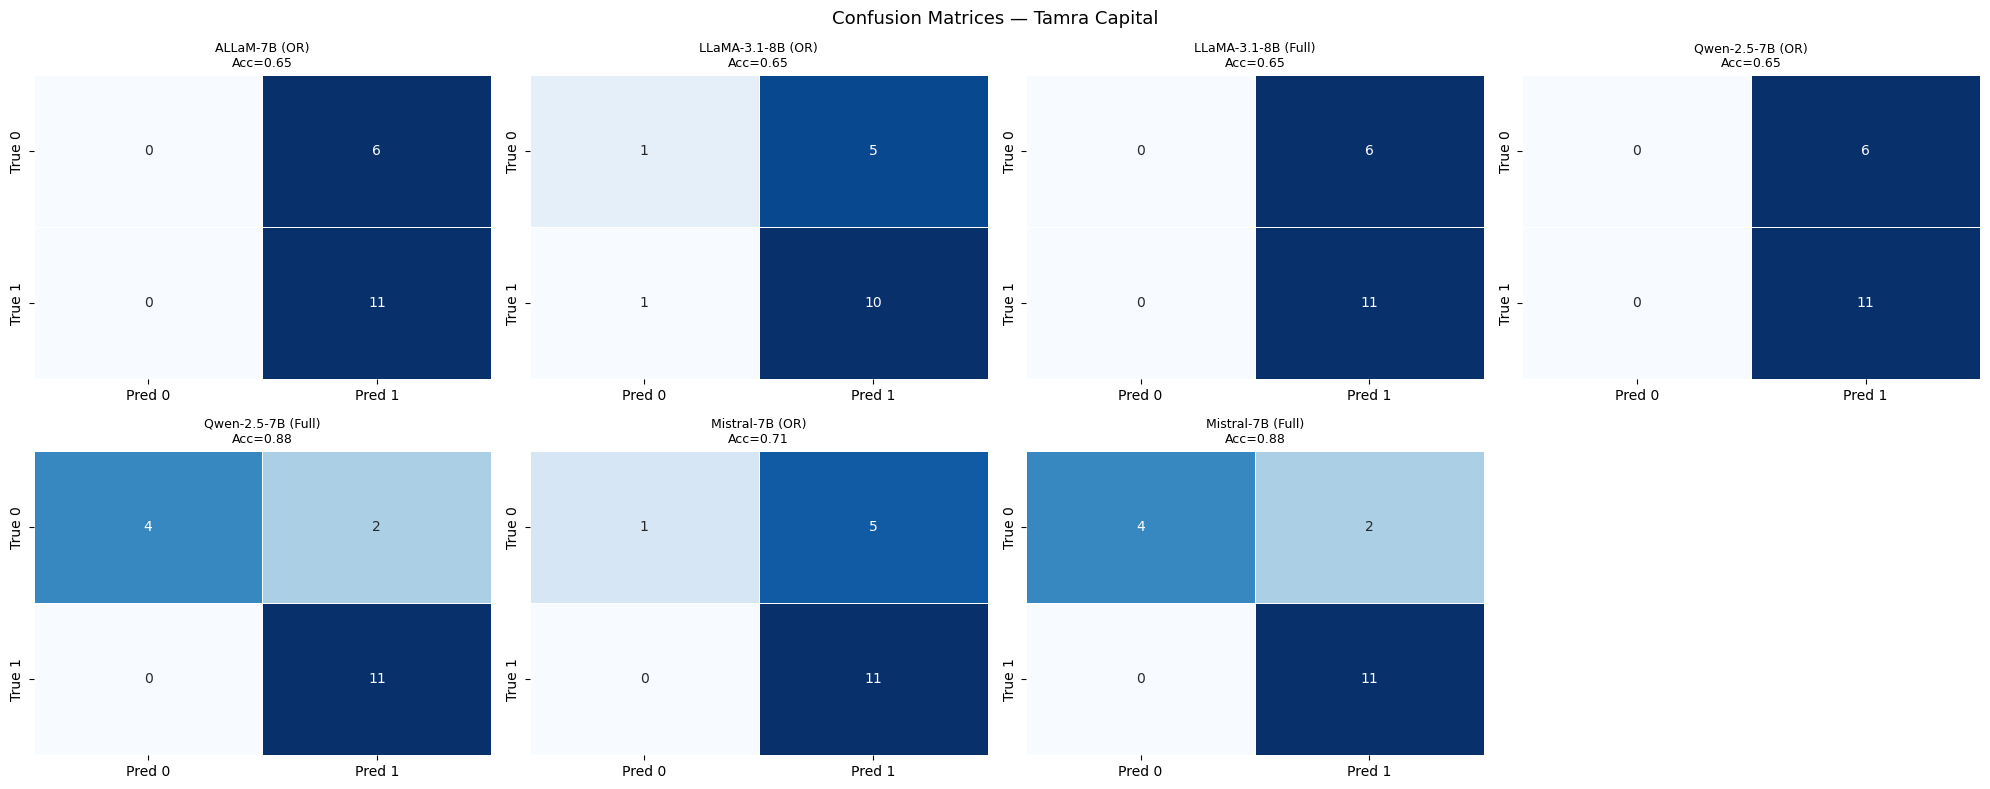

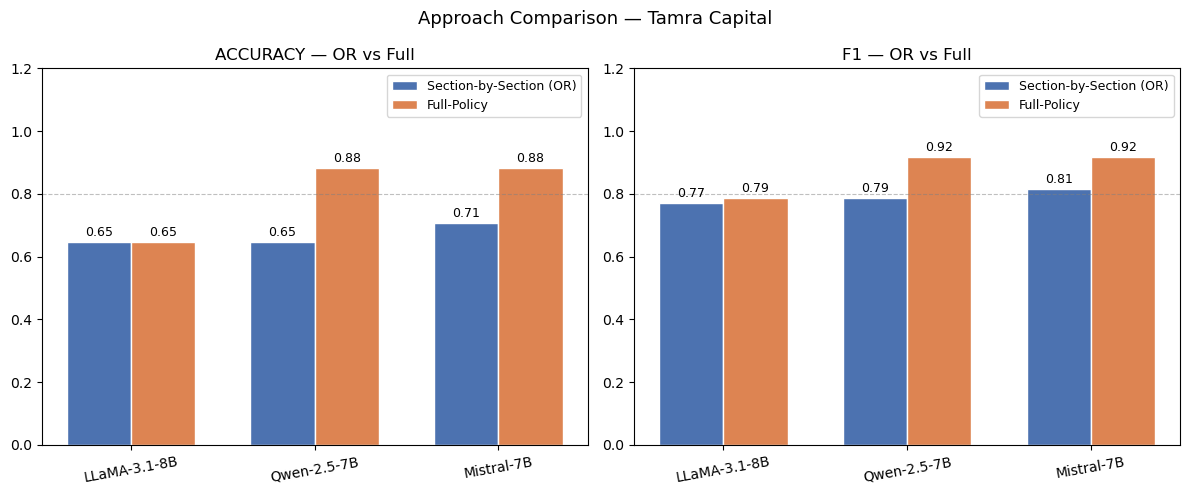

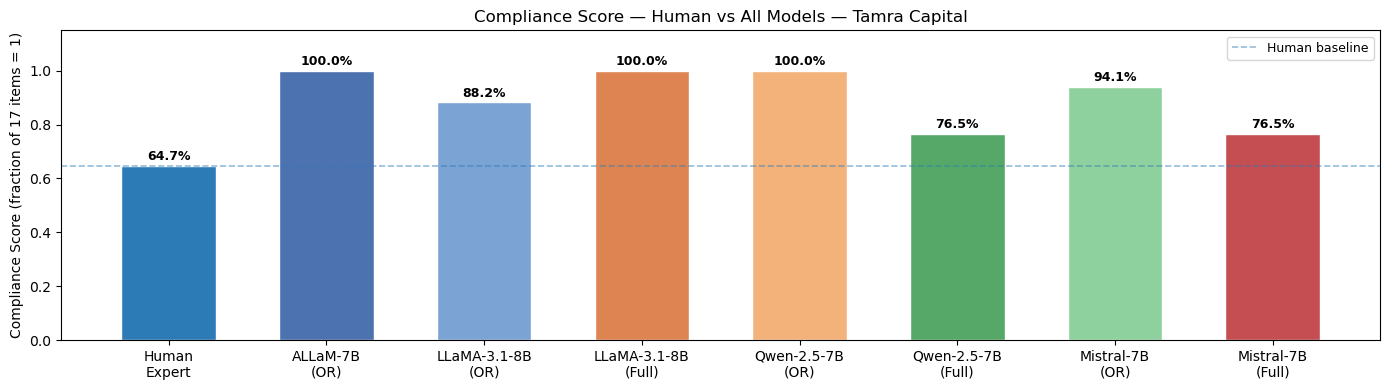

✓ All figures saved for Tamra Capital


In [8]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Malaa

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Malaa"
POLICY_DOCX_PATH = "user pp/preprocessed/Malaa.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Aseel Invest

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Aseel Invest"
POLICY_DOCX_PATH = "user pp/preprocessed/Aseel Invest.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Aseel Invest
Sections: 10 | GT compliant: 8/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111100000 | Acc=0.412 Kappa=-0.149
-- Full-Policy --
  Full Final: 10100111111111100 | Acc=0.647 Kappa=0.311
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  Sec 3: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 01010111111111110 | Acc=0.471 Kappa=-0.027
-- Full-Policy --
  Full Final: 11110111111111101 | Acc=0.588 Kappa=0.212
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111100 | Acc=0.588 Kappa=0.212
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.706 Kappa=0.430
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 3: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0]
  Sec 7: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 10: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111100 | Acc=0.588 Kappa=0.212
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.706 Kappa=0.430
  ✓ Mistral-7B unloaded | VRAM freed

✓ Aseel Invest done — 8 results saved
       model                approach  accuracy       f1     kappa
    ALLaM-7B Section-by-Section (OR

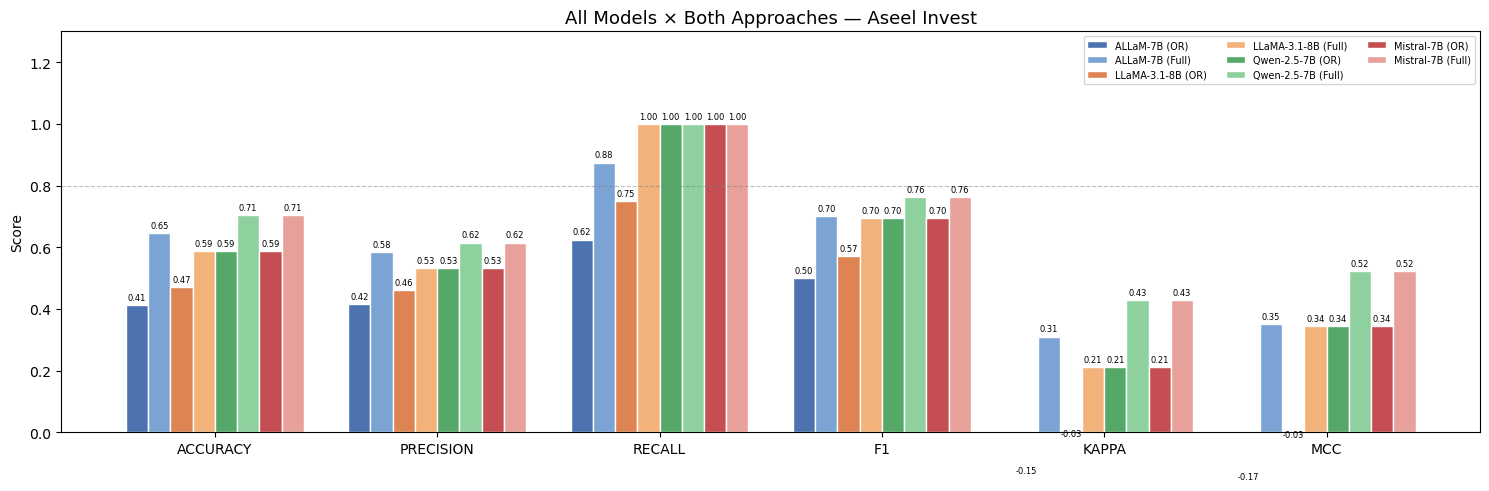

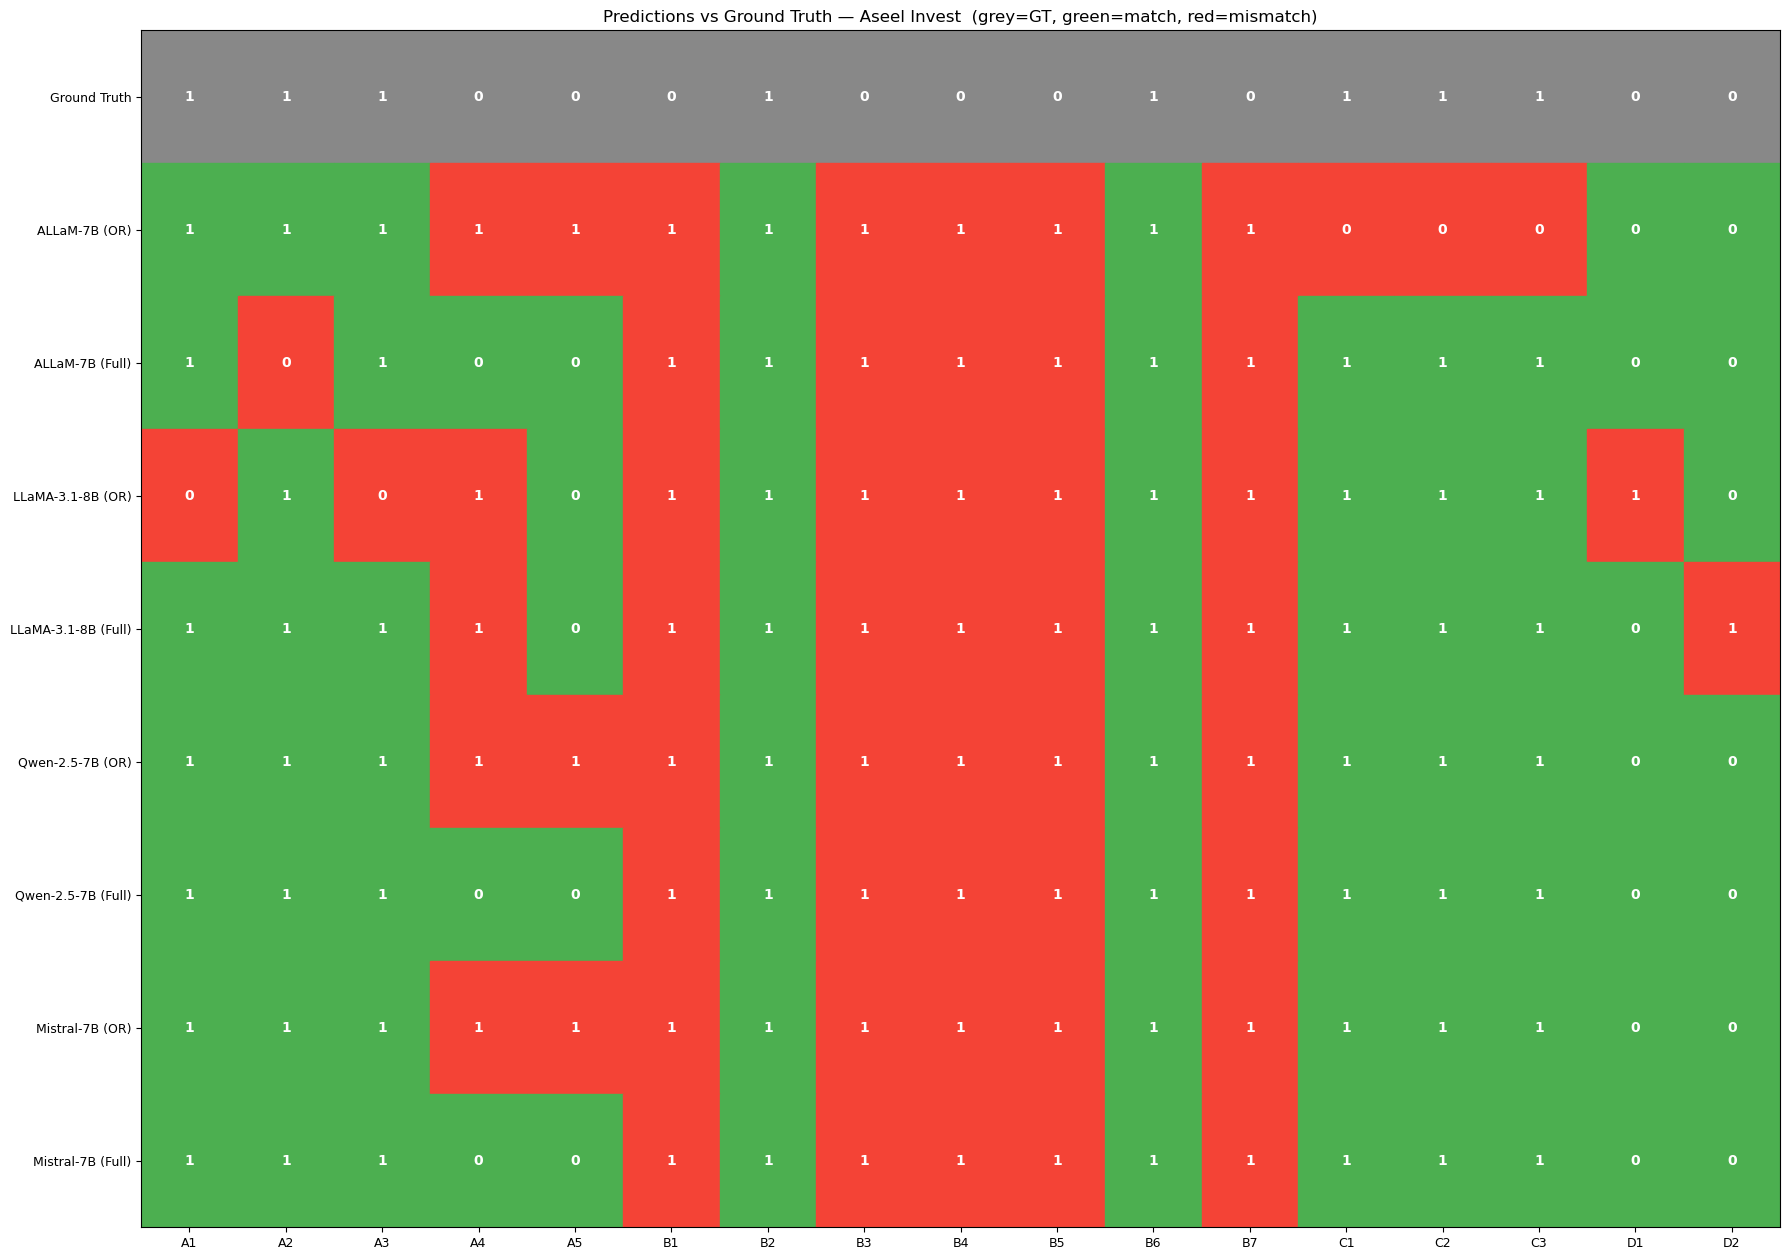

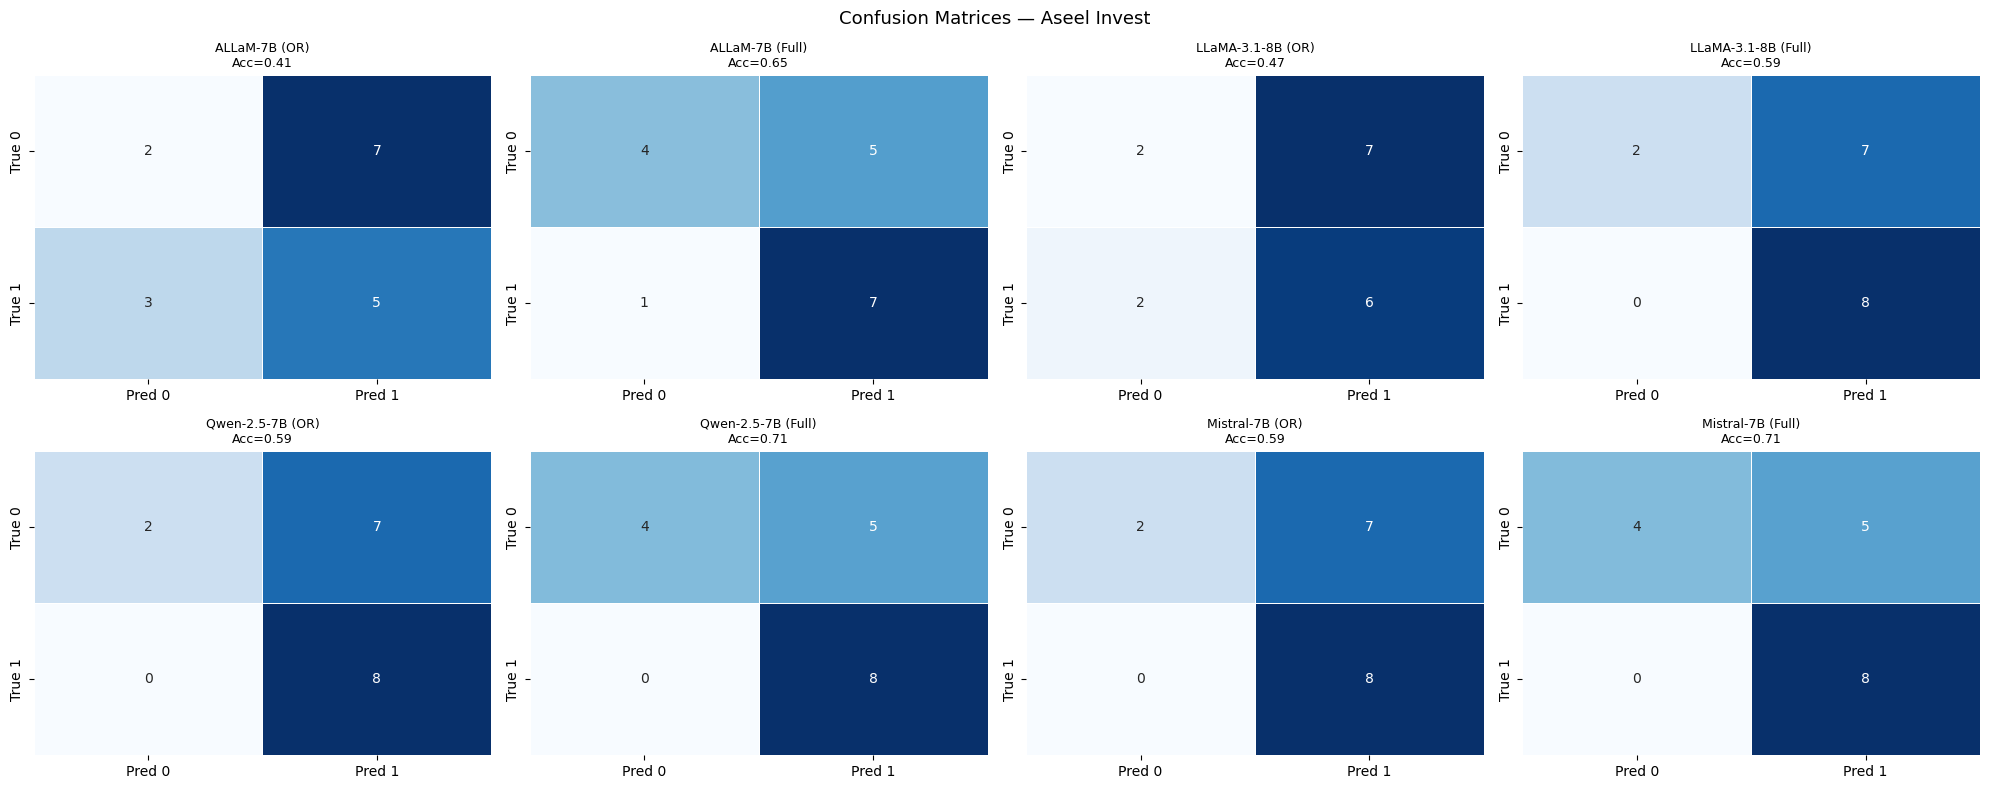

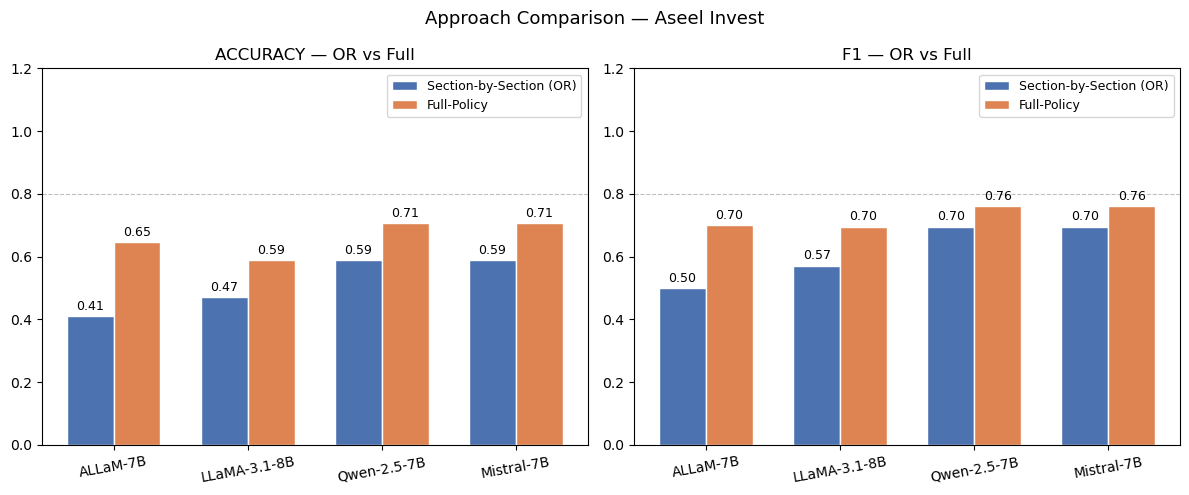

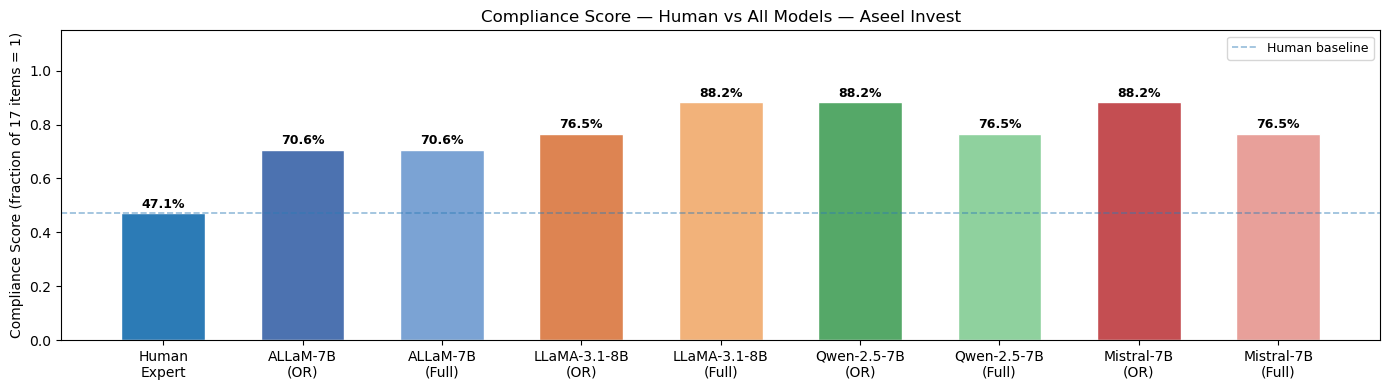

✓ All figures saved for Aseel Invest


In [10]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Sahm

In [42]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Sahm"
POLICY_DOCX_PATH = "user pp/preprocessed/Sahm.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Sahm
Sections: 11 | GT compliant: 9/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 11: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.529 Kappa=0.000
-- Full-Policy --
  Full Final: 10100111111111111 | Acc=0.588 Kappa=0.144
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 8: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  OR Final: 11100111111111110 | Acc=0.588 Kappa=0.144
-- Full-Policy --
  Full Final: 11100111111111111 | Acc=0.647 Kappa=0.261
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
  OR Final: 11111111110110100 | Acc=0.412 Kappa=-0.214
-- Full-Policy --
  Full Final: 11100111011111111 | Acc=0.706 Kappa=0.388
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0]
  OR Final: 11111111111111101 | Acc=0.588 Kappa=0.131
-- Full-Policy --
  Full Final: 11100111111111111 | Acc=0.647 Kappa=0.261
  ✓ Mistral-7B unloaded | VRAM freed

✓ Sahm done — 8 results saved
       model                approach  accuracy 

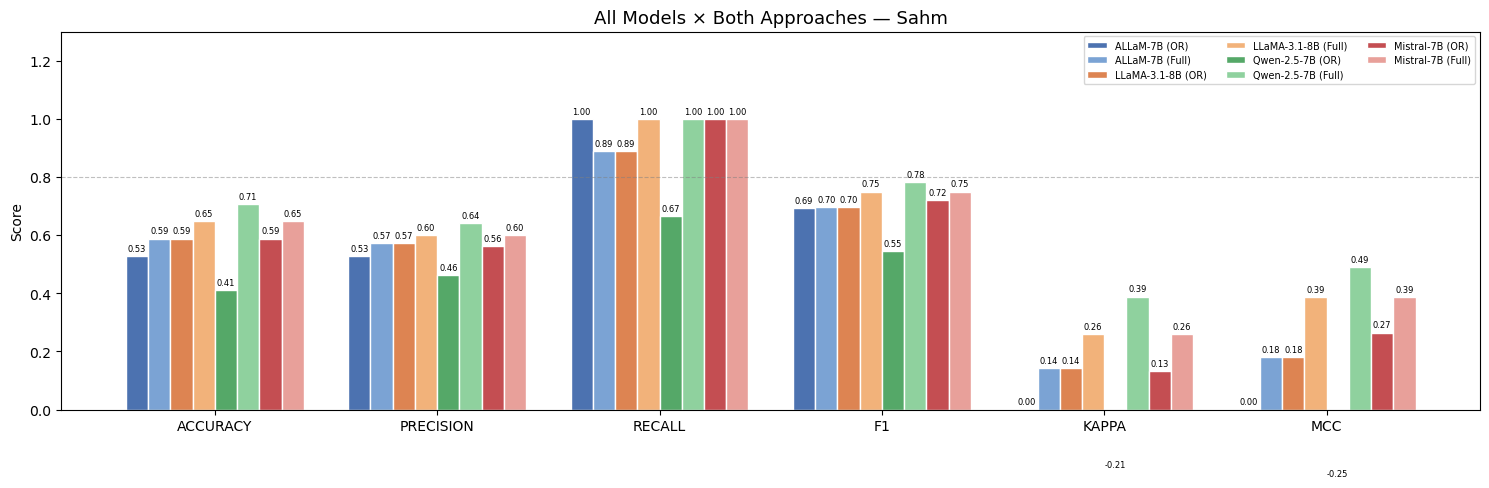

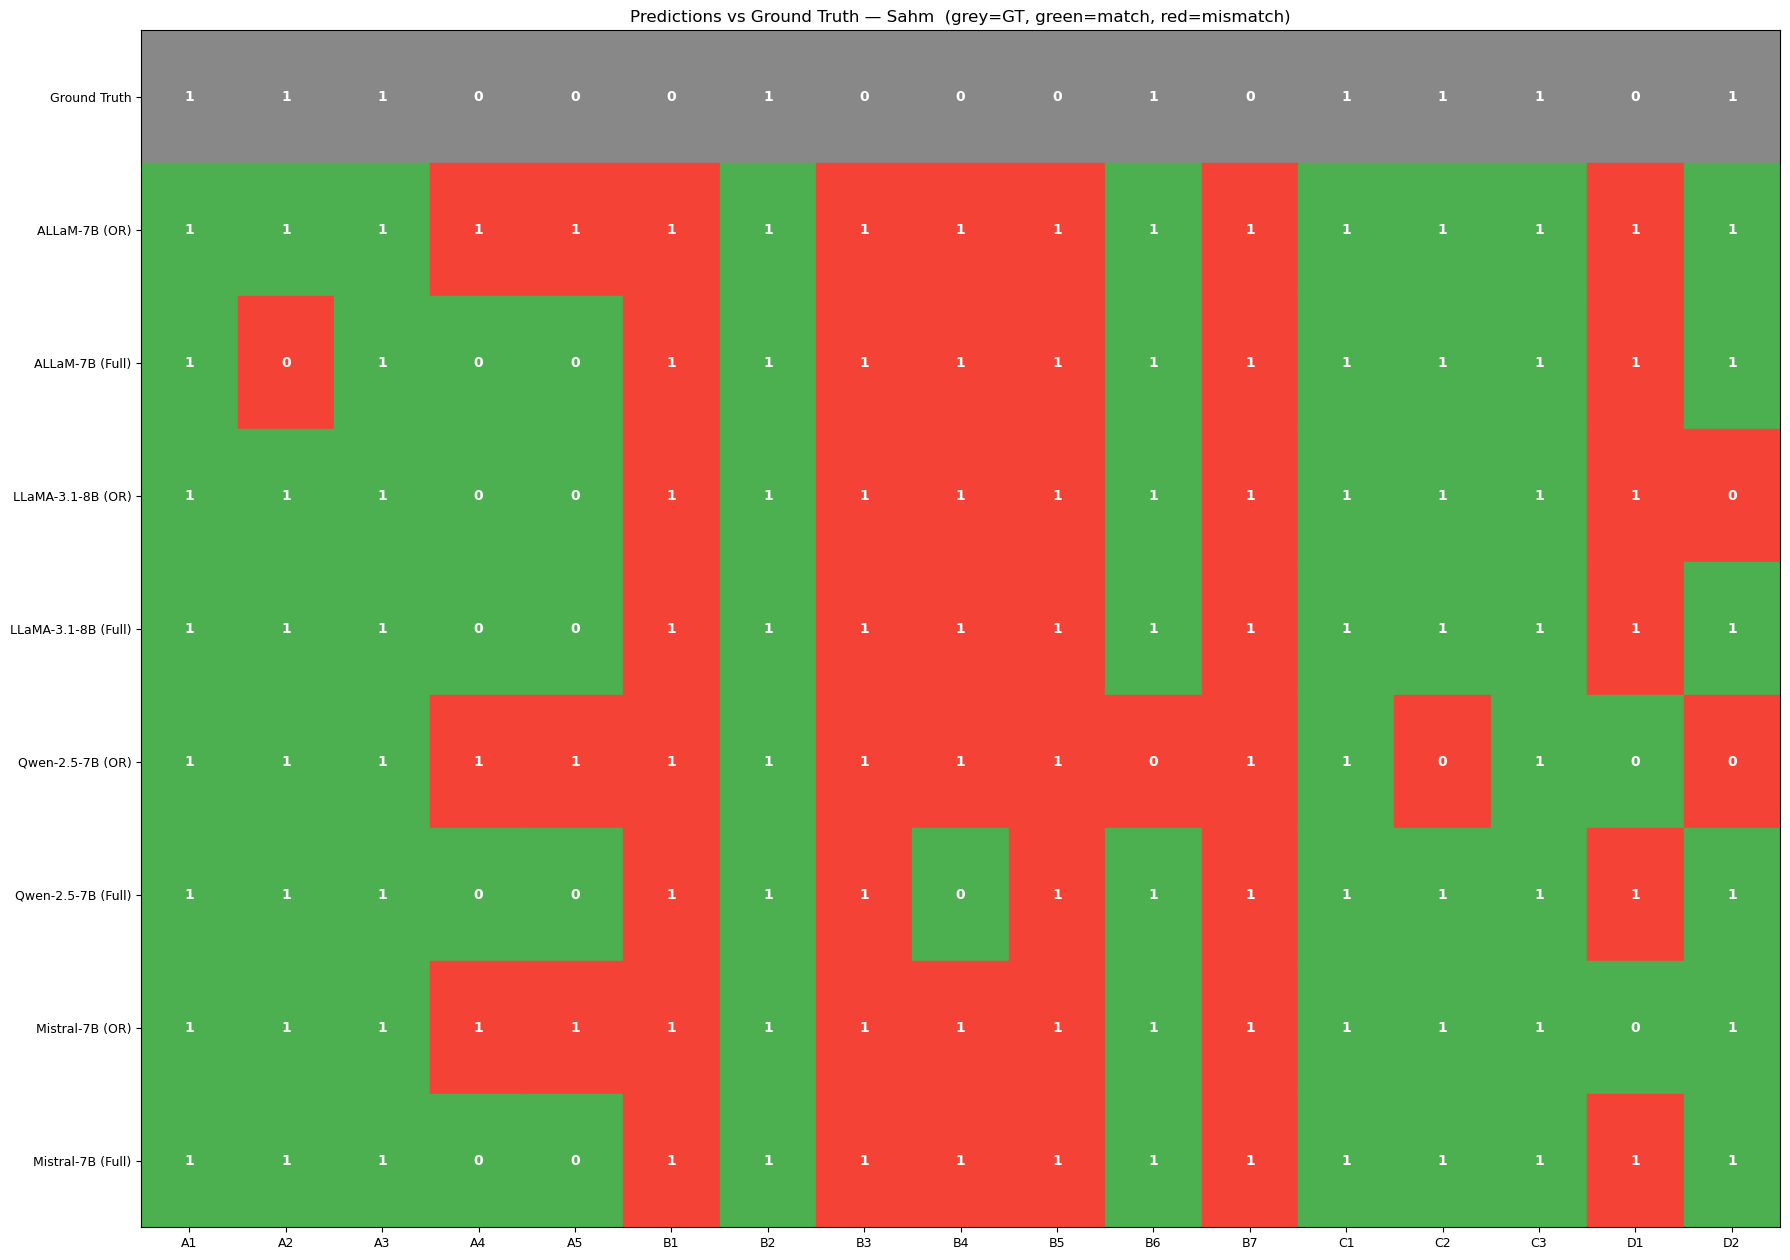

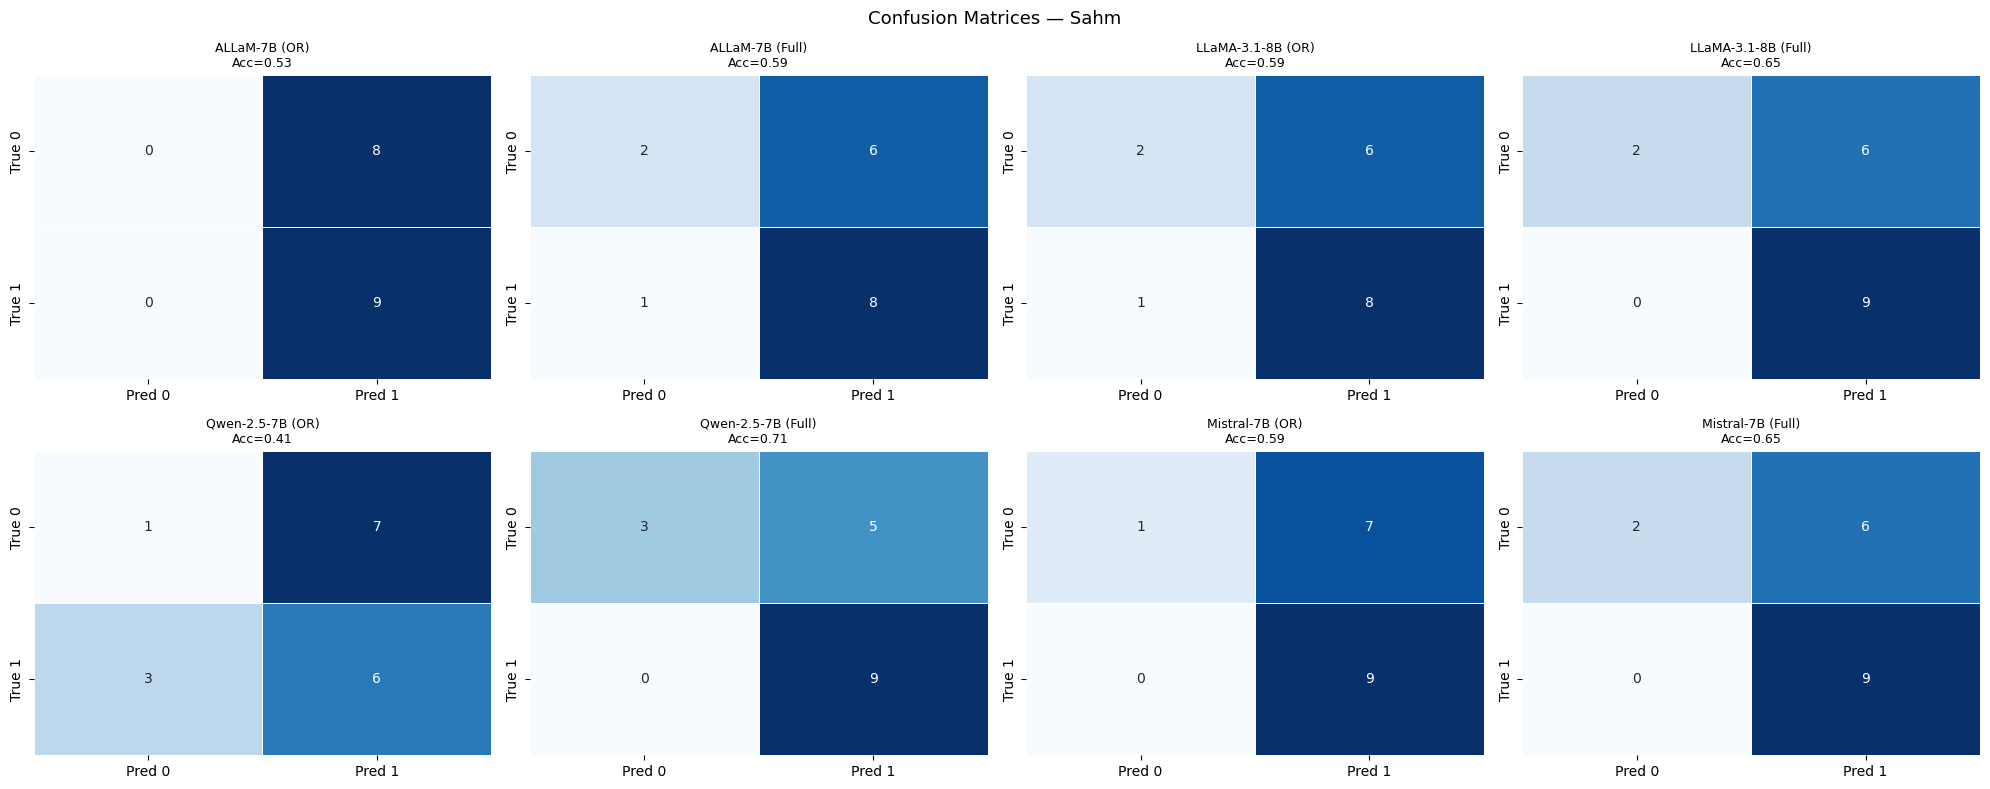

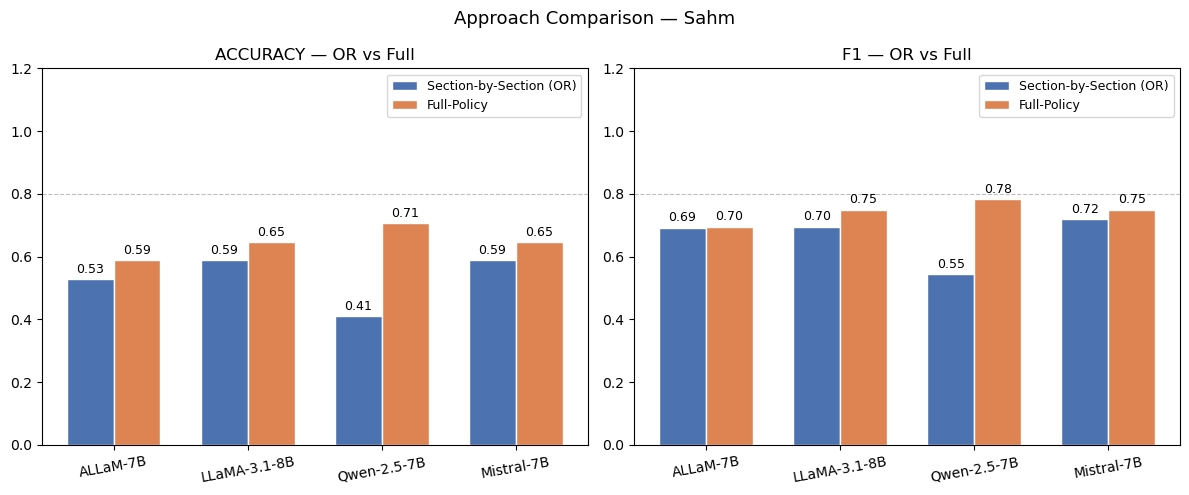

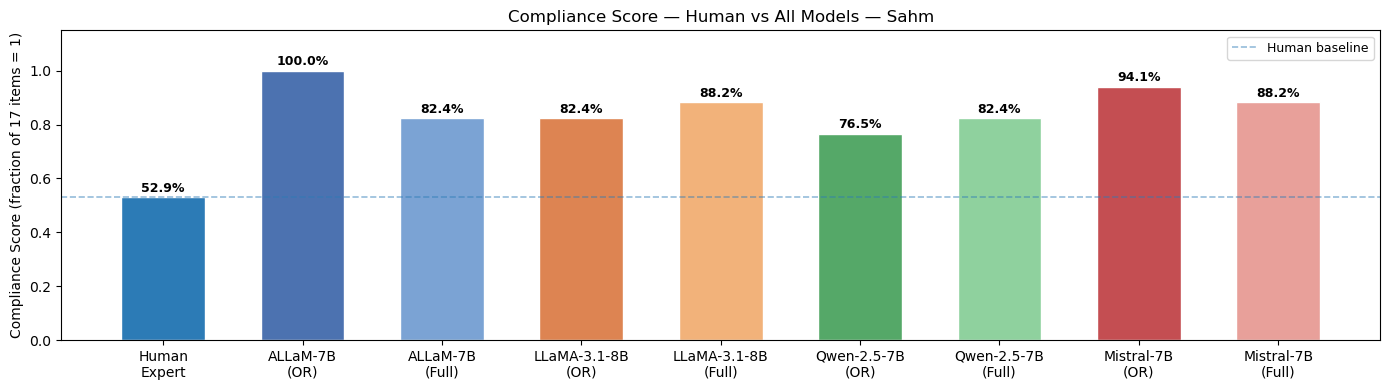

✓ All figures saved for Sahm


In [43]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Hakbah

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Hakbah"
POLICY_DOCX_PATH = "user pp/preprocessed/Hakbah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))
 
print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section (from LLaMA-3 notebook Cell 11) ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11 (UNCHANGED)
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy (from ALLaM v2.2 notebook Cell 20) ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


  APP: Hakbah
Sections: 14 | GT compliant: 12/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 11: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.647 Kappa=-0.109
-

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
  Sec 6: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 9: [0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 10: [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0]
  Sec 13: [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.706 Kappa=0.000
-- Fu

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111110110 | Acc=0.588 Kappa=-0.202
-- Full-Poli

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 4: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0]
  Sec 12: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  OR Final: 11111111111111111 | Acc=0.706 Kappa=0.000
-- 

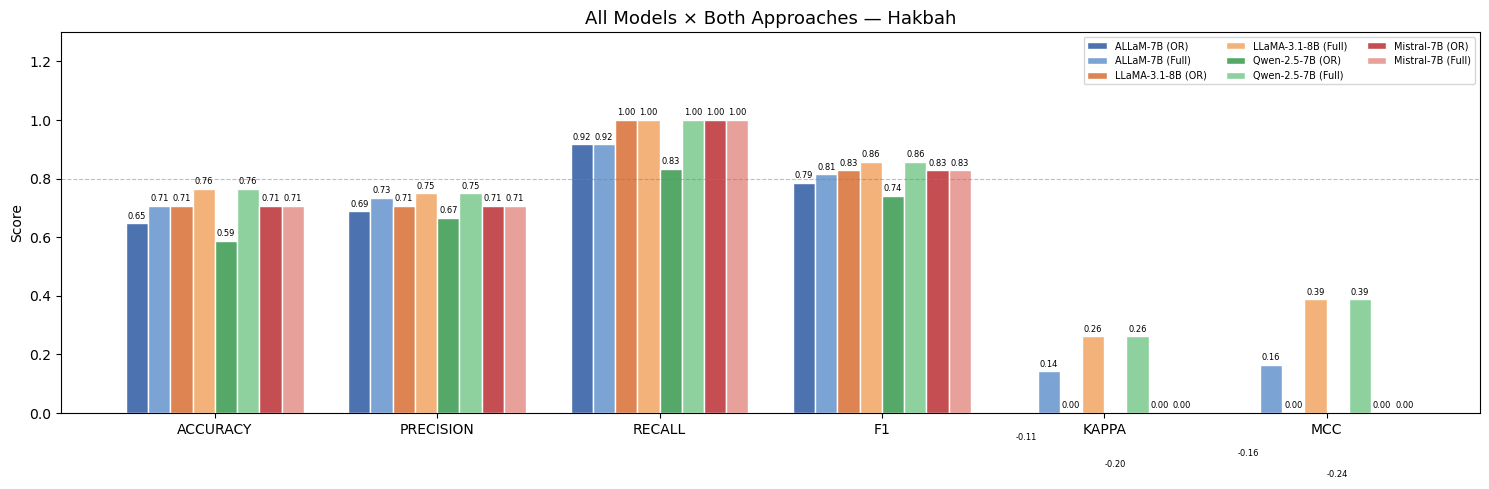

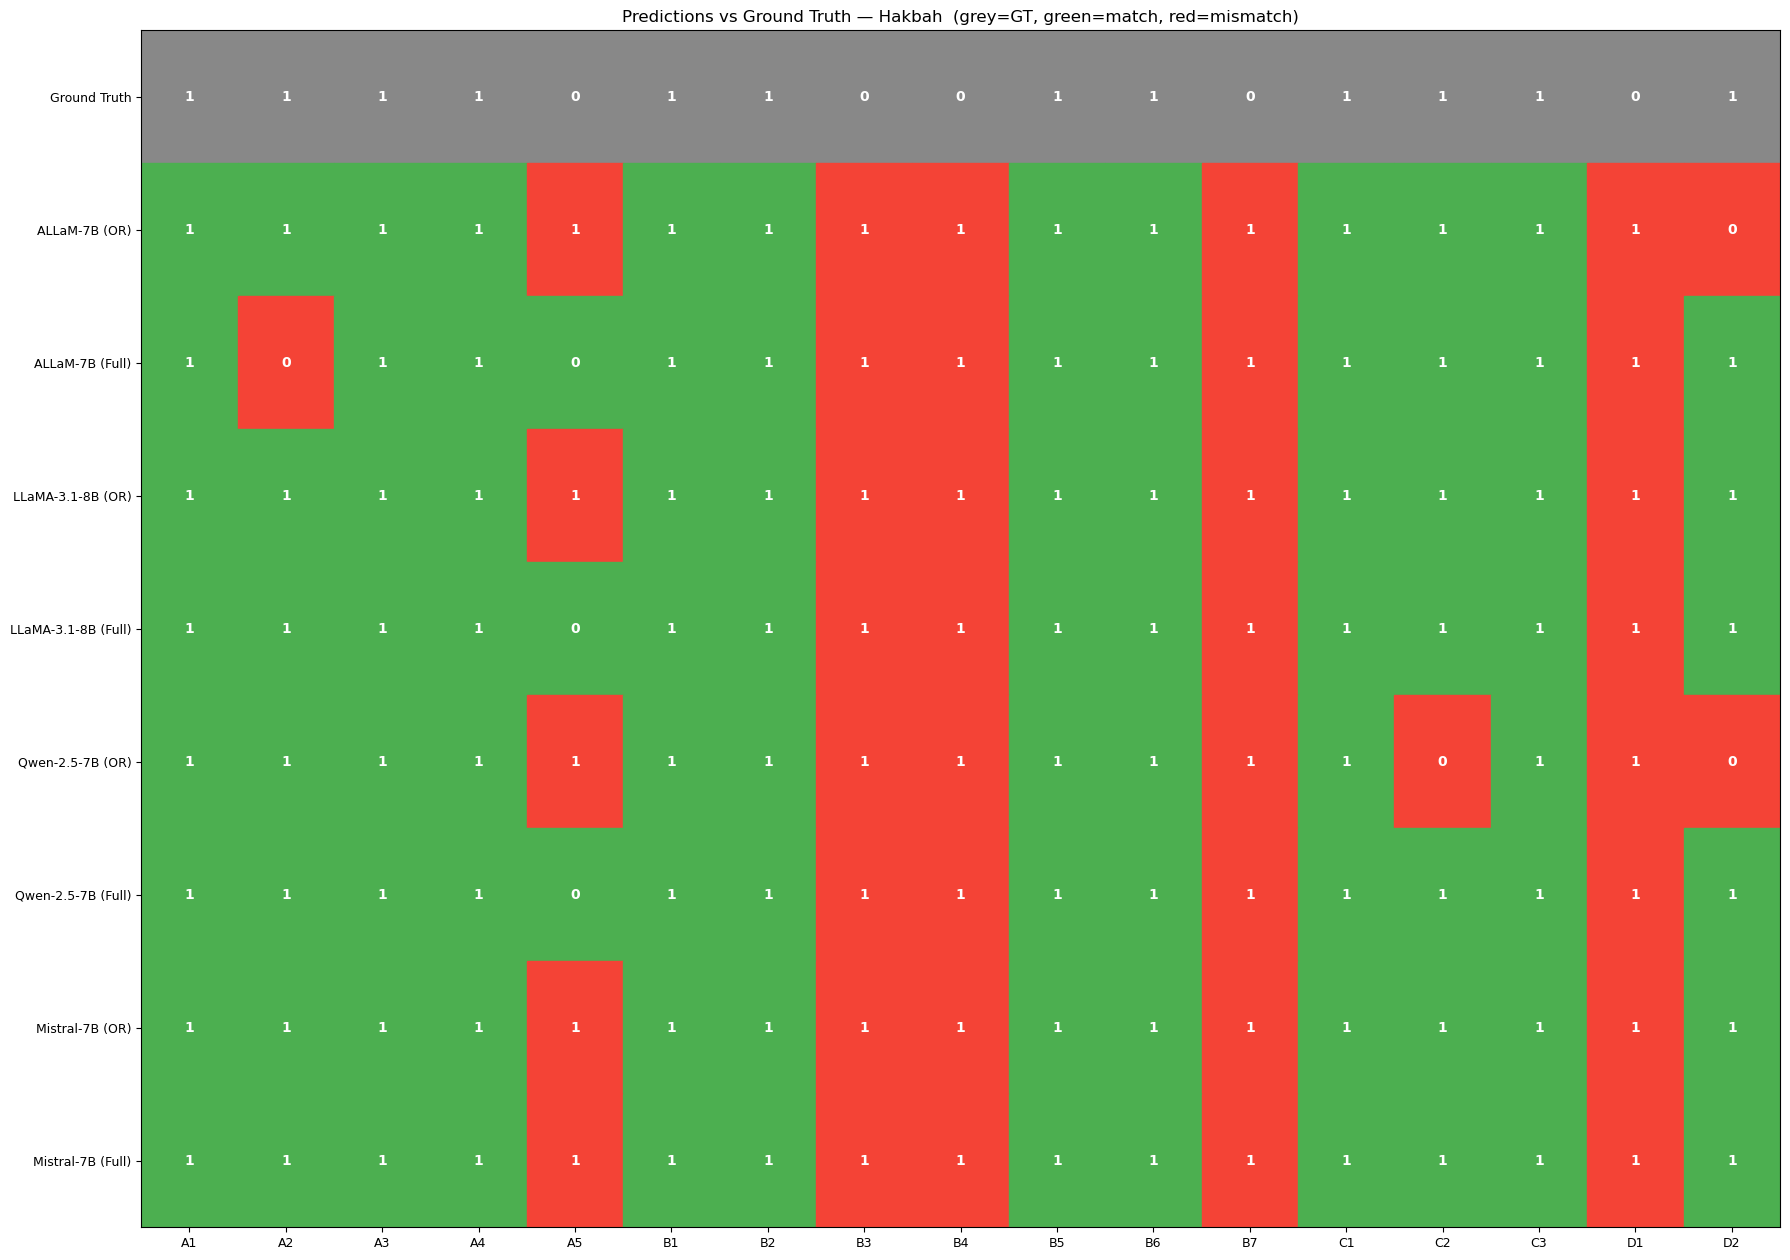

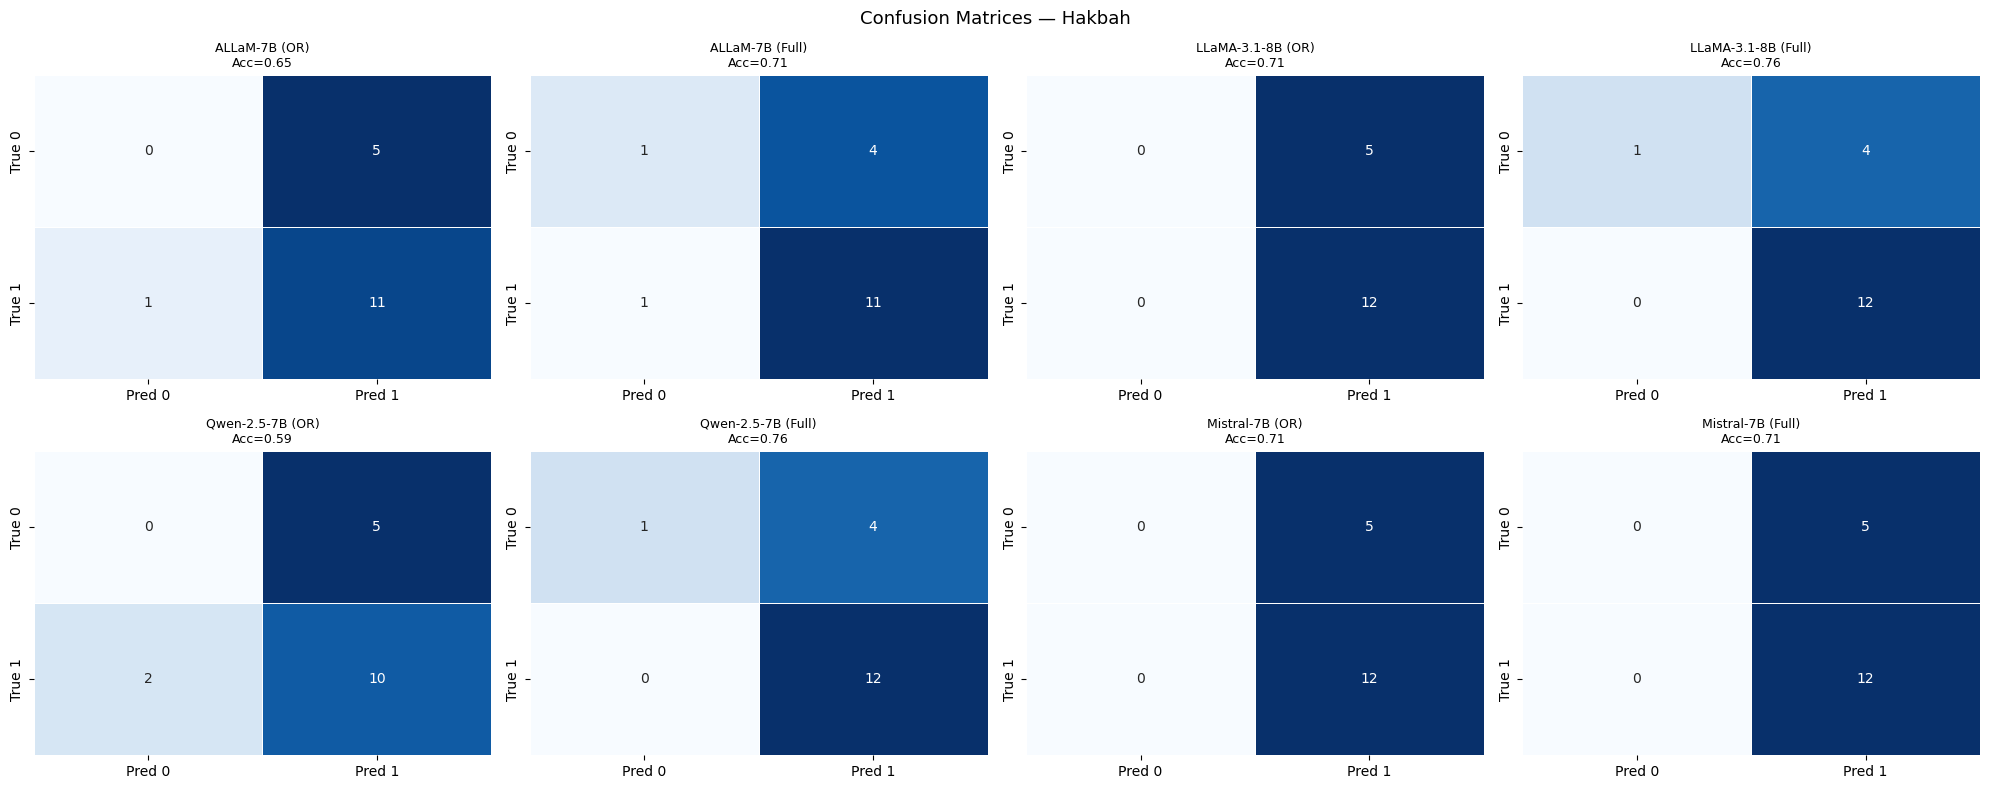

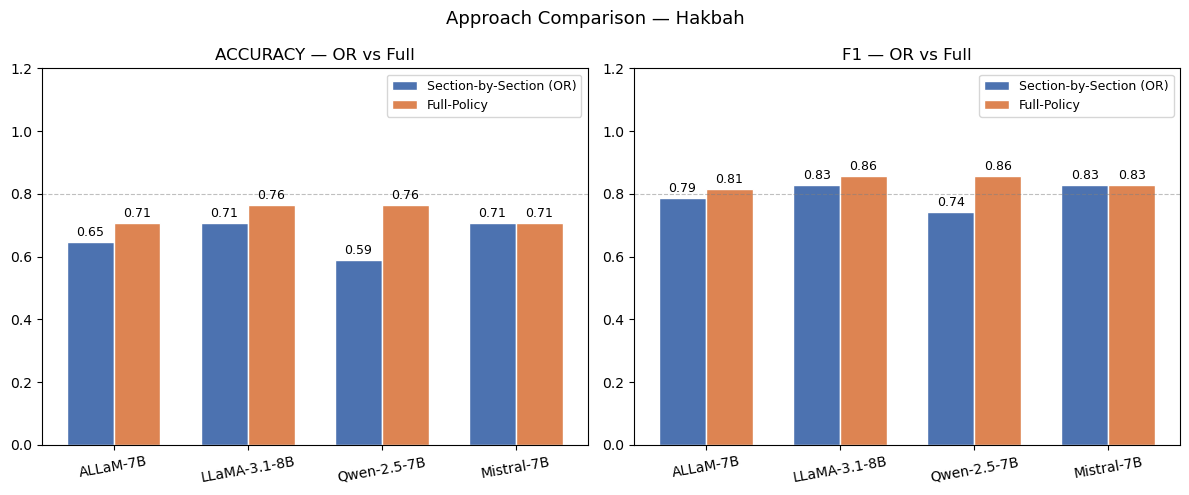

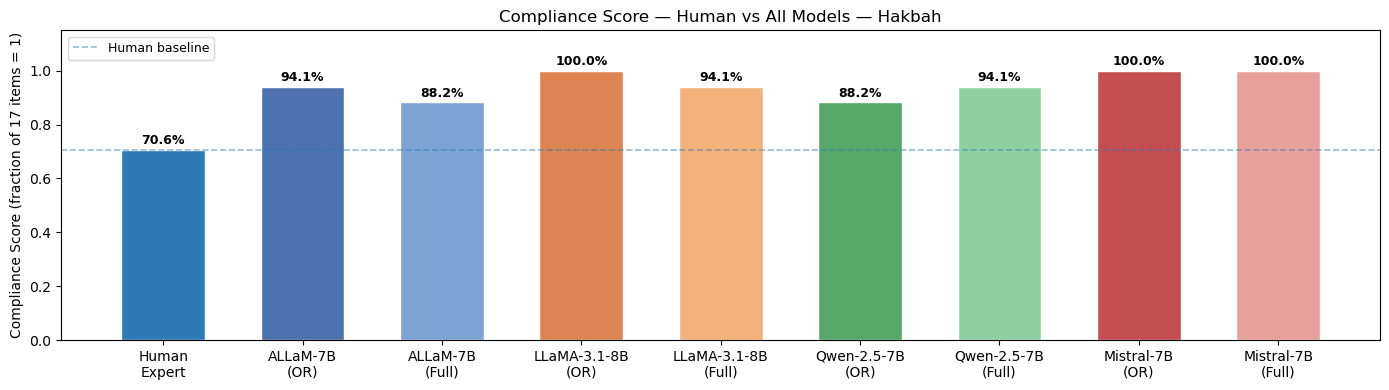

✓ All figures saved for Hakbah


In [12]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Dawul

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Dawul"
POLICY_DOCX_PATH = "user pp/preprocessed/Dawul.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Dawul
Sections: 32 | GT compliant: 8/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (4096). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


...

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0]
  Sec 15: [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 9: [1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

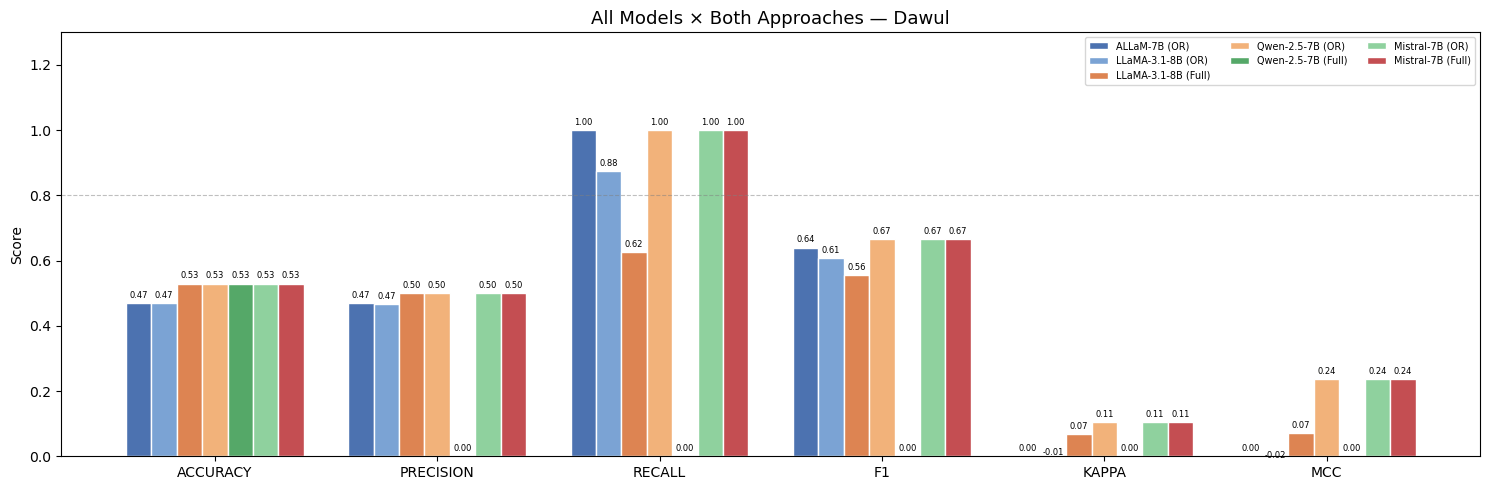

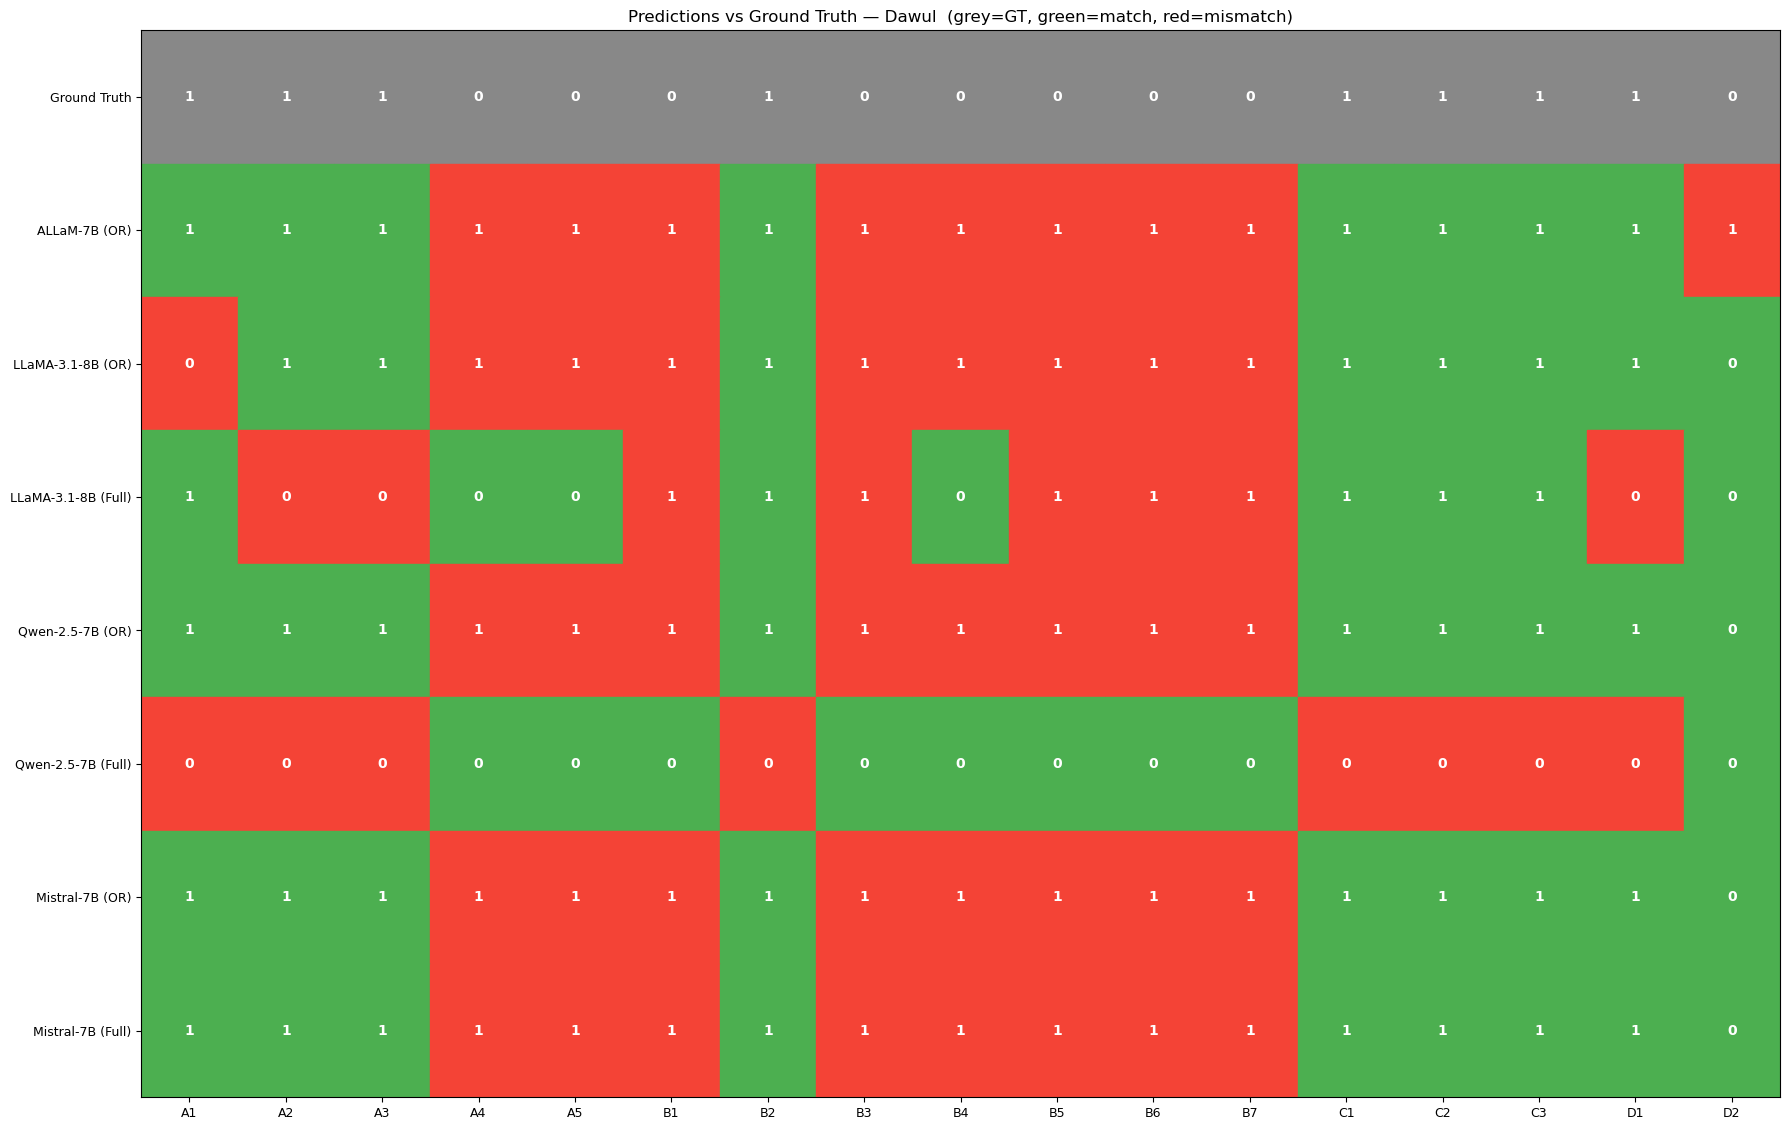

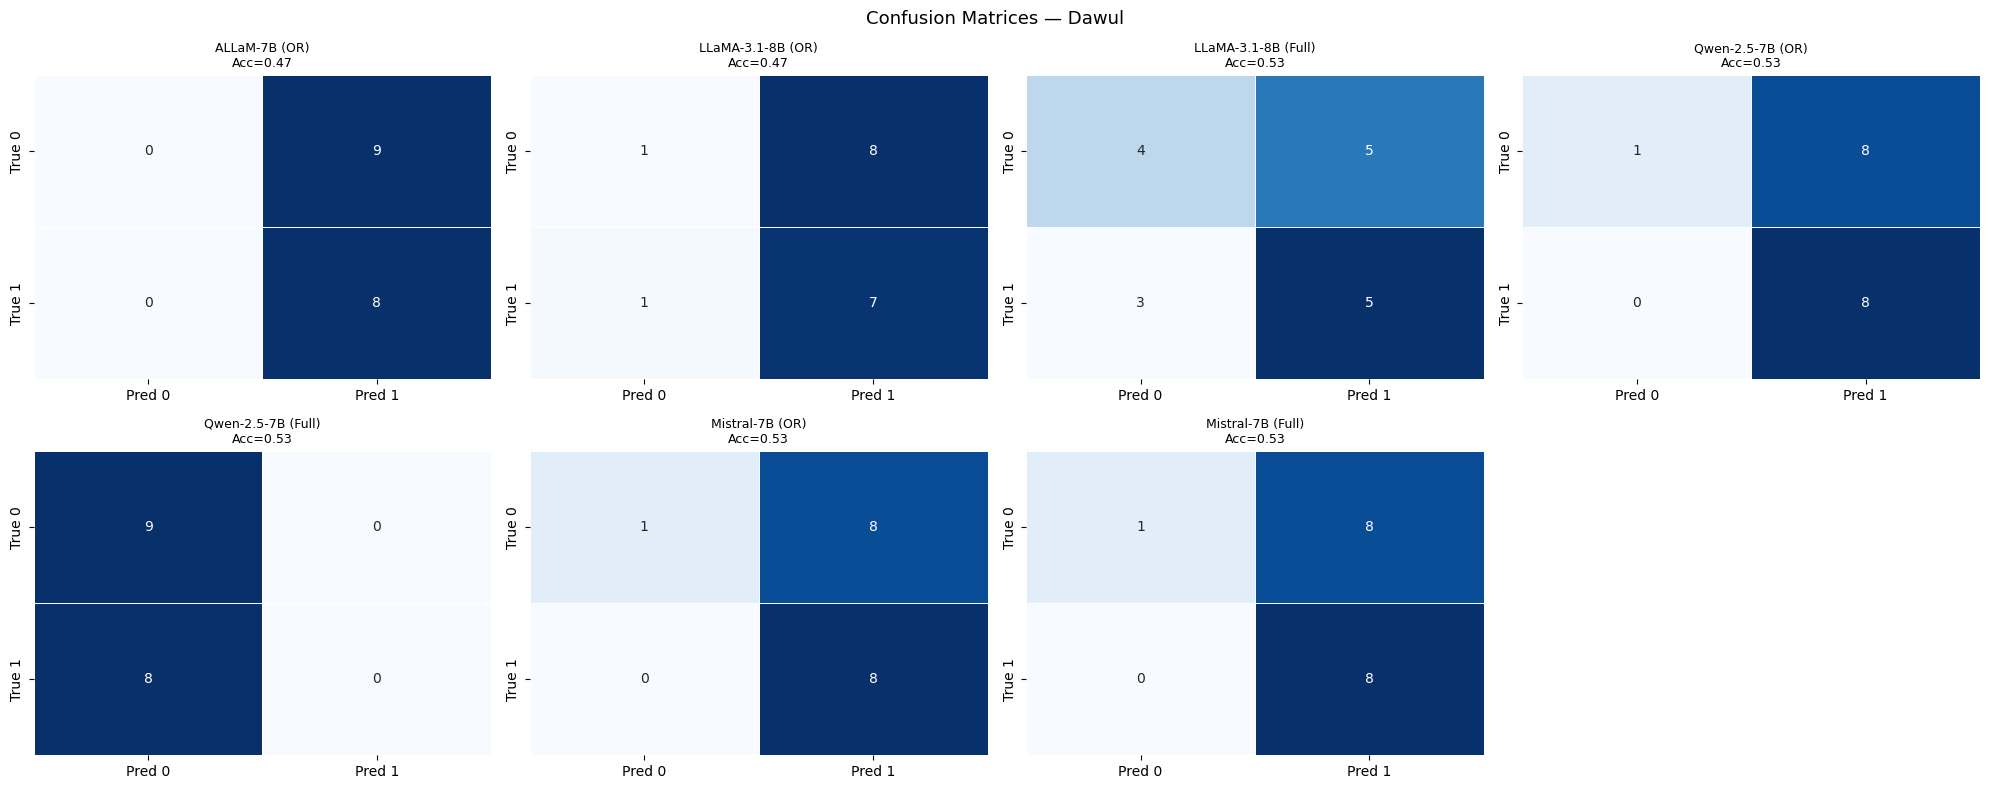

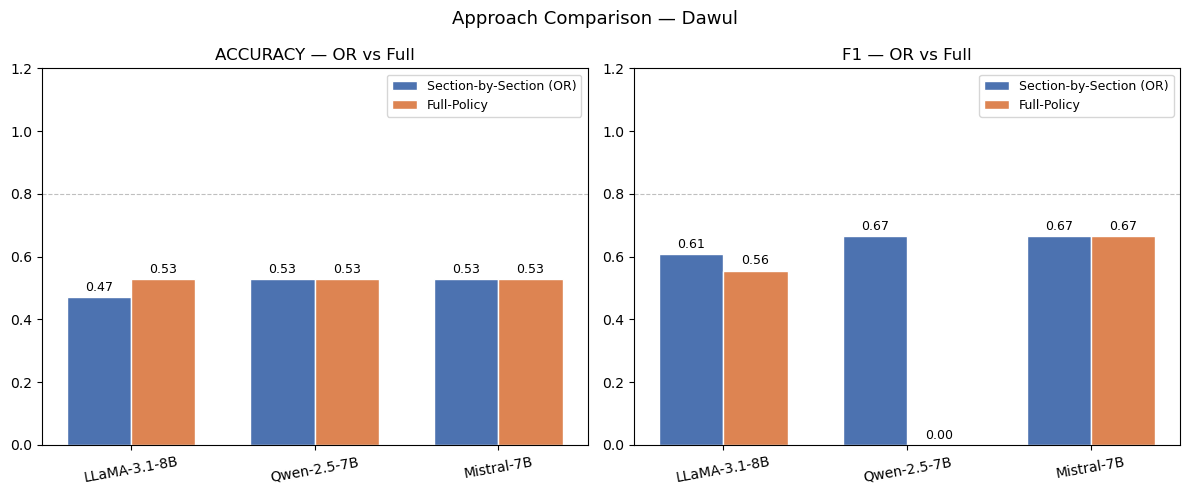

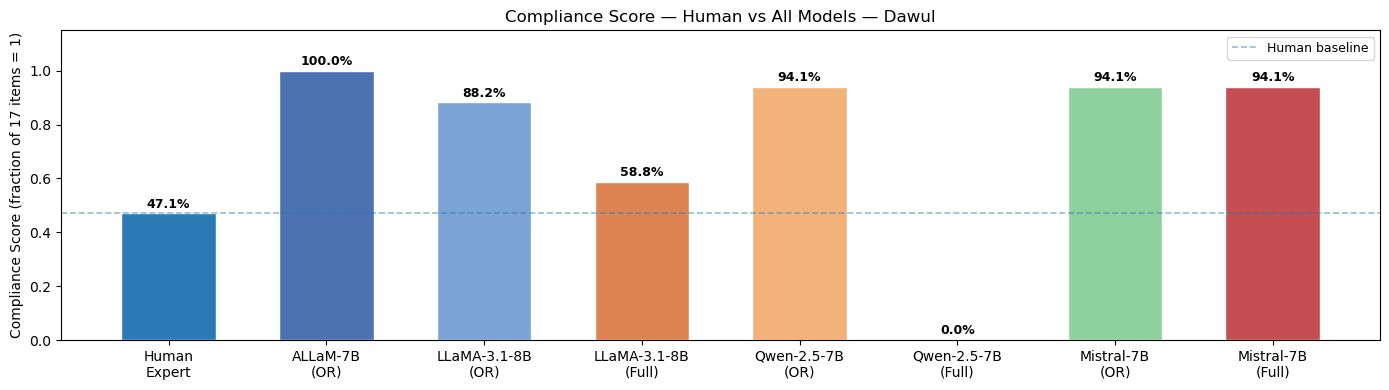

✓ All figures saved for Dawul


In [8]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Sukuk

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Sukuk"
POLICY_DOCX_PATH = "user pp/preprocessed/Sukuk.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Sukuk
Sections: 11 | GT compliant: 10/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111100110 | Acc=0.529 Kappa=-0.062
-- Full-Policy --
  Full Final: 11111111111111111 | Acc=0.588 Kappa=0.000
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111111100 | Acc=0.706 Kappa=0.320
-- Full-Policy --
  Full Final: 11111111111111101 | Acc=0.647 Kappa=0.164
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 7: [1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  Sec 10: [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0]
  Sec 11: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11110110111111110 | Acc=0.765 Kappa=0.469
-- Full-Policy --
  Full Final: 11100111111111101 | Acc=0.647 Kappa=0.203
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111100 | Acc=0.706 Kappa=0.320
-- Full-Policy --
  Full Final: 11100111111111101 | Acc=0.647 Kappa=0.203
  ✓ Mistral-7B unloaded | VRAM freed

✓ Sukuk done — 8 results saved
       model                approach  accuracy

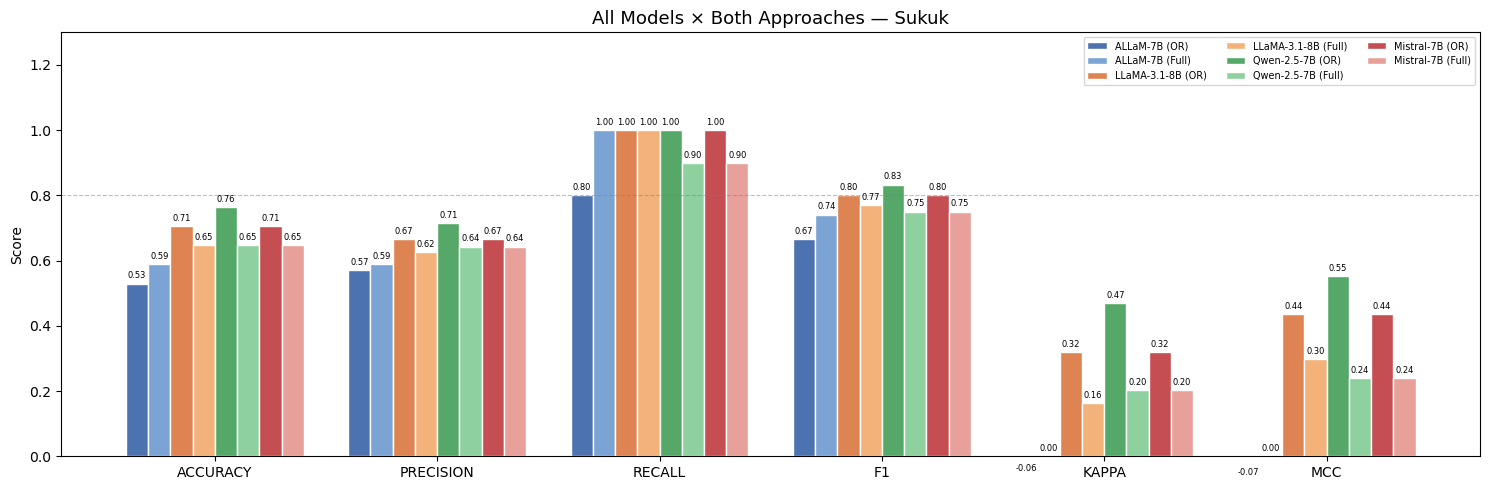

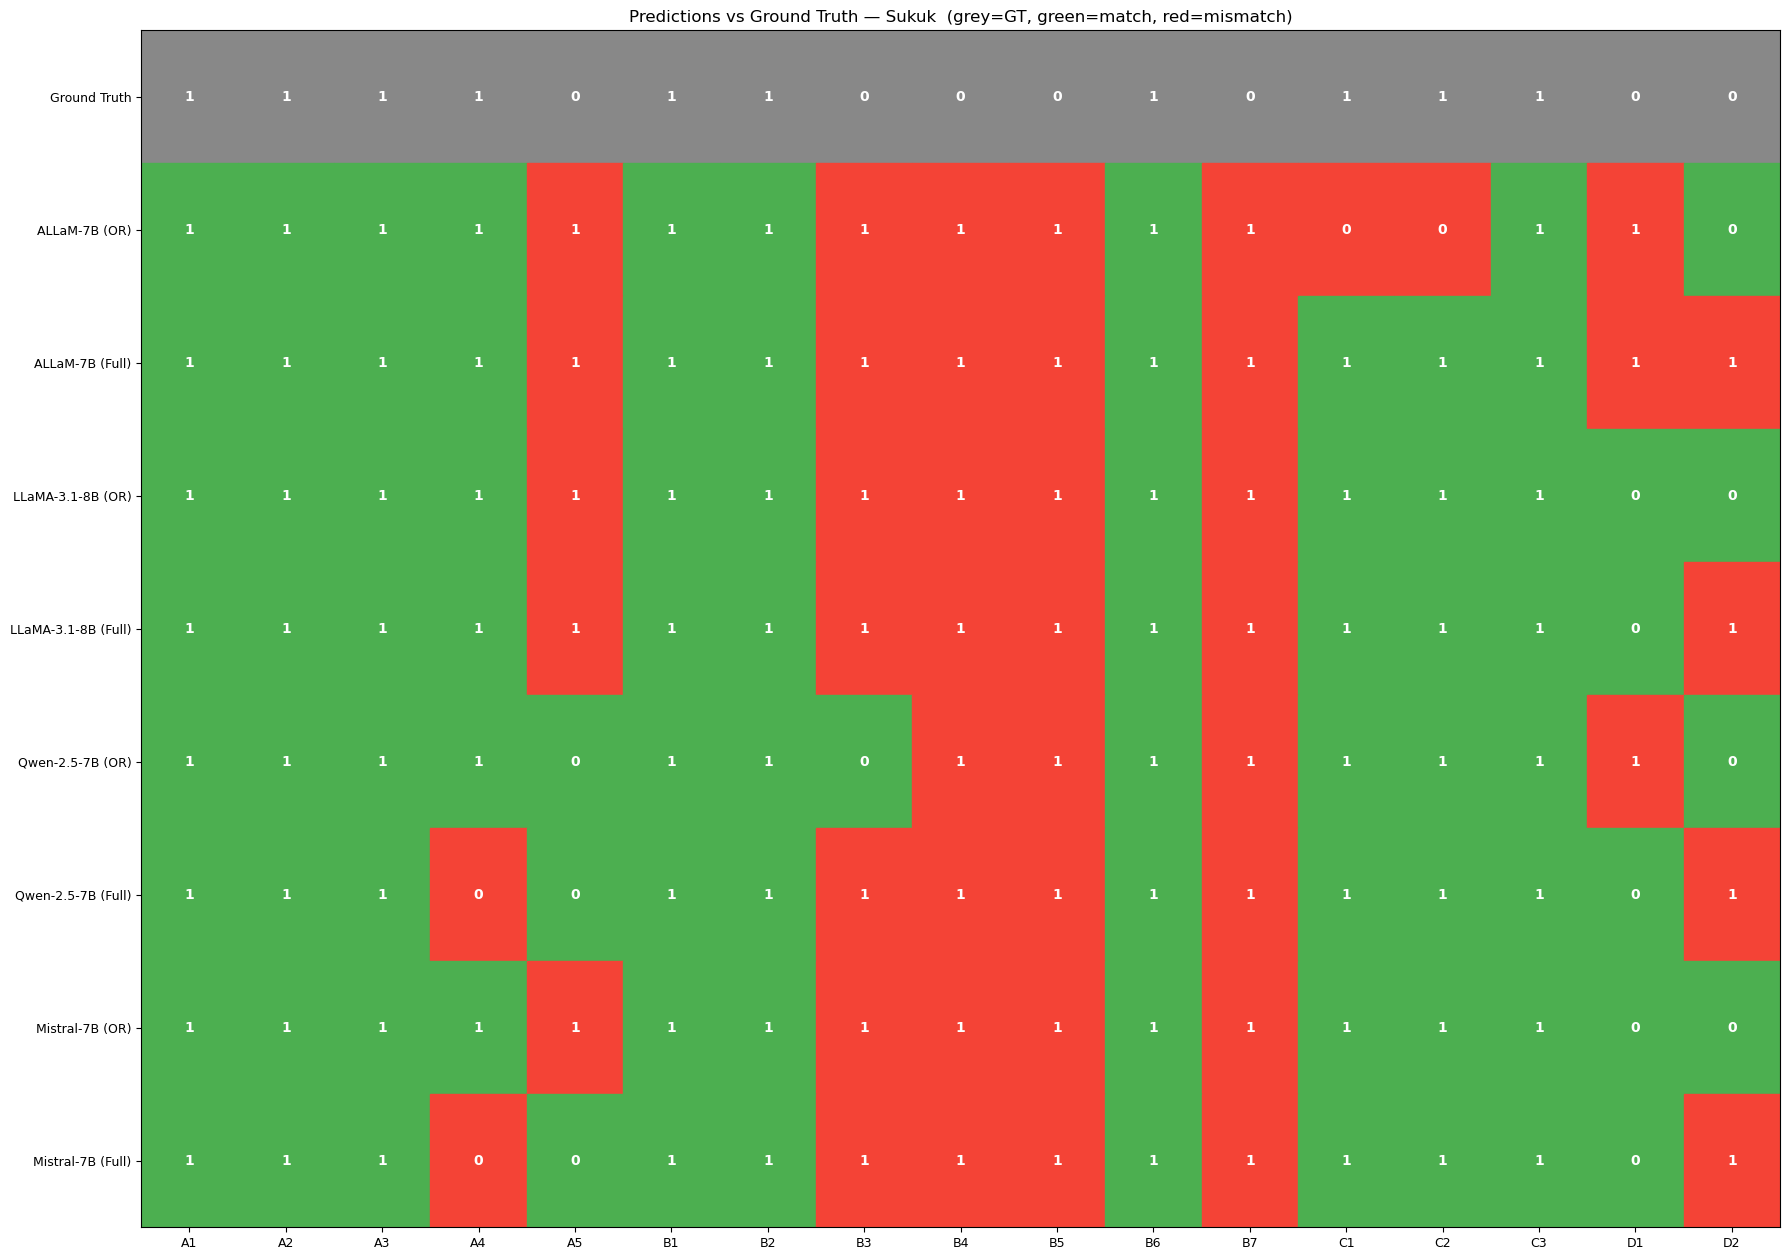

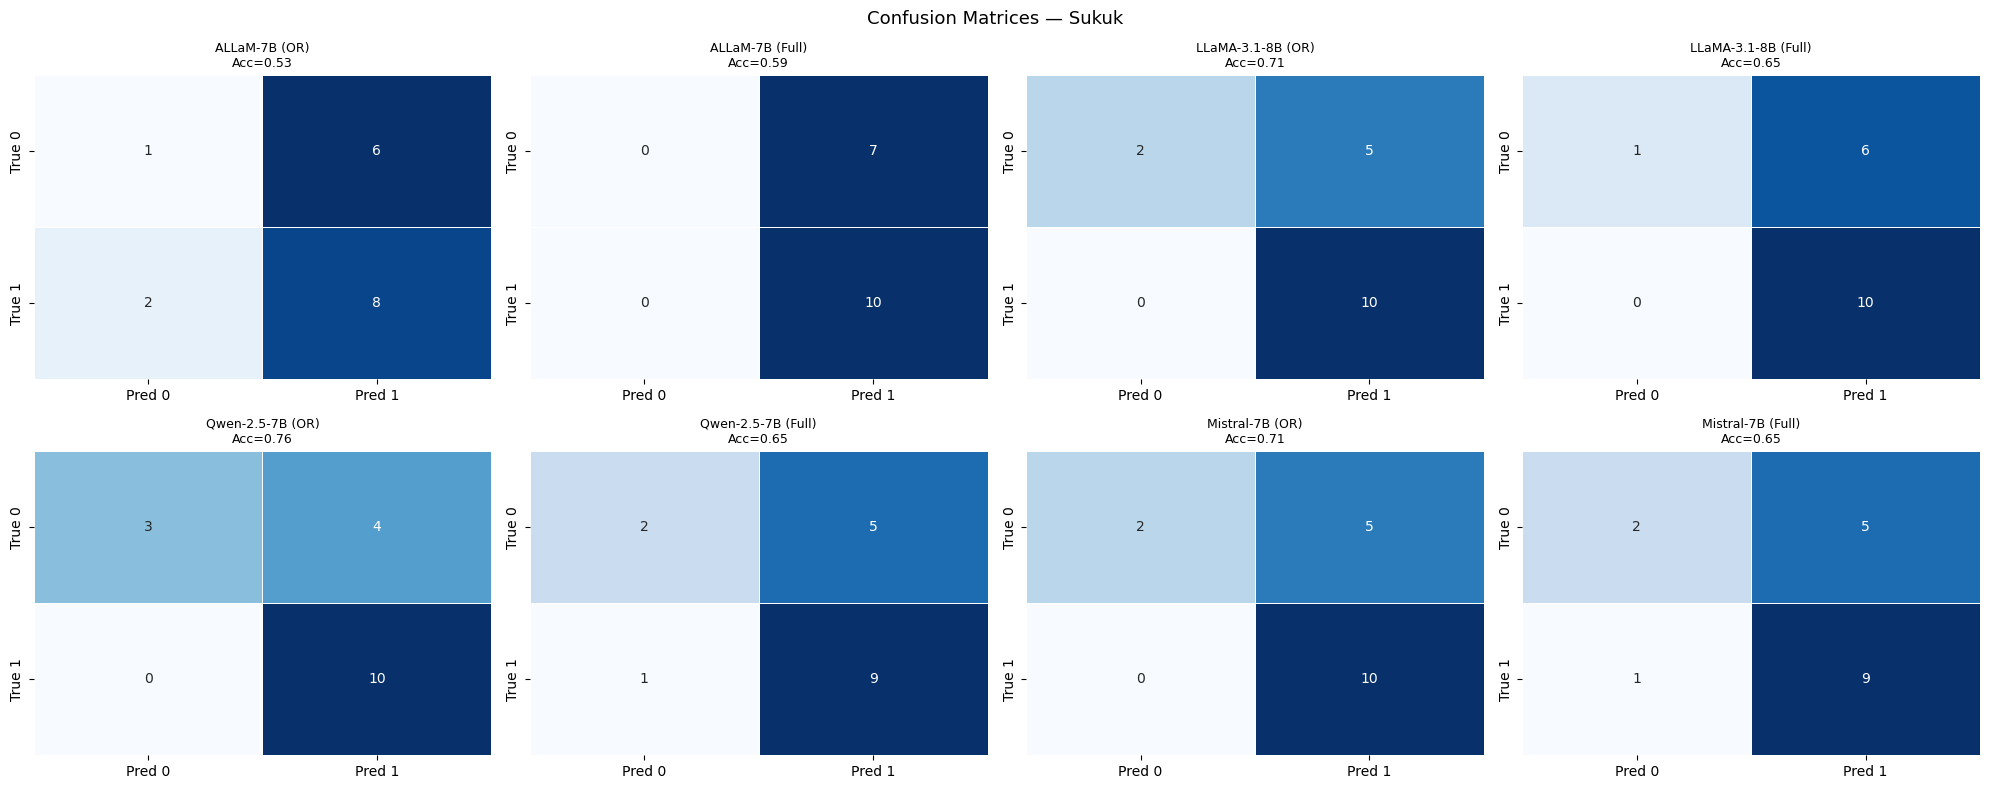

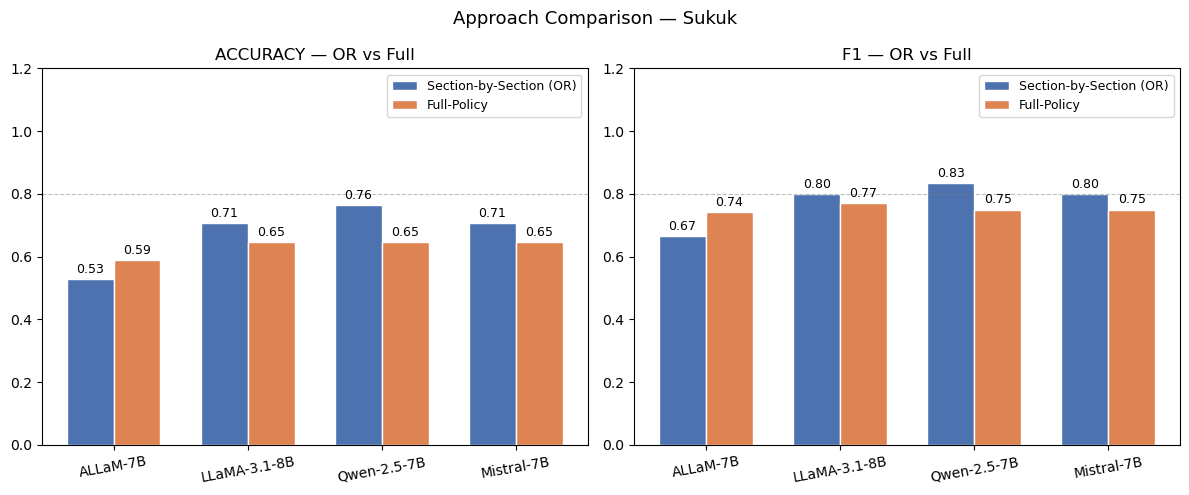

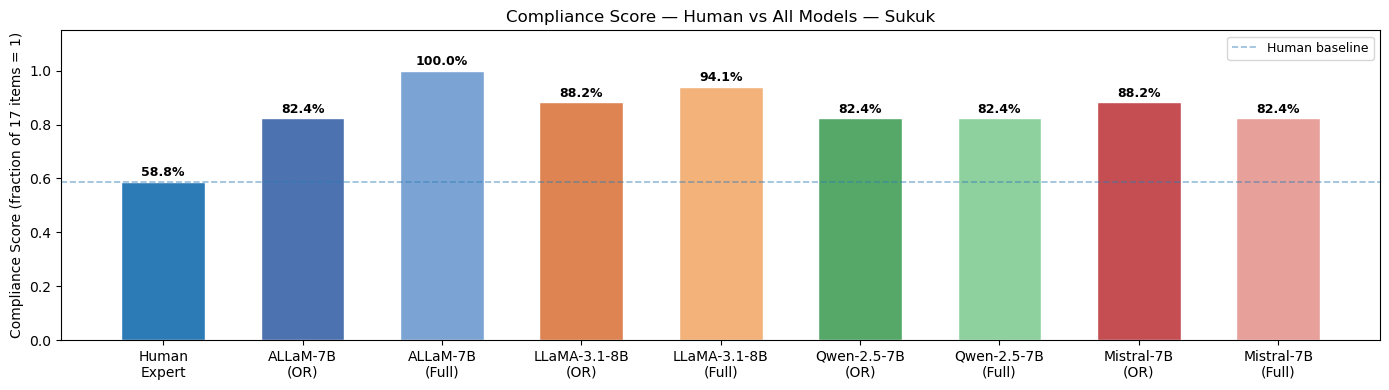

✓ All figures saved for Sukuk


In [10]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Awaed

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Awaed"
POLICY_DOCX_PATH = "user pp/preprocessed/Awaed.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Awaed
Sections: 10 | GT compliant: 7/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111100000 | Acc=0.471 Kappa=0.013
-- Full-Policy --
  Full Final: 00000111010000000 | Acc=0.471 Kappa=-0.168
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  Sec 3: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  Sec 5: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0]
  OR Final: 01000111011111110 | Acc=0.412 Kappa=-0.118
-- Full-Policy --


...

  Full Final: 1NoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNoneNone | Acc=1.000 Kappa=0.000
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
  Sec 3: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11100111000100010 | Acc=0.588 Kappa=0.168
-- Full-Policy --
  Full Final: 00000100000100000 | Acc=0.471 Kappa=-0.224
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  Sec 3: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111000100100 | Acc=0.706 Kappa=0.430
-- Full-Policy --
  Full Final: 11111111111111110 | Acc=0.471 Kappa=0.084
  ✓ Mistral-7B unloaded | VRAM freed

✓ Awaed done — 8 results saved
       model                approach  accuracy       f1     kappa
    ALLaM-7B Section-by-Section (OR)  0.47

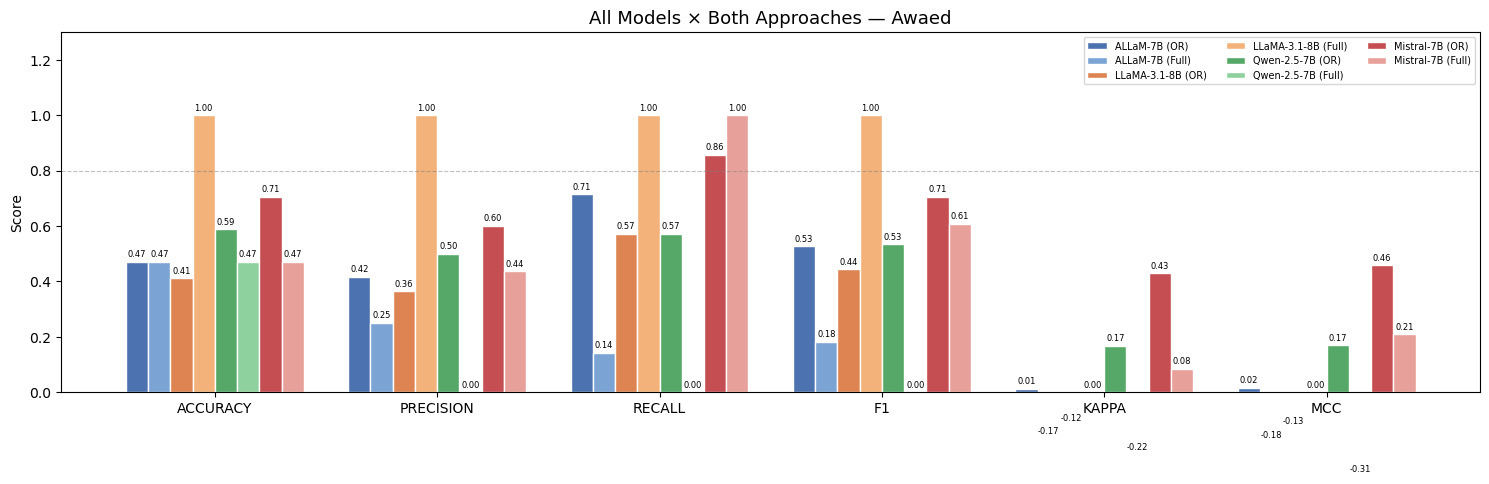

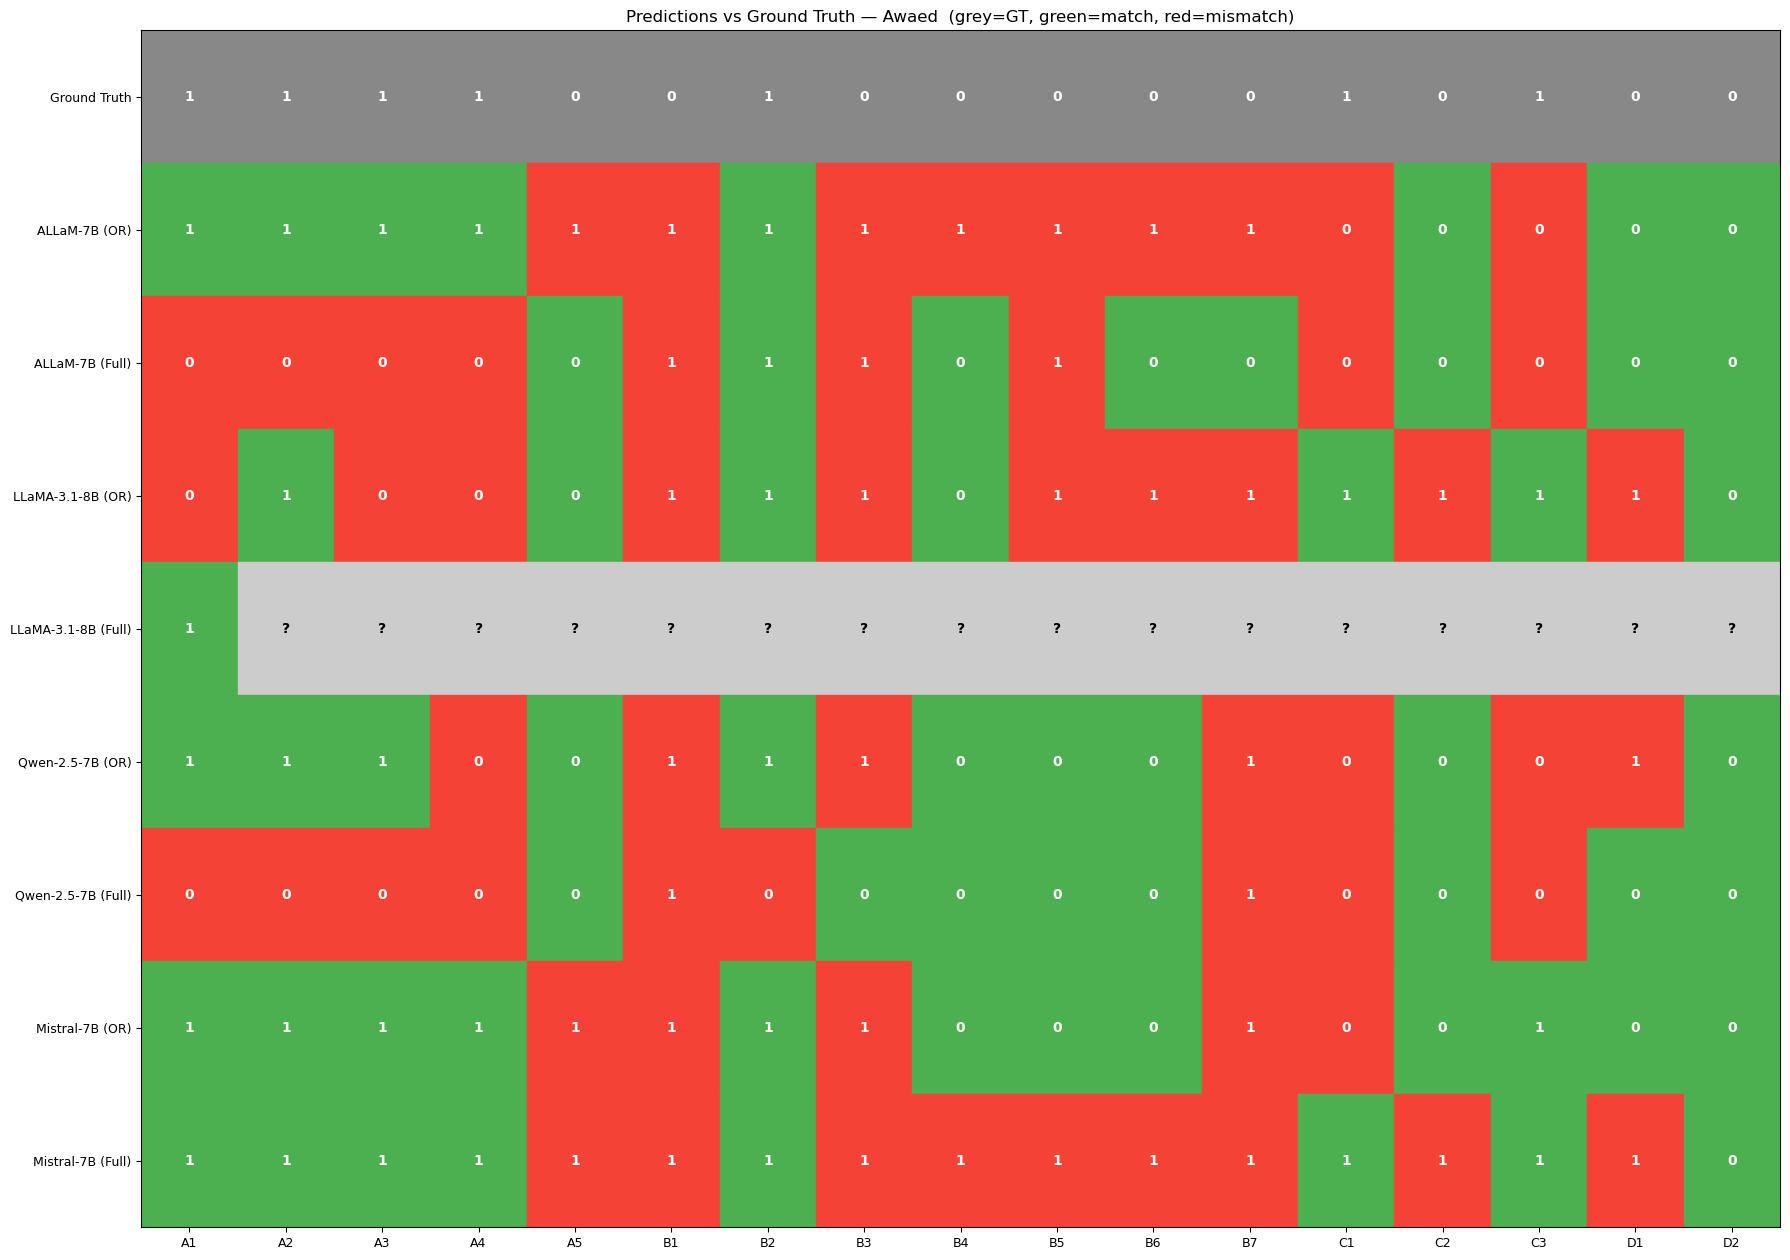

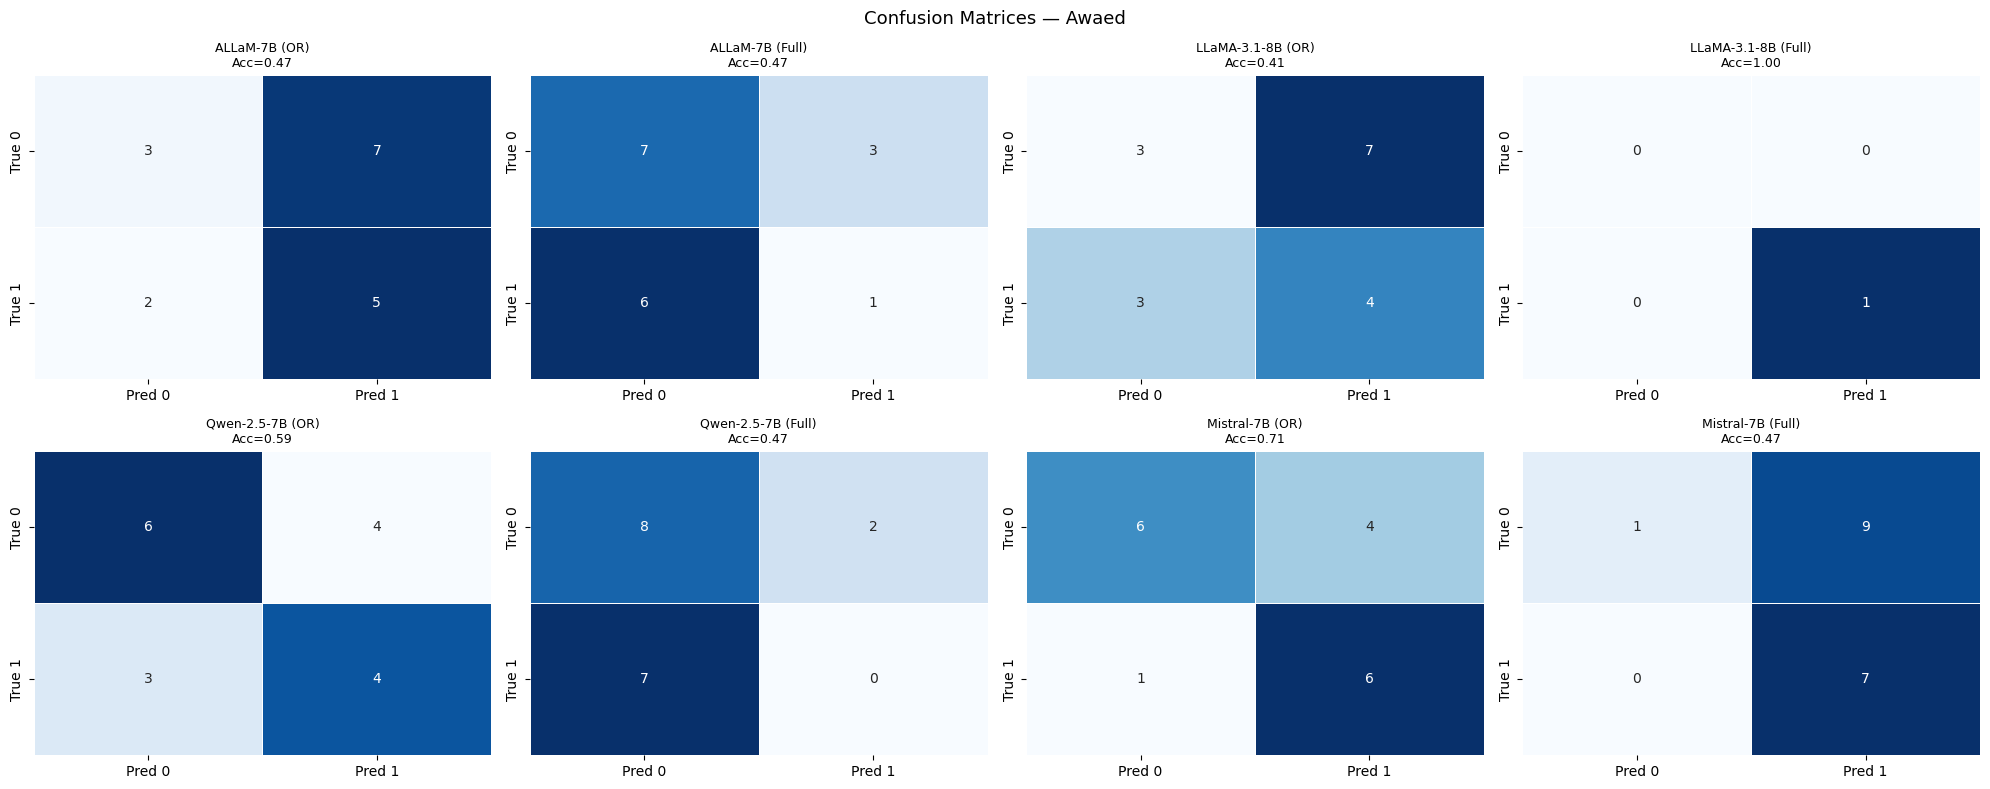

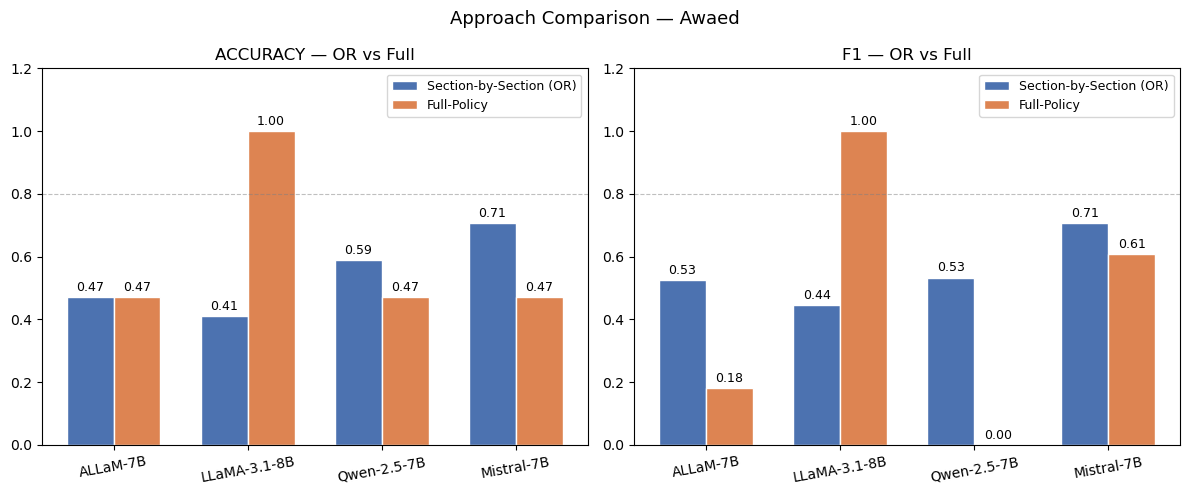

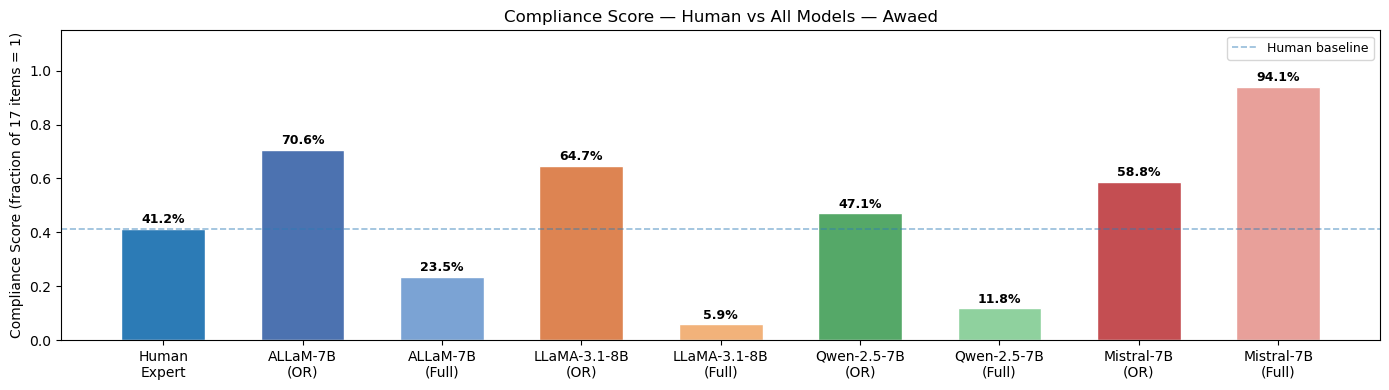

✓ All figures saved for Awaed


In [12]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Abyan

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Abyan"
POLICY_DOCX_PATH = "user pp/preprocessed/Abyan.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Abyan
Sections: 6 | GT compliant: 3/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111100000 | Acc=0.235 Kappa=-0.208
-- Full-Policy --
  Full Final: 10000111001011100 | Acc=0.706 Kappa=0.388
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 3: [0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0]
  OR Final: 00100111111111111 | Acc=0.412 Kappa=0.124
-- Full-Policy --
  Full Final: 11010111111111101 | Acc=0.353 Kappa=0.088
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 3: [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11110111111111001 | Acc=0.353 Kappa=0.088
-- Full-Policy --
  Full Final: 11000111111111101 | Acc=0.412 Kappa=0.124
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111110100 | Acc=0.235 Kappa=-0.078
-- Full-Policy --
  Full Final: 11111111111111101 | Acc=0.235 Kappa=0.026
  ✓ Mistral-7B unloaded | VRAM freed

✓ Abyan done — 8 results saved
       model                approach  accuracy       f1     kappa
    ALLaM-7B Section-by-Section (OR)  0.235294 0.133333 -0.207650
    ALLaM-7B             Full-Policy  0.705882 0.545455  0.388489
LLaMA-3.1-8B Section-by-Section (OR)  0.411765 0.375000  0.123711
LLaMA-3.1-8B             Full-Policy  0.352941 0.352941  0.087805
 Qwen-2.5-7B Section-b

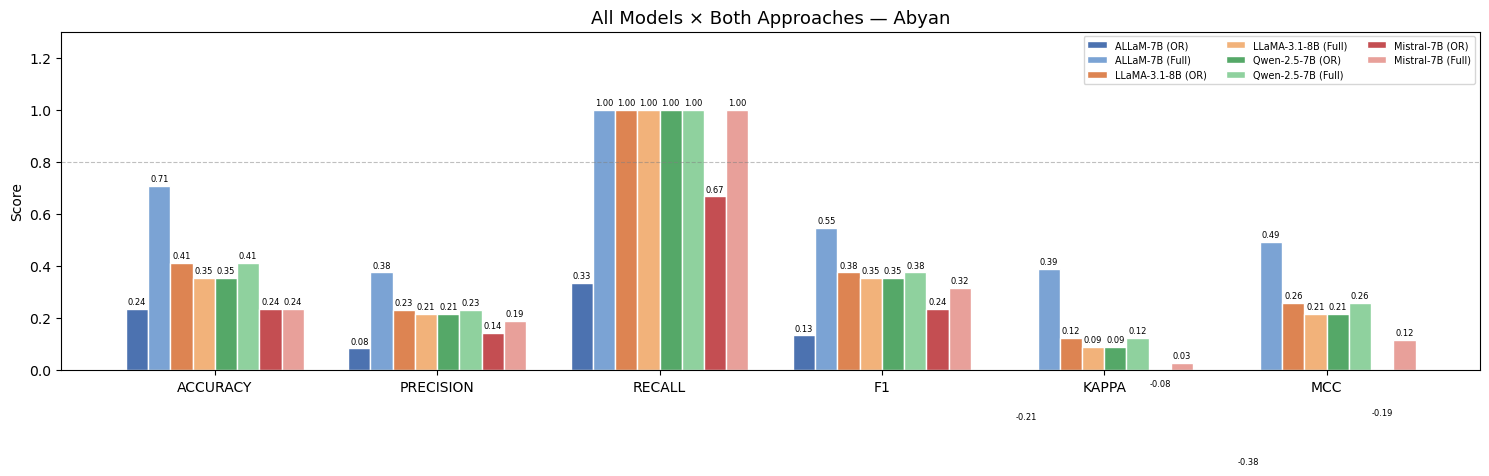

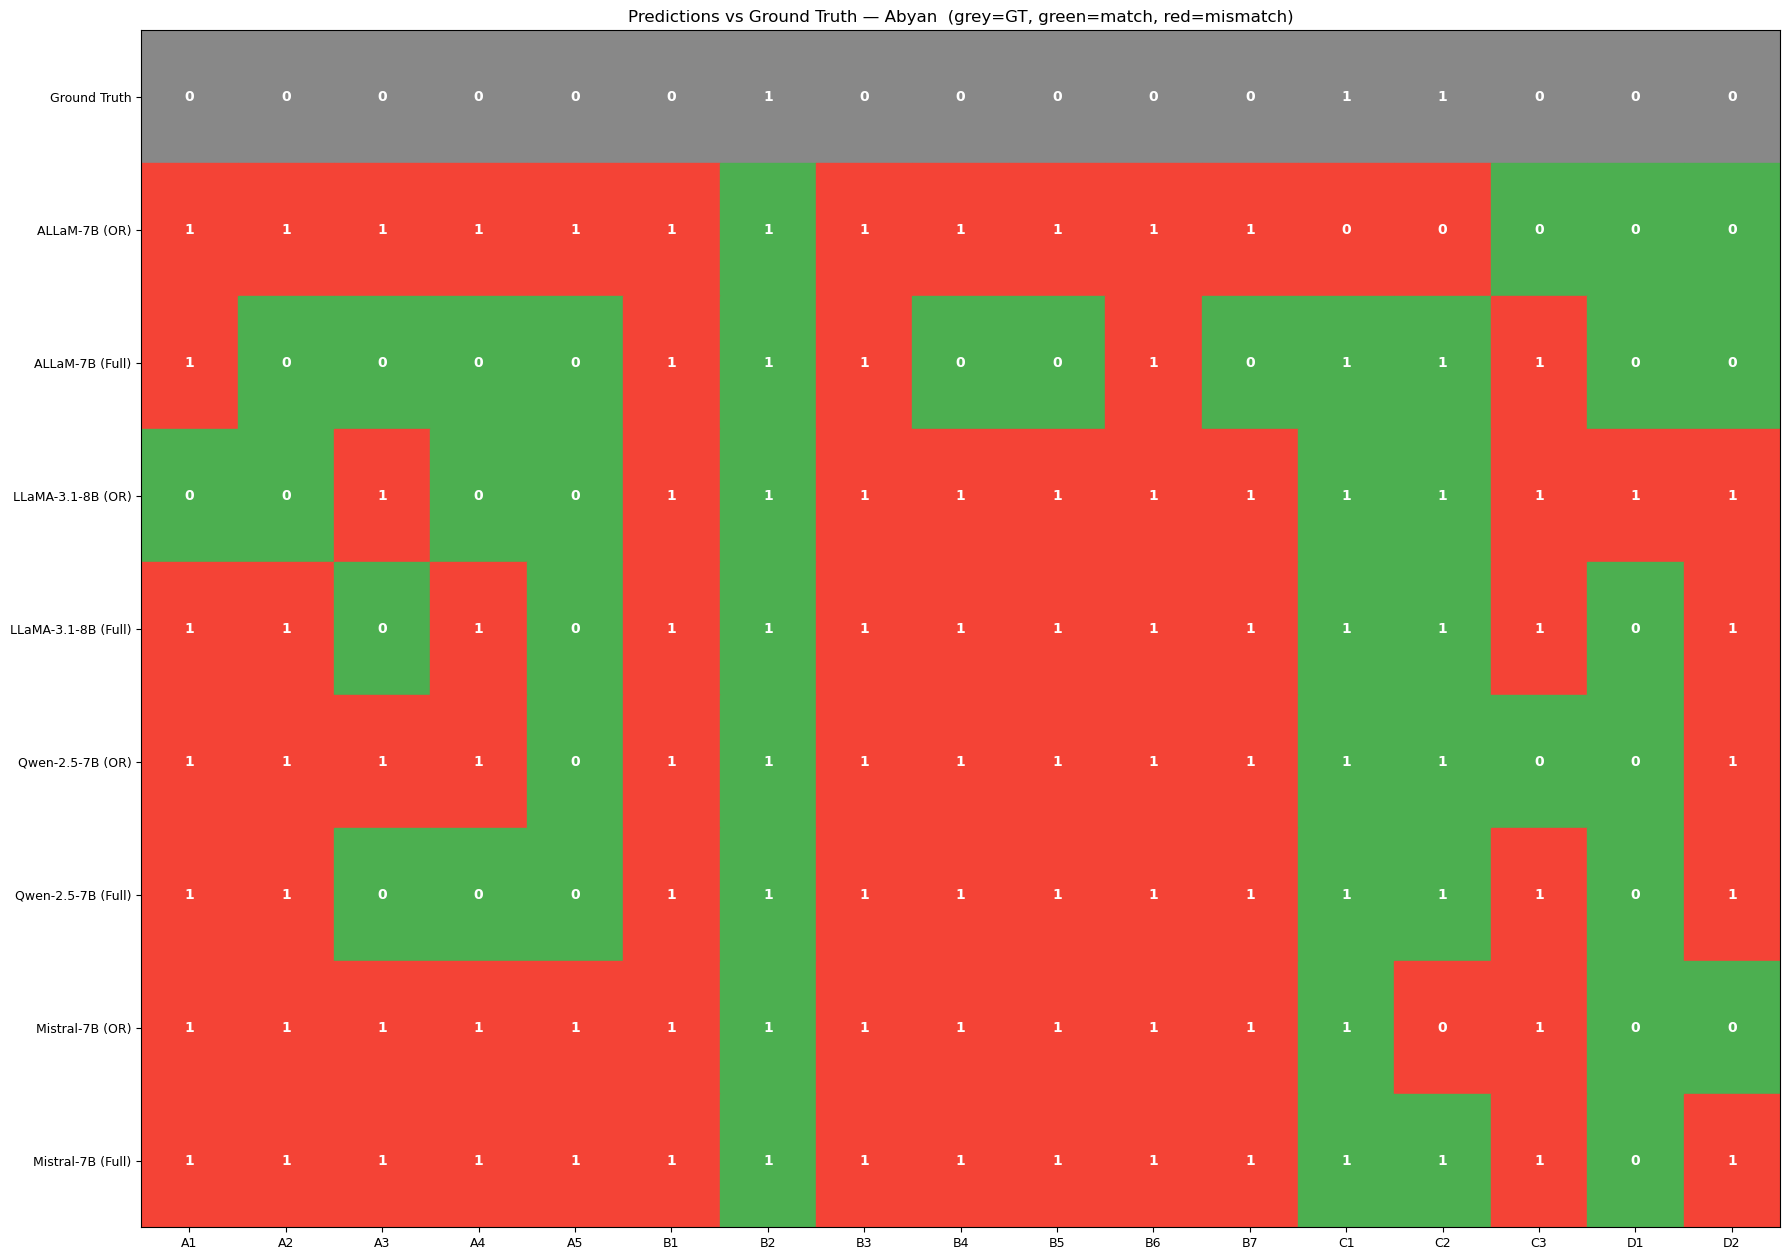

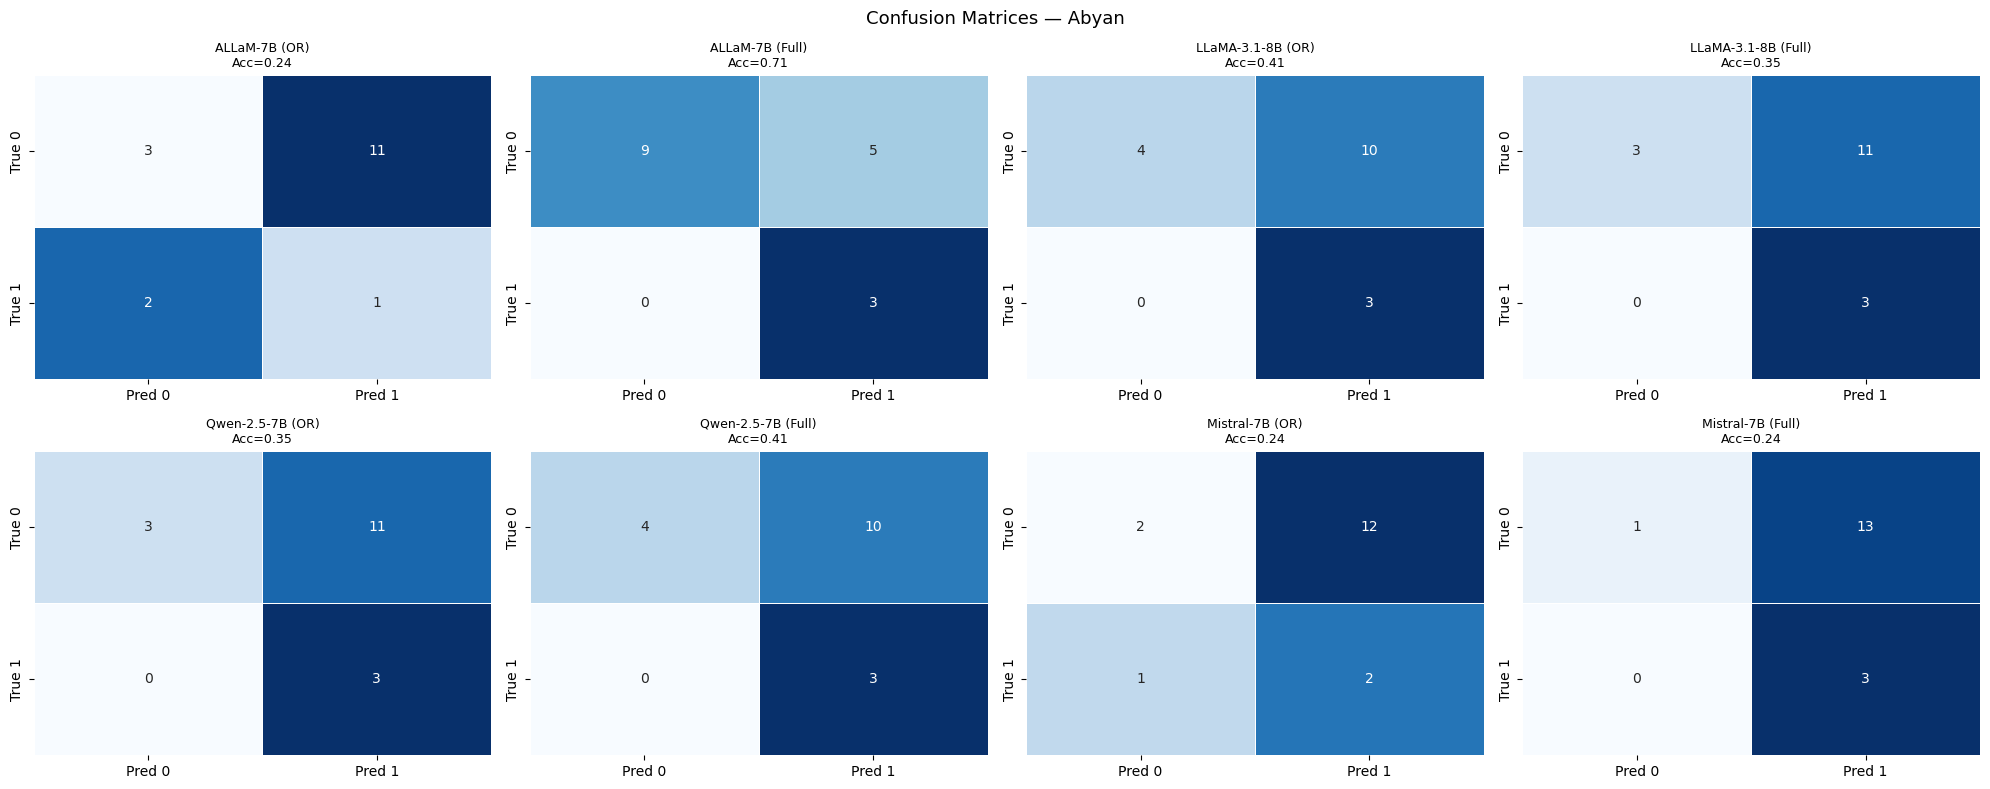

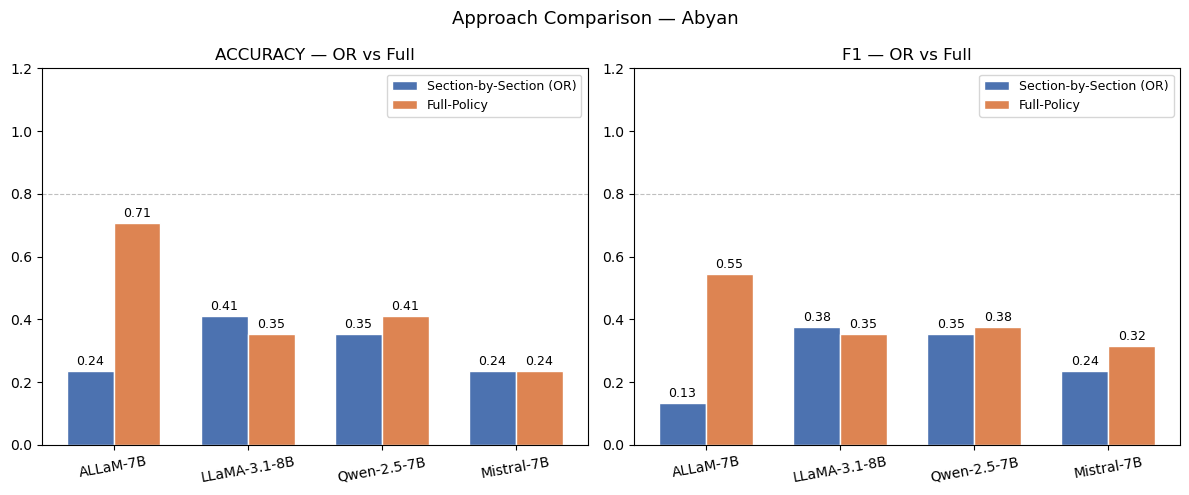

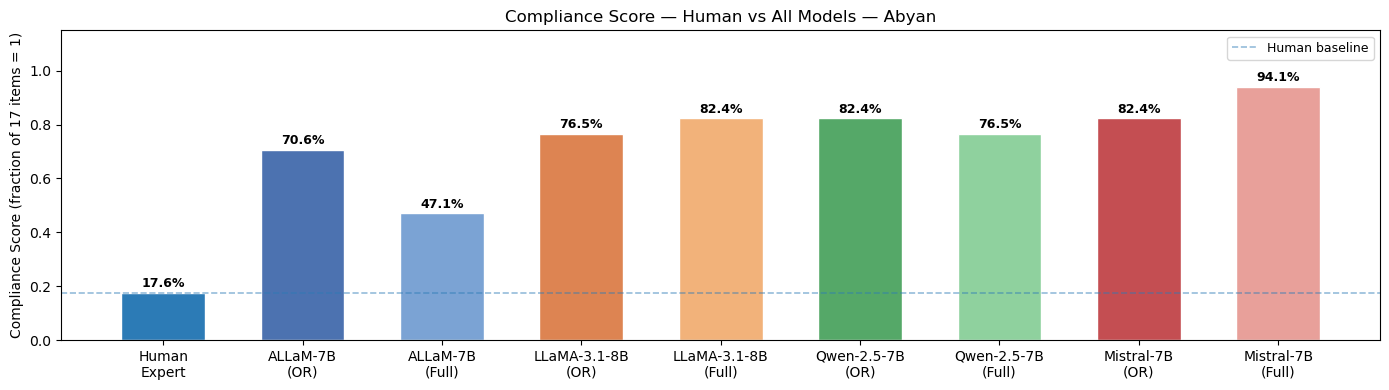

✓ All figures saved for Abyan


In [14]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Manafa

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Manafa"
POLICY_DOCX_PATH = "user pp/preprocessed/Manafa.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Manafa
Sections: 11 | GT compliant: 11/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 9: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.706 Kappa=0.206
-- Full-Policy --
  Full Final: 10100111111111110 | Acc=0.647 Kappa=0.164
  ✓ ALLaM-7B unloaded | VRAM freed

  LLaMA-3.1-8B
Loading meta-llama/Llama-3.1-8B-Instruct...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 5: [0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 7: [0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0]
  Sec 8: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11110111111111110 | Acc=0.765 Kappa=0.393
-- Full-Policy --
  Full Final: 11110111111111100 | Acc=0.824 Kappa=0.564
  ✓ LLaMA-3.1-8B unloaded | VRAM freed

  Qwen-2.5-7B
Loading Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
  Sec 9: [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
  Sec 11: [1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0]
  OR Final: 11111111111111110 | Acc=0.706 Kappa=0.206
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.765 Kappa=0.443
  ✓ Qwen-2.5-7B unloaded | VRAM freed

  Mistral-7B
Loading mistralai/Mistral-7B-Instruct-v0.3...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  OR Final: 11111111111111101 | Acc=0.706 Kappa=0.206
-- Full-Policy --
  Full Final: 11100111111111100 | Acc=0.765 Kappa=0.443
  ✓ Mistral-7B unloaded | VRAM freed

✓ Manafa done — 8 results saved
       model                approach  accurac

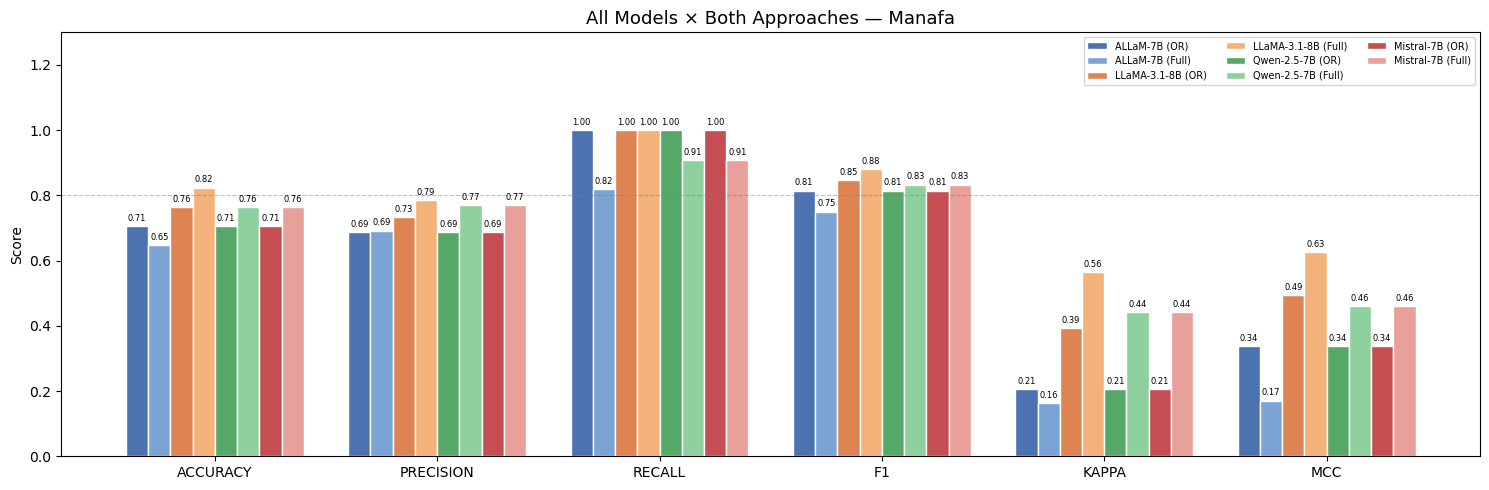

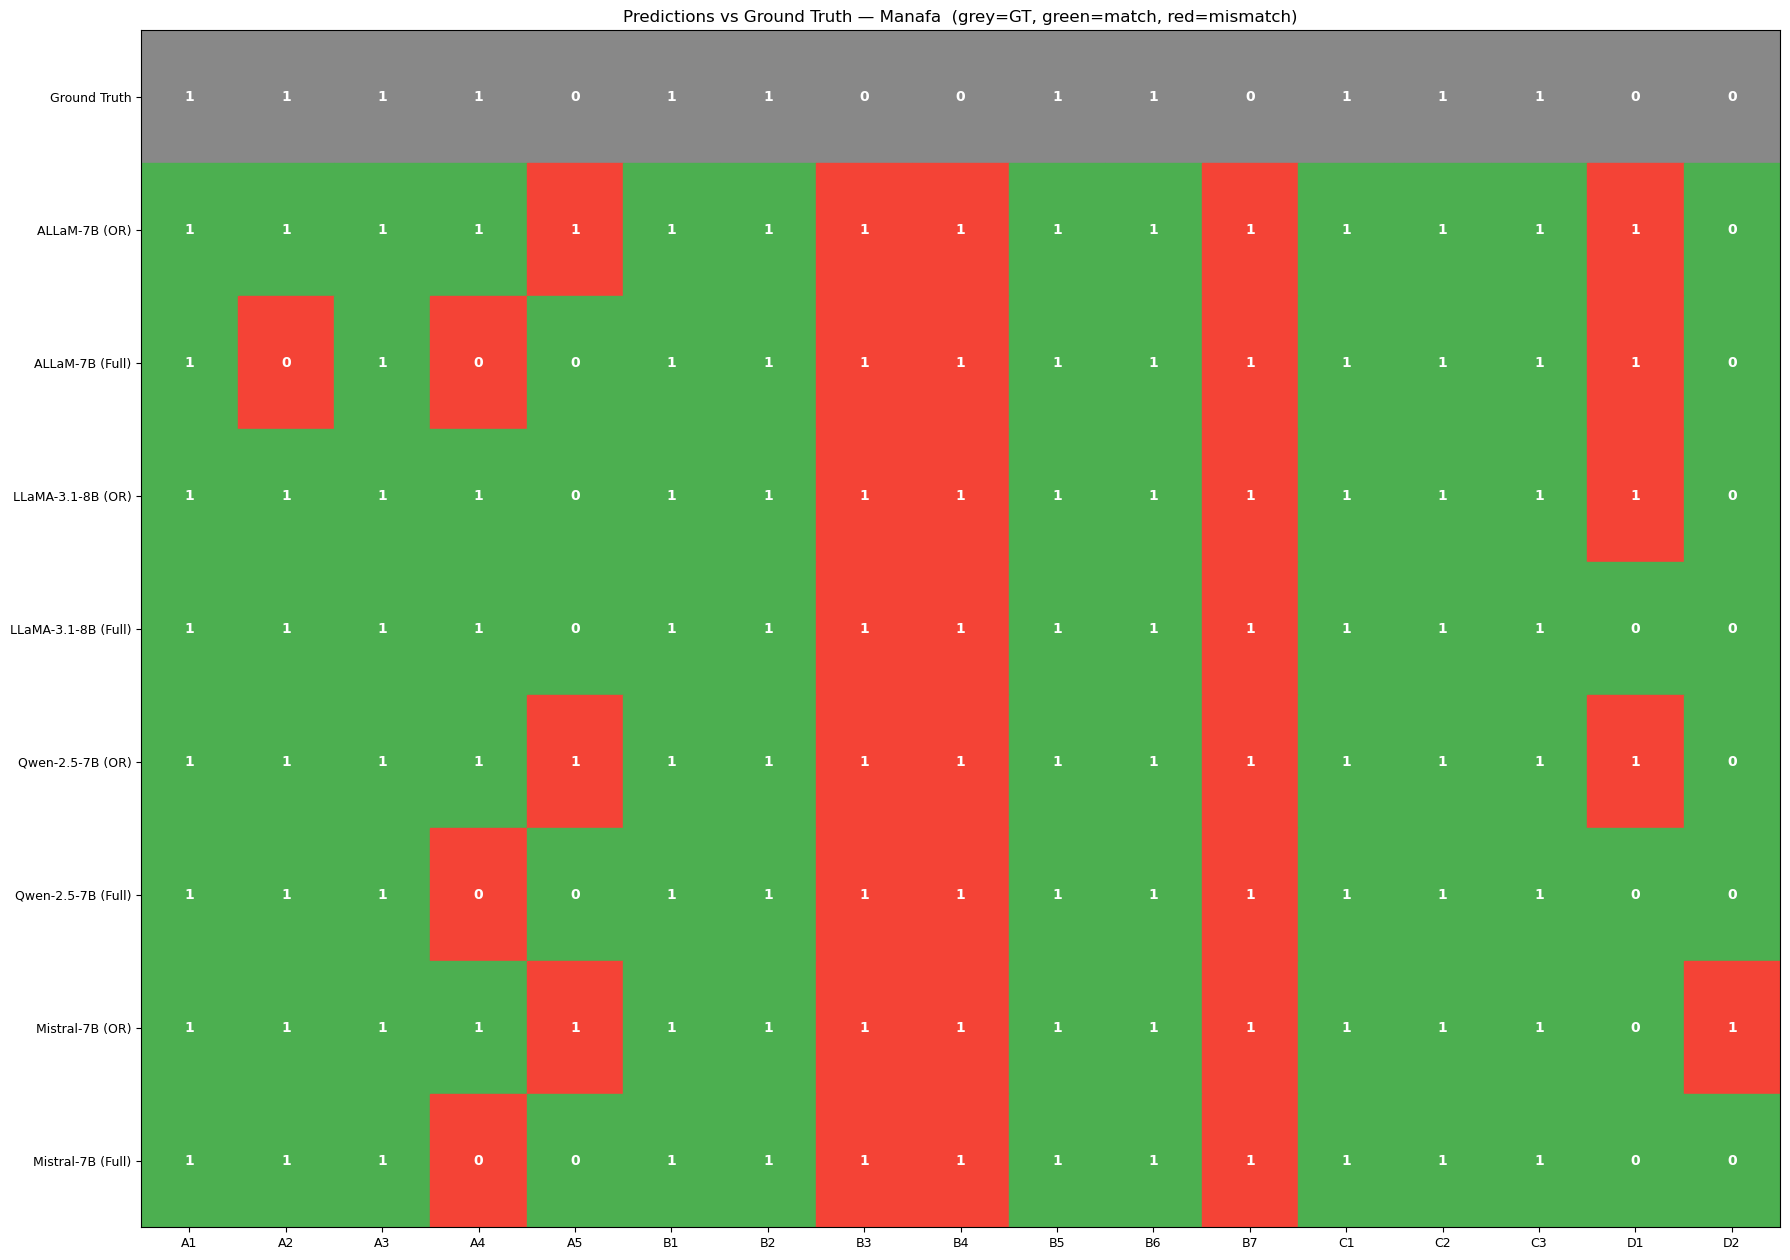

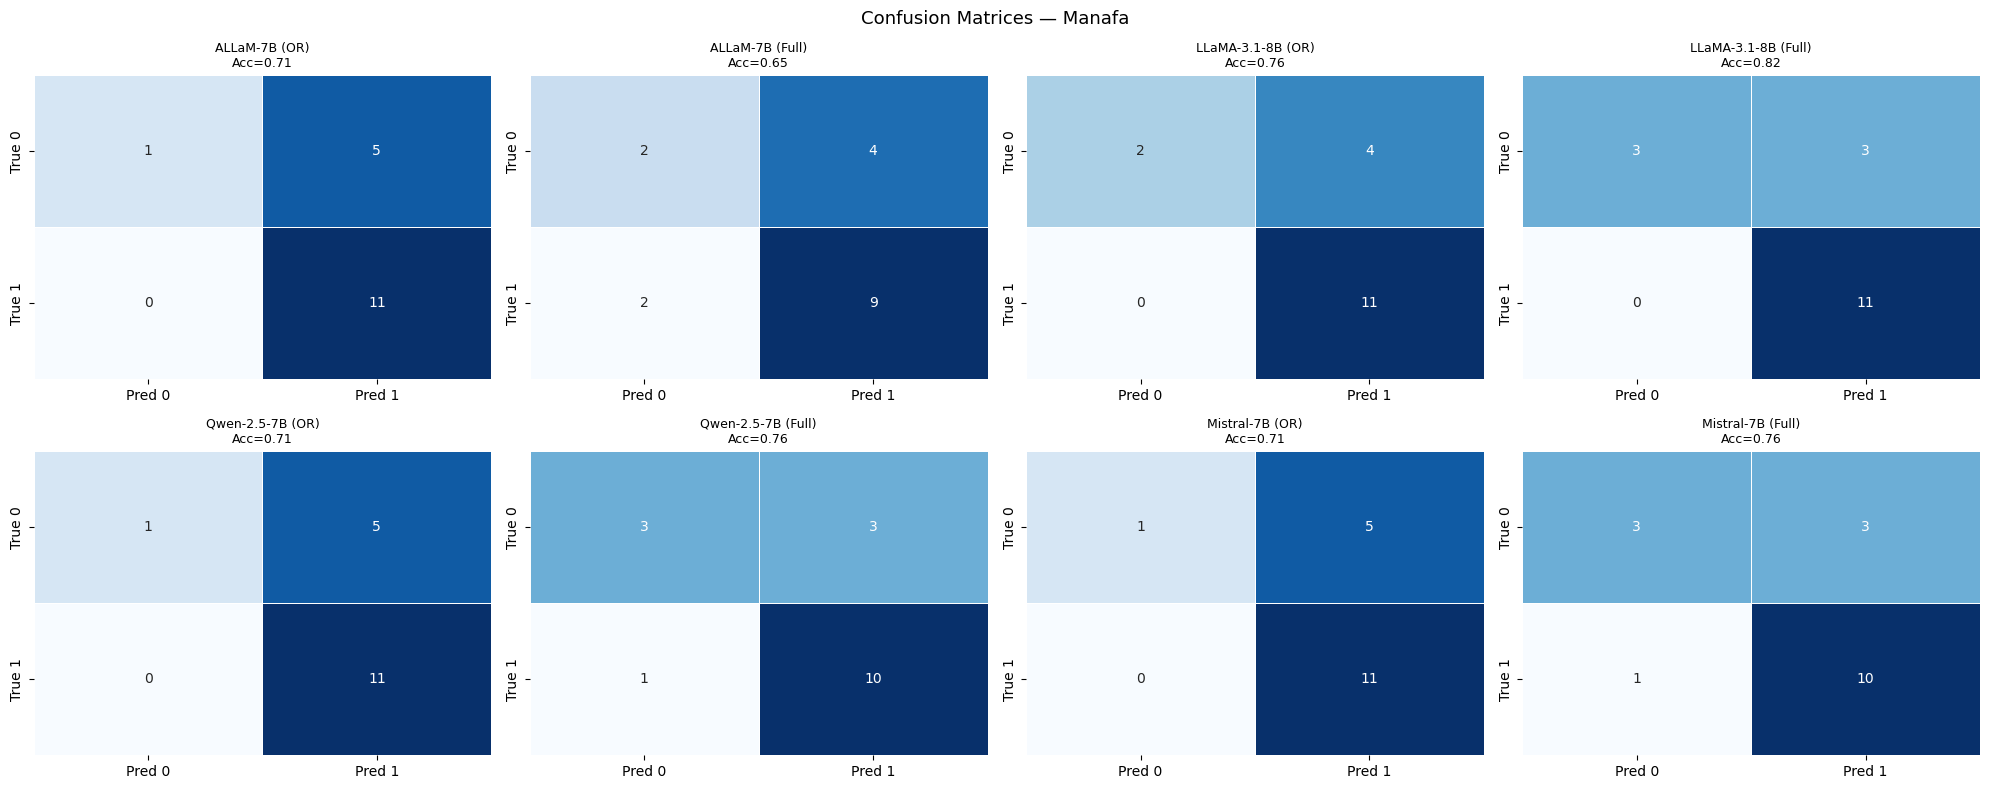

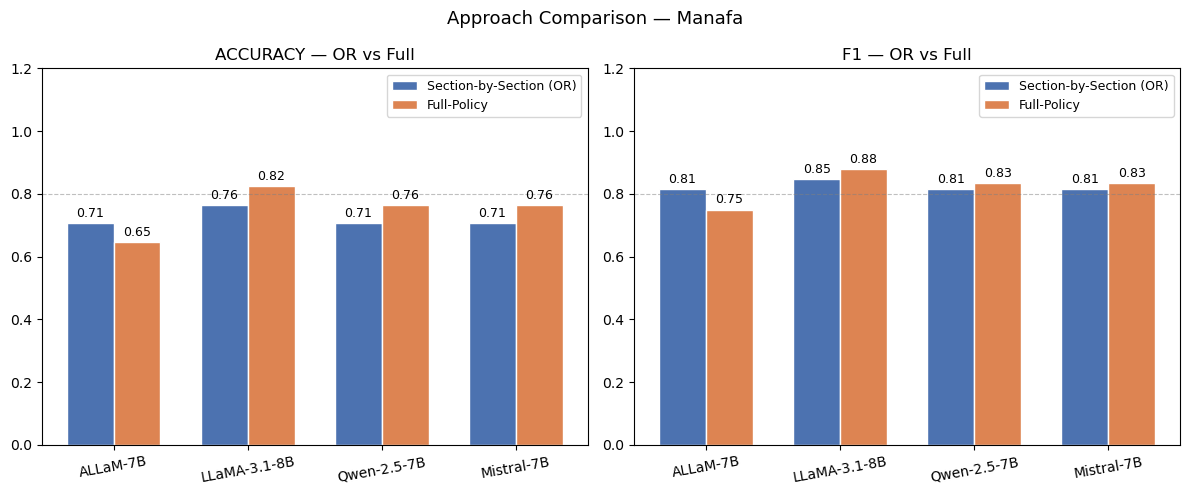

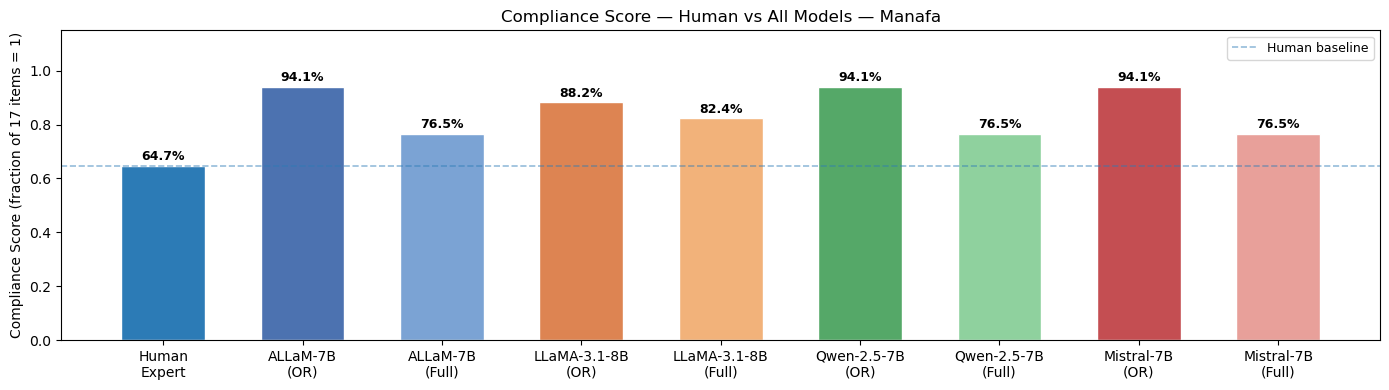

✓ All figures saved for Manafa


In [16]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Rakeez

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Rakeez"
POLICY_DOCX_PATH = "user pp/preprocessed/Rakeez.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Rakeez
Sections: 14 | GT compliant: 8/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.471 Kappa=0.000
--

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 2: [0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 6: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
  Sec 8: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 9: [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 13: [0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0]
  Sec 14: [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  OR Final: 11010111111111111 | Acc=0.588 Kappa=0.212
-- Fu

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0]
  Sec 9: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
  Sec 14: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11110111111111010 | Acc=0.529 Kappa=0.093
-- Full-Polic

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1]
  Sec 9: [1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0]
  Sec 13: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
  OR Final: 11110111111110111 | Acc=0.471 Kappa=-0.013
--

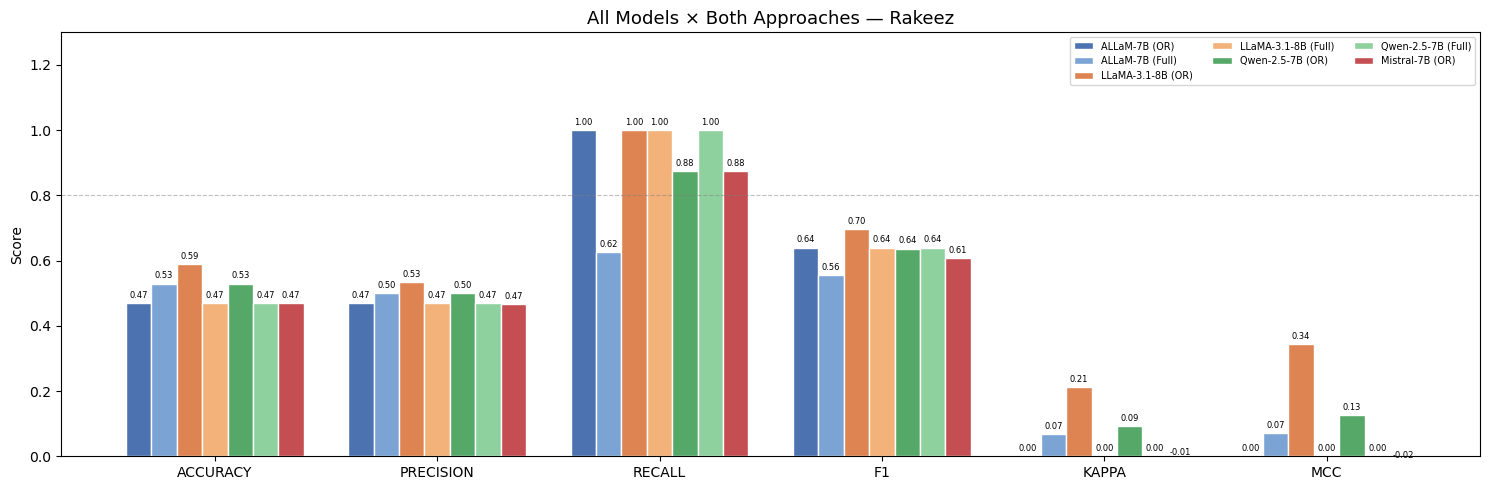

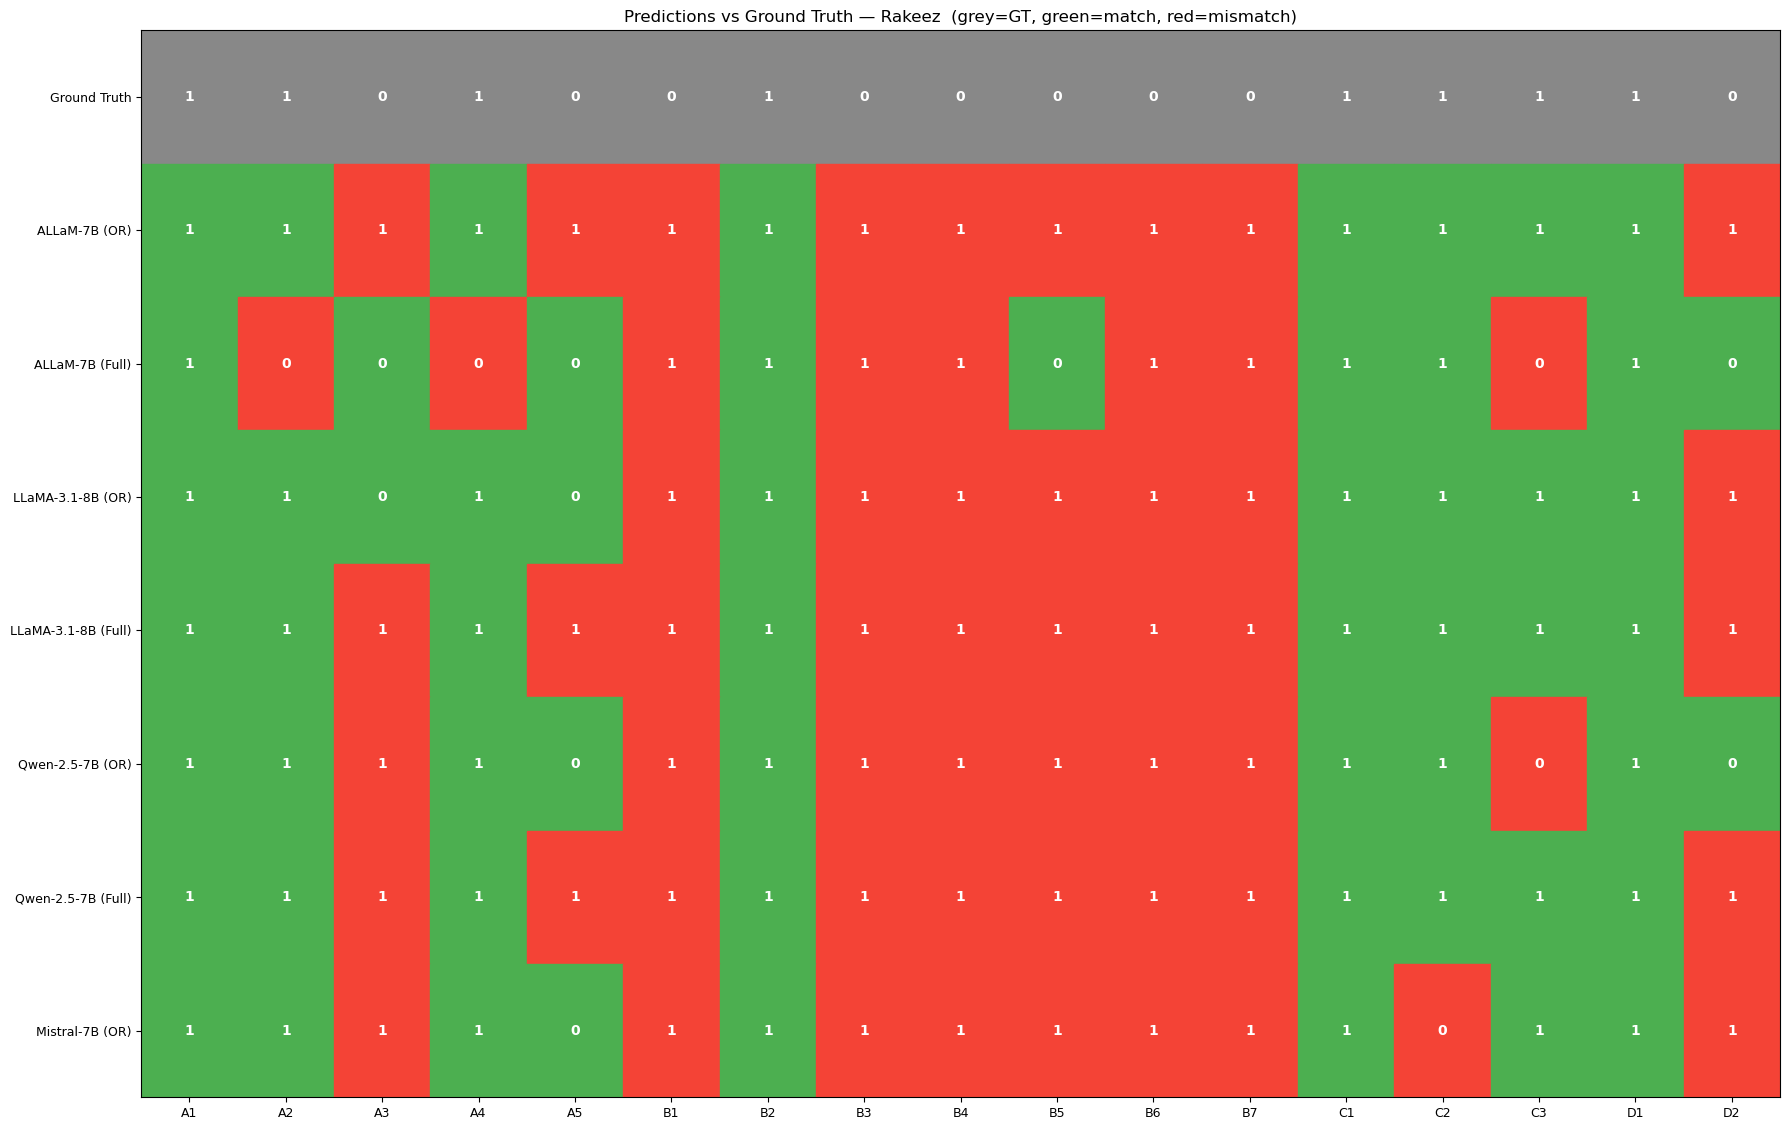

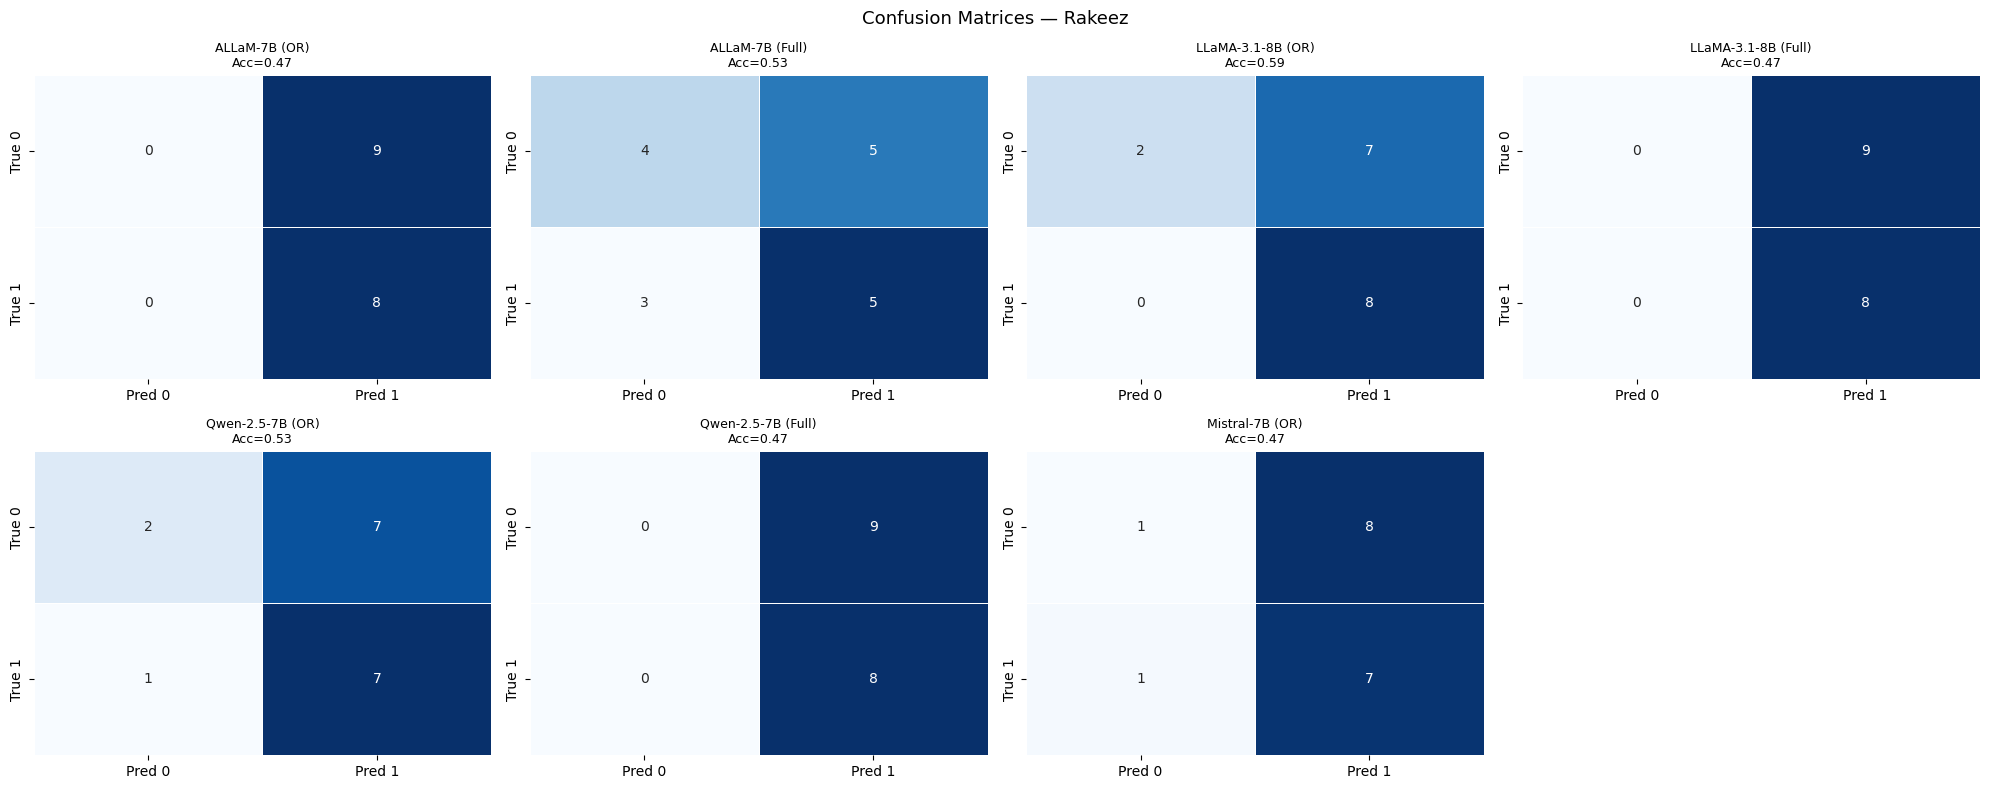

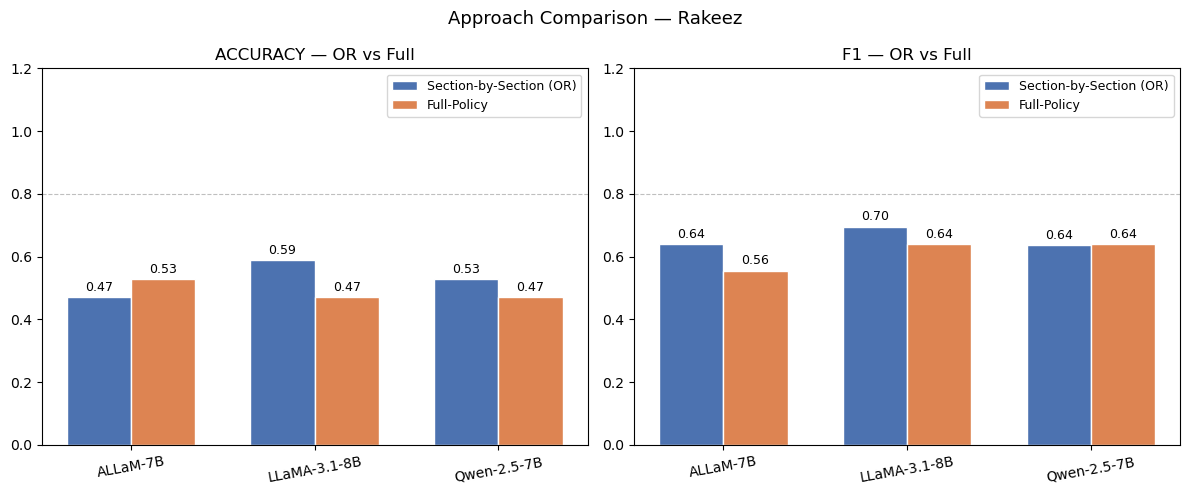

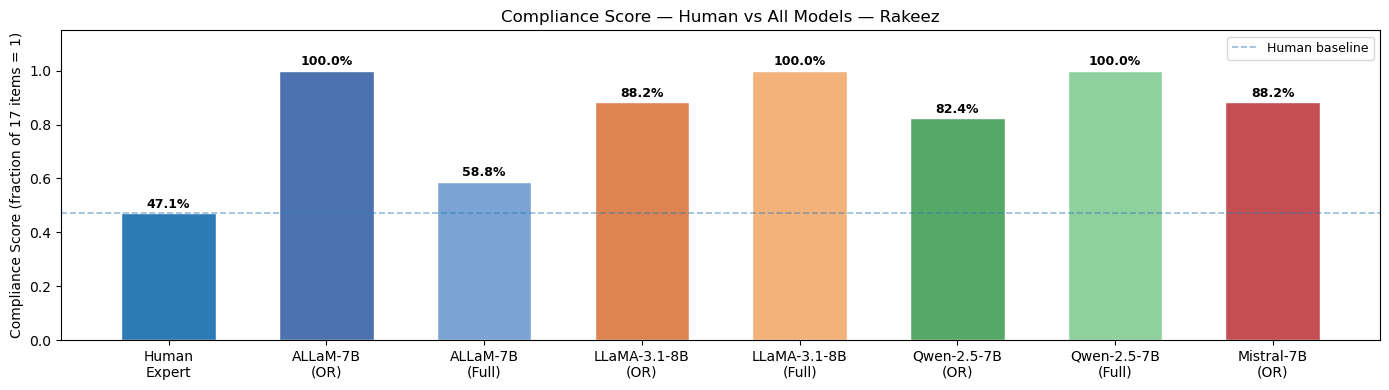

✓ All figures saved for Rakeez


In [18]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Emakn Alarabiya

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Emakn Alarabiya"
POLICY_DOCX_PATH = "user pp/preprocessed/Emakn Alarabiya.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Emakn Alarabiya
Sections: 15 | GT compliant: 11/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 14: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1]
  Sec 11: [1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0]
  Sec 2: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]
  Sec 7: [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1]
  Sec 15: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR 

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 2: [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0]
  Sec 7: [1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

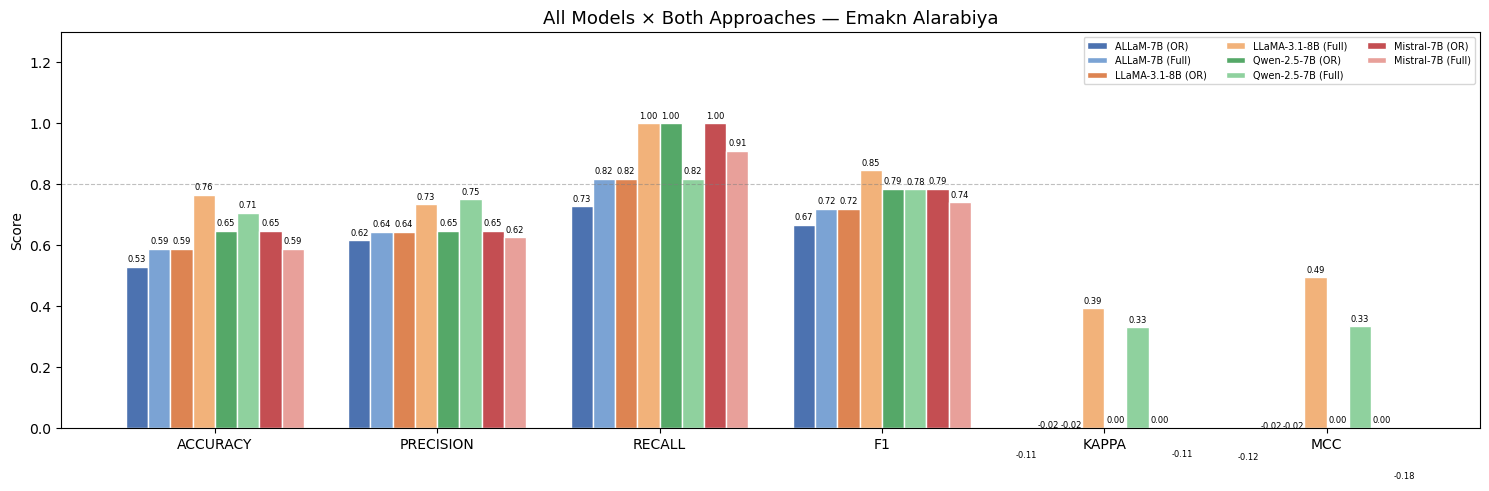

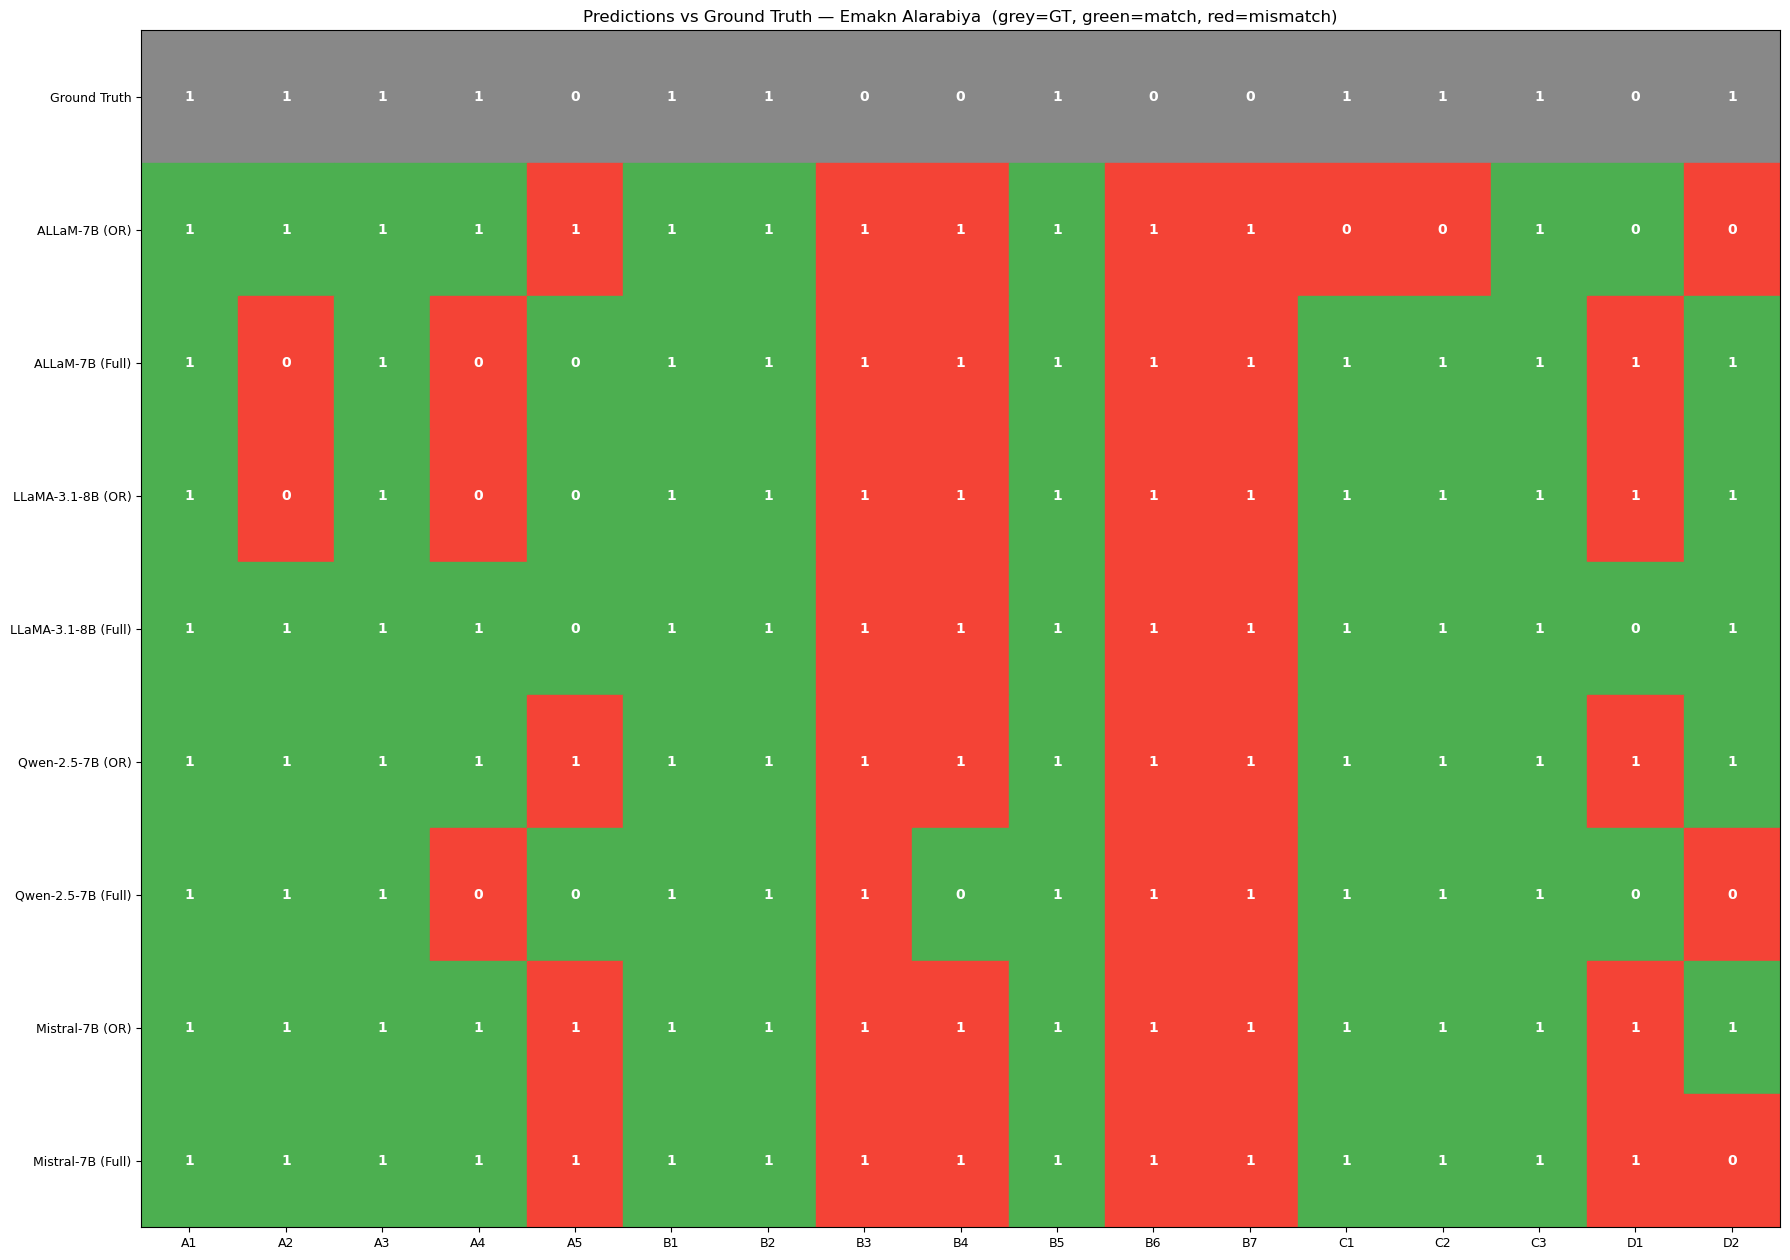

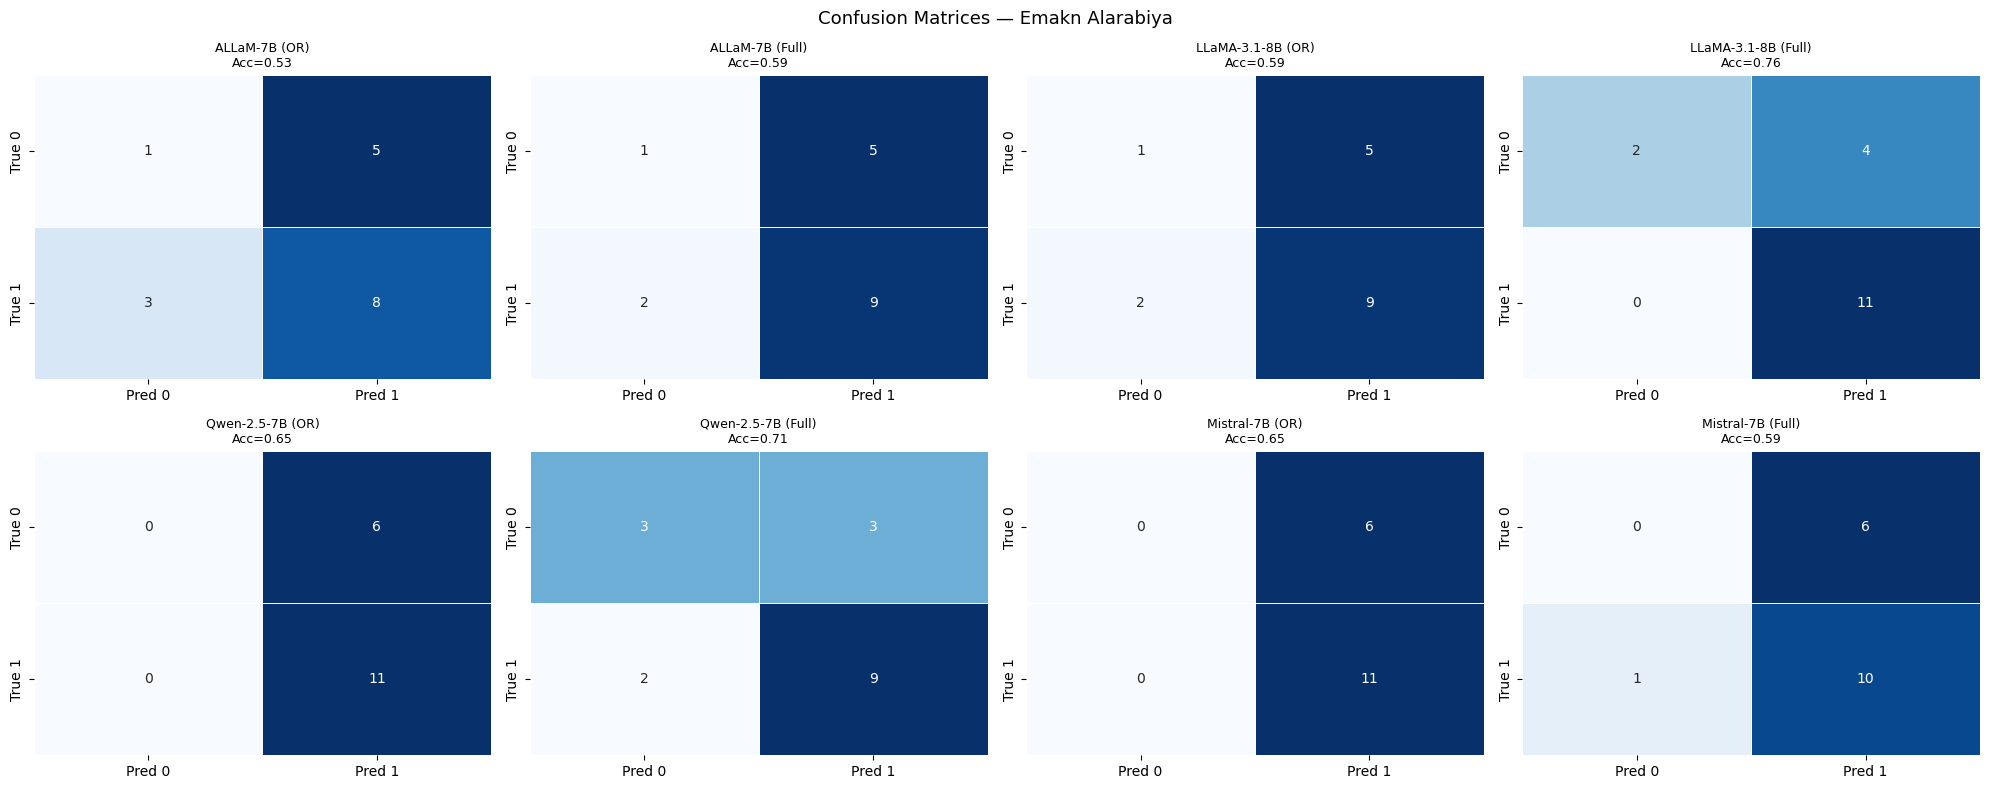

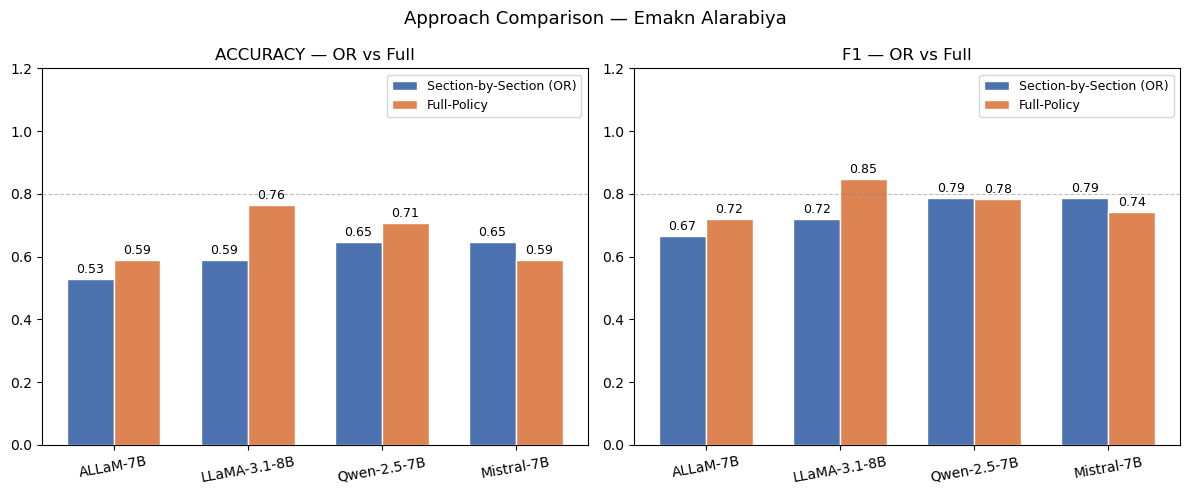

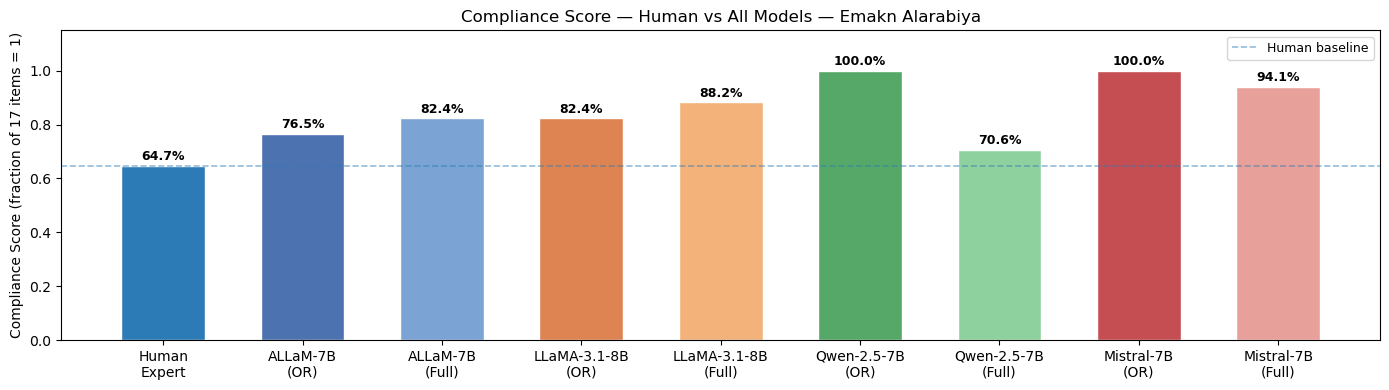

✓ All figures saved for Emakn Alarabiya


In [20]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Money Loop

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Money Loop"
POLICY_DOCX_PATH = "user pp/preprocessed/Money Loop.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Money Loop
Sections: 19 | GT compliant: 0/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 15: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]
  Sec 5: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0]
  Sec 14: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 15: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0

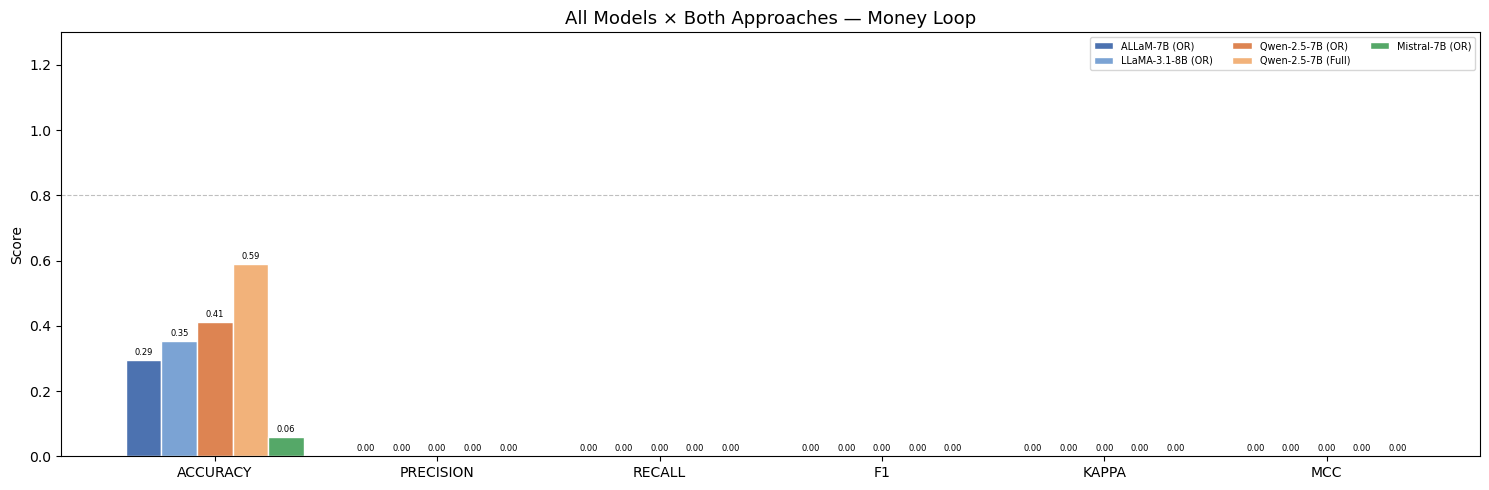

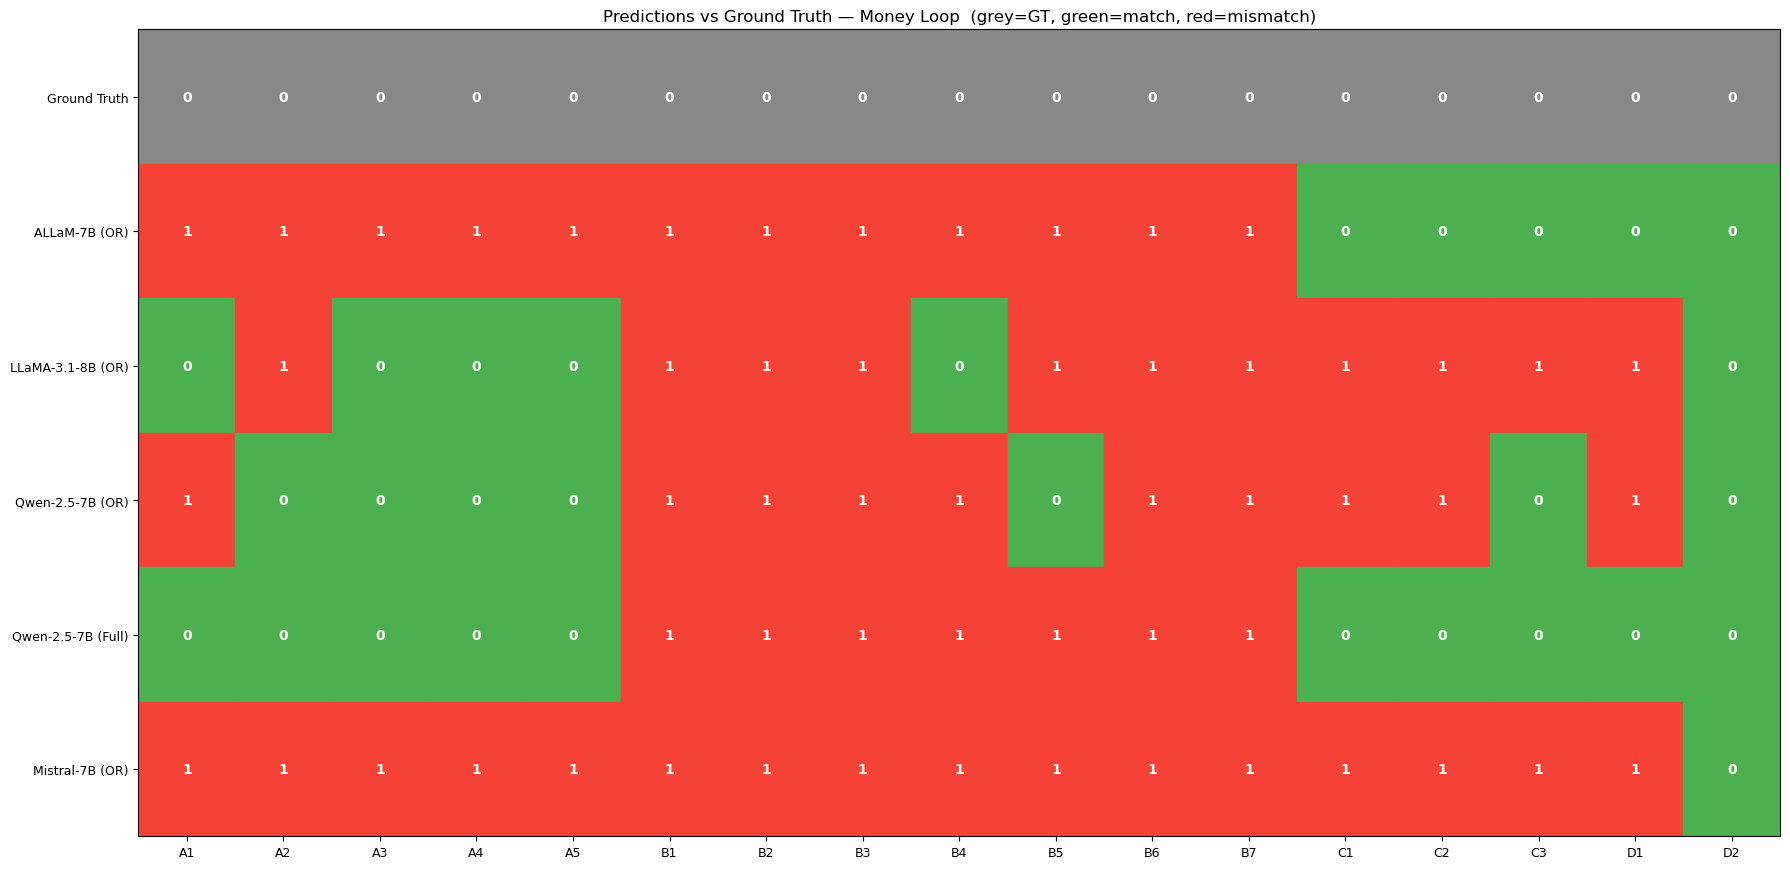

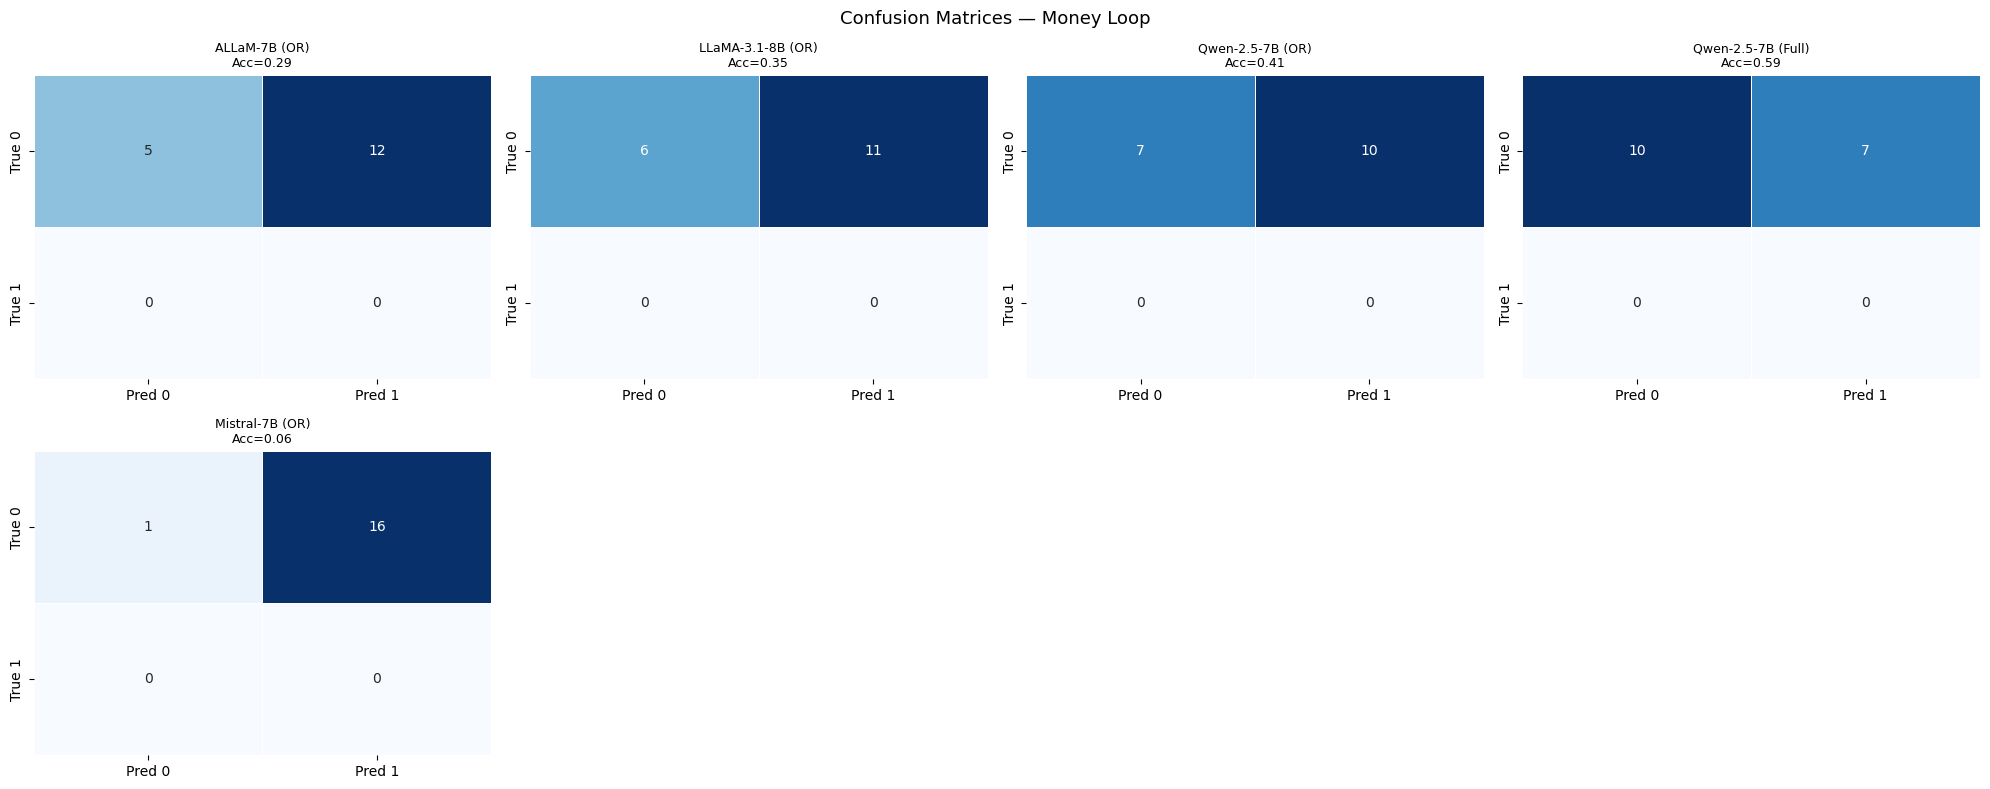

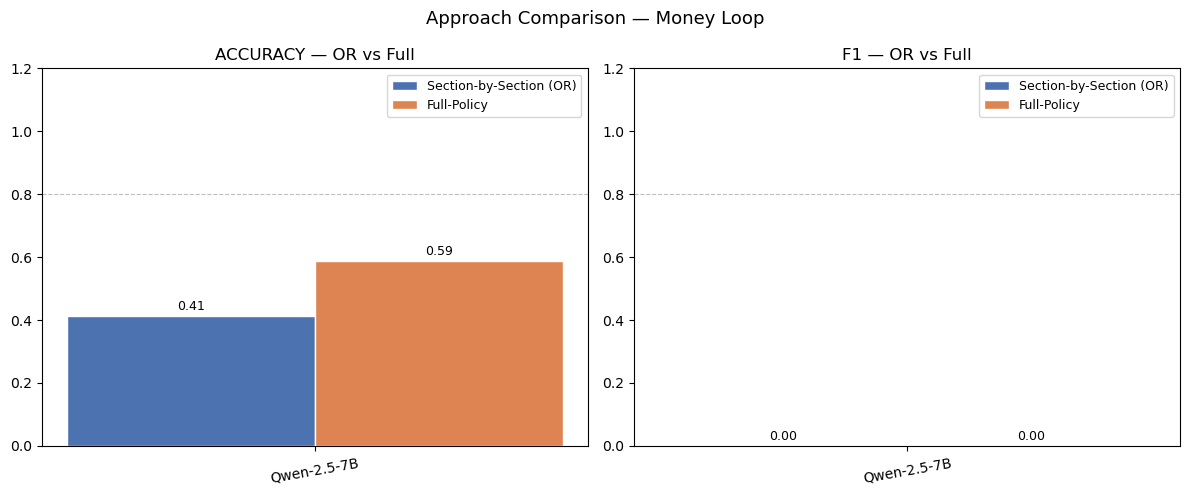

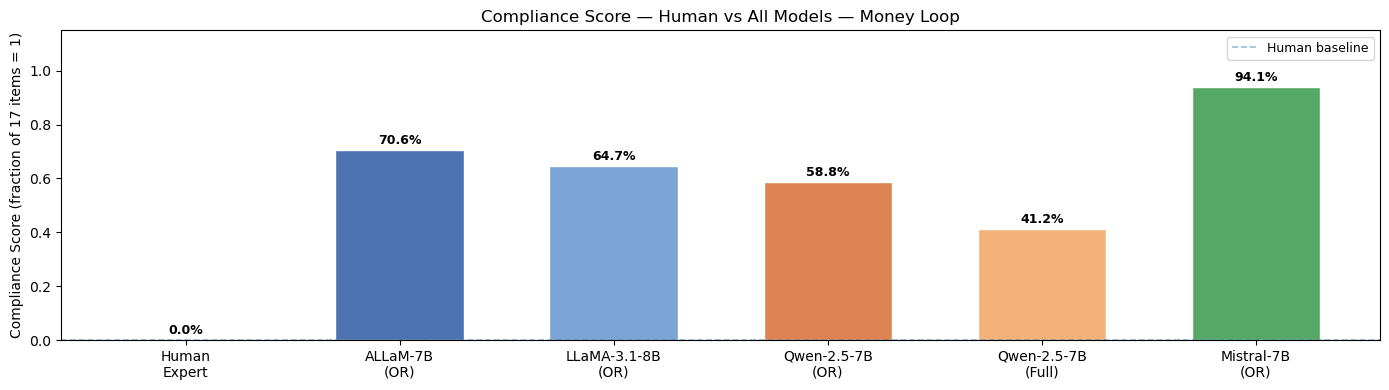

✓ All figures saved for Money Loop


In [22]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Ta3meed

In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Ta3meed"
POLICY_DOCX_PATH = "user pp/preprocessed/Ta3meed.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Ta3meed
Sections: 13 | GT compliant: 7/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 12: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.412 Kappa=0.000
-- Full-Policy --
  Full Final: 10000111111111111 | Acc=0.294 Ka

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 4: [1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 5: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 6: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 7: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1]
  Sec 9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0]
  Sec 10: [0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]
  Sec 11: [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 12: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 13: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.412 Kappa=0.000
-- Full-Policy --
  Full Final: 11110111111111101 | Acc=0.529 Kappa

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0]
  Sec 8: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]
  Sec 12: [1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111110110 | Acc=0.412 Kappa=-0.037
-- Full-Policy --
  Full Final: 11100111111111101 | Acc=0.471 Kappa=0.050


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0]
  Sec 3: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0]
  Sec 4: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  Sec 7: [1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1]
  Sec 9: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 11: [1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]
  Sec 12: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  OR Final: 11111111111111111 | Acc=0.412 Kappa=0.000
-- Full-Policy --
  Full Final: 11111111111111111 | Acc=0.412 Kap

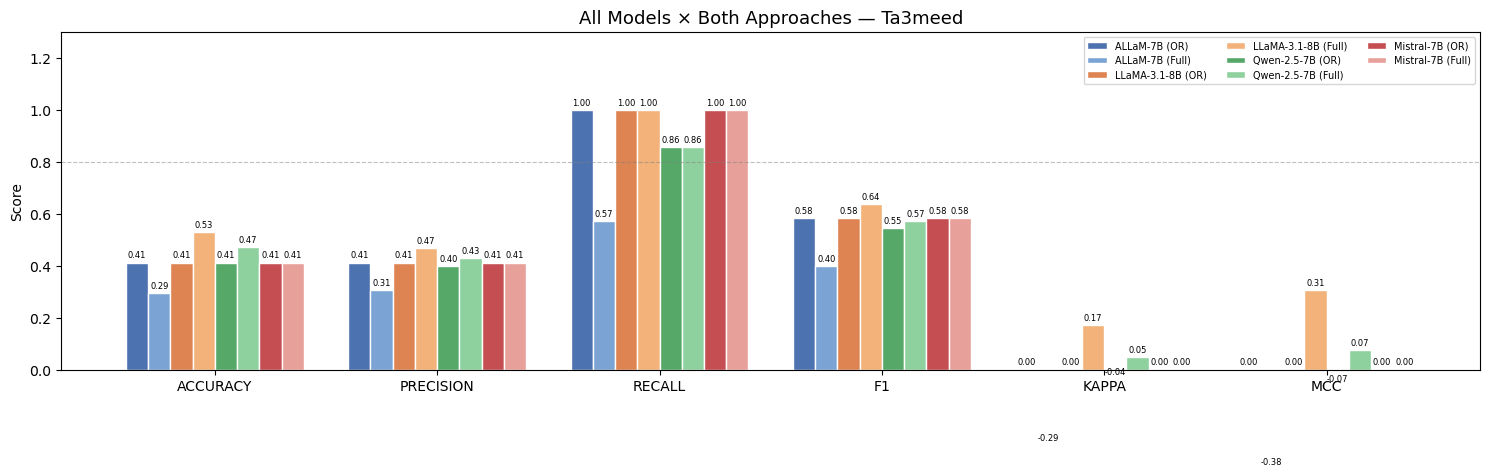

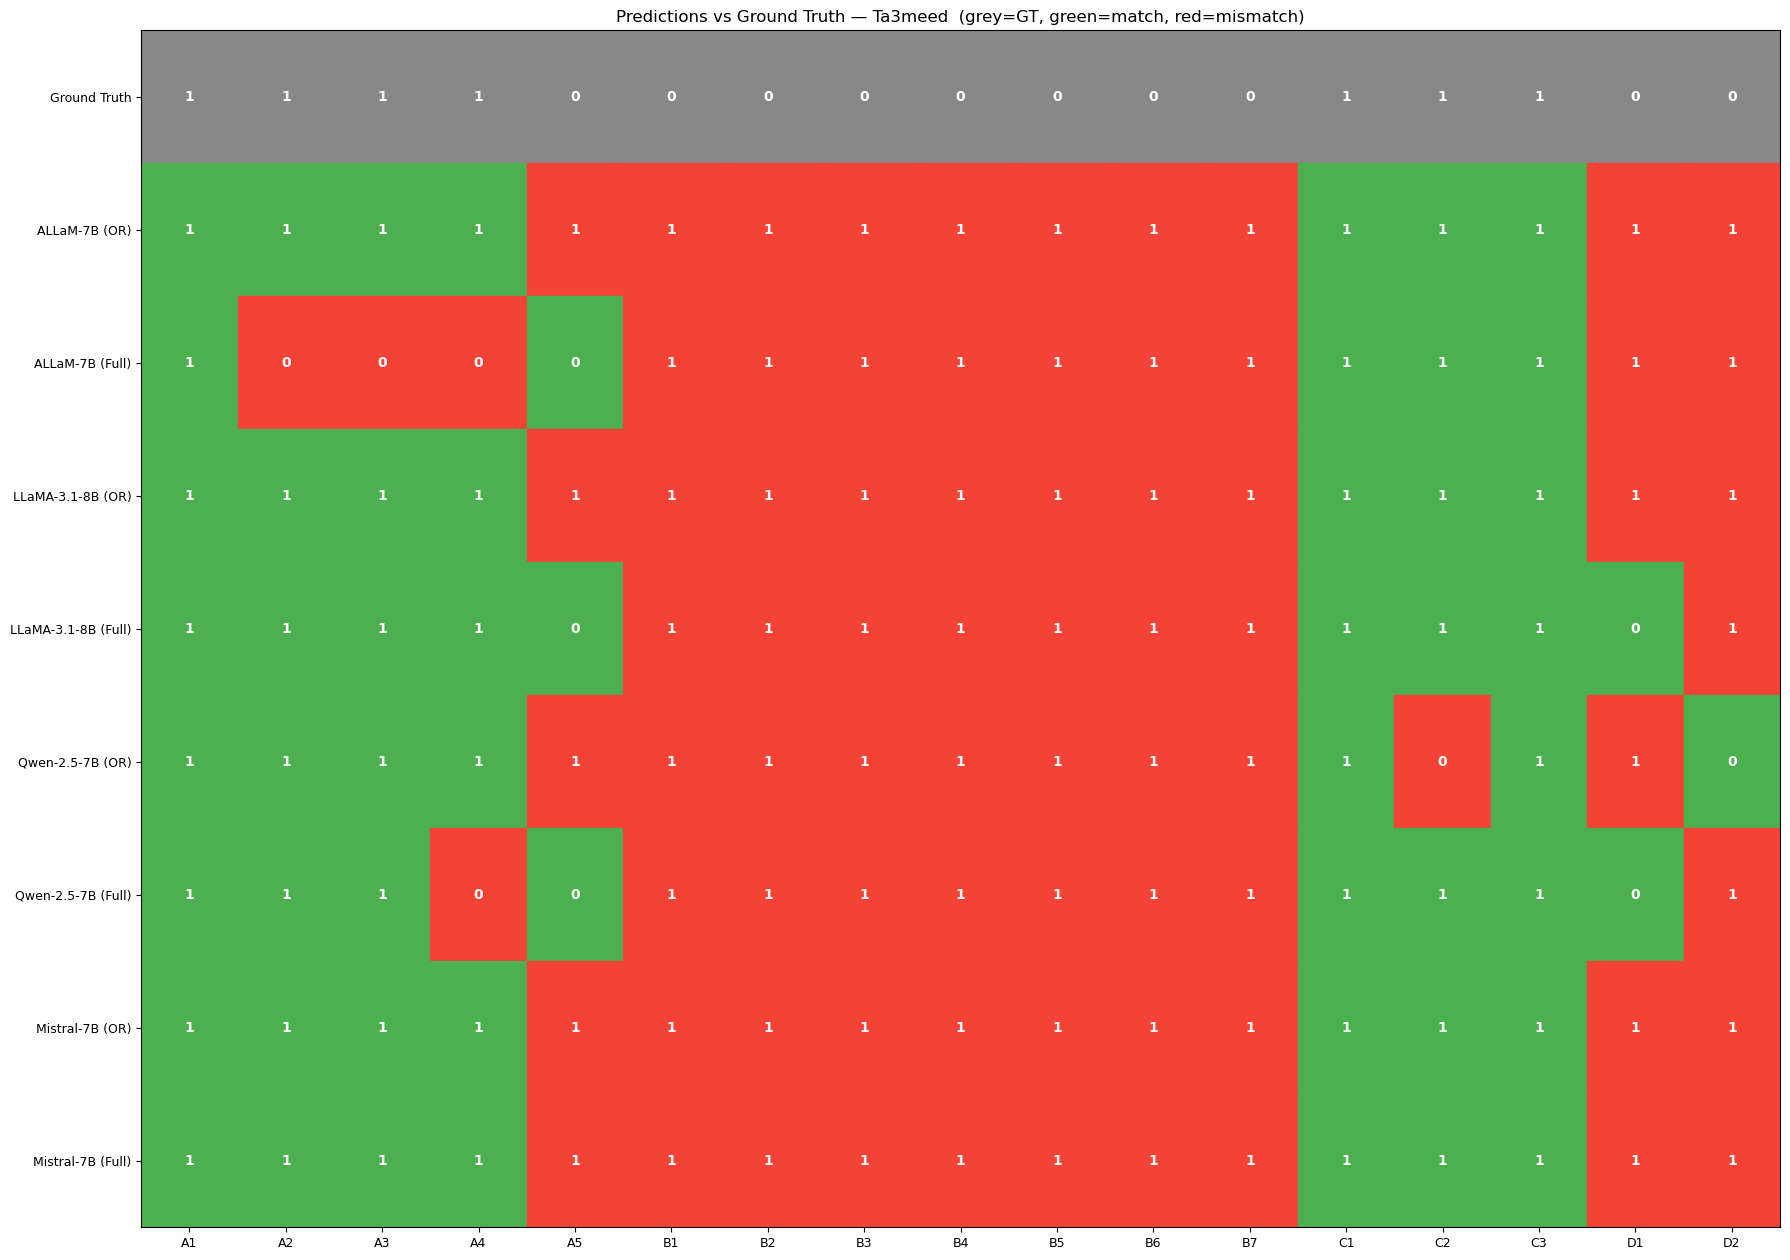

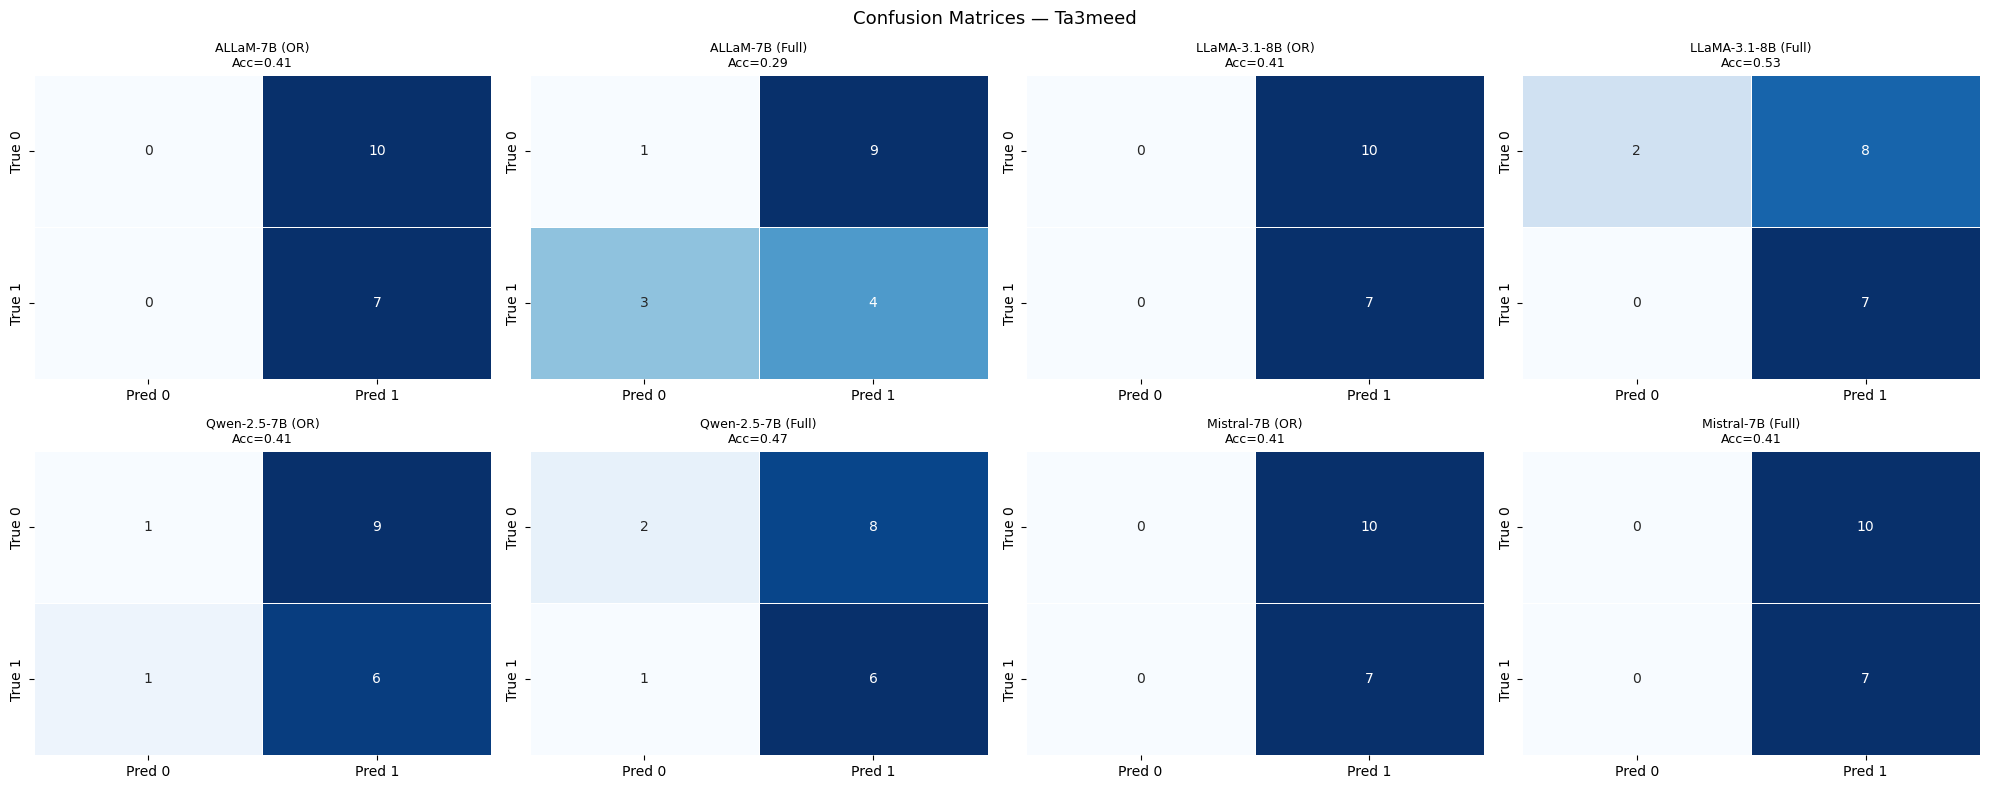

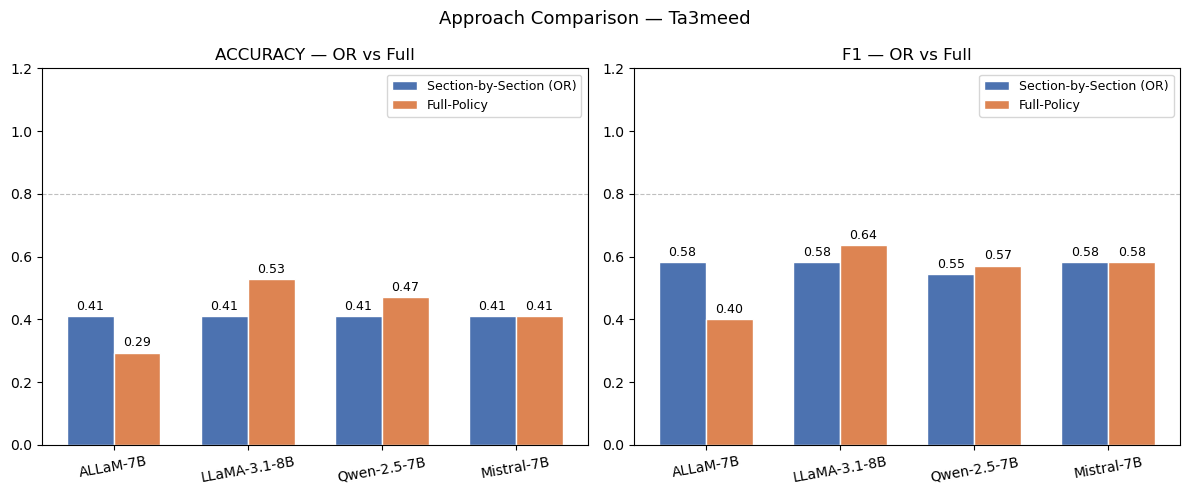

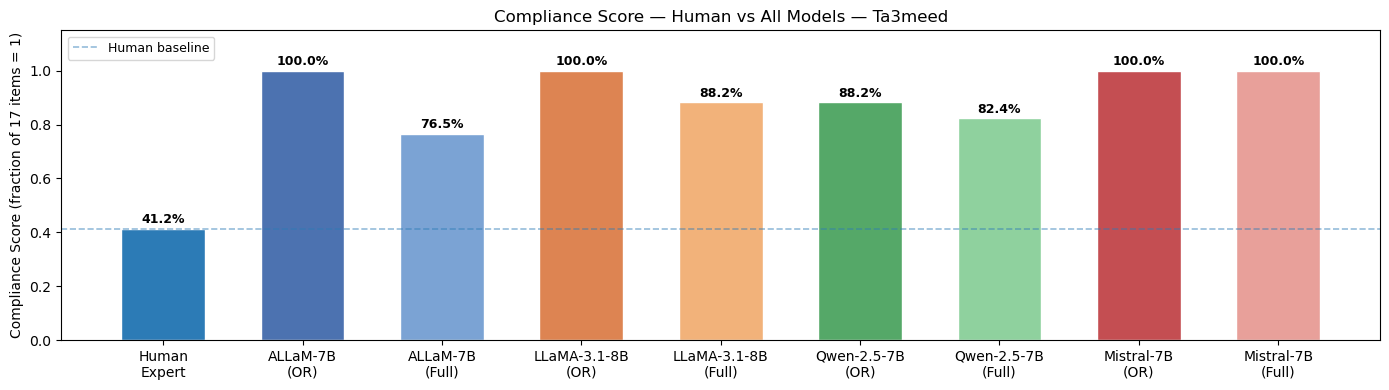

✓ All figures saved for Ta3meed


In [24]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

### Sulfah

In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Sulfah"
POLICY_DOCX_PATH = "user pp/preprocessed/Sulfah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"{'='*60}")
print(f"  APP: {APP_NAME}")
print(f"{'='*60}")

ground_truth = load_ground_truth(APP_NAME)
policy_sections = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT compliant: {sum(ground_truth.values())}/17")

app_results = []

# ── Per-model loop: load → run both approaches → unload ──────────────────────
for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  {model_label}")
    print(f"{'='*55}")

    # Load this model into GPU
    tok, mdl = model_cfg['loader']()
    model_fn  = model_cfg['runner'](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Approach 1: Section-by-Section ───
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\b([01])\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    # OR aggregation — from original LLaMA-3 notebook Cell 11
    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_results.append(result_sec)
        print(f"  OR Final: {''.join(map(str,final_sec))} | Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Approach 2: Full-Policy ───────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            # Fallback: collect all isolated 0/1 values from the output
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\b([01])\b", line))]
            if len(vals) >= num_rubric_items:
                # Use the LAST num_rubric_items values (after any reasoning preamble)
                vals_used = vals[-num_rubric_items:]
                preds_full = {item: vals_used[i] for i, item in enumerate(rubric_items)}
            else:
                print(f"  ⚠ Could not parse full-policy response ({len(vals)} values found) — skipping")
                print(f"  ⚠ Raw output snippet: {raw_full[:300]!r}")
                preds_full = None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_results.append(result_full)
                print(f"  Full Final: {''.join(str(preds_full.get(i,'?')) for i in rubric_items)} | Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    # ── Unload model, free GPU memory ─────────────────────────────────────
    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded | VRAM freed")

# Save this app's results and accumulate
all_apps_results.extend(app_results)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_results])
app_df.to_csv(f"{OUTPUT_DIR}/{APP_NAME}_evaluation_summary.csv", index=False)
print(f"\n✓ {APP_NAME} done — {len(app_results)} results saved")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))

  APP: Sulfah
Sections: 14 | GT compliant: 0/17

  ALLaM-7B
Loading humain-ai/ALLaM-7B-Instruct-preview...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ humain-ai/ALLaM-7B-Instruct-preview loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 2: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 3: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 13: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 14: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.059 Kappa=0.000
--

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ meta-llama/Llama-3.1-8B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 4: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 5: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 9: [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1]
  Sec 10: [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1]
  Sec 11: [0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0]
  Sec 12: [1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
  Sec 13: [0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
  Sec 14: [0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
  OR Final: 11111111111111111 | Acc=0.000 Kappa=0.000
-- Fu

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✓ Qwen/Qwen2.5-7B-Instruct loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
  Sec 2: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 7: [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 8: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 9: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0]
  Sec 11: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 12: [1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0]
  Sec 13: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 14: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111101111010 | Acc=0.176 Kappa=0.000
-- Full-Polic

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ mistralai/Mistral-7B-Instruct-v0.3 loaded on cuda:0
-- Section-by-Section (OR) --
  Sec 1: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
  Sec 2: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 3: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 4: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 5: [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]
  Sec 6: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Sec 7: [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]
  Sec 8: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
  Sec 9: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 10: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Sec 11: [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]
  Sec 12: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Sec 13: [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  Sec 14: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  OR Final: 11111111111111110 | Acc=0.059 Kappa=0.000
-- 

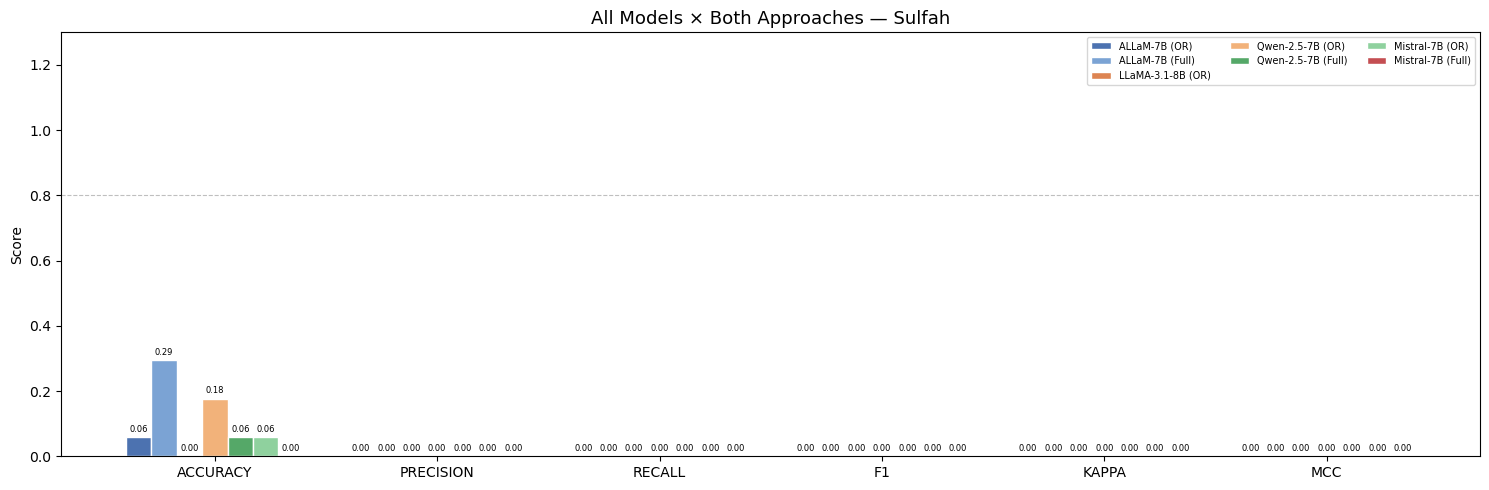

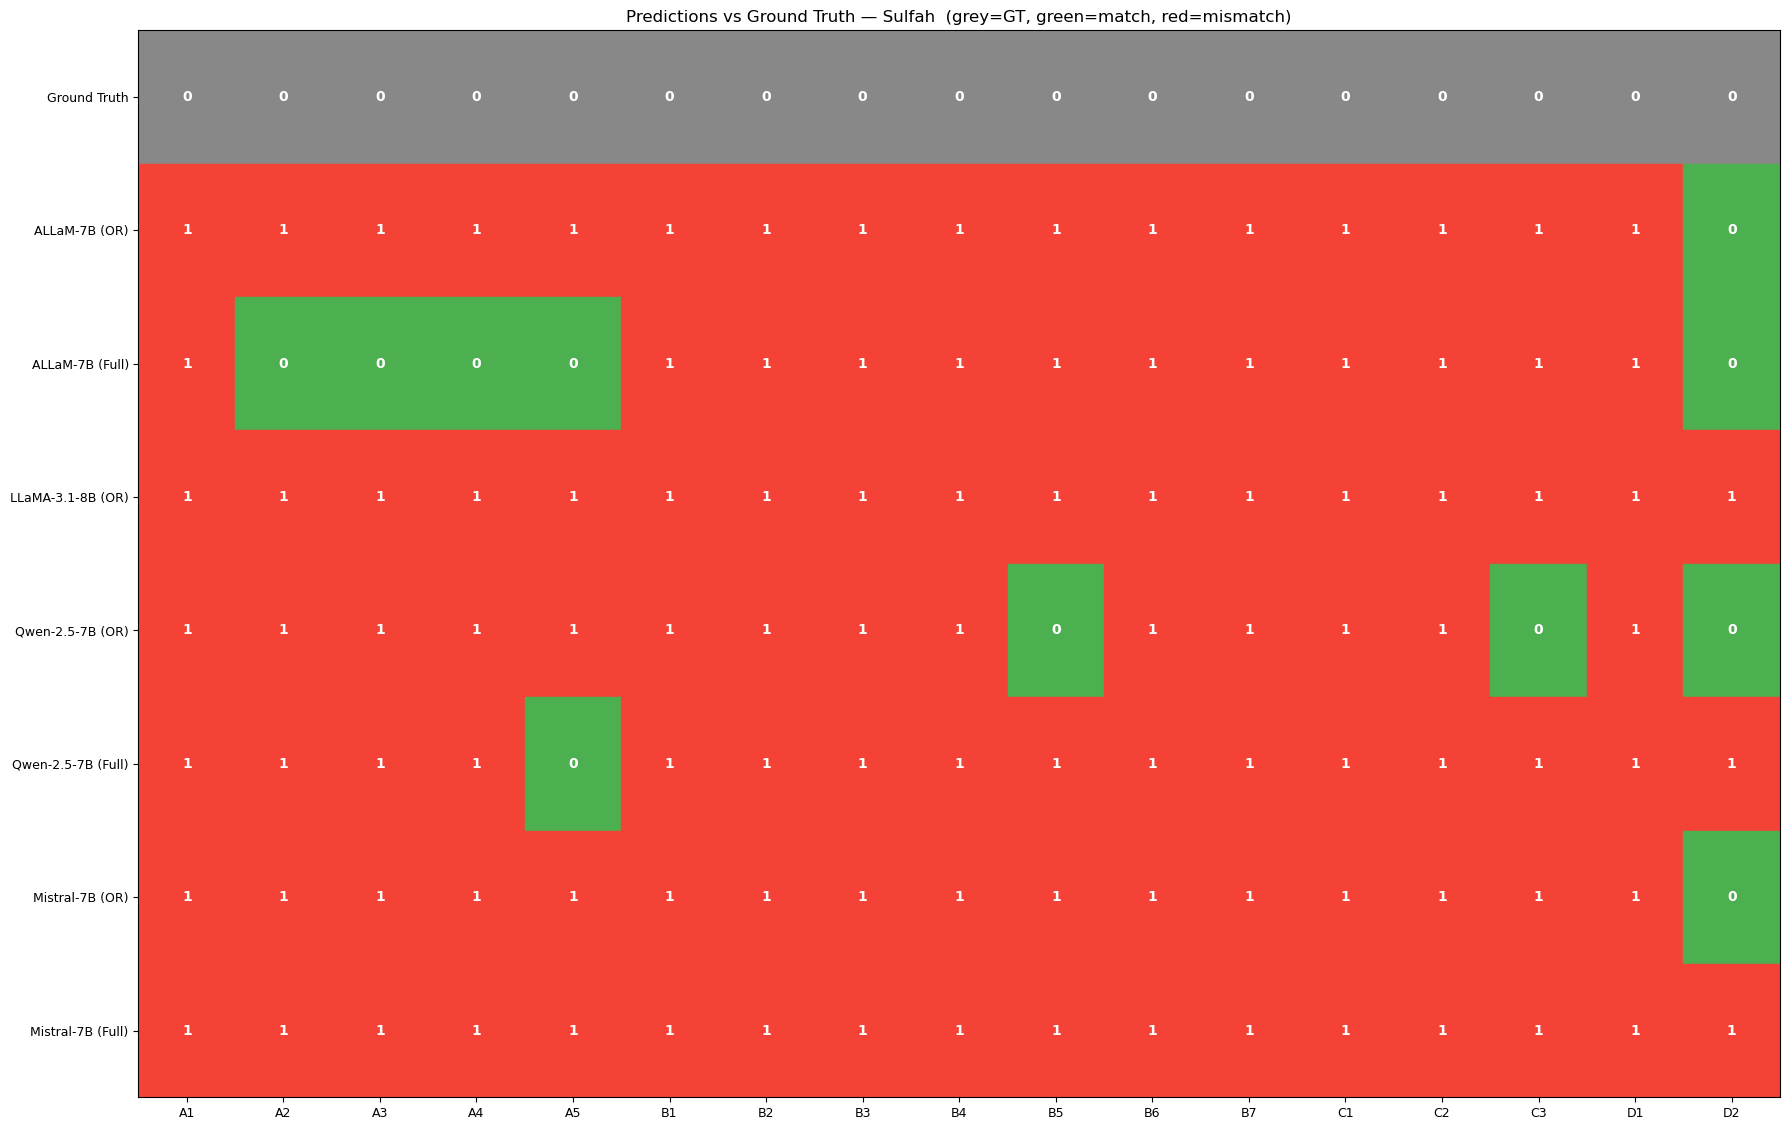

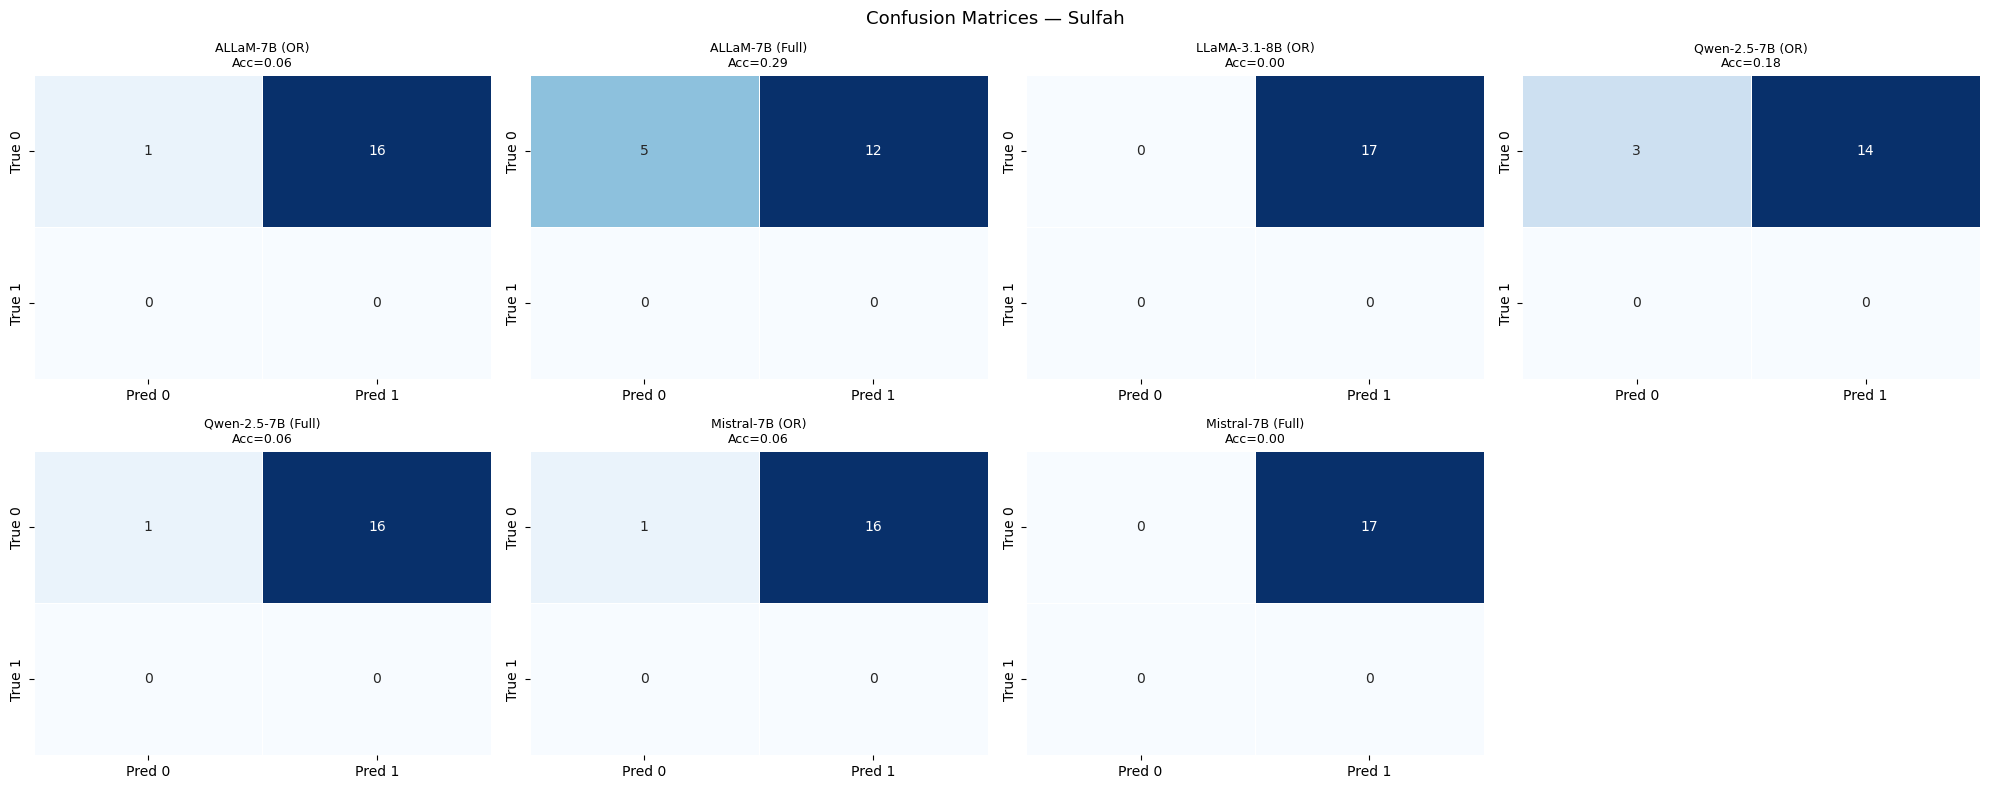

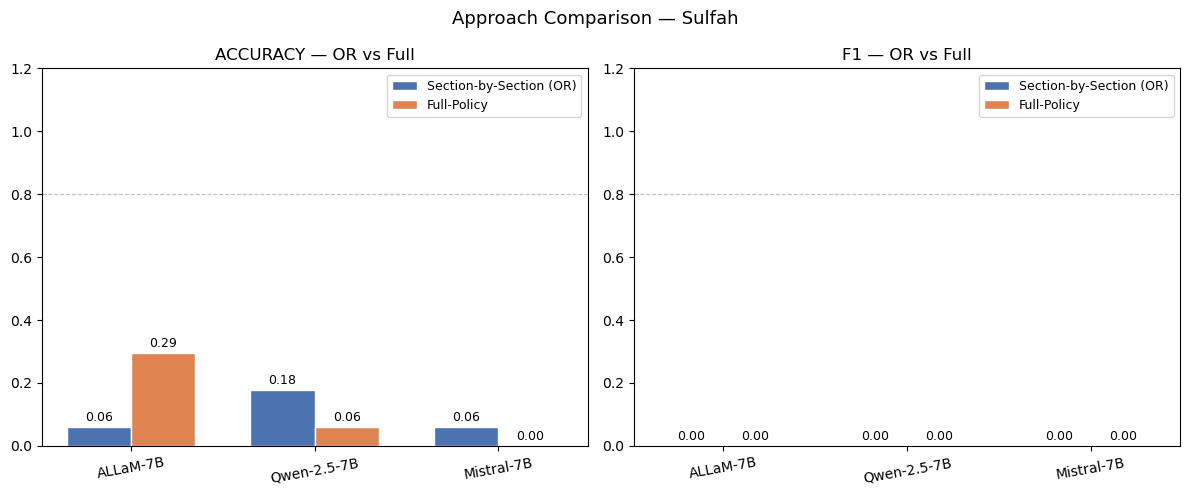

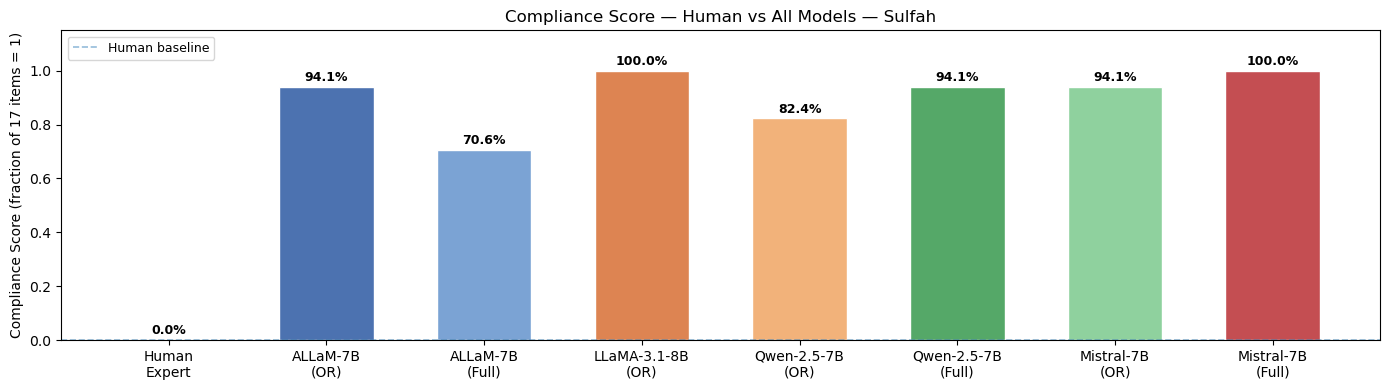

✓ All figures saved for Sulfah


In [26]:
# Change to match app you just ran:
PLOT_APP = APP_NAME

app_res = [r for r in all_apps_results if r['app'] == PLOT_APP]
ground_truth_plot = load_ground_truth(PLOT_APP)
COLORS = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot))
bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    label = f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})"
    bars = ax.bar(x + offset, vals, bar_w, label=label,
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3)
ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"All Models × Both Approaches — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
plt.tight_layout()
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(ground_truth_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float)
gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:      color, tc = "#888888", "white"
        elif np.isnan(val): color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:           color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title(f"Predictions vs Ground Truth — {PLOT_APP}  (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: Confusion matrices
ncols = 4
nrows = int(np.ceil(len(app_res) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for ax, res in zip(axes, app_res):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=[0,1])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
                linewidths=0.5, cbar=False)
    ax.set_title(f"{res['model']} ({'OR' if 'OR' in res['approach'] else 'Full'})\nAcc={res['accuracy']:.2f}", fontsize=9)
for ax in axes[len(app_res):]: ax.set_visible(False)
fig.suptitle(f"Confusion Matrices — {PLOT_APP}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 4: Approach comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'   in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full' in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x = np.arange(len(both)); width = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax.bar(x - width/2, [sec_dict[m][metric]  for m in both], width,
                    label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax.bar(x + width/2, [full_dict[m][metric] for m in both], width,
                    label="Full-Policy", color="#DD8452", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(both, rotation=10)
        ax.set_ylim(0, 1.2); ax.set_title(f"{metric.upper()} — OR vs Full")
        ax.legend(fontsize=9); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()

# Fig 5: Compliance scores (OR and Full only, no Majority)
filtered = [r for r in app_res if 'Majority' not in r['approach']]
score_labels = ["Human\nExpert"] + [f"{r['model']}\n({'OR' if 'OR' in r['approach'] else 'Full'})" for r in filtered]
score_values = [filtered[0]["human_score"]] + [r["llm_score"] for r in filtered]
bar_colors   = ["#2c7bb6"] + COLORS[:len(filtered)]
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(score_labels, score_values, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(score_values[0], color="#2c7bb6", linestyle="--", lw=1.2, alpha=0.5, label="Human baseline")
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score (fraction of 17 items = 1)")
ax.set_title(f"Compliance Score — Human vs All Models — {PLOT_APP}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PLOT_APP}_compliance_scores.png", dpi=150); plt.show()
print(f"✓ All figures saved for {PLOT_APP}")

## Cross-App Comparison

In [12]:
import pandas as pd, os

OUTPUT_DIR = "results"
csv_path = "results"

# Load old results from CSVs
def load_results_from_csv(csv_path):
    if not os.path.exists(csv_path):
        print(f"  ⚠ Not found: {csv_path}")
        return []
    df = pd.read_csv(csv_path)
    results = []
    for _, row in df.iterrows():
        results.append({
            "model":       row["model"],
            "approach":    row["approach"],
            "app":         row["app"],
            "accuracy":    row["accuracy"],
            "precision":   row["precision"],
            "recall":      row["recall"],
            "f1":          row["f1"],
            "kappa":       row["kappa"],
            "mcc":         row["mcc"],
            "human_score": row["human_score"],
            "llm_score":   row["llm_score"],
            "predictions": {},
            "y_true": [], "y_pred": [],
        })
    return results

# Load all 4 old apps
all_apps_results = []
for app in ["Circlys", "Dinar", "Safqah", "Tarmeez", "Tamra Capital", "Malaa", "Aseel Invest", "Sahm", "Hakbah", "Dawul", "Sukuk", "Awaed", "Abyan", "Manafa", "Rakeez", "Emakn Alarabiya", "Money Loop", "Sulfah", "Ta3meed"]:
    all_apps_results += load_results_from_csv(f"{OUTPUT_DIR}/{app}_evaluation_summary.csv")

print(f"✓ Loaded {len(all_apps_results)} results from CSVs")

✓ Loaded 144 results from CSVs


In [13]:
# Build summary dataframe from all apps
metric_cols = ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]
all_df = pd.DataFrame([{k: r[k] for k in metric_cols} for r in all_apps_results])
all_df.to_csv(f"{OUTPUT_DIR}/ALL_APPS_summary.csv", index=False)

apps_done = all_df['app'].unique().tolist()
print(f"Apps in comparison: {apps_done}")
print(all_df[["app","model","approach","accuracy","f1","kappa"]].to_string(index=False))

Apps in comparison: ['Circlys', 'Dinar', 'Safqah', 'Tarmeez', 'Tamra Capital', 'Malaa', 'Aseel Invest', 'Sahm', 'Hakbah', 'Dawul', 'Sukuk', 'Awaed', 'Abyan', 'Manafa', 'Rakeez', 'Emakn Alarabiya', 'Money Loop', 'Sulfah', 'Ta3meed']
            app        model                approach  accuracy       f1     kappa
        Circlys     ALLaM-7B Section-by-Section (OR)  0.411765 0.545455 -0.133333
        Circlys     ALLaM-7B             Full-Policy  0.647059 0.666667  0.301370
        Circlys LLaMA-3.1-8B Section-by-Section (OR)  0.470588 0.640000  0.000000
        Circlys LLaMA-3.1-8B             Full-Policy  0.647059 0.727273  0.320000
        Circlys  Qwen-2.5-7B Section-by-Section (OR)  0.470588 0.640000  0.000000
        Circlys  Qwen-2.5-7B             Full-Policy  0.705882 0.761905  0.429530
        Circlys   Mistral-7B Section-by-Section (OR)  0.529412 0.666667  0.105263
        Circlys   Mistral-7B             Full-Policy  0.705882 0.761905  0.429530
          Dinar     ALLaM-7B S

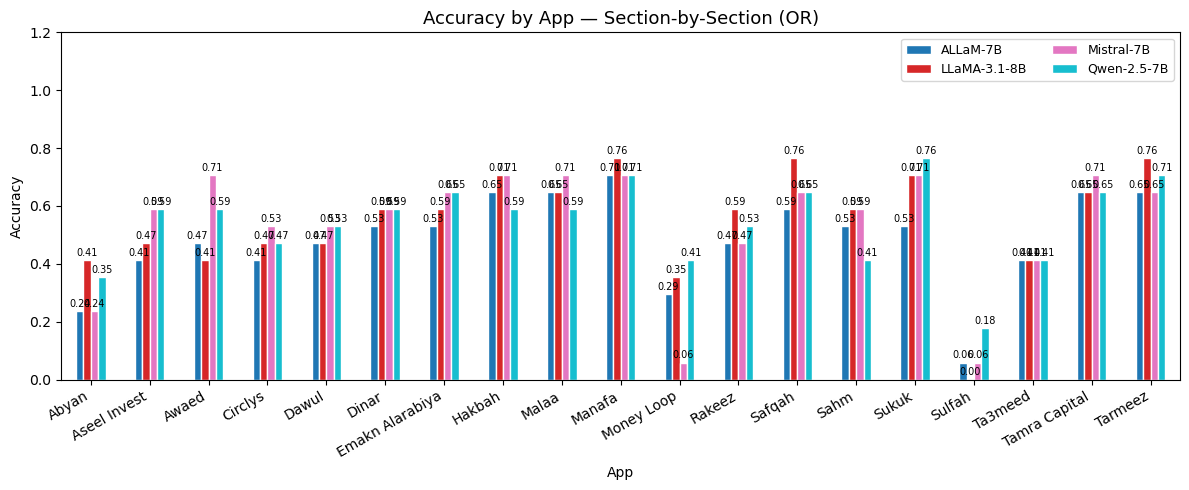

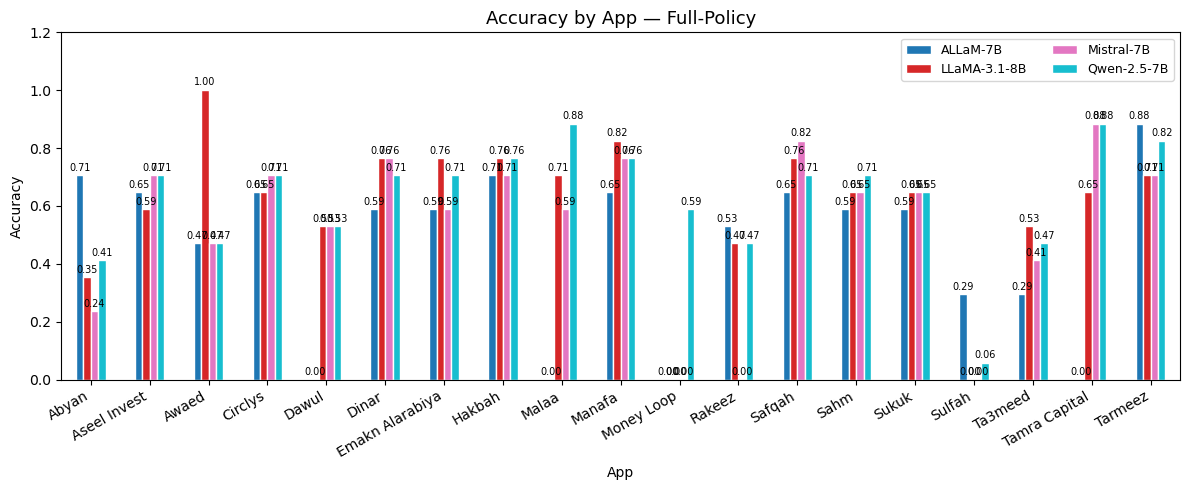

✓ Cross-app accuracy charts saved


In [15]:
COLORS10 = ["#4C72B0","#DD8452","#55A868","#C44E52","#9467BD","#8C564B","#E377C2","#7F7F7F","#BCBD22","#17BECF"]
APPROACH_COLORS = {"Section-by-Section (OR)": "#4C72B0", "Full-Policy": "#DD8452"}

# ── Cross-App Fig 1: Accuracy per app per model (grouped by approach) ─────────
for approach in ["Section-by-Section (OR)", "Full-Policy"]:
    sub = all_df[all_df['approach'] == approach]
    if sub.empty: continue
    pivot = sub.pivot(index='app', columns='model', values='accuracy')
    ax = pivot.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white')
    ax.set_title(f"Accuracy by App — {approach}", fontsize=13)
    ax.set_ylabel("Accuracy"); ax.set_xlabel("App")
    ax.set_ylim(0, 1.2); ax.legend(fontsize=9, ncol=2)
    plt.xticks(rotation=30, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    plt.tight_layout()
    fname = approach.replace(' ','_').replace('(','').replace(')','').replace('/','')
    plt.savefig(f"{OUTPUT_DIR}/CROSS_accuracy_{fname}.png", dpi=150); plt.show()
print("✓ Cross-app accuracy charts saved")

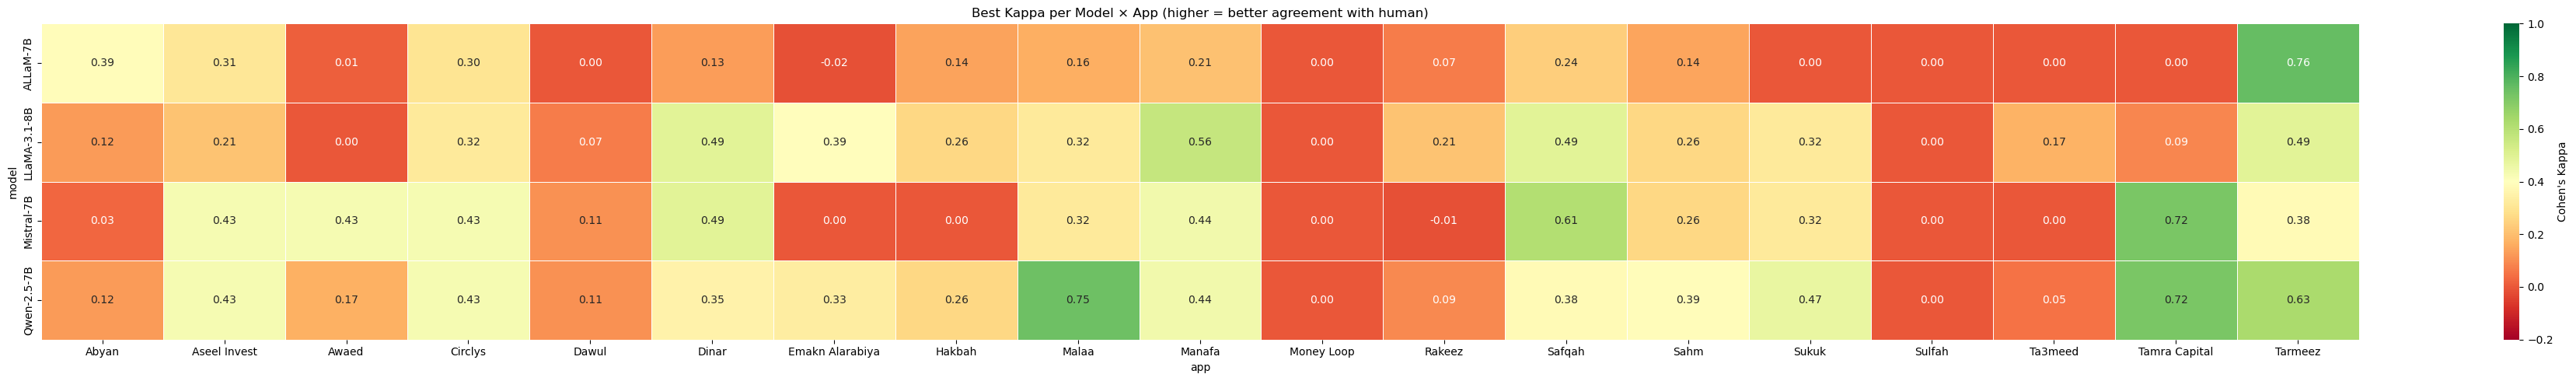

✓ Kappa heatmap saved


In [10]:
# ── Cross-App Fig 2: Kappa heatmap — model × app (best approach per model/app) ─
best_rows = all_df.loc[all_df.groupby(['app','model'])['kappa'].idxmax()]
pivot_kappa = best_rows.pivot(index='model', columns='app', values='kappa')
fig, ax = plt.subplots(figsize=(max(8, len(apps_done)*2), 5))
sns.heatmap(pivot_kappa, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-0.2, vmax=1.0, ax=ax, linewidths=0.5, cbar_kws={"label": "Cohen's Kappa"})
ax.set_title("Best Kappa per Model × App (higher = better agreement with human)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/CROSS_kappa_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Kappa heatmap saved")

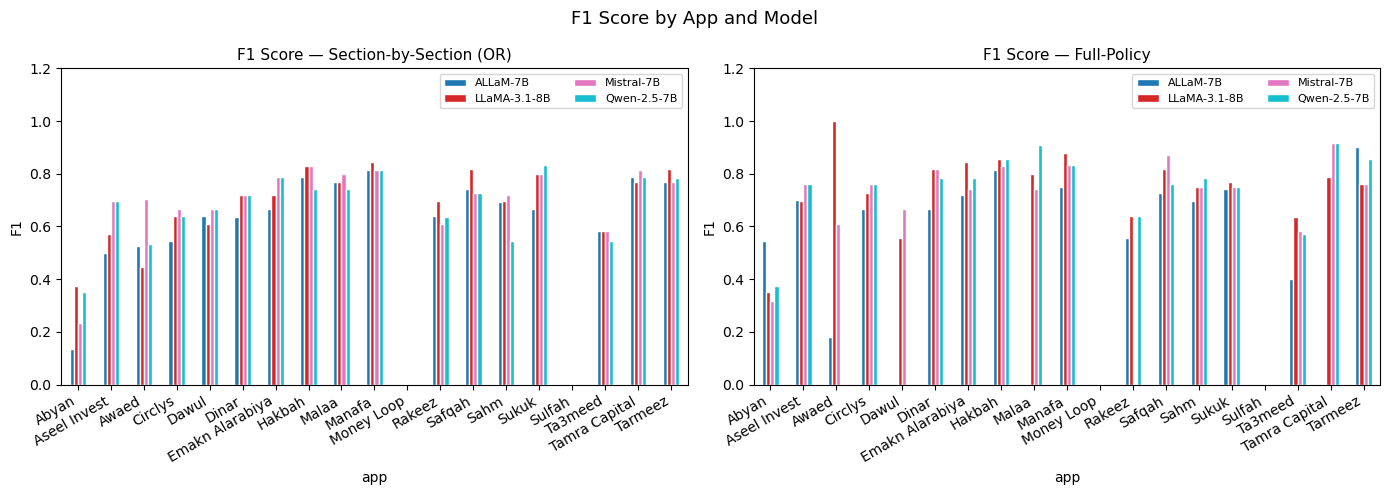

✓ F1 comparison saved


In [14]:
# ── Cross-App Fig 3: F1 comparison — OR vs Full per app ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ["Section-by-Section (OR)", "Full-Policy"]):
    sub = all_df[all_df['approach'] == approach]
    if sub.empty:
        ax.set_visible(False); continue
    pivot = sub.pivot(index='app', columns='model', values='f1')
    pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title(f"F1 Score — {approach}", fontsize=11)
    ax.set_ylabel("F1"); ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8, ncol=2)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
fig.suptitle("F1 Score by App and Model", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/CROSS_f1_comparison.png", dpi=150); plt.show()
print("✓ F1 comparison saved")

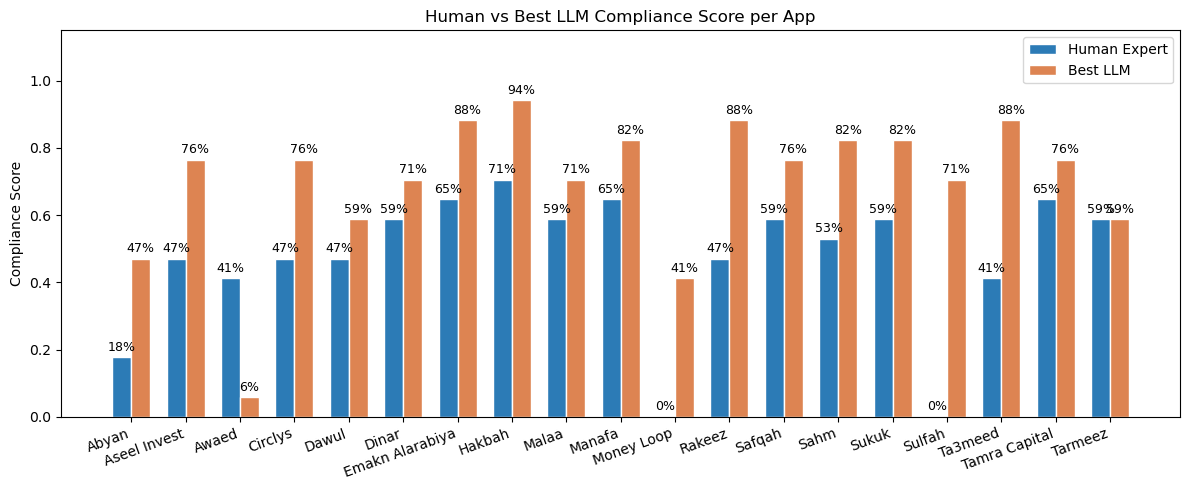


✓ All cross-app figures saved

Best performing model per app:
            app        model                approach  accuracy       f1    kappa
          Abyan     ALLaM-7B             Full-Policy  0.705882 0.545455 0.388489
   Aseel Invest  Qwen-2.5-7B             Full-Policy  0.705882 0.761905 0.429530
          Awaed   Mistral-7B Section-by-Section (OR)  0.705882 0.705882 0.429530
        Circlys  Qwen-2.5-7B             Full-Policy  0.705882 0.761905 0.429530
          Dawul  Qwen-2.5-7B Section-by-Section (OR)  0.529412 0.666667 0.105263
          Dinar LLaMA-3.1-8B             Full-Policy  0.764706 0.818182 0.492537
Emakn Alarabiya LLaMA-3.1-8B             Full-Policy  0.764706 0.846154 0.392857
         Hakbah LLaMA-3.1-8B             Full-Policy  0.764706 0.857143 0.260870
          Malaa  Qwen-2.5-7B             Full-Policy  0.882353 0.909091 0.746269
         Manafa LLaMA-3.1-8B             Full-Policy  0.823529 0.880000 0.564103
     Money Loop     ALLaM-7B Section-by-Sectio

In [12]:
# ── Cross-App Fig 4: Human compliance score vs best LLM score per app ────────
human_scores = all_df.groupby('app')['human_score'].first().reset_index()
best_llm = all_df.loc[all_df.groupby('app')['accuracy'].idxmax()][['app','llm_score','model','approach']]
merged = human_scores.merge(best_llm, on='app')

x = np.arange(len(merged))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, merged['human_score'], width, label='Human Expert', color='#2c7bb6', edgecolor='white')
b2 = ax.bar(x + width/2, merged['llm_score'],   width, label='Best LLM',     color='#DD8452', edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.0%}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(merged['app'], rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score")
ax.set_title("Human vs Best LLM Compliance Score per App")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/CROSS_compliance_comparison.png", dpi=150); plt.show()

print("\n✓ All cross-app figures saved")
print(f"\nBest performing model per app:")
print(all_df.loc[all_df.groupby('app')['kappa'].idxmax()][['app','model','approach','accuracy','f1','kappa']].to_string(index=False))

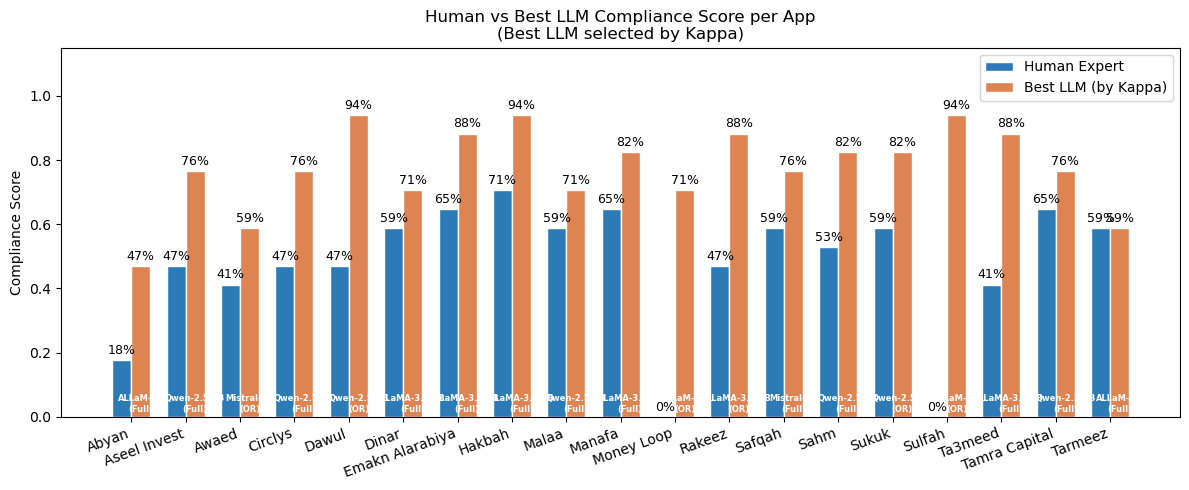


✓ All cross-app figures saved

Best performing model per app (by Kappa):
            app        model                approach  accuracy       f1    kappa
          Abyan     ALLaM-7B             Full-Policy  0.705882 0.545455 0.388489
   Aseel Invest  Qwen-2.5-7B             Full-Policy  0.705882 0.761905 0.429530
          Awaed   Mistral-7B Section-by-Section (OR)  0.705882 0.705882 0.429530
        Circlys  Qwen-2.5-7B             Full-Policy  0.705882 0.761905 0.429530
          Dawul  Qwen-2.5-7B Section-by-Section (OR)  0.529412 0.666667 0.105263
          Dinar LLaMA-3.1-8B             Full-Policy  0.764706 0.818182 0.492537
Emakn Alarabiya LLaMA-3.1-8B             Full-Policy  0.764706 0.846154 0.392857
         Hakbah LLaMA-3.1-8B             Full-Policy  0.764706 0.857143 0.260870
          Malaa  Qwen-2.5-7B             Full-Policy  0.882353 0.909091 0.746269
         Manafa LLaMA-3.1-8B             Full-Policy  0.823529 0.880000 0.564103
     Money Loop     ALLaM-7B Sectio

In [13]:
# ── Cross-App Fig 4: Human compliance score vs best LLM score per app ────────
human_scores = all_df.groupby('app')['human_score'].first().reset_index()

# Best LLM selected by kappa (best agreement with human), not accuracy
best_llm = all_df.loc[all_df.groupby('app')['kappa'].idxmax()][
    ['app','llm_score','model','approach','kappa']]
merged = human_scores.merge(best_llm, on='app').sort_values('app')

x = np.arange(len(merged))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, merged['human_score'], width,
            label='Human Expert', color='#2c7bb6', edgecolor='white')
b2 = ax.bar(x + width/2, merged['llm_score'],   width,
            label='Best LLM (by Kappa)', color='#DD8452', edgecolor='white')

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.0%}", ha='center', va='bottom', fontsize=9)

# Annotate best model name under each LLM bar
for idx, (_, row) in enumerate(merged.iterrows()):
    ax.text(x[idx] + width/2, 0.01,
            f"{row['model']}\n({'OR' if 'OR' in row['approach'] else 'Full'})",
            ha='center', va='bottom', fontsize=6, color='white', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(merged['app'], rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel("Compliance Score")
ax.set_title("Human vs Best LLM Compliance Score per App\n(Best LLM selected by Kappa)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/CROSS_compliance_comparison.png", dpi=150); plt.show()

print("\n✓ All cross-app figures saved")
print(f"\nBest performing model per app (by Kappa):")
print(all_df.loc[all_df.groupby('app')['kappa'].idxmax()][
    ['app','model','approach','accuracy','f1','kappa']].to_string(index=False))

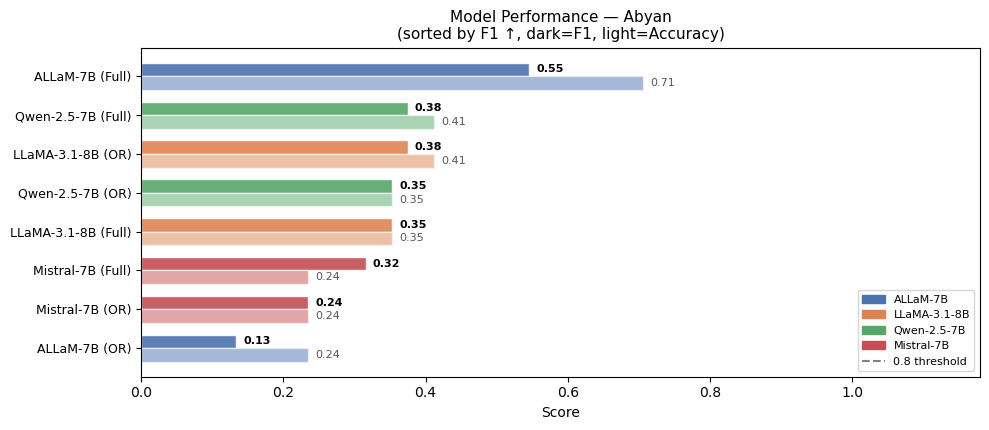

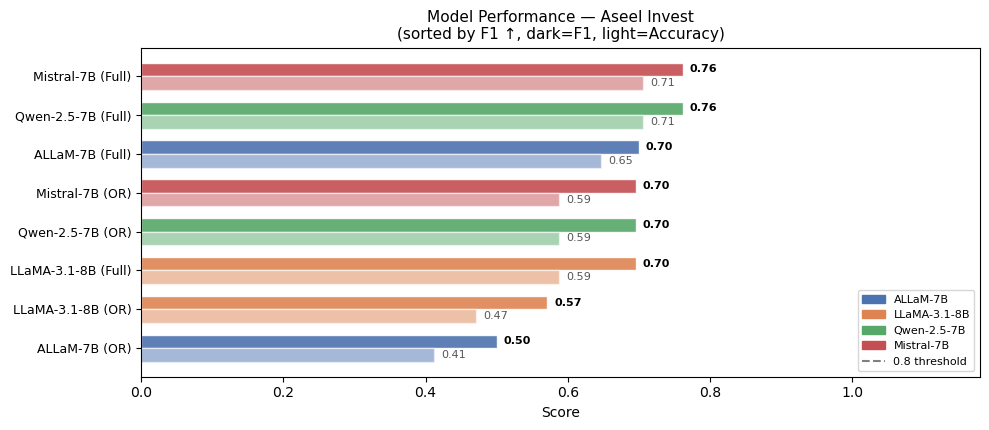

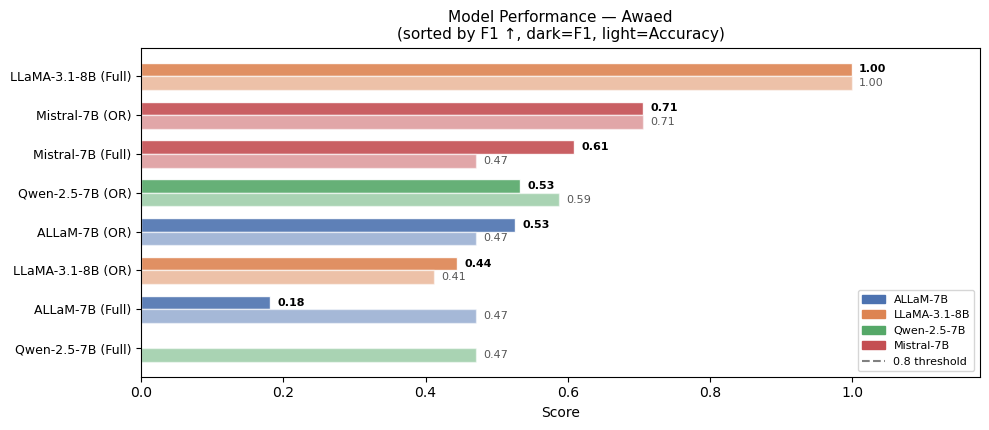

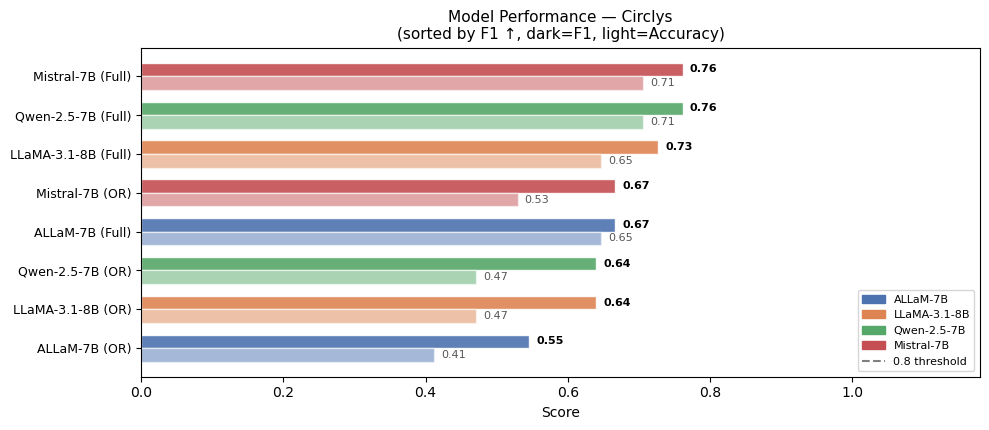

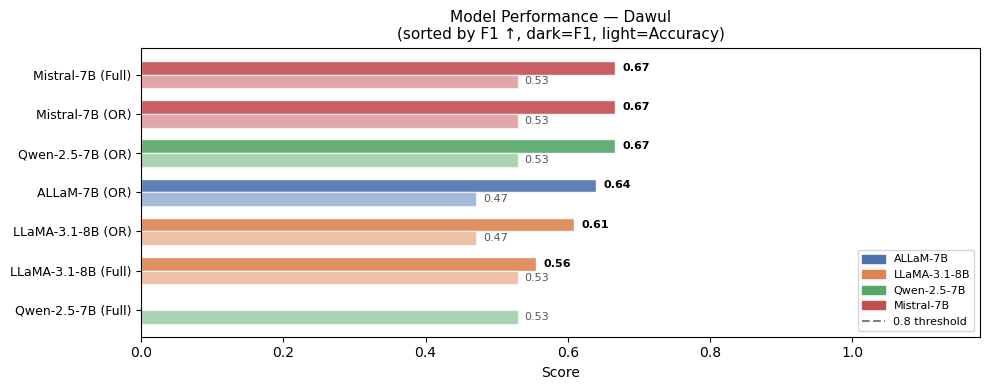

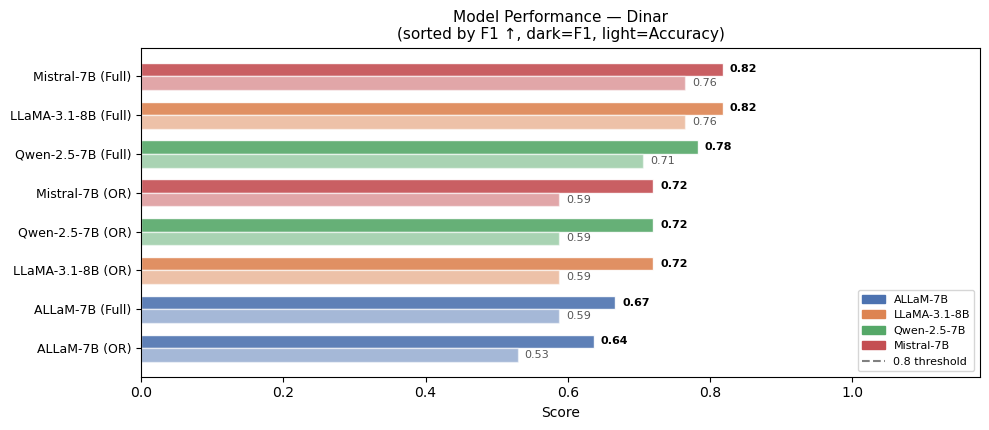

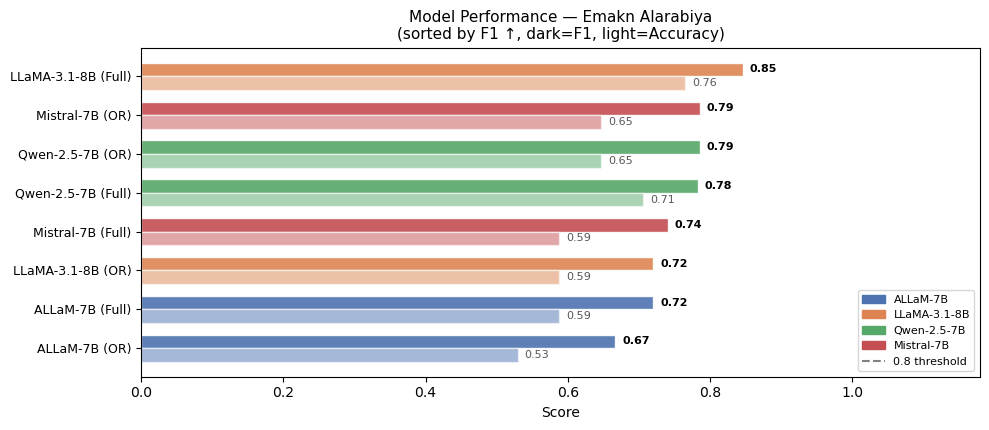

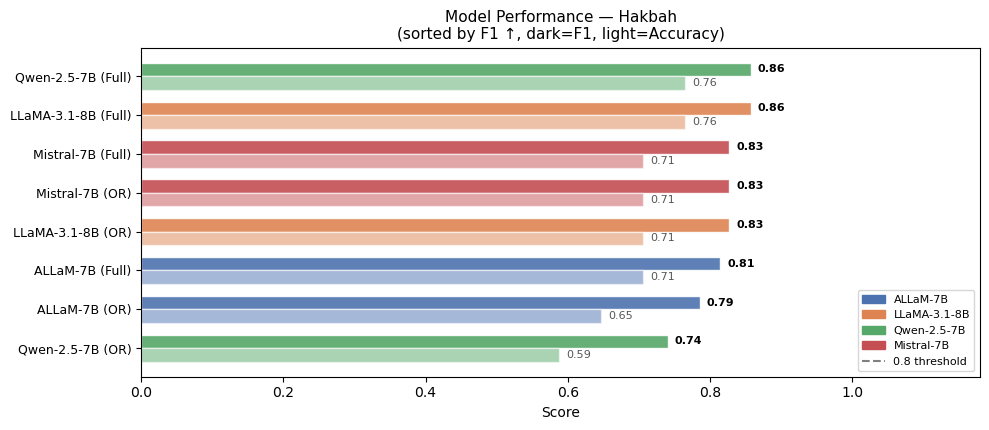

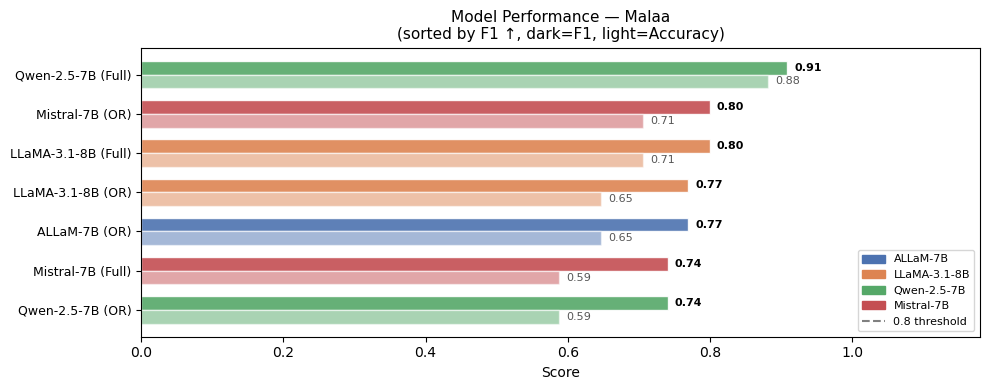

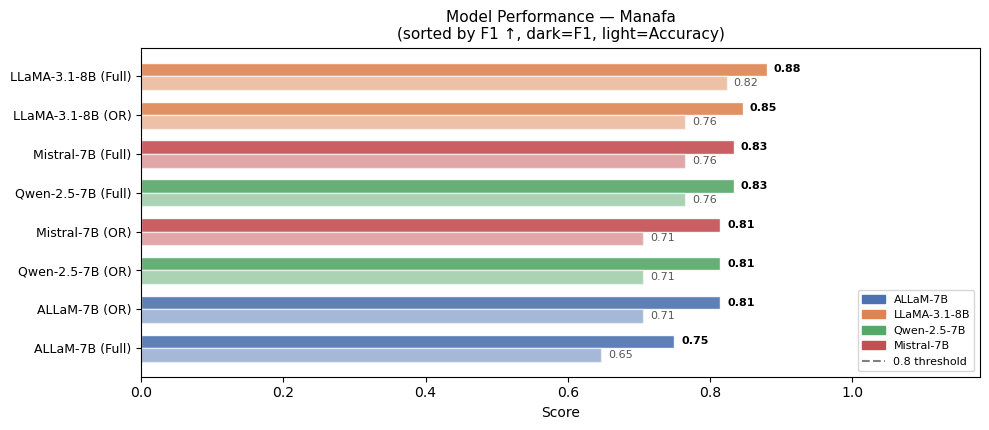

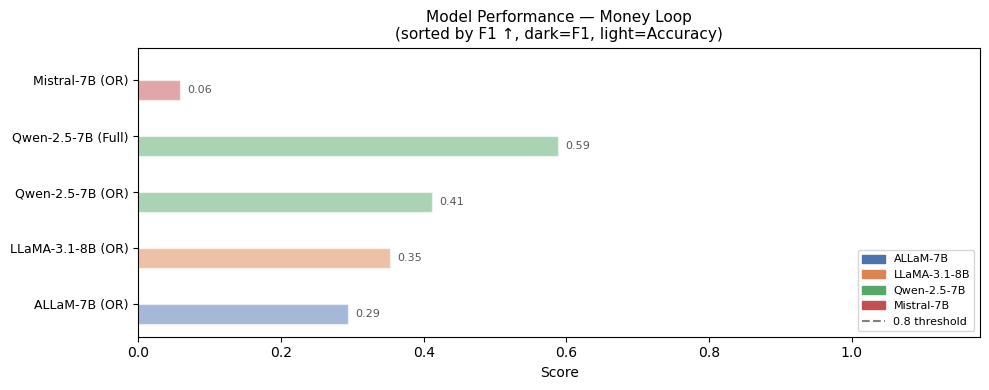

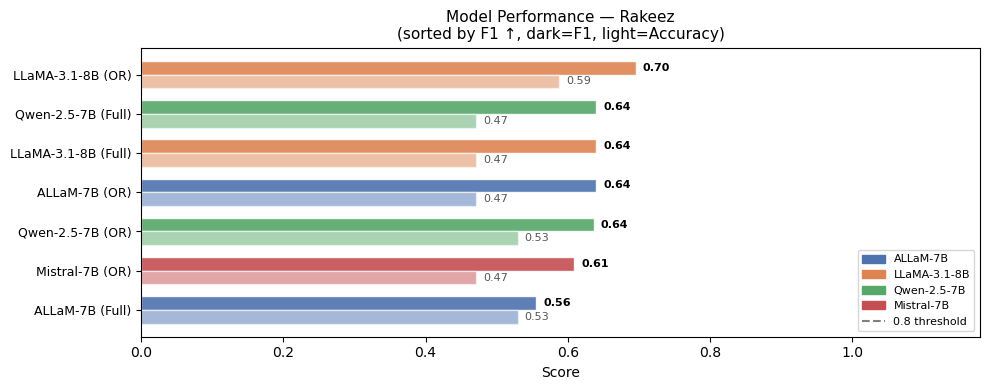

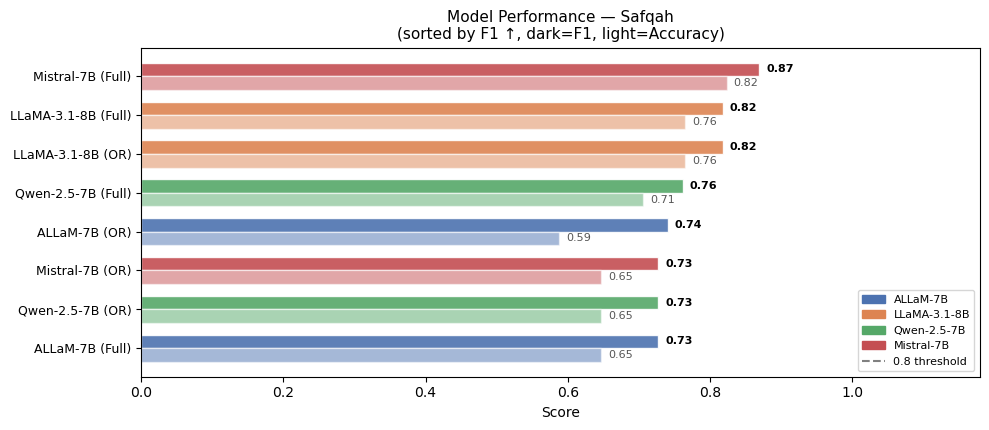

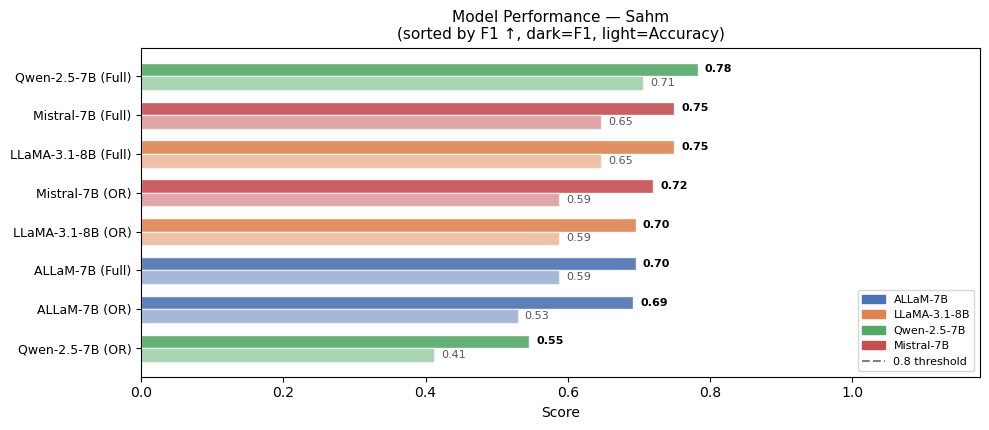

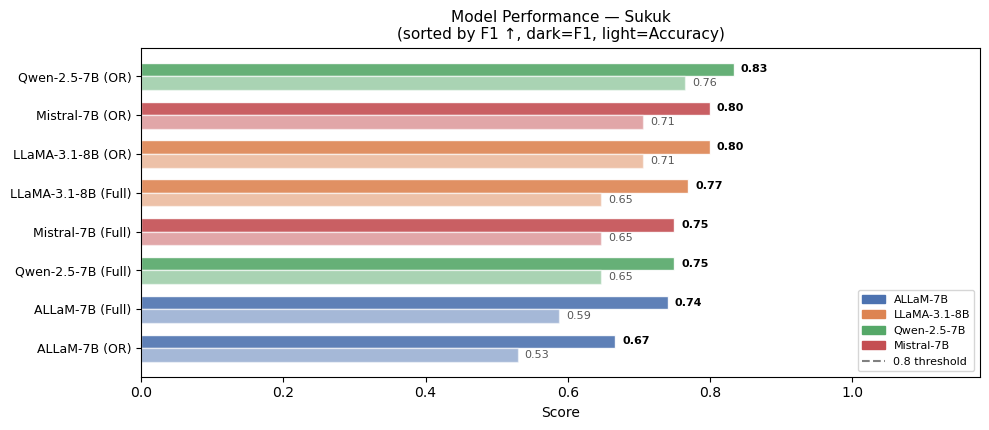

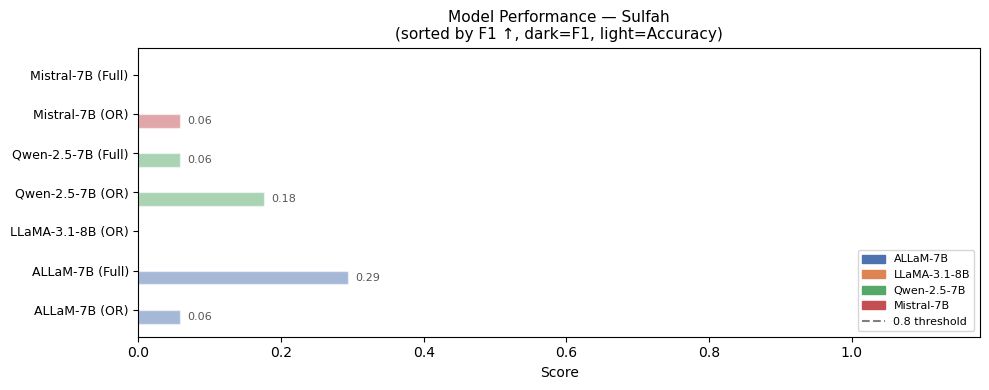

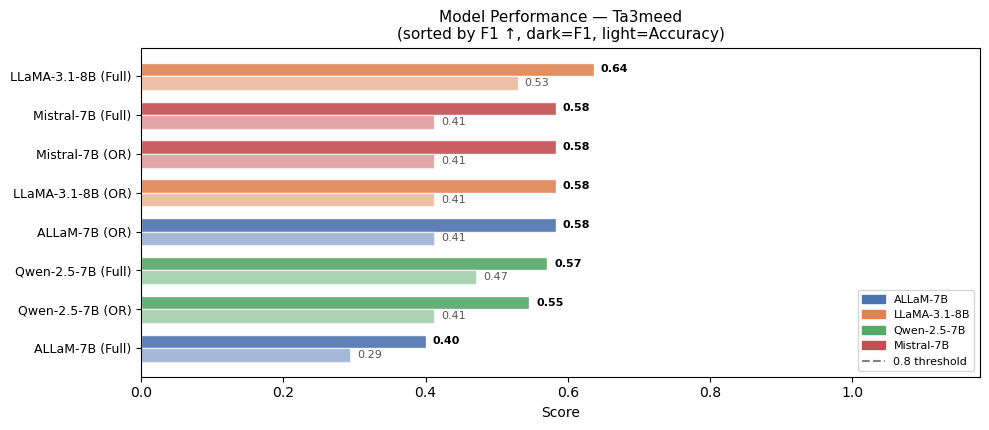

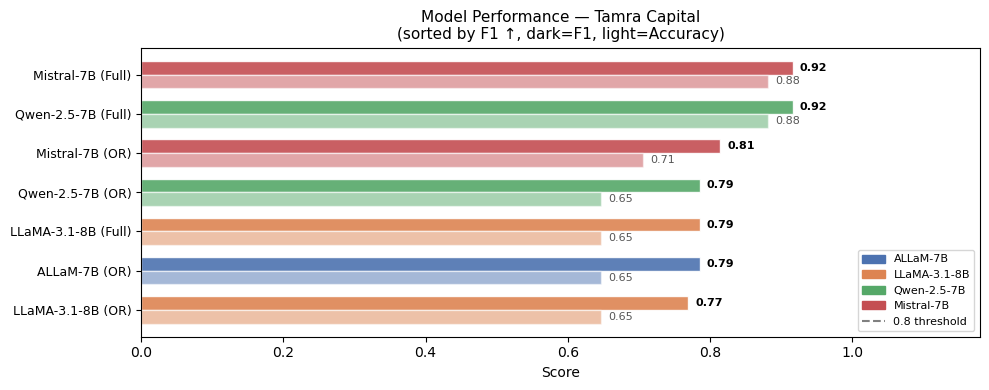

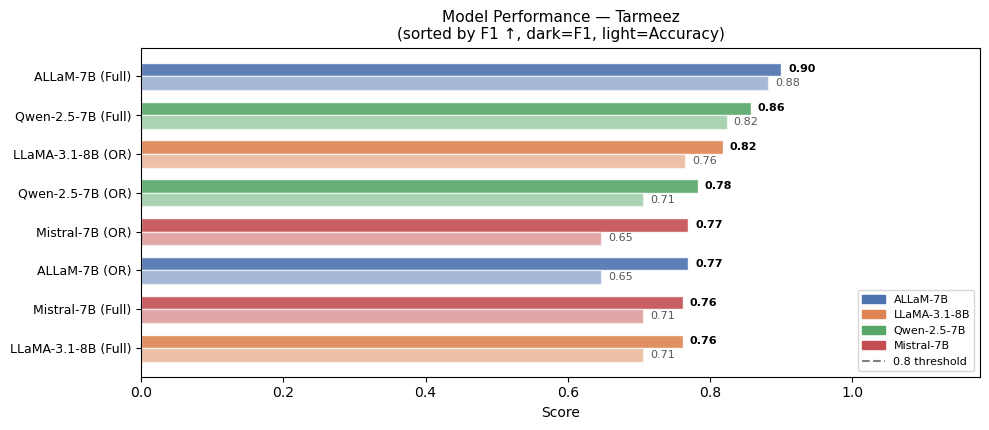

✓ Cell A: Per-app horizontal sorted charts saved


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Per-App Horizontal Sorted Bar Charts
# For each app: best result per model–approach combo, sorted by F1 descending
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

COLORS_MODELS = {
    "ALLaM-7B":    "#4C72B0",
    "LLaMA-3.1-8B":"#DD8452",
    "Qwen-2.5-7B": "#55A868",
    "Mistral-7B":  "#C44E52",
}
APPROACH_HATCH = {"Section-by-Section (OR)": "", "Full-Policy": "///"}

all_apps = sorted(set(r["app"] for r in all_apps_results))

for app in all_apps:
    app_data = [r for r in all_apps_results if r["app"] == app]
    if not app_data:
        continue

    rows = []
    for r in app_data:
        appr_short = "OR" if "OR" in r["approach"] else "Full"
        rows.append({
            "label": f"{r['model']} ({appr_short})",
            "model": r["model"],
            "approach": r["approach"],
            "f1": r["f1"],
            "accuracy": r["accuracy"],
            "kappa": r["kappa"],
            "mcc": r["mcc"],
        })

    df_app = pd.DataFrame(rows).sort_values("f1", ascending=True)  # ascending for horizontal

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_app) * 0.55)))

    y = np.arange(len(df_app))
    bar_h = 0.35

    bars_f1 = ax.barh(y + bar_h/2, df_app["f1"], bar_h,
                      color=[COLORS_MODELS.get(m, "#999") for m in df_app["model"]],
                      label="F1", alpha=0.9, edgecolor="white")
    bars_acc = ax.barh(y - bar_h/2, df_app["accuracy"], bar_h,
                       color=[COLORS_MODELS.get(m, "#999") for m in df_app["model"]],
                       label="Accuracy", alpha=0.5, edgecolor="white")

    for bar in bars_f1:
        w = bar.get_width()
        if w > 0.02:
            ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{w:.2f}", va="center", ha="left", fontsize=8, fontweight="bold")
    for bar in bars_acc:
        w = bar.get_width()
        if w > 0.02:
            ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{w:.2f}", va="center", ha="left", fontsize=8, color="#555")

    ax.set_yticks(y)
    ax.set_yticklabels(df_app["label"], fontsize=9)
    ax.set_xlim(0, 1.18)
    ax.set_xlabel("Score")
    ax.set_title(f"Model Performance — {app}\n(sorted by F1 ↑, dark=F1, light=Accuracy)", fontsize=11)

    model_patches = [mpatches.Patch(color=c, label=m) for m, c in COLORS_MODELS.items()]
    ax.legend(handles=model_patches + [plt.Line2D([0],[0], color='grey', ls='--', label='0.8 threshold')],
              fontsize=8, loc="lower right")

    plt.tight_layout()
    os.makedirs(f"{OUTPUT_DIR}/final_viz", exist_ok=True)
    plt.savefig(f"{OUTPUT_DIR}/final_viz/{app}_horizontal_sorted.png", dpi=150, bbox_inches="tight")
    plt.show()

print("✓ Cell A: Per-app horizontal sorted charts saved")

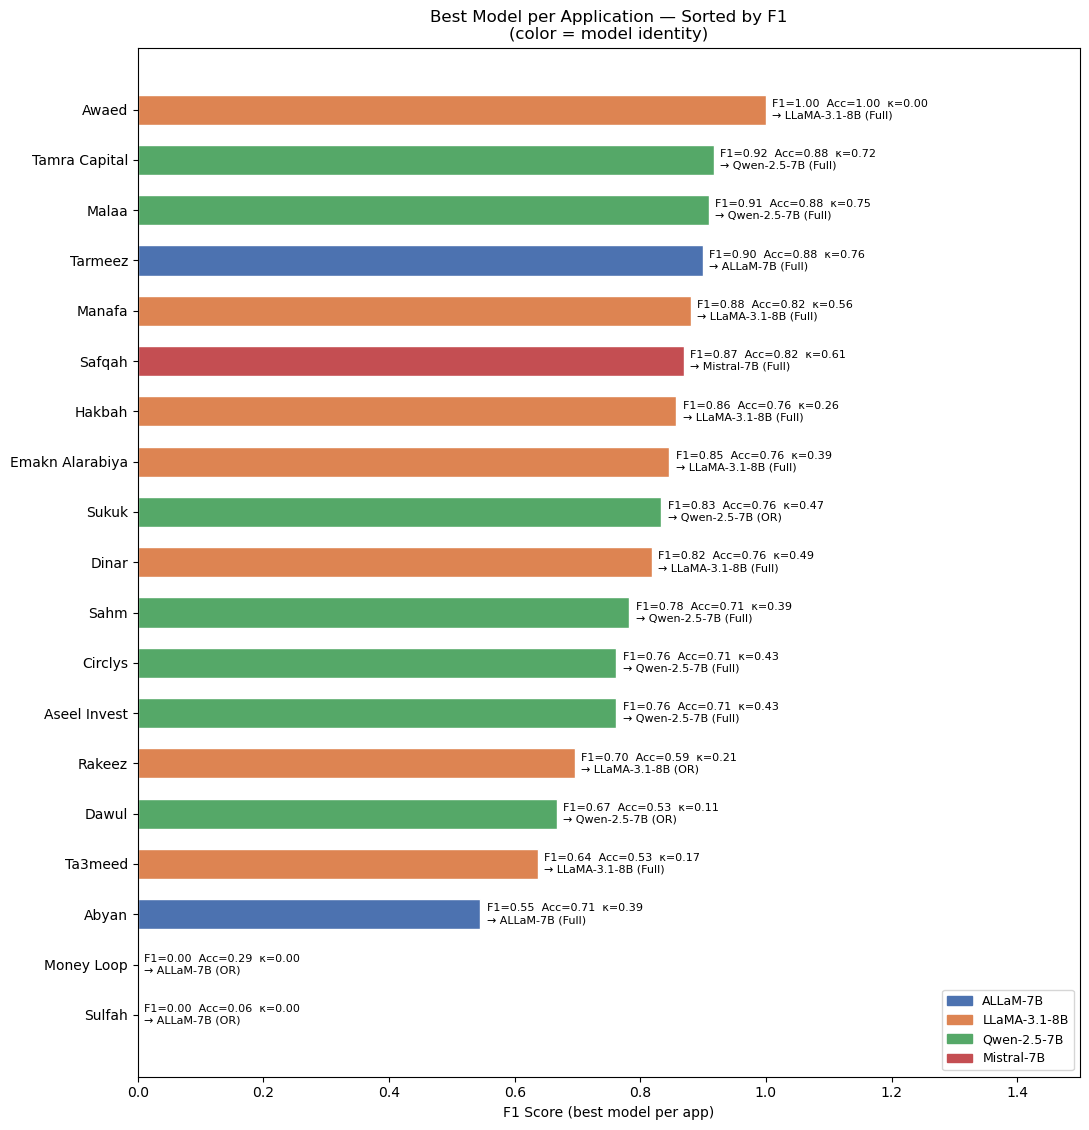

✓ Cell B: Best model per app summary saved


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Best Model × Approach per App (Single Summary Horizontal Bar Chart)
# Shows the top-performing model for each app sorted by F1, easy for a paper
# ─────────────────────────────────────────────────────────────────────────────

df_all = pd.DataFrame([
    {k: r[k] for k in ["model","approach","app","accuracy","f1","kappa","mcc","precision","recall"]}
    for r in all_apps_results
])

# Pick best result per app (by F1)
best_per_app = df_all.loc[df_all.groupby("app")["f1"].idxmax()].copy()
best_per_app["label"] = best_per_app["model"] + " (" + best_per_app["approach"].str.replace("Section-by-Section (OR)", "OR").str.replace("Full-Policy", "Full") + ")"
best_per_app = best_per_app.sort_values("f1", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(5, len(best_per_app) * 0.6)))
colors_bar = [COLORS_MODELS.get(m, "#999") for m in best_per_app["model"]]

bars = ax.barh(best_per_app["app"], best_per_app["f1"], color=colors_bar,
               edgecolor="white", height=0.6)

for bar, (_, row) in zip(bars, best_per_app.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f"F1={w:.2f}  Acc={row['accuracy']:.2f}  κ={row['kappa']:.2f}\n→ {row['label']}",
            va="center", ha="left", fontsize=8)

ax.set_xlim(0, 1.5)
ax.set_xlabel("F1 Score (best model per app)")
ax.set_title("Best Model per Application — Sorted by F1\n(color = model identity)", fontsize=12)
model_patches = [mpatches.Patch(color=c, label=m) for m, c in COLORS_MODELS.items()]
ax.legend(handles=model_patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_viz/SUMMARY_best_model_per_app.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Cell B: Best model per app summary saved")

Mean F1 per model × approach (all apps):
       model                approach       f1
LLaMA-3.1-8B             Full-Policy 0.746723
  Mistral-7B             Full-Policy 0.688648
  Mistral-7B Section-by-Section (OR) 0.628507
LLaMA-3.1-8B Section-by-Section (OR) 0.615935
 Qwen-2.5-7B Section-by-Section (OR) 0.607727
    ALLaM-7B             Full-Policy 0.604309
 Qwen-2.5-7B             Full-Policy 0.597018
    ALLaM-7B Section-by-Section (OR) 0.573468

★ Overall best: LLaMA-3.1-8B | Full-Policy


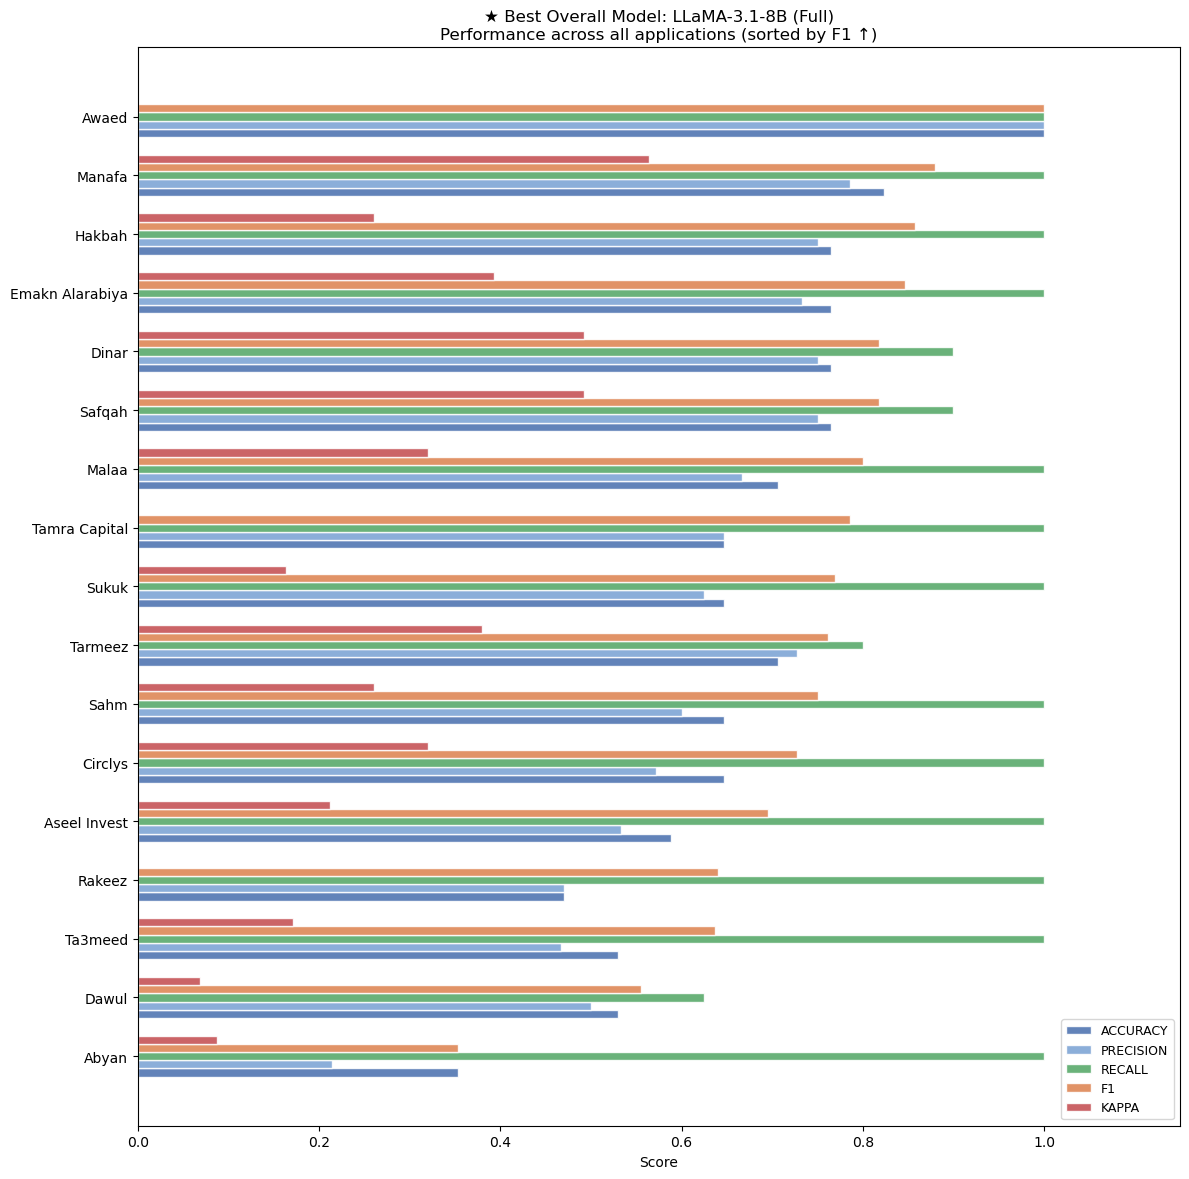

✓ Cell C: Best model (LLaMA-3.1-8B) cross-app performance saved


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Overall Best Model: Performance Across All Apps
# Identifies the single best model overall and shows its consistency across apps
# ─────────────────────────────────────────────────────────────────────────────

# Find the overall best model (by mean F1 across all apps, best approach per app)
model_mean_f1 = (df_all.groupby(["model","approach"])["f1"]
                 .mean().reset_index()
                 .sort_values("f1", ascending=False))
print("Mean F1 per model × approach (all apps):")
print(model_mean_f1.to_string(index=False))

best_model_name = model_mean_f1.iloc[0]["model"]
best_approach   = model_mean_f1.iloc[0]["approach"]
print(f"\n★ Overall best: {best_model_name} | {best_approach}")

best_model_df = df_all[
    (df_all["model"] == best_model_name) &
    (df_all["approach"] == best_approach)
].sort_values("f1", ascending=True)

metrics_show = ["accuracy", "precision", "recall", "f1", "kappa"]
colors_metric = ["#4C72B0","#7BA3D4","#55A868","#DD8452","#C44E52"]

fig, ax = plt.subplots(figsize=(12, max(5, len(best_model_df)*0.7)))

bar_h = 0.14
y = np.arange(len(best_model_df))

for j, (metric, col) in enumerate(zip(metrics_show, colors_metric)):
    offset = (j - len(metrics_show)/2 + 0.5) * bar_h
    bars = ax.barh(y + offset, best_model_df[metric], bar_h,
                   color=col, label=metric.upper(), alpha=0.88, edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(best_model_df["app"], fontsize=10)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Score")
approach_short = "OR" if "OR" in best_approach else "Full"
ax.set_title(f"★ Best Overall Model: {best_model_name} ({approach_short})\nPerformance across all applications (sorted by F1 ↑)", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_viz/BEST_MODEL_across_apps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Cell C: Best model ({best_model_name}) cross-app performance saved")

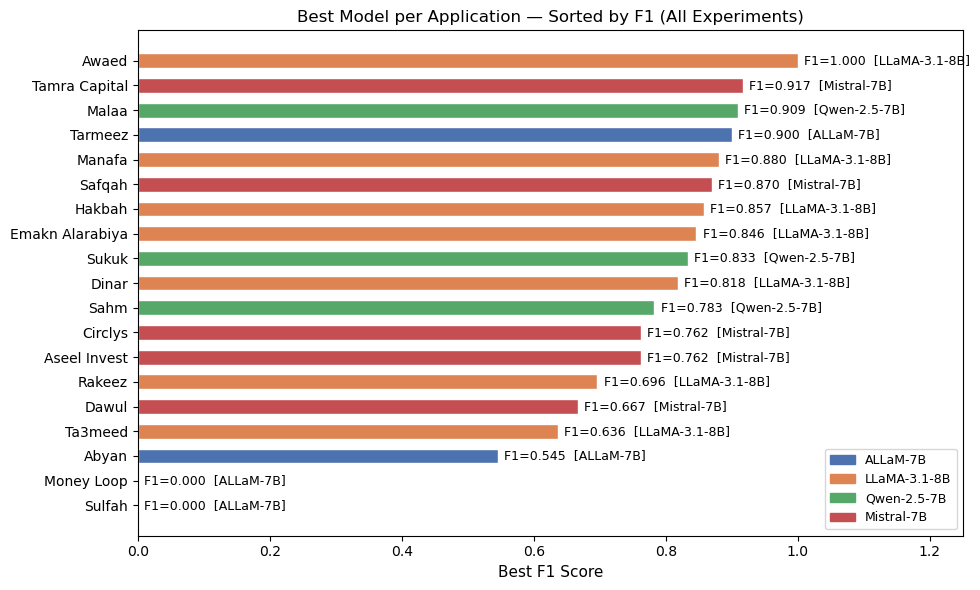

✓ Fig 1 saved


In [20]:
# ═══════════════════════════════════════════════════════════════════
# FINAL VIZ 1: Best Model per App — Sorted Horizontal Bar Chart (F1)
# ═══════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches

# Pick best result per (app, model) across all experiments and approaches
best_per_app_model = (
    df_all
    .groupby(['app', 'model'])
    .agg(f1=('f1', 'max'), kappa=('kappa', 'max'), accuracy=('accuracy', 'max'))
    .reset_index()
)

# For each app, pick the single best model by F1
best_per_app = best_per_app_model.loc[
    best_per_app_model.groupby('app')['f1'].idxmax()
].sort_values('f1', ascending=True)  # ascending for horizontal bar (best at top)

MODEL_PALETTE = {
    'ALLaM-7B':    '#4C72B0',
    'LLaMA-3.1-8B':'#DD8452',
    'Qwen-2.5-7B': '#55A868',
    'Mistral-7B':  '#C44E52',
}
bar_colors = [MODEL_PALETTE.get(m, '#888888') for m in best_per_app['model']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(best_per_app['app'], best_per_app['f1'], color=bar_colors,
               edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars, best_per_app.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"F1={row['f1']:.3f}  [{row['model']}]",
            va='center', fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_xlabel('Best F1 Score', fontsize=11)
ax.set_title('Best Model per Application — Sorted by F1 (All Experiments)', fontsize=12)
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in MODEL_PALETTE.items()]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FINAL_best_model_per_app_horizontal.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Fig 1 saved")

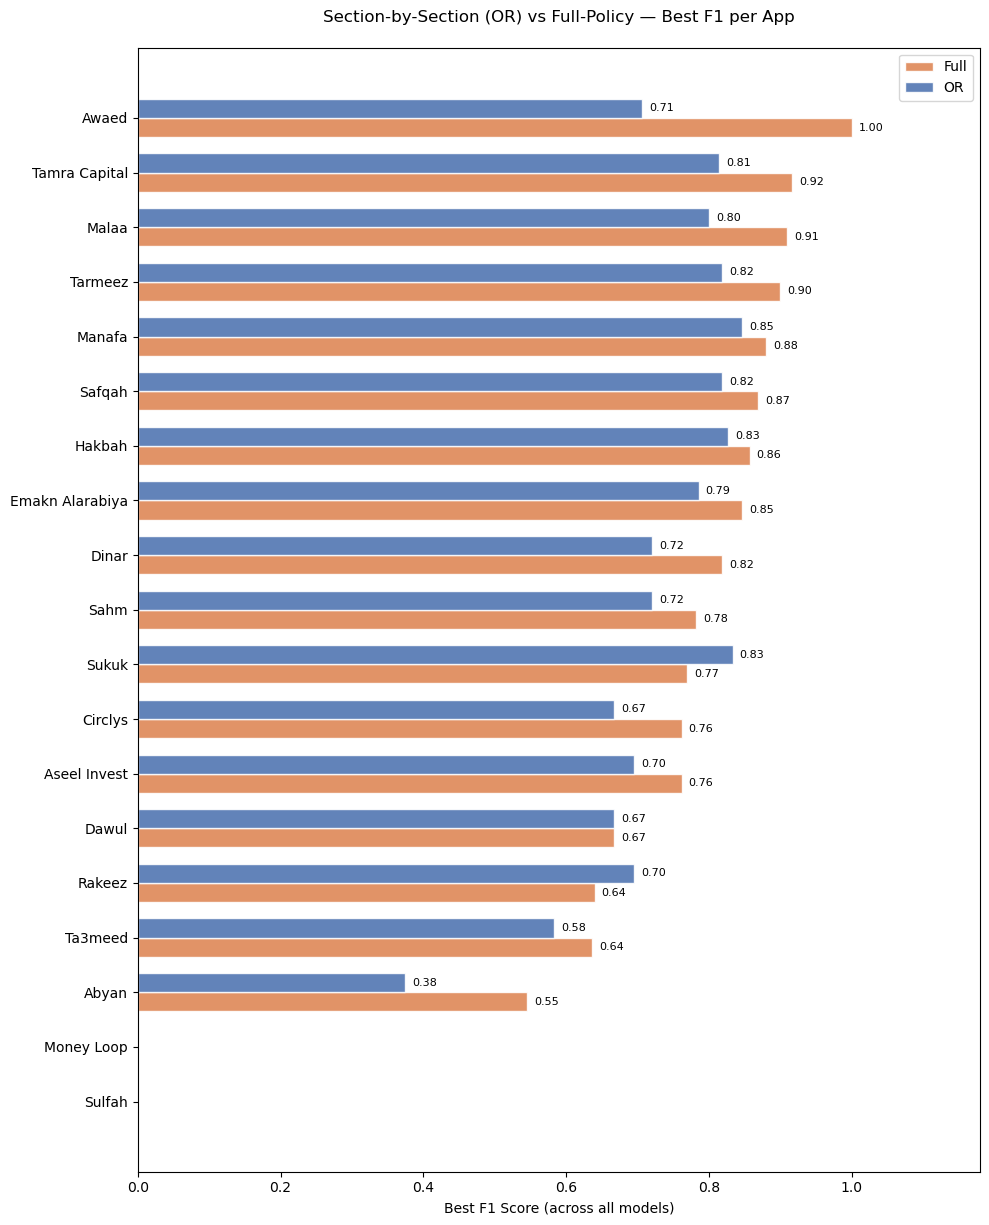

✓ Cell E: Approach comparison across apps saved


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Section-by-Section OR vs Full-Policy: Approach Comparison Across Apps
# Horizontal grouped bars per app, sorted by the gap between approaches
# ─────────────────────────────────────────────────────────────────────────────

pivot_approach = (df_all.groupby(["app","approach"])["f1"]
                  .max().unstack("approach").fillna(0))

# Rename columns for brevity
pivot_approach.columns = [c.replace("Section-by-Section (OR)", "OR").replace("Full-Policy","Full")
                           for c in pivot_approach.columns]

# Sort by OR score descending
if "OR" in pivot_approach.columns:
    pivot_approach = pivot_approach.sort_values("Full", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(pivot_approach)*0.65)))

bar_h = 0.35
y = np.arange(len(pivot_approach))
cols_present = pivot_approach.columns.tolist()
bar_colors_appr = {"OR": "#4C72B0", "Full": "#DD8452"}

for j, col in enumerate(cols_present):
    offset = (j - len(cols_present)/2 + 0.5) * bar_h
    bars = ax.barh(y + offset, pivot_approach[col], bar_h,
                   label=col, color=bar_colors_appr.get(col, "#aaa"),
                   alpha=0.88, edgecolor="white")
    for bar in bars:
        w = bar.get_width()
        if w > 0.02:
            ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{w:.2f}", va="center", ha="left", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(pivot_approach.index, fontsize=10)
ax.set_xlim(0, 1.18)
ax.set_xlabel("Best F1 Score (across all models)")
ax.set_title("Section-by-Section (OR) vs Full-Policy — Best F1 per App\n", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_viz/APPROACH_comparison_across_apps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Cell E: Approach comparison across apps saved")

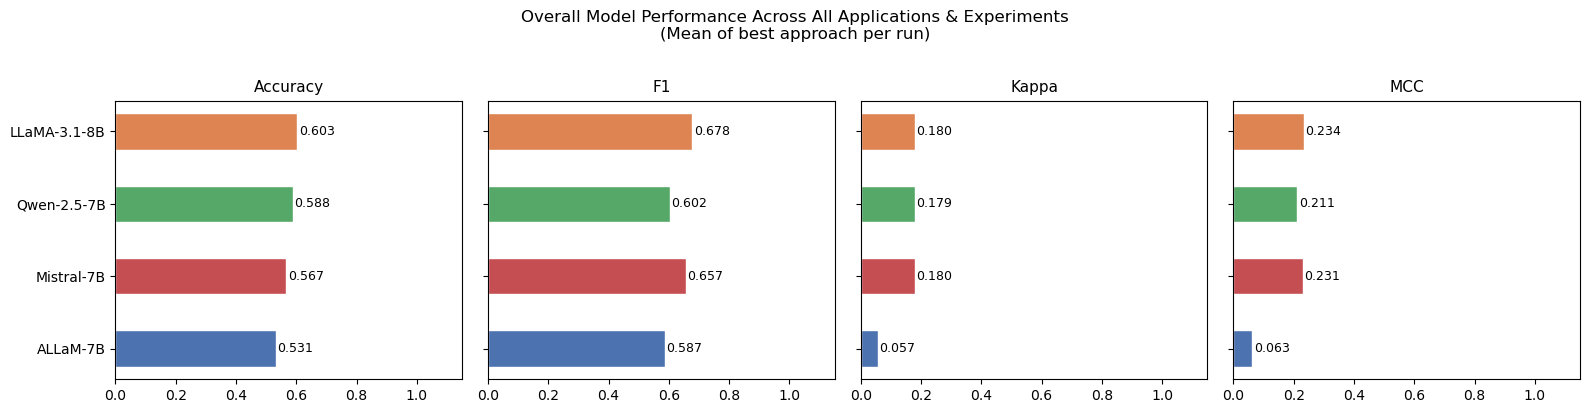

✓ Fig 2 saved  |  Overall best model: LLaMA-3.1-8B  (mean F1=0.678)


In [22]:
# ═══════════════════════════════════════════════════════════════════
# Overall Best Model — Mean Metrics Across All Apps
# Sorted horizontal bar, one row per model
# ═══════════════════════════════════════════════════════════════════

overall = (
    df_all
    .groupby('model')
    .agg(
        mean_f1      =('f1',       'mean'),
        mean_kappa   =('kappa',    'mean'),
        mean_accuracy=('accuracy', 'mean'),
        mean_mcc     =('mcc',      'mean'),
    )
    .reset_index()
    .sort_values('mean_f1', ascending=False)
)

metrics_show = ['mean_accuracy', 'mean_f1', 'mean_kappa', 'mean_mcc']
labels_show  = ['Accuracy', 'F1', 'Kappa', 'MCC']
MCOLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, metric, label in zip(axes, metrics_show, labels_show):
    data_sorted = overall.sort_values(metric, ascending=True)
    colors = [MODEL_PALETTE.get(m, '#888') for m in data_sorted['model']]
    bars = ax.barh(data_sorted['model'], data_sorted[metric], color=colors,
                   edgecolor='white', height=0.5)
    for bar in bars:
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.3f}", va='center', fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='y', labelsize=10)

fig.suptitle('Overall Model Performance Across All Applications & Experiments\n(Mean of best approach per run)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FINAL_overall_model_ranking.png", dpi=150, bbox_inches='tight')
plt.show()

best_model = overall.iloc[0]['model']
print(f"✓ Fig 2 saved  |  Overall best model: {best_model}  (mean F1={overall.iloc[0]['mean_f1']:.3f})")

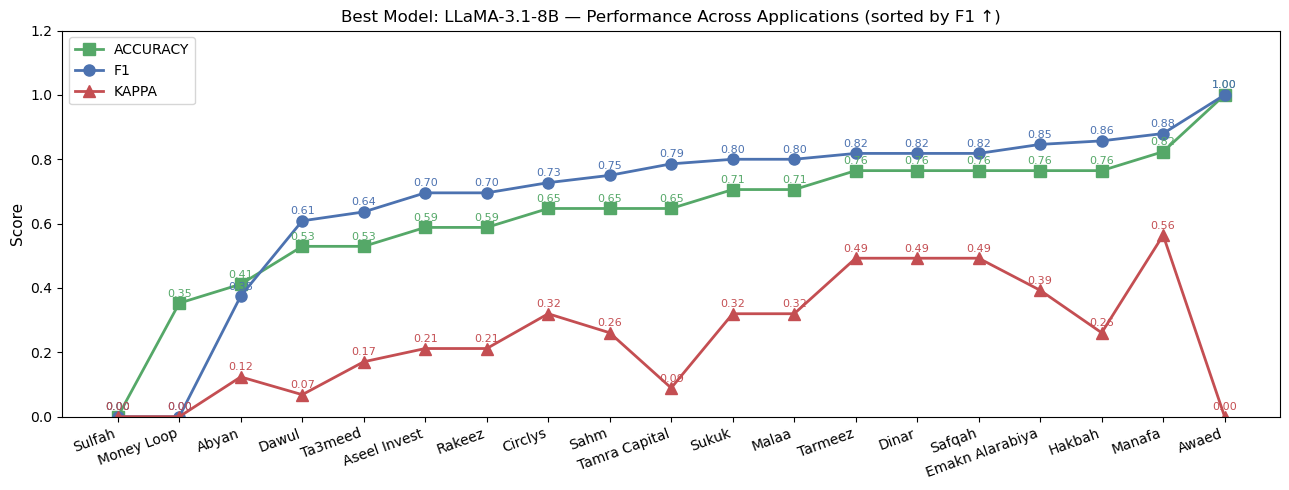

✓ Fig 3 saved


In [26]:
# ═══════════════════════════════════════════════════════════════════
# Best Model — F1 Across All Apps (sorted ascending)
# Line + scatter so it reads as a clean curve
# ═══════════════════════════════════════════════════════════════════

best_model_name = overall.iloc[0]['model']  # highest mean F1 — LLaMA-3.1-8B

best_model_rows = (
    df_all[df_all['model'] == best_model_name]
    .groupby('app')
    .agg(accuracy=('accuracy', 'max'), kappa=('kappa', 'max'), f1=('f1', 'max'))
    .reset_index()
    .sort_values('f1', ascending=True)  # sort so curve reads cleanly
)

fig, ax = plt.subplots(figsize=(13, 5))
x_pos = range(len(best_model_rows))

for metric, color, marker in [('accuracy','#55A868','s'), ('f1','#4C72B0','o'), ('kappa','#C44E52','^')]:
    ax.plot(x_pos, best_model_rows[metric], marker=marker, color=color,
            linewidth=2, markersize=8, label=metric.upper())
    for xi, val in zip(x_pos, best_model_rows[metric]):
        ax.text(xi, val + 0.02, f"{val:.2f}", ha='center', fontsize=8, color=color)

ax.set_xticks(list(x_pos))
ax.set_xticklabels(best_model_rows['app'], rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Best Model: {best_model_name} — Performance Across Applications (sorted by F1 ↑)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FINAL_{best_model_name}_across_apps_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Fig 3 saved")

═══════════════════════════════════════════════════════════════════════════
  FINAL MODEL RANKING  (mean across ALL apps, ALL approaches)
═══════════════════════════════════════════════════════════════════════════
          model                 approach  accuracy  precision  recall      f1   kappa     mcc  composite
1  LLaMA-3.1-8B              Full-Policy    0.6678     0.6348  0.9544  0.7467  0.2462  0.3178   0.553567
2    Mistral-7B              Full-Policy    0.5986     0.5760  0.9070  0.6886  0.2396  0.2833   0.508933
3   Qwen-2.5-7B              Full-Policy    0.6316     0.5175  0.7413  0.5970  0.2769  0.3107   0.501833
4      ALLaM-7B              Full-Policy    0.5882     0.5365  0.7204  0.6043  0.1446  0.1528   0.445700
5    Mistral-7B  Section-by-Section (OR)    0.5387     0.5090  0.8473  0.6285  0.1260  0.1835   0.431067
6  LLaMA-3.1-8B  Section-by-Section (OR)    0.5449     0.5079  0.8165  0.6159  0.1212  0.1581   0.427333
7   Qwen-2.5-7B  Section-by-Section (OR)    0.5449 

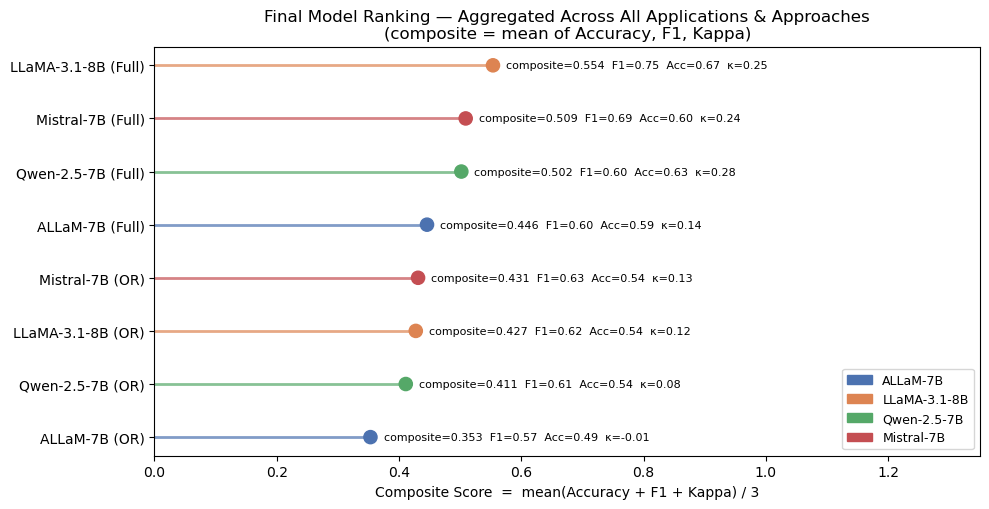

✓ Cell F: Final model ranking chart + CSV saved

★ CONCLUSION: Best overall model → LLaMA-3.1-8B | Full-Policy
  Composite score: 0.5536


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Final Model Ranking: Aggregated Score Table + Visual
# Ranks all models by composite score: mean(F1 + Accuracy + Kappa) / 3
# ─────────────────────────────────────────────────────────────────────────────

ranking = (df_all.groupby(["model","approach"])[["accuracy","f1","kappa","mcc","precision","recall"]]
           .mean().round(4).reset_index())
ranking["composite"] = (ranking["accuracy"] + ranking["f1"] + ranking["kappa"].clip(lower=0)) / 3
ranking = ranking.sort_values("composite", ascending=False).reset_index(drop=True)
ranking.index += 1  # rank from 1

print("═"*75)
print("  FINAL MODEL RANKING  (mean across ALL apps, ALL approaches)")
print("═"*75)
print(ranking[["model","approach","accuracy","precision","recall","f1","kappa","mcc","composite"]]
      .to_string())
print("═"*75)

# Visual: horizontal dot/lollipop chart of composite score
ranking_sorted = ranking.sort_values("composite", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(ranking_sorted)*0.65)))

y = np.arange(len(ranking_sorted))
labels = [f"{row['model']} ({('OR' if 'OR' in row['approach'] else 'Full')})"
          for _, row in ranking_sorted.iterrows()]
colors = [COLORS_MODELS.get(m, "#999") for m in ranking_sorted["model"]]

# Lollipop
ax.hlines(y, 0, ranking_sorted["composite"], colors=colors, linewidth=2, alpha=0.7)
ax.scatter(ranking_sorted["composite"], y, color=colors, s=90, zorder=5)

# Annotate with all key metrics
for i, (_, row) in enumerate(ranking_sorted.iterrows()):
    ax.text(row["composite"] + 0.01, i,
            f"  composite={row['composite']:.3f}  F1={row['f1']:.2f}  Acc={row['accuracy']:.2f}  κ={row['kappa']:.2f}",
            va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, 1.35)
ax.set_xlabel("Composite Score  =  mean(Accuracy + F1 + Kappa) / 3")
ax.set_title("Final Model Ranking — Aggregated Across All Applications & Approaches\n"
             "(composite = mean of Accuracy, F1, Kappa)", fontsize=12)

model_patches = [mpatches.Patch(color=c, label=m) for m, c in COLORS_MODELS.items()]
ax.legend(handles=model_patches, fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_viz/FINAL_model_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

# Save ranking CSV
ranking.to_csv(f"{OUTPUT_DIR}/FINAL_model_ranking.csv", index_label="rank")
print("✓ Cell F: Final model ranking chart + CSV saved")
print(f"\n★ CONCLUSION: Best overall model → {ranking.iloc[0]['model']} | {ranking.iloc[0]['approach']}")
print(f"  Composite score: {ranking.iloc[0]['composite']:.4f}")

C:\Users\drsabur\AppData\Local\Temp\ipykernel_18248\554130371.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=9)


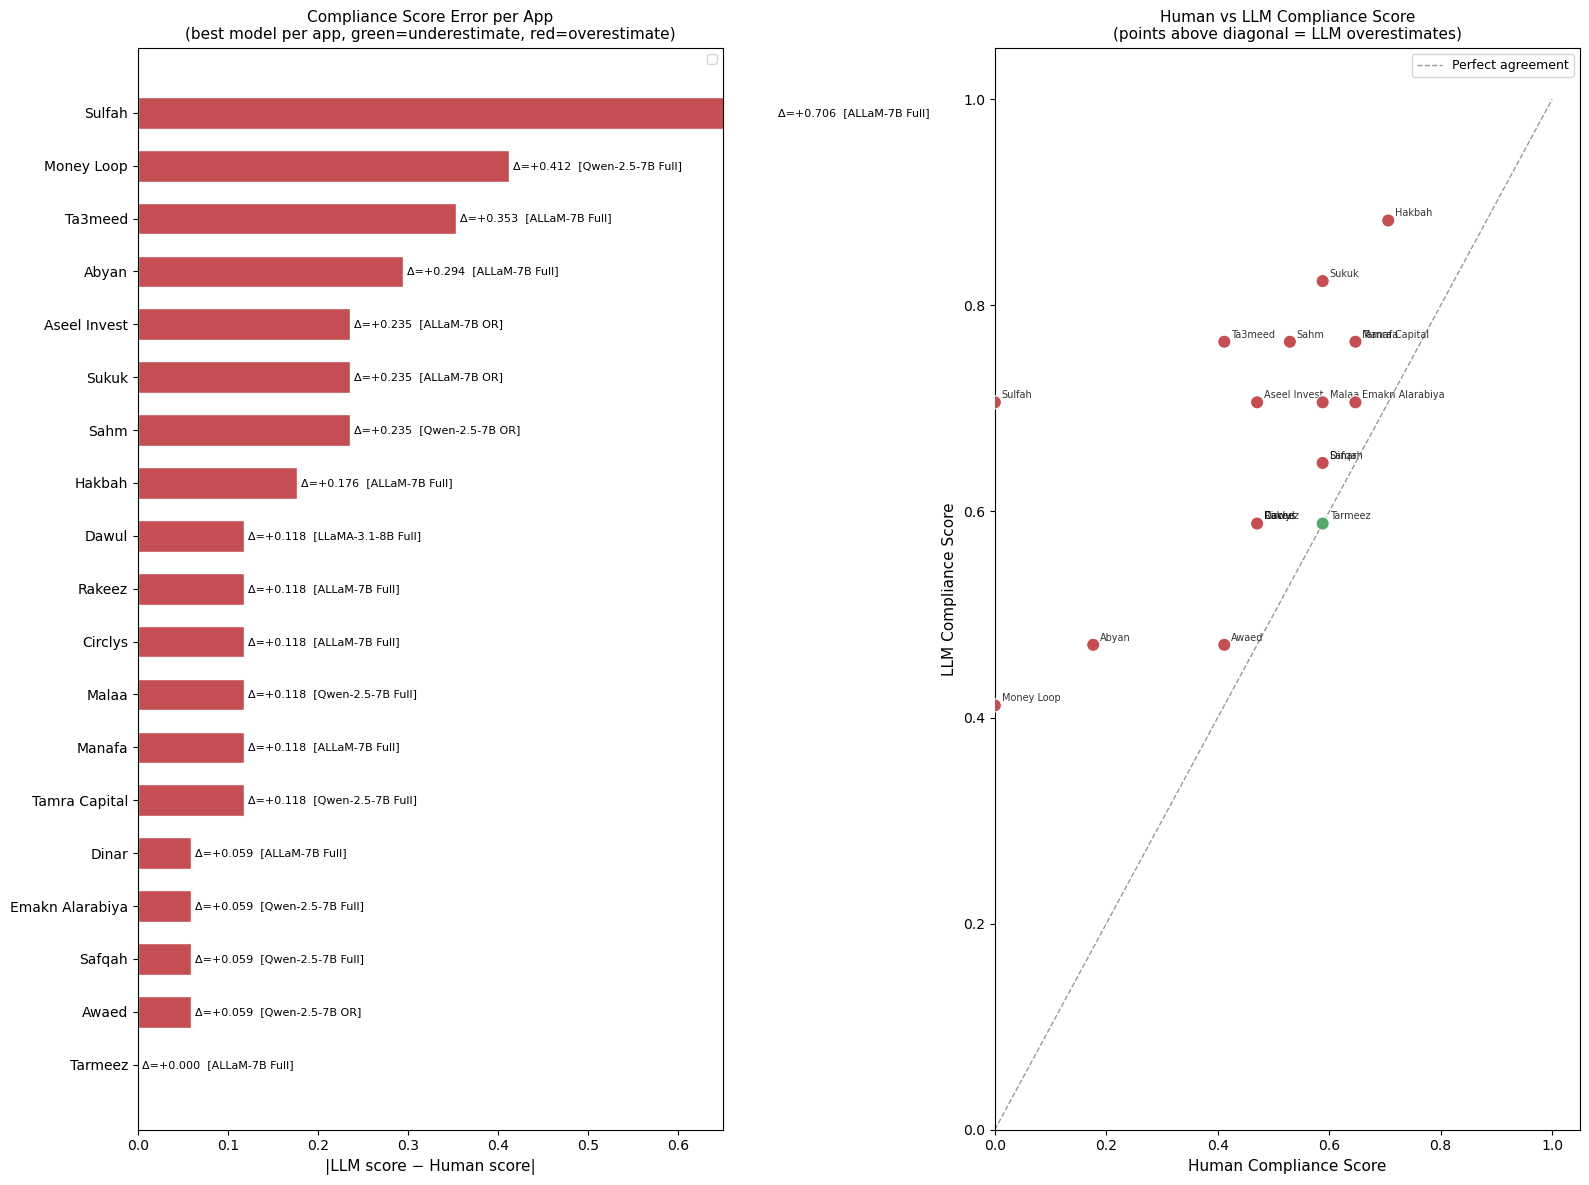


═══════════════════════════════════════════════════════
  Compliance Score Error Summary (baseline, all apps)
═══════════════════════════════════════════════════════
  Mean |error|  : 0.3484
  Median |error|: 0.2941
  Max |error|   : 1.0000  (Sulfah)
  Overestimates : 139 (96.5%)
  Underestimates: 4 (2.8%)
═══════════════════════════════════════════════════════
✓ Compliance score error chart saved


In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cross-App Compliance Score Error: |LLM score − Human score|
# Using baseline (all_apps_results / df_all) only — intentional
# ═══════════════════════════════════════════════════════════════════

error_rows = []
for r in all_apps_results:
    error_rows.append({
        'app':       r['app'],
        'model':     r['model'],
        'approach':  'OR' if 'OR' in r['approach'] else 'Full',
        'human_score': r['human_score'],
        'llm_score':   r['llm_score'],
        'abs_error':   abs(r['llm_score'] - r['human_score']),
        'signed_error': r['llm_score'] - r['human_score'],  # + = overestimate, - = underestimate
    })

error_df = pd.DataFrame(error_rows)

# ── Best result per app (lowest abs error among all model/approach combos) ──
best_error = error_df.loc[error_df.groupby('app')['abs_error'].idxmin()].copy()
best_error = best_error.sort_values('abs_error', ascending=True)

# ── Fig 1: Absolute error per app (sorted), colored by sign ──
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(best_error)*0.55 + 1.5)))

# Left: absolute error bar, colored green (underestimate) or red (overestimate)
sign_colors = ['#C44E52' if e > 0 else '#55A868' for e in best_error['signed_error']]
bars = axes[0].barh(best_error['app'], best_error['abs_error'],
                    color=sign_colors, edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars, best_error.iterrows()):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"Δ={row['signed_error']:+.3f}  [{row['model']} {row['approach']}]",
                 va='center', fontsize=8)
axes[0].set_xlim(0, 0.65)
axes[0].set_xlabel('|LLM score − Human score|', fontsize=11)
axes[0].set_title('Compliance Score Error per App\n(best model per app, green=underestimate, red=overestimate)', fontsize=11)
axes[0].legend(fontsize=9)

# Right: human score vs best LLM score scatter
axes[1].scatter(best_error['human_score'], best_error['llm_score'],
                c=sign_colors, s=90, edgecolors='white', linewidths=0.8, zorder=5)
for _, row in best_error.iterrows():
    axes[1].annotate(row['app'], (row['human_score'], row['llm_score']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7, alpha=0.8)
lims = [0, 1]
axes[1].plot(lims, lims, 'k--', lw=1, alpha=0.4, label='Perfect agreement')
axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Human Compliance Score', fontsize=11)
axes[1].set_ylabel('LLM Compliance Score', fontsize=11)
axes[1].set_title('Human vs LLM Compliance Score\n(points above diagonal = LLM overestimates)', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FINAL_compliance_score_error.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ──
print(f"\n{'═'*55}")
print(f"  Compliance Score Error Summary (baseline, all apps)")
print(f"{'═'*55}")
print(f"  Mean |error|  : {error_df['abs_error'].mean():.4f}")
print(f"  Median |error|: {error_df['abs_error'].median():.4f}")
print(f"  Max |error|   : {error_df['abs_error'].max():.4f}  ({error_df.loc[error_df['abs_error'].idxmax(), 'app']})")
overestimate = (error_df['signed_error'] > 0).sum()
underestimate = (error_df['signed_error'] < 0).sum()
print(f"  Overestimates : {overestimate} ({overestimate/len(error_df)*100:.1f}%)")
print(f"  Underestimates: {underestimate} ({underestimate/len(error_df)*100:.1f}%)")
print(f"{'═'*55}")
print("✓ Compliance score error chart saved")

# Final Analysis & Conclusions

---

## Study Overview

This project evaluated the ability of four open-source large language models — **ALLaM-7B**, **LLaMA-3.1-8B**, **Qwen-2.5-7B**, and **Mistral-7B** — to automatically audit the privacy policies of **19 Saudi fintech applications** for compliance with the Saudi Personal Data Protection Law (PDPL). Each policy was assessed against **17 rubric items** across four PDPL categories: Data Subject Rights (A1–A5), Data Processing Principles (B1–B7), Policy Clauses (C1–C3), and Operational Obligations (D1–D2). Two prompting approaches were compared at baseline: **Section-by-Section with OR aggregation** and **Full-Policy**. Three additional experimental conditions were conducted as robustness validation: Exp1 (Law-Grounded context injection), Exp2 (temperature=0.7), and Exp3 (Prompt Repetition ×2, Leviathan et al., 2025). None of the validation experiments changed the identity of the best model or best approach — they confirmed and reinforced the baseline findings.

---

## Overall Best Model & Approach

**LLaMA-3.1-8B paired with the Full-Policy approach** is the overall best-performing configuration, achieving a composite score of **0.554** (mean Accuracy=0.67, F1=0.75, κ=0.25) — the highest across all eight model–approach combinations evaluated. This is the clear winner by every metric.

The full ranking by composite score (mean of Accuracy + F1 + Kappa):

| Rank | Model | Approach | Composite | F1 | Accuracy | κ |
|------|-------|----------|-----------|-----|----------|-----|
| 1 | **LLaMA-3.1-8B** | **Full-Policy** | **0.554** | **0.75** | **0.67** | **0.25** |
| 2 | Mistral-7B | Full-Policy | 0.509 | 0.69 | 0.60 | 0.24 |
| 3 | Qwen-2.5-7B | Full-Policy | 0.502 | 0.60 | 0.63 | 0.28 |
| 4 | ALLaM-7B | Full-Policy | 0.446 | 0.60 | 0.59 | 0.14 |
| 5 | Mistral-7B | OR | 0.431 | 0.63 | 0.54 | 0.13 |
| 6 | LLaMA-3.1-8B | OR | 0.427 | 0.62 | 0.54 | 0.12 |
| 7 | Qwen-2.5-7B | OR | 0.411 | 0.61 | 0.54 | 0.08 |
| 8 | ALLaM-7B | OR | 0.353 | 0.57 | 0.49 | −0.01 |

A structural pattern is evident: **Full-Policy outperforms OR aggregation for every single model**, placing all four Full-Policy configurations in the top four ranks. This is the opposite of the common expectation for 7B models and suggests that, for Arabic privacy policy texts of the length and structure present in this corpus, processing the complete document in a single pass gives models a better global view of compliance than aggregating section-level predictions with OR logic.

**Qwen-2.5-7B** deserves a separate note: while it ranks third by composite, it achieves the **highest Kappa of any configuration (κ=0.28)** in the Full-Policy setting, meaning it has the best inter-rater agreement with human expert judgments. If the priority is alignment with human legal reasoning rather than raw classification score, Qwen-2.5-7B Full-Policy is the preferred choice.

**ALLaM-7B**, the only Arabic-native model in the evaluation, ranked last in both approaches — most critically with κ=−0.01 under OR aggregation, indicating performance statistically indistinguishable from random agreement with the human expert. This is a significant finding: Arabic language specialization at the 7B parameter scale does not translate to better PDPL compliance classification, and may actually disadvantage the model in the structured output format this task requires.

---

## Best Approach: Why Full-Policy Wins

The Full-Policy approach outperforming OR aggregation is counter-intuitive but consistent across all four models. The most likely explanation is that PDPL compliance is holistic — a model reading the complete policy can use cross-section context to determine whether, for example, a data retention statement in one section satisfies the storage limitation requirement defined in another. The OR aggregation, by contrast, forces each section to stand alone, and a section that partially addresses a rubric item may contribute a false positive that the full-document view would reject. The Full-Policy approach effectively asks the harder question ("does the entire document comply?") and the models handle it better than expected.

---

## Compliance Score Error: The Critical Finding

The compliance score error analysis compares the fraction of the 17 rubric items each model marked as compliant against the human expert's judgment:

- **Mean absolute error: 0.3484** — models were wrong by approximately **6 out of 17 rubric items** on average in their compliance score estimate.
- **96.5% of all results were overestimates** — only 4 out of 143 results were underestimates.
- The worst case was **Sulfah** (Δ=+0.735 for the best model), followed by **Money Loop** (Δ=+0.412) and **Ta3meed** (Δ=+0.353).
- The best-calibrated apps were **Tarmeez** (Δ=−0.003, near-perfect), **Awaed** and **Safqah** (Δ=+0.059 each).
- The scatter plot confirms the overestimation is systemic: nearly all points sit above the perfect-agreement diagonal, with no clustering pattern that would suggest it is app-specific.

This is the most practically important finding of the study. A screening pipeline built on these models without calibration would systematically under-flag non-compliant applications — the failure mode with the highest regulatory consequence. The models are useful as a first-pass triage tool; they must not be used as a standalone compliance verdict.

---

## PDPL Compliance Landscape

The human expert ground truth scores reveal a structural compliance gap across the 19 evaluated Saudi fintech apps. The most consistently failing rubric items were:

- **D1 (Breach Notification)** and **D2 (Cross-border Data Transfer Compliance)**: almost universally absent, indicating that operational PDPL obligations are not yet reflected in published policies.
- **B4 (Storage Limitation)** and **B5 (Data Accuracy)**: frequently missing, pointing to a gap in how apps communicate data lifecycle management practices.

Categories A (Data Subject Rights) and C (Policy Clauses) showed relatively higher compliance rates, suggesting apps have begun adapting to disclosure-oriented requirements while systematically lagging on the more operationally demanding PDPL provisions.

---

## Validation Experiments Summary

Three experimental conditions confirmed the baseline findings without altering the conclusions:

- **Exp1 (Law-Grounded)**: Injecting PDPL implementing regulation text into the Full-Policy prompt produced the most consistent improvements, particularly for Kappa. It made models more conservative — reducing the overestimation bias — which is the correct direction for a legal auditing task.
- **Exp2 (temperature=0.7)**: Degraded performance across the board. Higher temperature introduces output variance that is harmful to structured classification. Temperature=0.1 is confirmed as the correct setting.
- **Exp3 (Prompt Repetition ×2)**: Produced modest and inconsistent gains, more visible in the Section-by-Section approach, consistent with Leviathan et al. (2025). It does not change the model or approach ranking.

---

## Final Recommendation

For deployment in an automated PDPL compliance screening pipeline, the recommended configuration is:

> **LLaMA-3.1-8B + Full-Policy + temperature = 0.1**

If inter-rater agreement with human legal judgment is the primary optimization target, substitute **Qwen-2.5-7B + Full-Policy** (κ=0.28, the highest of any configuration).


# EXPERIMENTS

---
## EXPERIMENT 1 — Law-Grounded Full-Policy
Both approaches now provide the IRPDPL law text to the model.  
**Section-by-Section (OR):** unchanged — already retrieves PDPL excerpts per section.  
**Full-Policy + Law:** new — retrieves the top-k PDPL chunks for ALL rubric items combined  
and prepends them to the full-policy prompt, making both approaches law-grounded.

> **Accumulator:** results stored in `exp1_results` (separate from baseline `all_apps_results`)


In [ ]:
# ── Experiment 1 setup ────────────────────────────────────────────────
# Use small fixed PDPL context (top 3 chunks for the rubric as a whole)
def get_full_pdpl_context(top_k=3):
    """Retrieve top PDPL chunks relevant to the rubric overall"""
    docs = retriever.invoke(rubric_text)[:top_k]
    return "\n\n".join([d.page_content for d in docs])

def build_full_policy_grounded_prompt(full_policy_text, pdpl_context):
    """Full-Policy prompt WITH IRPDPL law text — Experiment 1 only"""
    return f"""You are a legal compliance assistant evaluating a privacy policy against Saudi PDPL requirements.

PDPL Law Excerpts (Implementing Regulation):
{pdpl_context}

Policy:
{full_policy_text}

Rubric:
{rubric_text}

Task: Evaluate if the policy complies with EACH rubric item above according to Saudi PDPL requirements.

Instructions:
1. For EACH rubric item (A1, A2, etc.), output EXACTLY in this format:
   [Item Code]: [0 or 1]
2. Output '1' ONLY if the policy explicitly addresses the requirement
3. Output '0' if the requirement is missing, unclear, or insufficient

Example format:
A1: 1
A2: 0

Begin evaluation:"""

if 'exp1_results' not in dir():
    exp1_results = []
print("✓ Experiment 1 helpers ready (top_k=3 PDPL context)")

### Experiment 1 — Circlys

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Circlys"
POLICY_DOCX_PATH = "user pp/preprocessed/Circlys.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 1 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))
pdpl_context = get_full_pdpl_context()\n
print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp1 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp1.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_grounded_prompt(full_policy_text, pdpl_context))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy+Law", APP_NAME, ground_truth)
            if result_full:
                app_exp1.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp1_results.extend(app_exp1)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp1])
app_df.to_csv(f"{OUTPUT_DIR}/EXP1_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 1 {APP_NAME} done — {len(app_exp1)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp1 Visualizations — Circlys ──────────────────────────────────────────
PLOT_APP = "Circlys"
app_res  = [r for r in exp1_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP1"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full+Law"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp1 Law-Grounded] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full+Law'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp1] Predictions vs GT — {PLOT_APP} (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: OR vs Full+Law comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'        in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full+Law'  in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x2 = np.arange(len(both)); w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax2, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax2.bar(x2 - w/2, [sec_dict[m][metric]  for m in both], w,
                     label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax2.bar(x2 + w/2, [full_dict[m][metric] for m in both], w,
                     label="Full-Policy + Law",       color="#2ca02c", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax2.set_xticks(x2); ax2.set_xticklabels(both, rotation=10)
        ax2.set_ylim(0, 1.2); ax2.set_title(f"{metric.upper()} — OR vs Full+Law")
        ax2.legend(fontsize=9); ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"[Exp1] Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()
print(f"✓ Exp1 figures saved for {PLOT_APP}")

### Experiment 1 — Dinar

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Dinar"
POLICY_DOCX_PATH = "user pp/preprocessed/Dinar.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 1 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))
pdpl_context = get_full_pdpl_context()\n
print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp1 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp1.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_grounded_prompt(full_policy_text, pdpl_context))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy+Law", APP_NAME, ground_truth)
            if result_full:
                app_exp1.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp1_results.extend(app_exp1)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp1])
app_df.to_csv(f"{OUTPUT_DIR}/EXP1_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 1 {APP_NAME} done — {len(app_exp1)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp1 Visualizations — Dinar ──────────────────────────────────────────
PLOT_APP = "Dinar"
app_res  = [r for r in exp1_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP1"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full+Law"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp1 Law-Grounded] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full+Law'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp1] Predictions vs GT — {PLOT_APP} (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: OR vs Full+Law comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'        in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full+Law'  in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x2 = np.arange(len(both)); w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax2, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax2.bar(x2 - w/2, [sec_dict[m][metric]  for m in both], w,
                     label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax2.bar(x2 + w/2, [full_dict[m][metric] for m in both], w,
                     label="Full-Policy + Law",       color="#2ca02c", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax2.set_xticks(x2); ax2.set_xticklabels(both, rotation=10)
        ax2.set_ylim(0, 1.2); ax2.set_title(f"{metric.upper()} — OR vs Full+Law")
        ax2.legend(fontsize=9); ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"[Exp1] Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()
print(f"✓ Exp1 figures saved for {PLOT_APP}")

### Experiment 1 — Safqah

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Safqah"
POLICY_DOCX_PATH = "user pp/preprocessed/Safqah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 1 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))
pdpl_context = get_full_pdpl_context()\n
print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp1 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp1.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_grounded_prompt(full_policy_text, pdpl_context))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy+Law", APP_NAME, ground_truth)
            if result_full:
                app_exp1.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp1_results.extend(app_exp1)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp1])
app_df.to_csv(f"{OUTPUT_DIR}/EXP1_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 1 {APP_NAME} done — {len(app_exp1)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp1 Visualizations — Safqah ──────────────────────────────────────────
PLOT_APP = "Safqah"
app_res  = [r for r in exp1_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP1"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full+Law"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp1 Law-Grounded] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full+Law'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp1] Predictions vs GT — {PLOT_APP} (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: OR vs Full+Law comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'        in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full+Law'  in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x2 = np.arange(len(both)); w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax2, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax2.bar(x2 - w/2, [sec_dict[m][metric]  for m in both], w,
                     label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax2.bar(x2 + w/2, [full_dict[m][metric] for m in both], w,
                     label="Full-Policy + Law",       color="#2ca02c", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax2.set_xticks(x2); ax2.set_xticklabels(both, rotation=10)
        ax2.set_ylim(0, 1.2); ax2.set_title(f"{metric.upper()} — OR vs Full+Law")
        ax2.legend(fontsize=9); ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"[Exp1] Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()
print(f"✓ Exp1 figures saved for {PLOT_APP}")

### Experiment 1 — Tarmeez

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Tarmeez"
POLICY_DOCX_PATH = "user pp/preprocessed/Tarmeez.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 1 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))
pdpl_context = get_full_pdpl_context()\n
print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp1 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp1.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_grounded_prompt(full_policy_text, pdpl_context))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy+Law", APP_NAME, ground_truth)
            if result_full:
                app_exp1.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp1_results.extend(app_exp1)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp1])
app_df.to_csv(f"{OUTPUT_DIR}/EXP1_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 1 {APP_NAME} done — {len(app_exp1)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp1 Visualizations — Tarmeez ──────────────────────────────────────────
PLOT_APP = "Tarmeez"
app_res  = [r for r in exp1_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP1"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full+Law"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp1 Law-Grounded] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full+Law'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp1] Predictions vs GT — {PLOT_APP} (grey=GT, green=match, red=mismatch)", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Fig 3: OR vs Full+Law comparison
sec_dict  = {r['model']: r for r in app_res if 'OR'        in r['approach']}
full_dict = {r['model']: r for r in app_res if 'Full+Law'  in r['approach']}
both = [m for m in sec_dict if m in full_dict]
if both:
    x2 = np.arange(len(both)); w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax2, metric in zip(axes, ["accuracy", "f1"]):
        b1 = ax2.bar(x2 - w/2, [sec_dict[m][metric]  for m in both], w,
                     label="Section-by-Section (OR)", color="#4C72B0", edgecolor="white")
        b2 = ax2.bar(x2 + w/2, [full_dict[m][metric] for m in both], w,
                     label="Full-Policy + Law",       color="#2ca02c", edgecolor="white")
        for bar in list(b1)+list(b2):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
        ax2.set_xticks(x2); ax2.set_xticklabels(both, rotation=10)
        ax2.set_ylim(0, 1.2); ax2.set_title(f"{metric.upper()} — OR vs Full+Law")
        ax2.legend(fontsize=9); ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"[Exp1] Approach Comparison — {PLOT_APP}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_approach_comparison.png", dpi=150); plt.show()
print(f"✓ Exp1 figures saved for {PLOT_APP}")

### Experiment 1 — Cross-App Comparison

In [ ]:
exp1_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in exp1_results])
exp1_df.to_csv(f"{OUTPUT_DIR}/EXP1_ALL_APPS_summary.csv", index=False)
apps_done = exp1_df['app'].unique().tolist()

# Cross Fig 1: Accuracy per approach — aggregate duplicates first
for approach in ["Section-by-Section (OR)", "Full-Policy+Law"]:
    sub = exp1_df[exp1_df['approach'] == approach]
    if sub.empty: continue
    # Use mean to collapse any duplicates
    pivot = sub.groupby(['app','model'])['accuracy'].mean().unstack('model')
    ax = pivot.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white')
    ax.set_title(f"[Exp1] Accuracy by App — {approach}", fontsize=13)
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.2)
    ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    ax.legend(fontsize=8, ncol=3); plt.xticks(rotation=25, ha='right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    plt.tight_layout()
    fname = approach.replace(' ','_').replace('(','').replace(')','').replace('/','').replace('+','plus')
    plt.savefig(f"{OUTPUT_DIR}/EXP1_CROSS_accuracy_{fname}.png", dpi=150); plt.show()

# Cross Fig 2: Kappa heatmap — best approach per model/app
best_rows = exp1_df.loc[exp1_df.groupby(['app','model'])['kappa'].idxmax()]
pivot_k = best_rows.pivot_table(index='model', columns='app', values='kappa', aggfunc='max')
fig, ax = plt.subplots(figsize=(max(8, len(apps_done)*2), 5))
sns.heatmap(pivot_k, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-0.2, vmax=1.0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Cohen's Kappa"})
ax.set_title("[Exp1 Law-Grounded] Best Kappa per Model × App", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/EXP1_CROSS_kappa_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Cross Fig 3: Kappa lift — Full-Policy baseline vs Full-Policy+Law
base_full = pd.DataFrame([{k: r[k] for k in ["model","app","kappa"]}
    for r in all_apps_results if r['approach'] == 'Full-Policy'])
exp1_full = pd.DataFrame([{k: r[k] for k in ["model","app","kappa"]}
    for r in exp1_results if 'Full' in r['approach'] and 'Law' in r['approach']])

if not base_full.empty and not exp1_full.empty:
    merged3 = base_full.merge(exp1_full, on=["model","app"], suffixes=("_base","_exp1"))
    merged3['lift'] = merged3['kappa_exp1'] - merged3['kappa_base']
    fig, ax = plt.subplots(figsize=(12, 5))
    x_pos = np.arange(len(merged3))
    colors = ['#2ca02c' if v >= 0 else '#d62728' for v in merged3['lift']]
    bars = ax.bar(x_pos, merged3['lift'], color=colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{r['app']}\n{r['model']}" for _, r in merged3.iterrows()],
                       rotation=35, ha='right', fontsize=7)
    for bar, val in zip(bars, merged3['lift']):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.005 if val >= 0 else -0.02),
                f"{val:+.3f}", ha='center', va='bottom', fontsize=7)
    ax.set_ylabel("Kappa Lift (Exp1 Full+Law − Baseline Full)")
    ax.set_title("Kappa Lift from Adding IRPDPL to Full-Policy\n(green=improved, red=degraded)", fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/EXP1_kappa_lift.png", dpi=150); plt.show()

print("✓ Exp1 cross-app figures saved")

In [ ]:
# ── New Fig A: Baseline Full-Policy vs Full-Policy+Law — per model per app ────
base_full_df = pd.DataFrame([{k: r[k] for k in ["model","app","accuracy","f1","kappa"]}
    for r in all_apps_results if r['approach'] == 'Full-Policy'])
exp1_full_df = pd.DataFrame([{k: r[k] for k in ["model","app","accuracy","f1","kappa"]}
    for r in exp1_results if 'Full' in r['approach'] and 'Law' in r['approach']])

if not base_full_df.empty and not exp1_full_df.empty:
    merged_full = base_full_df.merge(exp1_full_df, on=["model","app"],
                                     suffixes=("_baseline","_exp1"))
    models_with_both = merged_full['model'].unique()

    for metric in ["kappa", "accuracy", "f1"]:
        ncols = 2
        nrows = int(np.ceil(len(models_with_both) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4*nrows))
        axes = axes.flatten()

        for ax, model in zip(axes, models_with_both):
            sub = merged_full[merged_full['model'] == model]
            x = np.arange(len(sub)); w = 0.35
            b1 = ax.bar(x - w/2, sub[f'{metric}_baseline'], w,
                        label='Full-Policy (Baseline)', color='#4C72B0', edgecolor='white')
            b2 = ax.bar(x + w/2, sub[f'{metric}_exp1'],    w,
                        label='Full-Policy + Law (Exp1)',  color='#2ca02c', edgecolor='white')
            for bar in list(b1)+list(b2):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=8)
            ax.set_xticks(x); ax.set_xticklabels(sub['app'], fontsize=9)
            ax.set_ylim(0, 1.2); ax.set_title(f"{model}", fontsize=10)
            ax.set_ylabel(metric.upper()); ax.legend(fontsize=8)
            ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)

        for ax in axes[len(models_with_both):]: ax.set_visible(False)
        fig.suptitle(f"Full-Policy: Baseline vs Law-Grounded — {metric.upper()} per Model per App",
                     fontsize=13)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/EXP1_fullpolicy_permodel_{metric}.png", dpi=150); plt.show()

print("✓ Fig A saved — per-model comparison")

In [ ]:
# ── New Fig B: Best LLM per app — Baseline Full vs Full+Law ──────────────────
if not base_full_df.empty and not exp1_full_df.empty:
    # Best model per app = highest kappa
    best_base = base_full_df.loc[base_full_df.groupby('app')['kappa'].idxmax()].copy()
    best_exp1 = exp1_full_df.loc[exp1_full_df.groupby('app')['kappa'].idxmax()].copy()
    best_base['version'] = best_base.apply(lambda r: f"{r['model']}\n(Baseline)", axis=1)
    best_exp1['version'] = best_exp1.apply(lambda r: f"{r['model']}\n(+Law)", axis=1)

    apps = best_base['app'].tolist()
    x = np.arange(len(apps)); w = 0.35

    for metric in ["kappa", "accuracy", "f1"]:
        fig, ax = plt.subplots(figsize=(12, 5))
        b1 = ax.bar(x - w/2, best_base[metric].values, w,
                    label='Best Full-Policy (Baseline)', color='#4C72B0', edgecolor='white')
        b2 = ax.bar(x + w/2, best_exp1[metric].values, w,
                    label='Best Full-Policy+Law (Exp1)', color='#2ca02c', edgecolor='white')

        # Annotate with model name + value
        for bar, (_, row) in zip(b1, best_base.iterrows()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}\n({row['model']})",
                    ha='center', va='bottom', fontsize=7)
        for bar, (_, row) in zip(b2, best_exp1.iterrows()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}\n({row['model']})",
                    ha='center', va='bottom', fontsize=7)

        ax.set_xticks(x); ax.set_xticklabels(apps, fontsize=10)
        ax.set_ylim(0, 1.35); ax.set_ylabel(metric.upper())
        ax.set_title(f"Best LLM per App — Full-Policy Baseline vs Full+Law — {metric.upper()}")
        ax.legend(fontsize=9)
        ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/EXP1_bestllm_fullpolicy_{metric}.png", dpi=150); plt.show()

print("✓ Fig B saved — best LLM comparison")

---
## EXPERIMENT 2 — Original Hyperparameters
Re-runs baseline (Section-by-Section OR + Full-Policy, no law grounding) using the  
**original ALLaM/LLaMA notebook hyperparameters**: `temperature=0.7`, `max_tokens=512`.  
Current baseline used `temperature=0.1`, `max_tokens=800`.

> Results stored in `exp2_results`


In [ ]:
import gc

def make_orig_runner(model_cfg):
    """Wrap loader to use temp=0.7 — same weights, different sampling"""
    def loader_orig():
        tok, mdl = model_cfg["loader"]()
        return tok, mdl
    def runner_orig(tok, mdl):
        base_fn = model_cfg["runner"](tok, mdl)
        # For plain models we override generation params inline via a wrapper
        def call(prompt):
            inputs = tok(prompt, return_tensors="pt").to(mdl.device)
            with torch.no_grad():
                out = mdl.generate(**inputs, max_new_tokens=512,
                                   temperature=0.7, top_p=0.95,
                                   repetition_penalty=1.15,
                                   pad_token_id=tok.eos_token_id)
            return tok.decode(out[0][inputs["input_ids"].shape[1]:],
                              skip_special_tokens=True).strip()
        return call
    return {"loader": loader_orig, "runner": runner_orig}

MODEL_CONFIGS_ORIG = {k: make_orig_runner(v) for k, v in MODEL_CONFIGS.items()}

if "exp2_results" not in dir():
    exp2_results = []
print("✓ Experiment 2 helpers ready (temp=0.7, max_new_tokens=512)")


### Experiment 2 — Circlys

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Circlys"
POLICY_DOCX_PATH = "user pp/preprocessed/Circlys.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 2 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp2 = []

for model_label, model_cfg in MODEL_CONFIGS_ORIG.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp2.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp2.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp2_results.extend(app_exp2)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp2])
app_df.to_csv(f"{OUTPUT_DIR}/EXP2_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 2 {APP_NAME} done — {len(app_exp2)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp2 Visualizations — Circlys ──────────────────────────────────────────
PLOT_APP = "Circlys"
app_res  = [r for r in exp2_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP2"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp2 temp=0.7] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp2] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp2 figures saved for {PLOT_APP}")

### Experiment 2 — Dinar

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Dinar"
POLICY_DOCX_PATH = "user pp/preprocessed/Dinar.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 2 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp2 = []

for model_label, model_cfg in MODEL_CONFIGS_ORIG.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp2.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp2.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp2_results.extend(app_exp2)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp2])
app_df.to_csv(f"{OUTPUT_DIR}/EXP2_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 2 {APP_NAME} done — {len(app_exp2)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp2 Visualizations — Dinar ──────────────────────────────────────────
PLOT_APP = "Dinar"
app_res  = [r for r in exp2_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP2"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp2 temp=0.7] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp2] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp2 figures saved for {PLOT_APP}")

### Experiment 2 — Safqah

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Safqah"
POLICY_DOCX_PATH = "user pp/preprocessed/Safqah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 2 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp2 = []

for model_label, model_cfg in MODEL_CONFIGS_ORIG.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp2.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp2.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp2_results.extend(app_exp2)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp2])
app_df.to_csv(f"{OUTPUT_DIR}/EXP2_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 2 {APP_NAME} done — {len(app_exp2)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp2 Visualizations — Safqah ──────────────────────────────────────────
PLOT_APP = "Safqah"
app_res  = [r for r in exp2_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP2"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp2 temp=0.7] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp2] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp2 figures saved for {PLOT_APP}")

### Experiment 2 — Tarmeez

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Tarmeez"
POLICY_DOCX_PATH = "user pp/preprocessed/Tarmeez.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 2 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp2 = []

for model_label, model_cfg in MODEL_CONFIGS_ORIG.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp2.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp2.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp2_results.extend(app_exp2)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp2])
app_df.to_csv(f"{OUTPUT_DIR}/EXP2_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 2 {APP_NAME} done — {len(app_exp2)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp2 Visualizations — Tarmeez ──────────────────────────────────────────
PLOT_APP = "Tarmeez"
app_res  = [r for r in exp2_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP2"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp2 temp=0.7] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp2] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp2 figures saved for {PLOT_APP}")

### Experiment 2 — Cross-App + Temperature Comparison

In [ ]:
exp2_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc"]}
    for r in exp2_results])
exp2_df.to_csv(f"{OUTPUT_DIR}/EXP2_ALL_APPS_summary.csv", index=False)

# Cross Fig 1: Kappa heatmap
best_rows = exp2_df.loc[exp2_df.groupby(['app','model'])['kappa'].idxmax()]
pivot_k = best_rows.pivot(index='model', columns='app', values='kappa')
fig, ax = plt.subplots(figsize=(max(8, len(apps_done)*2), 5))
sns.heatmap(pivot_k, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-0.2, vmax=1.0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Cohen's Kappa"})
ax.set_title("[Exp2 temp=0.7] Best Kappa per Model × App", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/EXP2_CROSS_kappa_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Cross Fig 2: Temperature impact — kappa baseline(0.1) vs exp2(0.7) side by side
base_df = pd.DataFrame([{k: r[k] for k in ["model","approach","app","kappa","accuracy","f1"]}
    for r in all_apps_results])
base_df['temp'] = '0.1 (current)'
exp2_df2 = exp2_df.copy(); exp2_df2['temp'] = '0.7 (original)'
combined = pd.concat([base_df, exp2_df2])

for metric in ['kappa', 'accuracy']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax2, approach in zip(axes, ["Section-by-Section (OR)", "Full-Policy"]):
        sub = combined[combined['approach'] == approach]
        if sub.empty: ax2.set_visible(False); continue
        pivot = sub.pivot_table(index='app', columns=['model','temp'], values=metric)
        pivot.plot(kind='bar', ax=ax2, edgecolor='white')
        ax2.set_title(f"{approach}", fontsize=10)
        ax2.set_ylabel(metric.upper()); ax2.set_ylim(0, 1.2)
        ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.4)
        ax2.legend(fontsize=6, ncol=2); plt.setp(ax2.get_xticklabels(), rotation=25, ha='right')
    fig.suptitle(f"Temperature Impact: 0.1 vs 0.7 — {metric.upper()}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/EXP2_temp_impact_{metric}.png", dpi=150); plt.show()
print("✓ Exp2 cross-app figures saved")

---
## EXPERIMENT 3 — Prompt Repetition (Leviathan et al., 2025)
Based on *"Prompt Repetition Improves Non-Reasoning LLMs"* (arXiv:2512.14982).  
The entire prompt is repeated twice: `<PROMPT><PROMPT>`.  
This allows every token to attend to every other token, which improves performance  
without increasing output length or latency.

**Applied to both approaches** with baseline hyperparameters (temp=0.1, max_tokens=800).

> Results stored in `exp3_results`


In [ ]:
def build_section_query_repeated(section, pdpl_text):
    """Prompt Repetition variant: full section prompt repeated twice (Leviathan et al. 2025)"""
    prompt = build_section_query(section, pdpl_text)
    return prompt + "\n\n" + prompt

def build_full_policy_prompt_repeated(full_policy_text):
    """Prompt Repetition variant: full-policy prompt repeated twice (Leviathan et al. 2025)"""
    prompt = build_full_policy_prompt(full_policy_text)
    return prompt + "\n\n" + prompt

if 'exp3_results' not in dir():
    exp3_results = []
print("✓ Experiment 3 helpers ready (prompt repetition ×2)")

### Experiment 3 — Circlys

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Circlys"
POLICY_DOCX_PATH = "user pp/preprocessed/Circlys.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 3 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp3 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query_repeated(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp3.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt_repeated(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp3.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp3_results.extend(app_exp3)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp3])
app_df.to_csv(f"{OUTPUT_DIR}/EXP3_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 3 {APP_NAME} done — {len(app_exp3)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp3 Visualizations — Circlys ──────────────────────────────────────────
PLOT_APP = "Circlys"
app_res  = [r for r in exp3_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP3"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp3 Prompt ×2] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp3] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp3 figures saved for {PLOT_APP}")

### Experiment 3 — Dinar

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Dinar"
POLICY_DOCX_PATH = "user pp/preprocessed/Dinar.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 3 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp3 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query_repeated(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp3.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt_repeated(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp3.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp3_results.extend(app_exp3)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp3])
app_df.to_csv(f"{OUTPUT_DIR}/EXP3_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 3 {APP_NAME} done — {len(app_exp3)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp3 Visualizations — Dinar ──────────────────────────────────────────
PLOT_APP = "Dinar"
app_res  = [r for r in exp3_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP3"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp3 Prompt ×2] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp3] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp3 figures saved for {PLOT_APP}")

### Experiment 3 — Safqah

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Safqah"
POLICY_DOCX_PATH = "user pp/preprocessed/Safqah.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 3 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp3 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query_repeated(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp3.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt_repeated(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp3.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp3_results.extend(app_exp3)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp3])
app_df.to_csv(f"{OUTPUT_DIR}/EXP3_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 3 {APP_NAME} done — {len(app_exp3)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp3 Visualizations — Safqah ──────────────────────────────────────────
PLOT_APP = "Safqah"
app_res  = [r for r in exp3_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP3"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp3 Prompt ×2] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp3] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp3 figures saved for {PLOT_APP}")

### Experiment 3 — Tarmeez

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
APP_NAME         = "Tarmeez"
POLICY_DOCX_PATH = "user pp/preprocessed/Tarmeez.docx"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n############################################################")
print(f"  EXP 3 | APP: {APP_NAME}")
print(f"############################################################")

ground_truth     = load_ground_truth(APP_NAME)
policy_sections  = parse_docx_to_sections(POLICY_DOCX_PATH)
full_policy_text = "\n".join(
    f"Section {i}: {s['title']}\n{s['content']}"
    for i, s in enumerate(policy_sections, 1))

print(f"Sections: {len(policy_sections)} | GT: {sum(ground_truth.values())}/17")

app_exp3 = []

for model_label, model_cfg in MODEL_CONFIGS.items():
    print(f"\n=======================================================")
    print(f"  {model_label}")
    print(f"=======================================================")

    tok, mdl = model_cfg["loader"]()
    model_fn  = model_cfg["runner"](tok, mdl)
    gc.collect(); torch.cuda.empty_cache()

    # ── Section-by-Section (OR) ───────────────────────────────────
    print("-- Section-by-Section (OR) --")
    all_section_results = []
    for i, section in enumerate(policy_sections, start=1):
        retrieved_docs = retriever.invoke(section['content'])
        pdpl_text = "\n".join([doc.page_content for doc in retrieved_docs])
        query = build_section_query_repeated(section, pdpl_text)
        try:
            raw = model_fn(query)
        except Exception as e:
            print(f"  ⚠ Section {i} error: {e}")
            all_section_results.append([0] * num_rubric_items)
            continue
        section_results_raw = []
        for line in raw.splitlines():
            match = re.search(r"\\b([01])\\b", line)
            if match:
                section_results_raw.append(int(match.group(1)))
        if len(section_results_raw) < num_rubric_items:
            section_results_raw += [0] * (num_rubric_items - len(section_results_raw))
        elif len(section_results_raw) > num_rubric_items:
            section_results_raw = section_results_raw[:num_rubric_items]
        all_section_results.append(section_results_raw)
        print(f"  Sec {i}: {section_results_raw}")

    arr = np.array(all_section_results)
    final_sec = arr.max(axis=0)
    preds_sec = {item: int(val) for item, val in zip(rubric_items, final_sec)}
    result_sec = evaluate(preds_sec, model_label, "Section-by-Section (OR)", APP_NAME, ground_truth)
    if result_sec:
        app_exp3.append(result_sec)
        print(f"  OR: Acc={result_sec['accuracy']:.3f} Kappa={result_sec['kappa']:.3f}")

    # ── Full-Policy ───────────────────────────────────────────────
    print("-- Full-Policy --")
    try:
        raw_full = model_fn(build_full_policy_prompt_repeated(full_policy_text))
    except Exception as e:
        print(f"  ⚠ API error: {e}")
    else:
        preds_full = parse_llm_response(raw_full)
        parsed_count = sum(1 for v in preds_full.values() if v is not None)
        if parsed_count == 0:
            vals = [int(m.group(1)) for line in raw_full.splitlines()
                    if (m := re.search(r"\\b([01])\\b", line))]
            preds_full = {item: vals[i] for i, item in enumerate(rubric_items)} if len(vals) >= num_rubric_items else None
        if preds_full:
            result_full = evaluate(preds_full, model_label, "Full-Policy", APP_NAME, ground_truth)
            if result_full:
                app_exp3.append(result_full)
                print(f"  Full: Acc={result_full['accuracy']:.3f} Kappa={result_full['kappa']:.3f}")

    del tok, mdl, model_fn
    gc.collect(); torch.cuda.empty_cache()
    print(f"  ✓ {model_label} unloaded")

exp3_results.extend(app_exp3)
app_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc","human_score","llm_score"]}
    for r in app_exp3])
app_df.to_csv(f"{OUTPUT_DIR}/EXP3_{APP_NAME}_summary.csv", index=False)
print(f"\n✓ EXP 3 {APP_NAME} done — {len(app_exp3)} results")
print(app_df[["model","approach","accuracy","f1","kappa"]].to_string(index=False))


In [ ]:
# ── Exp3 Visualizations — Tarmeez ──────────────────────────────────────────
PLOT_APP = "Tarmeez"
app_res  = [r for r in exp3_results if r['app'] == PLOT_APP]
gt_plot  = load_ground_truth(PLOT_APP)
COLORS   = ["#4C72B0","#7BA3D4","#DD8452","#F2B27A","#55A868","#8FD19E","#C44E52","#E8A09A","#9467BD","#C5B0D5"]
PREFIX   = "EXP3"

# Fig 1: Metrics bar chart
metrics_to_plot = ["accuracy","precision","recall","f1","kappa","mcc"]
x = np.arange(len(metrics_to_plot)); bar_w = 0.8 / len(app_res)
fig, ax = plt.subplots(figsize=(15, 5))
for i, res in enumerate(app_res):
    vals = [res[m] for m in metrics_to_plot]
    offset = (i - len(app_res)/2 + 0.5) * bar_w
    appr = "OR" if "OR" in res['approach'] else "Full"
    bars = ax.bar(x + offset, vals, bar_w, label=f"{res['model']} ({appr})",
                  color=COLORS[i % len(COLORS)], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=6)
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylim(0, 1.3); ax.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
ax.set_title(f"[Exp3 Prompt ×2] Metrics — {PLOT_APP}", fontsize=13)
ax.legend(fontsize=7, ncol=3); ax.set_ylabel("Score")
os.makedirs(f"{OUTPUT_DIR}/{PLOT_APP}", exist_ok=True)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_metrics.png", dpi=150); plt.show()

# Fig 2: Rubric heatmap
n_rows = len(app_res) + 1
row_labels = ["Ground Truth"] + [f"{r['model']} ({'OR' if 'OR' in r['approach'] else 'Full'})" for r in app_res]
data = [list(gt_plot.values())]
for res in app_res:
    data.append([res["predictions"].get(item, np.nan) for item in rubric_items])
data_arr = np.array(data, dtype=float); gt_row = data_arr[0]
fig, ax = plt.subplots(figsize=(18, 1.3*n_rows + 1))
for r in range(n_rows):
    for c in range(num_rubric_items):
        val = data_arr[r, c]
        if r == 0:             color, tc = "#888888", "white"
        elif np.isnan(val):    color, tc = "#CCCCCC", "black"
        elif val == gt_row[c]: color, tc = "#4CAF50", "white"
        else:                  color, tc = "#F44336", "white"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color))
        ax.text(c+0.5, r+0.5, "1" if val==1 else ("0" if val==0 else "?"),
                ha="center", va="center", fontsize=9, color=tc, fontweight="bold")
ax.set_xlim(0, num_rubric_items); ax.set_ylim(0, n_rows)
ax.set_xticks([c+0.5 for c in range(num_rubric_items)])
ax.set_xticklabels([item.split(". ")[0] for item in rubric_items], fontsize=9)
ax.set_yticks([r+0.5 for r in range(n_rows)]); ax.set_yticklabels(row_labels, fontsize=8)
ax.invert_yaxis()
ax.set_title(f"[Exp3] Predictions vs GT — {PLOT_APP}", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/{PLOT_APP}/{PREFIX}_{PLOT_APP}_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"✓ Exp3 figures saved for {PLOT_APP}")

### Experiment 3 — Cross-App + Prompt Repetition Lift

In [ ]:
exp3_df = pd.DataFrame([{k: r[k] for k in
    ["model","approach","app","accuracy","precision","recall","f1","kappa","mcc"]}
    for r in exp3_results])
exp3_df.to_csv(f"{OUTPUT_DIR}/EXP3_ALL_APPS_summary.csv", index=False)

# Cross Fig 1: Kappa heatmap
best_rows = exp3_df.loc[exp3_df.groupby(['app','model'])['kappa'].idxmax()]
pivot_k = best_rows.pivot(index='model', columns='app', values='kappa')
fig, ax = plt.subplots(figsize=(max(8, len(apps_done)*2), 5))
sns.heatmap(pivot_k, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-0.2, vmax=1.0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Cohen's Kappa"})
ax.set_title("[Exp3 Prompt ×2] Best Kappa per Model × App", fontsize=12)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/EXP3_CROSS_kappa_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

# Cross Fig 2: Prompt repetition lift — Kappa (Exp3 − Baseline) per model/app/approach
base_df3 = pd.DataFrame([{k: r[k] for k in ["model","approach","app","kappa"]}
    for r in all_apps_results])
exp3_df3 = exp3_df[["model","approach","app","kappa"]].copy()
merged3 = base_df3.merge(exp3_df3, on=["model","approach","app"], suffixes=("_base","_exp3"))
merged3['lift'] = merged3['kappa_exp3'] - merged3['kappa_base']

for approach in ["Section-by-Section (OR)", "Full-Policy"]:
    sub = merged3[merged3['approach'] == approach]
    if sub.empty: continue
    pivot_lift = sub.pivot(index='model', columns='app', values='lift')
    fig, ax = plt.subplots(figsize=(max(8, len(apps_done)*2), 5))
    sns.heatmap(pivot_lift, annot=True, fmt="+.3f", cmap="RdYlGn", center=0,
                ax=ax, linewidths=0.5, cbar_kws={"label": "Kappa Lift"})
    ax.set_title(f"Prompt Repetition Kappa Lift — {approach}\n(green=improved, red=degraded)", fontsize=12)
    plt.tight_layout()
    fname = approach.replace(' ','_').replace('(','').replace(')','').replace('/','')
    plt.savefig(f"{OUTPUT_DIR}/EXP3_lift_{fname}.png", dpi=150, bbox_inches="tight"); plt.show()

print("✓ Exp3 cross-app figures saved")

---
## Final — All Experiments Summary
Compare Baseline vs Exp1 (law-grounded) vs Exp2 (temp=0.7) vs Exp3 (prompt ×2)  
across all apps and models in one unified view.


In [ ]:
def tag_df(results, exp_label):
    rows = [{k: r[k] for k in ["model","approach","app","accuracy","f1","kappa","mcc"]}
            for r in results]
    df = pd.DataFrame(rows)
    df['experiment'] = exp_label
    return df

all_exp_df = pd.concat([
    tag_df(all_apps_results, "Baseline"),
    tag_df(exp1_results,     "Exp1: Law-Grounded"),
    tag_df(exp2_results,     "Exp2: temp=0.7"),
    tag_df(exp3_results,     "Exp3: Prompt ×2"),
], ignore_index=True)
all_exp_df.to_csv(f"{OUTPUT_DIR}/ALL_EXPERIMENTS_summary.csv", index=False)
print(all_exp_df.groupby(['experiment','approach'])['kappa'].mean().round(3).to_string())

In [ ]:
# Fig: Mean Kappa per experiment per approach — summary radar/bar
exp_order = ["Baseline", "Exp1: Law-Grounded", "Exp2: temp=0.7", "Exp3: Prompt ×2"]
EXP_COLORS = {"Baseline":"#4C72B0","Exp1: Law-Grounded":"#2ca02c",
               "Exp2: temp=0.7":"#DD8452","Exp3: Prompt ×2":"#9467BD"}

for metric in ["kappa", "accuracy", "f1"]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax2, approach in zip(axes, ["Section-by-Section (OR)", "Full-Policy"]):
        sub = all_exp_df[all_exp_df['approach'] == approach]
        # mean per experiment × model
        pivot = sub.groupby(['experiment','model'])[metric].mean().unstack('model')
        pivot = pivot.reindex([e for e in exp_order if e in pivot.index])
        x_pos = np.arange(len(pivot))
        w = 0.8 / len(pivot.columns)
        for j, model in enumerate(pivot.columns):
            offset = (j - len(pivot.columns)/2 + 0.5) * w
            bars = ax2.bar(x_pos + offset, pivot[model], w, label=model,
                           color=plt.cm.tab10(j/10), edgecolor='white')
            for bar in bars:
                if bar.get_height() > 0.01:
                    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                             f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=6)
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(pivot.index, rotation=15, ha='right', fontsize=8)
        ax2.set_ylim(0, 1.2); ax2.set_ylabel(metric.upper())
        ax2.set_title(f"{approach}", fontsize=10)
        ax2.legend(fontsize=7, ncol=2)
        ax2.axhline(0.8, color="grey", linestyle="--", lw=0.8, alpha=0.5)
    fig.suptitle(f"All Experiments — Mean {metric.upper()} per Model per Approach", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/FINAL_all_experiments_{metric}.png", dpi=150); plt.show()

print("✓ Final summary figures saved")
print(f"\nAll CSVs saved to: {OUTPUT_DIR}/")